In [4]:
from pathlib import Path
import sys

# Try to find the project root by walking up from cwd looking for markers.
markers = ("src", "scripts", "data")

def find_root(start: Path) -> Path | None:
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if all((candidate / m).exists() for m in markers):
            return candidate
    return None

cwd = Path.cwd()
ROOT = find_root(cwd)

if ROOT is None:
    # Fallback: use the path we saw in the logs
    fallback = Path(r"C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence")
    if fallback.exists():
        ROOT = fallback
        print(f"Using fallback project root: {ROOT}")
    else:
        raise RuntimeError(
            f"Could not find project root from {cwd}. "
            "Run the notebook from inside the project folder."
        )
else:
    print(f"Project root found: {ROOT}")

# Sanity check
print()
print("Sanity check:")
for name in ("src", "scripts", "data", "docs"):
    exists = (ROOT / name).exists()
    print(f"  {'OK ' if exists else 'MISSING'}  {name}/")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    print(f"\nAdded {ROOT} to sys.path.")

Project root found: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence

Sanity check:
  OK   src/
  OK   scripts/
  OK   data/
  OK   docs/

Added C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence to sys.path.


In [5]:
from pathlib import Path
import re, sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- 1. Where is load_corpus defined? Show its body. ---
print("=== Definition of load_corpus ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "def load_corpus" in txt:
        lines = txt.splitlines()
        for i, line in enumerate(lines):
            if "def load_corpus" in line:
                print(f"\n  {p}:")
                for j in range(i, min(i + 60, len(lines))):
                    print(f"    {j+1:4d}  {lines[j]}")
                break

# --- 2. Any directory that looks like the corpus ---
print("\n=== Candidate corpus directories ===")
for p in ROOT.rglob("*"):
    if p.is_dir() and any(k in p.name.lower() for k in ("corpus", "questions", "nsc", "papers", "real")):
        print(f"  {p}")
        try:
            for f in sorted(p.iterdir())[:25]:
                print(f"     {f.name}")
        except Exception as e:
            print(f"     <err: {e}>")

# --- 3. Any file whose name mentions a year or paper ---
print("\n=== Files named like a paper/year ===")
year_re = re.compile(r"(20\d{2})")
for p in ROOT.rglob("*"):
    if p.is_file() and year_re.search(p.name):
        print(f"  {p}")

# --- 4. What columns does the drill expect? ---
print("\n=== Lines in code that hint at the corpus schema ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "load_corpus" in txt or "corpus" in txt.lower():
        lines = txt.splitlines()
        for i, line in enumerate(lines):
            low = line.lower()
            if any(k in low for k in ("skill_id", "prompt", "expected",
                                       "structure_type", "subtopic", "topic",
                                       "fieldnames", "dictreader", "year", "paper")):
                print(f"  {p.name}:{i+1}  {line.rstrip()}")

# --- 5. Distinct skill_ids across all CSVs (the vocabulary the system knows) ---
print("\n=== Distinct skill_ids across CSVs ===")
import csv
skill_ids = set()
csvs_with_skill = []
for p in ROOT.rglob("*.csv"):
    try:
        with open(p, newline="", encoding="utf-8", errors="ignore") as f:
            reader = csv.DictReader(f)
            if reader.fieldnames and "skill_id" in reader.fieldnames:
                csvs_with_skill.append(str(p.relative_to(ROOT)))
                for row in reader:
                    v = (row.get("skill_id") or "").strip()
                    if v:
                        skill_ids.add(v)
    except Exception:
        pass

print(f"CSVs with a skill_id column: {len(csvs_with_skill)}")
for c in csvs_with_skill[:30]:
    print(f"   {c}")
print(f"\nDistinct skill_ids found: {len(skill_ids)}")
for s in sorted(skill_ids):
    print(f"   {s}")

=== Definition of load_corpus ===



  C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\scripts\priority_v2.py:
      36  def load_corpus():
      37      frames = []
      38      for year in ALL_YEARS:
      39          p = MAP / str(year) / ("question_topic_map_" + str(year) + "_v2.csv")
      40          if p.exists():
      41              df = pd.read_csv(p)
      42              df["year"] = year
      43              frames.append(df)
      44      return pd.concat(frames, ignore_index=True, sort=False)
      45  
      46  
      47  def main():
      48      corpus = load_corpus()
      49      corpus = corpus[corpus["topic_v2"].notna()].copy()
      50  
      51      # Exposure
      52      exp = corpus.groupby("topic_v2").agg(
      53          n_questions=("subquestion", "count"),
      54          total_marks=("marks", "sum"),
      55      ).reset_index()
      56      exp["total_marks"] = exp["total_marks"].fillna(0)
      57  
      58      # Persistence
      59      pers = corpus.groupby

In [6]:
import pandas as pd
from pathlib import Path

MEMO = ROOT / "data" / "processed" / "memo_answers"
STEP = ROOT / "data" / "processed" / "memo_step_marks"
MAP  = ROOT / "data" / "processed" / "mapped"
SEG  = ROOT / "data" / "interim" / "segmented"

def peek(path, label, n=3):
    print(f"=== {label} ===")
    print(f"  {path}")
    if not path.exists():
        print("  (missing)")
        print()
        return
    df = pd.read_csv(path, nrows=n)
    print(f"  columns: {list(df.columns)}")
    print(df.to_string(index=False))
    print()

# What schema does the loader expect? Look at an existing year.
peek(MEMO / "memo_answers_2023_P1.csv", "memo_answers_2023_P1 (existing — the target format)")

# What do we have for an old year?
peek(STEP / "memo_step_marks_2014_P1.csv", "memo_step_marks_2014_P1 (source material)")
peek(MAP  / "2014" / "question_topic_map_2014_v2.csv", "question_topic_map_2014_v2 (source material)")
peek(SEG  / "2014" / "exam_questions_2014.csv", "exam_questions_2014 (source material)")

# Anything else?
print("=== Files in memo_answers/ ===")
for f in sorted(MEMO.iterdir()):
    print(" ", f.name)

print()
print("=== Files in mapped/2014/ and 2022/ ===")
for y in (2014, 2022):
    d = MAP / str(y)
    print(f"  {y}/:")
    if d.exists():
        for f in sorted(d.iterdir()):
            print("    ", f.name)

=== memo_answers_2023_P1 (existing — the target format) ===
  C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\memo_answers\memo_answers_2023_P1.csv
  columns: ['year', 'paper', 'question_number', 'subquestion', 'skill_id', 'expected_answer', 'question_text_short', 'marks']
 year paper  question_number subquestion                skill_id       expected_answer            question_text_short  marks
 2023    P1                1       1.1.1 algebra.quadratic.solve       x = 3 or x = -4               Solve x^2+x-12=0      3
 2023    P1                1       1.1.2 algebra.quadratic.solve x = 1.79 or x = -1.12 Solve 3x^2-2x=6 (TWO decimals)      4
 2023    P1                1       1.1.3      algebra.surd.solve                 x = 4           Solve sqrt(2x+1)=x-1      4

=== memo_step_marks_2014_P1 (source material) ===
  C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\memo_step_marks\memo_step_marks_2014_P1.csv
  columns: ['question_i

In [7]:
from pathlib import Path
import re

print("=== Files mentioning 'memo_answers' ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "memo_answers" in txt:
        # Find lines of interest
        lines = txt.splitlines()
        hits = [(i+1, l) for i, l in enumerate(lines) if "memo_answers" in l]
        if hits:
            print(f"\n  {p.relative_to(ROOT)}")
            for ln, l in hits[:8]:
                print(f"    {ln:4d}  {l.rstrip()}")

print()
print("=== Any script with 'build' + 'memo' or 'answer' in the name ===")
for p in (ROOT / "scripts").rglob("*.py"):
    n = p.name.lower()
    if ("memo" in n and ("build" in n or "make" in n or "gen" in n)) or ("build" in n and "answer" in n):
        print(f"  {p.relative_to(ROOT)}")

print()
print("=== Any script that writes to data/processed/memo_answers ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "memo_answers" in txt and ("to_csv" in txt or "write" in txt.lower()):
        print(f"  {p.relative_to(ROOT)}")

=== Files mentioning 'memo_answers' ===

  scripts\cli_tutor.py
     109          print('Add rows to data/processed/memo_answers/memo_answers_YYYY_P*.csv')

  scripts\extract_memo_answers.py
      12  OUT_DIR = ROOT / "data" / "processed" / "memo_answers"
     137      out = OUT_DIR / f"memo_answers_{year}_extracted.csv"

  scripts\fingerprint_answer_forms.py
      12  MEMO_DIR = Path("data/processed/memo_answers")
      80  for f in sorted(MEMO_DIR.glob("memo_answers_*_P*.csv")):

  scripts\inspect_id_formats.py
      24  # --- memo_answers dir ---
      25  ma_dir = ROOT / "data" / "processed" / "memo_answers"
      32  ma = ma_dir / "memo_answers_2023_P1.csv"

  src\tutor\question_loader.py
      13  MEMO_DIR = ROOT / "data" / "processed" / "memo_answers"
     338  def load_memo_answers(year, paper=None):
     340          p = MEMO_DIR / ("memo_answers_" + str(year) + "_" + paper + ".csv")
     343      p = MEMO_DIR / ("memo_answers_" + str(year) + ".csv")
     357      memo = load_

In [8]:
import pandas as pd
import re
from pathlib import Path

MEMO_ANS_DIR = ROOT / "data" / "processed" / "memo_answers"
STEP_DIR     = ROOT / "data" / "processed" / "memo_step_marks"
MAP_DIR      = ROOT / "data" / "processed" / "mapped"

TARGET_COLS = ["year", "paper", "question_number", "subquestion",
               "skill_id", "expected_answer", "question_text_short", "marks"]

_QID_RE = re.compile(r"^(\d{4})_([A-Za-z0-9]+)_Q(.+)$")


def _parse_qid(qid):
    """'2014_P1_Q1.1.1' -> (2014, 'P1', '1.1.1')"""
    m = _QID_RE.match(str(qid).strip())
    if not m:
        return None
    return int(m.group(1)), m.group(2).strip(), m.group(3).strip()


def _combine_finals(g):
    """Turn the is_final=True rows into a single expected_answer string."""
    finals = g[g["is_final"].astype(str).str.lower() == "true"]
    if len(finals) == 0:
        # Fall back to the last non-empty memo_line
        nonnull = g["memo_line"].dropna().astype(str)
        return nonnull.iloc[-1] if len(nonnull) else ""
    lines = finals["memo_line"].dropna().astype(str).tolist()
    # Dedup, preserve order
    seen = set(); uniq = []
    for l in lines:
        if l and l not in seen:
            seen.add(l); uniq.append(l)
    return " or ".join(uniq) if len(uniq) > 1 else (uniq[0] if uniq else "")


def build_memo_answers(year: int, paper: str) -> pd.DataFrame:
    paper = paper.strip().upper()
    step_path = STEP_DIR / f"memo_step_marks_{year}_{paper}.csv"
    if not step_path.exists():
        raise FileNotFoundError(f"Missing step marks: {step_path}")

    steps = pd.read_csv(step_path)
    parsed = steps["question_id"].apply(_parse_qid)
    steps["year"]        = [p[0] if p else None for p in parsed]
    steps["paper"]       = [p[1] if p else None for p in parsed]
    steps["subquestion"] = [p[2] if p else None for p in parsed]
    steps = steps.dropna(subset=["year", "paper", "subquestion"])

    rows = []
    for (yr, pp, sq), g in steps.groupby(["year", "paper", "subquestion"], sort=False):
        skill_id = g["skill_id"].dropna().iloc[0] if g["skill_id"].notna().any() else None
        marks = int(g["marks"].fillna(0).sum())
        expected = _combine_finals(g)
        rows.append({
            "year": int(yr),
            "paper": pp,
            "subquestion": sq,
            "skill_id": skill_id,
            "expected_answer": expected,
            "marks": marks,
        })
    df = pd.DataFrame(rows)
    df["question_number"] = df["subquestion"].str.split(".").str[0]

    # Look up question text from the topic map
    map_path = MAP_DIR / str(year) / f"question_topic_map_{year}_v2.csv"
    if not map_path.exists():
        alt = MAP_DIR / str(year) / f"question_topic_map_{year}.csv"
        map_path = alt if alt.exists() else None

    if map_path is not None and map_path.exists():
        m = pd.read_csv(map_path)
        wanted = set(df["subquestion"])
        m = m[m["subquestion"].astype(str).isin(wanted)]
        m = (m[["paper", "subquestion", "question_text"]]
             .drop_duplicates(subset=["paper", "subquestion"], keep="first"))
        df = df.merge(m, on=["paper", "subquestion"], how="left")
    else:
        df["question_text"] = None

    df["question_text_short"] = df["question_text"].astype(str).str.slice(0, 120)
    return df[TARGET_COLS]


# --- Pilot on 2014 P1 ---
pilot = build_memo_answers(2014, "P1")
print(f"2014 P1 — {len(pilot)} subquestions")
print(pilot.head(15).to_string(index=False))

# Compare schema against the 2023 target
ref = pd.read_csv(MEMO_ANS_DIR / "memo_answers_2023_P1.csv")
print()
print("Schema match vs 2023 P1:")
print(f"  target cols: {list(ref.columns)}")
print(f"  our    cols: {list(pilot.columns)}")
print(f"  match: {list(ref.columns) == list(pilot.columns)}")

2014 P1 — 52 subquestions
 year paper question_number subquestion                     skill_id              expected_answer                                                                                                         question_text_short  marks
 2014    P1               1       1.1.1      algebra.quadratic.solve                  x=2 or x=-4                                                                                                                 (x-2)4+x)=0      3
 2014    P1               1       1.1.2      algebra.quadratic.solve            x=2.19 or x=-2.19                                                                                 3x° —2x =14 (correct to TWO decimal places)      4
 2014    P1               1       1.1.3    algebra.exponential.solve                          x=2                              Pe EF = 2D (3)\nLad Solve the following equations simultaneously:\nx=2y4+3\n3x? —5xy = 244+16y      3
 2014    P1               1         1.2   algebra.simultan

from pathlib import Path

spec = """# MethodMarker — The Mastery Loop

_Articulated 29 Sep 2026. This is the design of the tutor. Everything else
(step marks, variants, presentations, homework, mastery model) is in service
of this loop._

---

## The pivot that made MethodMarker

Early MethodMarker marked **answers**. Then we looked at the memo and saw
that the exam marks **methods and steps**. The pivot was:

> Grade the working, not the result.

Every other design choice follows from that. Once you grade steps, you need
a formal model of what a step is — which is what `memo_step_marks_*.csv`
provides:

- `step_index` — ordering
- `step_description` — what the step is
- `method_tag`, `method_group` — which method it belongs to
- `memo_line` — the expected working line
- `acceptable_forms` — the alternative forms the marker accepts
- `is_final` — whether this step is an answer

A question is not a question. It is a **sequence of method steps**. The
step-mark CSV is that sequence, made explicit.

---

## The unit of a variant — the fingerprint

A variant is **not** "same skill, different numbers."

A variant is: **same method fingerprint, different surface.**

If the memo of the anchor is:


In [9]:
import pandas as pd
import re
from pathlib import Path

MEMO_ANS_DIR = ROOT / "data" / "processed" / "memo_answers"
STEP_DIR     = ROOT / "data" / "processed" / "memo_step_marks"
MAP_DIR      = ROOT / "data" / "processed" / "mapped"

TARGET_COLS = ["year", "paper", "question_number", "subquestion",
               "skill_id", "expected_answer", "question_text_short", "marks"]

_QID_RE = re.compile(r"^(\d{4})_([A-Za-z0-9]+)_Q(.+)$")


def _parse_qid(qid):
    m = _QID_RE.match(str(qid).strip())
    if not m:
        return None
    return int(m.group(1)), m.group(2).strip(), m.group(3).strip()


def _combine_finals(g):
    finals = g[g["is_final"].astype(str).str.lower() == "true"]
    if len(finals) == 0:
        nonnull = g["memo_line"].dropna().astype(str)
        return nonnull.iloc[-1] if len(nonnull) else ""
    lines = finals["memo_line"].dropna().astype(str).tolist()
    seen = set(); uniq = []
    for l in lines:
        if l and l not in seen:
            seen.add(l); uniq.append(l)
    return " or ".join(uniq) if len(uniq) > 1 else (uniq[0] if uniq else "")


def build_memo_answers(year: int, paper: str):
    paper = paper.strip().upper()
    files = [STEP_DIR / f"memo_step_marks_{year}_{paper}.csv"]
    proofs = STEP_DIR / f"memo_step_marks_{year}_{paper}_proofs.csv"
    if proofs.exists():
        files.append(proofs)

    frames = []
    for f in files:
        if f.exists():
            frames.append(pd.read_csv(f))
    if not frames:
        return None

    steps = pd.concat(frames, ignore_index=True)
    steps = steps.drop_duplicates(subset=["question_id", "step_index"])

    parsed = steps["question_id"].apply(_parse_qid)
    steps["_year"]  = [p[0] if p else None for p in parsed]
    steps["_paper"] = [p[1] if p else None for p in parsed]
    steps["_sub"]   = [p[2] if p else None for p in parsed]
    steps = steps.dropna(subset=["_year", "_paper", "_sub"])

    rows = []
    for (yr, pp, sq), g in steps.groupby(["_year", "_paper", "_sub"], sort=False):
        skill_id = g["skill_id"].dropna().iloc[0] if g["skill_id"].notna().any() else None
        marks = int(g["marks"].fillna(0).sum())
        expected = _combine_finals(g)
        rows.append({
            "year": int(yr),
            "paper": pp,
            "subquestion": sq,
            "skill_id": skill_id,
            "expected_answer": expected,
            "marks": marks,
        })
    df = pd.DataFrame(rows)
    df["question_number"] = df["subquestion"].str.split(".").str[0]

    map_path = MAP_DIR / str(year) / f"question_topic_map_{year}_v2.csv"
    if not map_path.exists():
        alt = MAP_DIR / str(year) / f"question_topic_map_{year}.csv"
        map_path = alt if alt.exists() else None

    if map_path is not None and map_path.exists():
        m = pd.read_csv(map_path)
        m = m[m["subquestion"].astype(str).isin(set(df["subquestion"]))]
        m = (m[["paper", "subquestion", "question_text"]]
             .drop_duplicates(subset=["paper", "subquestion"], keep="first"))
        df = df.merge(m, on=["paper", "subquestion"], how="left")
    else:
        df["question_text"] = None

    df["question_text_short"] = df["question_text"].astype(str).str.slice(0, 120)
    return df[TARGET_COLS]


ours = build_memo_answers(2023, "P1")
ref  = pd.read_csv(MEMO_ANS_DIR / "memo_answers_2023_P1.csv")

print(f"Our 2023 P1:  {len(ours)} rows")
print(f"Ref 2023 P1:  {len(ref)} rows")
print(f"Schema match: {list(ours.columns) == list(ref.columns)}")
print()

key = ["paper", "subquestion"]
merged = ours.merge(ref, on=key, how="outer", suffixes=("_ours", "_ref"), indicator=True)
print("Merge status:")
print(merged["_merge"].value_counts().to_string())
print()

both = merged[merged["_merge"] == "both"].copy()
both["same_skill"]  = both["skill_id_ours"] == both["skill_id_ref"]
both["same_answer"] = (both["expected_answer_ours"].astype(str).str.strip()
                       == both["expected_answer_ref"].astype(str).str.strip())
both["same_marks"]  = both["marks_ours"] == both["marks_ref"]

print(f"Rows present in both: {len(both)}")
print(f"  same skill_id:      {both['same_skill'].sum()}/{len(both)}")
print(f"  same expected_ans:  {both['same_answer'].sum()}/{len(both)}")
print(f"  same marks:         {both['same_marks'].sum()}/{len(both)}")

mismatch = both[~(both["same_skill"] & both["same_answer"] & both["same_marks"])]
if len(mismatch):
    print()
    print("First 10 mismatches:")
    for _, r in mismatch.head(10).iterrows():
        print(f"  {r['subquestion']:>8}")
        print(f"    our skill:   {r['skill_id_ours']}")
        print(f"    ref skill:   {r['skill_id_ref']}")
        print(f"    our answer:  {str(r['expected_answer_ours'])[:70]}")
        print(f"    ref answer:  {str(r['expected_answer_ref'])[:70]}")
        print(f"    our marks:   {r['marks_ours']}   ref marks: {r['marks_ref']}")

Our 2023 P1:  55 rows
Ref 2023 P1:  51 rows
Schema match: True

Merge status:
_merge
both          50
left_only      5
right_only     1

Rows present in both: 50
  same skill_id:      10/50
  same expected_ans:  4/50
  same marks:         45/50

First 10 mismatches:
     1.1.1
    our skill:   algebra.quadratic.solve
    ref skill:   algebra.quadratic.solve
    our answer:  x=3 or x=-4
    ref answer:  x = 3 or x = -4
    our marks:   3.0   ref marks: 3.0
     1.1.2
    our skill:   algebra.quadratic.solve
    ref skill:   algebra.quadratic.solve
    our answer:  x=1.79 or x=-1.12
    ref answer:  x = 1.79 or x = -1.12
    our marks:   4.0   ref marks: 4.0
     1.1.3
    our skill:   algebra.surd.solve
    ref skill:   algebra.surd.solve
    our answer:  x=0 or x=4
    ref answer:  x = 4
    our marks:   4.0   ref marks: 4.0
     1.1.4
    our skill:   algebra.quadratic.inequality
    ref skill:   algebra.quadratic.inequality
    our answer:  x<-1 or x>3
    ref answer:  x < -1 or x > 

In [10]:
both["same_skill_stripped"] = (
    both["skill_id_ours"].astype(str).str.strip()
    == both["skill_id_ref"].astype(str).str.strip()
)
both["same_answer_stripped"] = (
    both["expected_answer_ours"].astype(str).str.strip().str.replace(r"\s+", "", regex=True)
    == both["expected_answer_ref"].astype(str).str.strip().str.replace(r"\s+", "", regex=True)
)

print(f"Stripped same_skill:      {both['same_skill_stripped'].sum()}/{len(both)}")
print(f"Stripped same_answer:     {both['same_answer_stripped'].sum()}/{len(both)}")
print(f"Stripped same_marks:      {both['same_marks'].sum()}/{len(both)}")
print()

# Real remaining skill mismatches (after strip)
real_skill_mm = both[~both["same_skill_stripped"]]
print(f"Real skill mismatches after strip: {len(real_skill_mm)}")
for _, r in real_skill_mm.head(10).iterrows():
    print(f"  {r['subquestion']:>8}  ours={r['skill_id_ours']}  ref={r['skill_id_ref']}")

Stripped same_skill:      10/50
Stripped same_answer:     24/50
Stripped same_marks:      45/50

Real skill mismatches after strip: 40
    10.1.1  ours=probability.independent  ref=probability.independence
    10.1.2  ours=probability.independent  ref=probability.union
    10.2.2  ours=probability.tree  ref=probability.conditional
     2.1.1  ours=sequences.arithmetic  ref=sequences.ap.term
     2.1.2  ours=sequences.arithmetic  ref=sequences.ap.sum
     2.1.3  ours=sequences.arithmetic  ref=sequences.ap.term
     2.2.1  ours=sequences.quadratic  ref=sequences.quadratic.term
     2.2.2  ours=sequences.quadratic  ref=sequences.quadratic.general
     2.2.3  ours=sequences.quadratic  ref=sequences.quadratic.monotone
     3.1.1  ours=sequences.geometric  ref=sequences.gp.term


In [11]:
build_log = []

for y in range(2014, 2023):
    for p in ("P1", "P2"):
        try:
            out = build_memo_answers(y, p)
            if out is None or len(out) == 0:
                build_log.append((y, p, 0, "empty"))
                continue
            out_path = MEMO_ANS_DIR / f"memo_answers_{y}_{p}.csv"
            out.to_csv(out_path, index=False)
            build_log.append((y, p, len(out), "ok"))
        except Exception as e:
            build_log.append((y, p, 0, f"ERR: {e}"))

print(f"{'year':>5} {'paper':>6} {'rows':>5}  status")
print("-" * 30)
for y, p, n, s in build_log:
    print(f"{y:>5} {p:>6} {n:>5}  {s}")

total = sum(n for _, _, n, _ in build_log)
ok_count = sum(1 for _, _, _, s in build_log if s == "ok")
print()
print(f"Built {ok_count}/18 files, {total} subquestions total.")
print()
print("All memo_answers files now on disk:")
for f in sorted(MEMO_ANS_DIR.glob("memo_answers_*.csv")):
    print(f"  {f.name}")

 year  paper  rows  status
------------------------------
 2014     P1    52  ok
 2014     P2    50  ok
 2015     P1    51  ok
 2015     P2    45  ok
 2016     P1    51  ok
 2016     P2    52  ok
 2017     P1    42  ok
 2017     P2    40  ok
 2018     P1    47  ok
 2018     P2    58  ok
 2019     P1    46  ok
 2019     P2    40  ok
 2020     P1    47  ok
 2020     P2    51  ok
 2021     P1    50  ok
 2021     P2    49  ok
 2022     P1    53  ok
 2022     P2    52  ok

Built 18/18 files, 876 subquestions total.

All memo_answers files now on disk:
  memo_answers_2014_P1.csv
  memo_answers_2014_P2.csv
  memo_answers_2015_P1.csv
  memo_answers_2015_P2.csv
  memo_answers_2016_P1.csv
  memo_answers_2016_P2.csv
  memo_answers_2017_P1.csv
  memo_answers_2017_P2.csv
  memo_answers_2018_P1.csv
  memo_answers_2018_P2.csv
  memo_answers_2019_P1.csv
  memo_answers_2019_P2.csv
  memo_answers_2020_P1.csv
  memo_answers_2020_P2.csv
  memo_answers_2021_P1.csv
  memo_answers_2021_P2.csv
  memo_answers_

In [12]:
import subprocess, sys

# tanaka -> no homework -> P (corpus) -> 1 (Algebra) -> q (quit)
proc = subprocess.run(
    [sys.executable, "scripts/cli_tutor.py"],
    input="tanaka\nno\nP\n1\nq\n",
    capture_output=True, text=True, cwd=str(ROOT),
)
out = proc.stdout
print(out[-4000:] if len(out) > 4000 else out)
if proc.stderr:
    print("STDERR:", proc.stderr)

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\ProgramData\anaconda3\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1614, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'gbk' codec can't decode byte 0x99 in position 2941: illegal multibyte sequence


TypeError: object of type 'NoneType' has no len()

In [ ]:
from pathlib import Path

bp = ROOT / "docs" / "backlog.md"
existing = bp.read_text(encoding="utf-8")

addition = """
---

## T. Skill taxonomy granularity — 2014–2022 vs 2023–2025

**Problem (surfaced 29 Sep 2026):** `memo_step_marks_*.csv` for 2014–2022 use a
coarse skill vocabulary (`sequences.arithmetic`), while the hand-curated 2023–2025
files use a finer one (`sequences.ap.term`). Rebuilding 2023 P1 from the step
marks matches 10/50 skill_ids against the hand-curated reference. The remaining
40 use coarser ids.

**Impact:**

- **Not blocking.** Mastery still tracks; the loop's newest-first progression
  is per-topic, not per-skill; grading works.
- **Cosmetic for feedback.** Feedback names the topic correctly but not the
  specific sub-skill. `sequences.arithmetic` covers AP term, AP sum, AP
  difference — three subtly different skills collapsed into one.

**Fix (eventual):** map coarse ids to fine ids in the step-marks CSVs.

- A hand-maintained mapping CSV: `coarse_id, fine_id, evidence_pattern`.
- Derive from `method_tag` + `question_text`.
- Use the 2023 hand-curated taxonomy as canonical vocabulary, then refine
  each older year against it.

**When to build:** separate session; content work, not code work.

---

## U. Expected-answer normalization (2014–2022 machine-built)

**Problem:** machine-built `memo_answers_*.csv` produce expected answers like
`x=3 or x=-4` and `P(A and B)=1/4`. The hand-curated files use `x = 3 or x = -4`
and bare `1/4`. After whitespace strip, 24/50 match; the rest differ in
formatting convention. A few real differences also surfaced:

- `1.1.3` — ours `x=0 or x=4`, ref `x=4`. Extraneous root not rejected.
- `10.2.1` — ours missing one probability branch the ref has (0.35, 0.65).

**Fix:** a normalization pass over the machine-built files:

- Strip leading `P(...)=` prefixes.
- Normalize spacing around `=`, `<`, `>`.
- Add extraneous-root rejection logic when the question type allows.
- Compare each machine file against its memo PDF for outliers.

**When to build:** separate session, after M is live and the loop has been
observed against real learners.

---

## V. Mixed corpus — 2023–2025 hand-curated vs 2014–2022 machine-built

**Note:** 2023, 2024, 2025 files are hand-curated (higher polish). 2014–2022
are machine-built (first-pass). The corpus is now mixed.

**Decision:** keep hand-curated files as the target quality bar. Over time,
polish machine-built files toward the same standard. Do **not** replace the
hand-curated files with machine output for the sake of uniformity — the
hand-curated files are the reference, not the fallback.

**When to review:** after the first cohort of real learners has hit the
2014–2022 questions and we can see which subquestions caused friction.

---

## W. Question text quality in 2014–2022 (OCR residue)

**Note:** the `question_text_short` column in the machine-built files
inherits OCR residue from the topic maps (`3x° —2x =14` instead of
`3x^2 - 2x = 14`). This does *not* affect the drill — the drill reads its
prompt from the topic map via `question_loader.py`, not from this column.
But if a future feature ever uses `question_text_short` directly (e.g.
a printable PDF of the anchor), the OCR residue would surface.

**Fix:** a per-year OCR cleanup pass, folded in with sections T and U.

**When to build:** low priority; only if a feature needs clean text.
"""

if "## T. Skill taxonomy granularity" not in existing:
    bp.write_text(existing.rstrip() + "\n" + addition, encoding="utf-8")
    print("Appended sections T, U, V, W to docs/backlog.md.")
else:
    print("Sections T–W already present.")

print()
print("Sections in backlog.md:")
for line in bp.read_text(encoding="utf-8").splitlines():
    if line.startswith("## "):
        print(" ", line)

Sections T–W already present.

Sections in backlog.md:
  ## H. Homework-Variant Session Flow
  ## I. Health check — per-question mark totals
  ## J. Health check — malformed CSV row detection
  ## K. Presentation matcher — step-linking
  ## L. 2020 + 2021 proofs — move to dedicated `_proofs.csv`
  ## M. Question corpus 2014-2022 — the next major phase
  ## N. Learner timezone on the learner row
  ## O. Warm open — banner ordering
  ## P. Friendly skill names in the progress preview
  ## Q. Tutor persona name
  ## R. Session-open ordering contract
  ## T. Skill taxonomy granularity — 2014–2022 vs 2023–2025
  ## U. Expected-answer normalization (2014–2022 machine-built)
  ## V. Mixed corpus — 2023–2025 hand-curated vs 2014–2022 machine-built
  ## W. Question text quality in 2014–2022 (OCR residue)
  ## X. Backfill P2 geometry step marks (2014–2022)
  ## Y. LLM classification pass on the 'general' bucket and residual topic-level rows
  ## Z. Variant pool spec — contaminated rows


In [ ]:
from pathlib import Path
import re

print("=== Files mentioning 'fingerprint' or 'signature' ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if "fingerprint" in txt.lower() or "signature_id" in txt:
        lines = txt.splitlines()
        hits = [(i+1, l) for i, l in enumerate(lines)
                if "fingerprint" in l.lower() or "signature_id" in l]
        print(f"\n  {p.relative_to(ROOT)} ({len(hits)} hits)")
        for ln, l in hits[:6]:
            print(f"    {ln:4d}  {l.rstrip()}")

print()
print("=== Files mentioning 'paper' + 'view' or 'show' or 'page' ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    low = txt.lower()
    if ("paper" in low and ("view" in low or "show_page" in low or "open_page" in low)):
        print(f"  {p.relative_to(ROOT)}")

print()
print("=== Anything mentioning the timing formula (150 or 180 or per-minute) ===")
for p in ROOT.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    lines = txt.splitlines()
    hits = []
    for i, l in enumerate(lines):
        low = l.lower()
        if ("150" in l and "180" in l) or "time_allowed" in low or "minutes_per_mark" in low:
            hits.append((i+1, l))
    if hits:
        print(f"\n  {p.relative_to(ROOT)}")
        for ln, l in hits[:6]:
            print(f"    {ln:4d}  {l.rstrip()}")

print()
print("=== Any script named like 'signature', 'fingerprint', 'paper_view' ===")
for p in ROOT.rglob("*"):
    if p.is_file() and any(k in p.name.lower() for k in
                            ("signature", "fingerprint", "paper_view", "paperview")):
        print(f"  {p.relative_to(ROOT)}")

print()
print("=== Analogue library files ===")
for p in ROOT.rglob("*"):
    if p.is_file() and "analogue" in p.name.lower():
        print(f"  {p.relative_to(ROOT)}")

=== Files mentioning 'fingerprint' or 'signature' ===

  scripts\backfill_2025_p1_algebra.py (1 hits)
      29      row["signature_id_v2"] = "MANUAL_BACKFILL"

  scripts\fingerprint_answer_forms.py (3 hits)
       2  Answer form fingerprint.
      13  OUT_DIR = Path("data/processed/fingerprint")
     138  lines.append("# Fingerprint — answer forms")

  scripts\fingerprint_diagrams.py (4 hits)
       2  Diagram frequency fingerprint.
      15  OUT_DIR = Path("data/processed/fingerprint")
     157  lines.append("# Fingerprint — diagram frequency")
     227  (OUT_DIR / "diagram_fingerprint.json").write_text(

  scripts\fingerprint_marks.py (3 hits)
       2  Marks + sequencing fingerprint.
      16  OUT_DIR = Path("data/processed/fingerprint")
     101  lines.append("# Fingerprint — marks & sequencing")

  scripts\fingerprint_marks_v2.py (3 hits)
       2  Marks + sequencing fingerprint v2.
      14  OUT_DIR = ROOT / "data" / "processed" / "fingerprint"
     121  lines.append("# Fingerpri

In [ ]:
import pandas as pd
from pathlib import Path

files = {
    "analogue_template_map":  ROOT / "data" / "processed" / "tutor" / "analogue_template_map.csv",
    "memo_signatures_v2":     ROOT / "data" / "processed" / "taxonomy" / "memo_signatures_v2.csv",
    "signatures_v2":          ROOT / "src" / "mapping" / "frozen" / "signatures_v2.csv",
}

for label, p in files.items():
    print(f"=== {label} ===")
    print(f"  {p}")
    if not p.exists():
        print("  MISSING"); print(); continue
    df = pd.read_csv(p)
    print(f"  rows: {len(df)}, columns: {list(df.columns)}")
    print(df.head(5).to_string(index=False))
    print()

print("=== analogue_library.py — public API ===")
import re
src = (ROOT / "src" / "tutor" / "analogue_library.py").read_text(encoding="utf-8")
for i, line in enumerate(src.splitlines(), 1):
    if re.match(r"^\s*def ", line) or re.match(r"^class ", line):
        print(f"  {i:4d}  {line.rstrip()}")

print()
print("=== analogue_generators.py — public API ===")
src = (ROOT / "src" / "tutor" / "analogue_generators.py").read_text(encoding="utf-8")
for i, line in enumerate(src.splitlines(), 1):
    if re.match(r"^\s*def ", line) or re.match(r"^class ", line):
        print(f"  {i:4d}  {line.rstrip()}")

print()
print("=== matcher.py — how does it decide a signature? ===")
src = (ROOT / "src" / "mapping" / "matcher.py").read_text(encoding="utf-8")
for i, line in enumerate(src.splitlines(), 1):
    if any(k in line.lower() for k in ("def match", "topic_id", "return {",
                                       "signature", "confidence")):
        print(f"  {i:4d}  {line.rstrip()}")

=== analogue_template_map ===
  C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\analogue_template_map.csv


  rows: 132, columns: ['skill_id', 'template_id']
                    skill_id                   template_id
     algebra.quadratic.solve            quadratic_factored
algebra.quadratic.inequality          quadratic_inequality
   algebra.exponential.solve         exponential_quadratic
  algebra.simultaneous.solve simultaneous_linear_quadratic
           sequences.ap.term                       ap_term

=== memo_signatures_v2 ===
  C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\taxonomy\memo_signatures_v2.csv
  rows: 86, columns: ['topic_id', 'signature_id', 'pattern', 'confidence', 'taxonomy_version', 'match_method', 'usage_rule']
topic_id      signature_id pattern confidence taxonomy_version               match_method usage_rule
    CALC  first_principles     lim       high          v2_caps substring_case_insensitive    PRIMARY
    CALC             dy_dx   dy/dx       high          v2_caps substring_case_insensitive    PRIMARY
    CALC      D_x_operator   

In [ ]:
from pathlib import Path
import re

cli = (ROOT / "scripts" / "cli_tutor.py").read_text(encoding="utf-8")
lines = cli.splitlines()

print(f"cli_tutor.py: {len(lines)} lines\n")

print("=== Lines mentioning 'paper', 'page', 'pdf', 'image', or 'diagram' ===")
for i, l in enumerate(lines, 1):
    low = l.lower()
    if any(k in low for k in ('"paper"', "'paper'", "page", "pdf",
                              "diagram", "image", "show", "open_file")):
        # Skip boring noise like print("...")
        if "def " in l or "return" in l or ".pdf" in low or "webbrowser" in low \
                or "os.startfile" in low or "Popen" in l:
            print(f"  {i:4d}  {l.rstrip()}")

print()
print("=== Any function with 'paper' or 'page' or 'view' in its name ===")
for i, l in enumerate(lines, 1):
    if re.match(r"^\s*def ", l) and any(k in l.lower() for k in ("paper", "page", "view", "show")):
        print(f"  {i:4d}  {l.rstrip()}")

print()
print("=== Full-text search for os.startfile / webbrowser / subprocess open ===")
for i, l in enumerate(lines, 1):
    if any(k in l for k in ("os.startfile", "webbrowser", "xdg-open", "open ")):
        print(f"  {i:4d}  {l.rstrip()}")

cli_tutor.py: 542 lines

=== Lines mentioning 'paper', 'page', 'pdf', 'image', or 'diagram' ===
    76  def show_banner(learner_id=None, store_path=None):
   149  def _load_diagram_map():
   152          return _DIAGRAM_MAP
   160      return _DIAGRAM_MAP
   163  def _diagram_path_for(problem):
   188  def _open_diagram(problem):
   269  def show_session_summary(store, learner_id, session_id, skill_id, seen_attempts):
   296  def show_learner_dashboard(store, learner_id):

=== Any function with 'paper' or 'page' or 'view' in its name ===
    76  def show_banner(learner_id=None, store_path=None):
   269  def show_session_summary(store, learner_id, session_id, skill_id, seen_attempts):
   296  def show_learner_dashboard(store, learner_id):

=== Full-text search for os.startfile / webbrowser / subprocess open ===
    23  from src.tutor.session_open import warm_open, TUTOR_NAME
   193          _os.startfile(str(path))
   341      # NOTE: warm_open reads the PRE-session state. It must run B

In [ ]:
import pandas as pd
from pathlib import Path
import json, re

print("=== 1. analogue_library.py — full source (small file) ===")
p = ROOT / "src" / "tutor" / "analogue_library.py"
print(f"{p}  ({len(p.read_text(encoding='utf-8').splitlines())} lines)\n")
print(p.read_text(encoding="utf-8")[:3500])
print("\n... [truncated]\n")

print("=== 2. cli_tutor.py — the paper/diagram functions (lines 145-200) ===")
src = (ROOT / "scripts" / "cli_tutor.py").read_text(encoding="utf-8").splitlines()
for i in range(144, min(200, len(src))):
    print(f"{i+1:4d}  {src[i]}")

print()
print("=== 3. Sample memo_step_marks for one subquestion (2023 P1 Q1.1.2) ===")
sm = pd.read_csv(ROOT / "data" / "processed" / "memo_step_marks" / "memo_step_marks_2023_P1.csv")
q = sm[sm["question_id"].astype(str).str.endswith("Q1.1.2")]
print(q.to_string(index=False) if len(q) else "(no rows for Q1.1.2 — try a different id)")

print()
print("=== 4. Fingerprint JSON outputs (keys + shape) ===")
for name in ("diagram_fingerprint.json", "numbers_fingerprint.json", "phrases_fingerprint.json"):
    p = ROOT / "data" / "processed" / "fingerprint" / name
    if not p.exists():
        print(f"  {name}: MISSING"); continue
    data = json.loads(p.read_text(encoding="utf-8"))
    if isinstance(data, dict):
        print(f"  {name}: dict with {len(data)} keys; sample keys: {list(data.keys())[:5]}")
    elif isinstance(data, list):
        print(f"  {name}: list of {len(data)}; first item keys: "
              f"{list(data[0].keys()) if data and isinstance(data[0], dict) else type(data[0]).__name__}")

=== 1. analogue_library.py — full source (small file) ===
C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\src\tutor\analogue_library.py  (111 lines)

﻿"""
Analogue library v2 — pool-based with per-session variety.

Loads:
  * data/processed/tutor/analogue_template_map.csv  (skill_id -> template_id)
  * src/tutor/analogue_generators.py                (template_id -> generator)

Public:
    get_random_analogue(skill_id, exclude_keys=None) -> dict or None
    has_analogue(skill_id)                            -> bool
    all_skills()                                      -> list
    pool_size(template_id)                            -> int
    analogue_key(analogue)                            -> str   stable hash for exclusion
"""
from pathlib import Path
import hashlib
import random
import csv

from . import analogue_generators


ROOT = Path(__file__).resolve().parents[2]
MAP_PATH = ROOT / "data" / "processed" / "tutor" / "analogue_template_map.csv"


# -----------------------

In [ ]:
import pandas as pd
from pathlib import Path
import re

MEMO_ANS_DIR = ROOT / "data" / "processed" / "memo_answers"
STEP_DIR     = ROOT / "data" / "processed" / "memo_step_marks"

# --- Load every memo_answers row
memo_frames = []
for p in sorted(MEMO_ANS_DIR.glob("memo_answers_*_P*.csv")):
    memo_frames.append(pd.read_csv(p))
memo = pd.concat(memo_frames, ignore_index=True)
print(f"memo_answers rows: {len(memo)}")
print(f"distinct skill_ids: {memo['skill_id'].nunique()}")
print()

# --- Load every memo_step_marks row (skip proofs for main pass)
step_frames = []
for p in sorted(STEP_DIR.glob("memo_step_marks_*.csv")):
    if "_proofs" in p.name:
        continue
    step_frames.append(pd.read_csv(p))
steps = pd.concat(step_frames, ignore_index=True)
print(f"step_marks rows: {len(steps)}")
print()

# --- Parse question_id -> subquestion_id
_QID_RE = re.compile(r"^(\d{4})_([A-Za-z0-9]+)_Q(.+)$")

def parse_qid(qid):
    m = _QID_RE.match(str(qid).strip())
    if not m:
        return None
    return f"{m.group(1)}_{m.group(2)}_Q{m.group(3)}"

steps["subquestion_id"] = steps["question_id"].apply(parse_qid)
steps = steps.dropna(subset=["subquestion_id", "skill_id"])

# --- Per-subquestion summary (uses g.name for the key, not g["subquestion_id"])
def summarize_subquestion(g):
    tags = sorted(set(str(t) for t in g["method_tag"].dropna() if str(t).strip()))
    groups = sorted(set(str(t) for t in g["method_group"].dropna() if str(t).strip()))
    finals = g[g["is_final"].astype(str).str.lower() == "true"]
    final_desc = str(finals["step_description"].dropna().iloc[-1]).strip() if len(finals) else ""
    return pd.Series({
        "method_tags":   "|".join(tags),
        "method_groups": "|".join(groups),
        "final_step":    final_desc,
        "n_steps":       len(g),
        "skill_id":      str(g["skill_id"].dropna().iloc[0]) if g["skill_id"].notna().any() else "",
    })

subq_fp = (steps.groupby("subquestion_id")
                 .apply(summarize_subquestion)
                 .reset_index())

print("Sample subquestion fingerprints:")
print(subq_fp.head(6).to_string(index=False))
print()

# --- Per-skill aggregate
def summarize_skill(g):
    tag_counts = {}
    for tstr in g["method_tags"]:
        for t in str(tstr).split("|"):
            if t:
                tag_counts[t] = tag_counts.get(t, 0) + 1
    tags_sorted = sorted(tag_counts.items(), key=lambda x: -x[1])
    dominant_tag = tags_sorted[0][0] if tags_sorted else ""
    tag_breakdown = "|".join(f"{k}:{v}" for k, v in tags_sorted)
    return pd.Series({
        "n_subquestions": len(g),
        "dominant_tag":   dominant_tag,
        "tag_breakdown":  tag_breakdown,
    })

skill_fp = (subq_fp.groupby("skill_id")
                  .apply(summarize_skill)
                  .reset_index()
                  .sort_values("n_subquestions", ascending=False)
                  .reset_index(drop=True))

print(f"Distinct skills in corpus: {len(skill_fp)}")
print()
print("Top 40 skills by corpus presence:")
print(skill_fp.head(40).to_string(index=False))
print()
rare = skill_fp[skill_fp["n_subquestions"] == 1]["skill_id"].tolist()
print(f"Skills with only 1 example in 12 years: {len(rare)}")
for s in rare:
    print(" ", s)

memo_answers rows: 1181
distinct skill_ids: 201

step_marks rows: 2845

Sample subquestion fingerprints:
subquestion_id  method_tags method_groups    final_step  n_steps                     skill_id
2014_P1_Q1.1.1    factorise             A     Root x=-4        3      algebra.quadratic.solve
2014_P1_Q1.1.2      formula             A       x=-2.19        4      algebra.quadratic.solve
2014_P1_Q1.1.3  exponential             A    Answer x=2        3    algebra.exponential.solve
  2014_P1_Q1.2 substitution             A      x-values        7   algebra.simultaneous.solve
  2014_P1_Q1.3   inequality             A Answer -1<x<4        4 algebra.quadratic.inequality
  2014_P1_Q1.4      formula             A         k<=-4        2      algebra.quadratic.solve

Distinct skills in corpus: 53

Top 40 skills by corpus presence:
                    skill_id  n_subquestions     dominant_tag                                     tag_breakdown
              calculus.cubic              52       derivati

In [ ]:
import pandas as pd
from pathlib import Path

ROOT_DIAG = ROOT / "data" / "processed" / "diagnostics"
RAW_DIAG  = ROOT / "data" / "raw" / "diagnostic_reports"
CHAPTERS  = ROOT / "data" / "interim" / "diagnostic_chapters"

def peek_csv(p, label, n=5):
    print(f"=== {label} ===")
    print(f"  {p}")
    if not p.exists():
        print("  MISSING\n"); return
    df = pd.read_csv(p, nrows=n)
    full = pd.read_csv(p)
    print(f"  rows: {len(full)}, columns: {list(df.columns)}")
    print(df.to_string(index=False))
    print()

# --- 1. What diagnostic error tables exist?
print("=== Files in data/processed/diagnostics/ ===")
if ROOT_DIAG.exists():
    for f in sorted(ROOT_DIAG.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
print()

peek_csv(ROOT_DIAG / "diagnostic_errors_2014_2022.csv", "diagnostic_errors_2014_2022")

# --- 2. Per-year chapters (2023, 2024, 2025)?
print("=== Files in data/interim/diagnostic_chapters/ ===")
if CHAPTERS.exists():
    for f in sorted(CHAPTERS.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
print()

for year in (2023, 2024, 2025):
    p = CHAPTERS / f"{year}_maths_chapter10.csv"
    if p.exists():
        peek_csv(p, f"{year} chapter10", n=4)

# --- 3. What raw diagnostic PDFs do we have?
print("=== Raw diagnostic report PDFs ===")
if RAW_DIAG.exists():
    for f in sorted(RAW_DIAG.iterdir()):
        print(f"  {f.name}")
print()

# --- 4. What do the parser scripts produce?
print("=== parse_diagnostic_2014_2022.py — where does it write? ===")
p = ROOT / "scripts" / "parse_diagnostic_2014_2022.py"
if p.exists():
    src = p.read_text(encoding="utf-8")
    for i, l in enumerate(src.splitlines(), 1):
        if any(k in l for k in ("OUT", "to_csv", "Path", "read_csv", "COLUMNS", "columns")):
            print(f"  {i:4d}  {l.rstrip()}")
print()

print("=== parse_diagnostic_v3.py — where does it write? ===")
p = ROOT / "scripts" / "parse_diagnostic_v3.py"
if p.exists():
    src = p.read_text(encoding="utf-8")
    for i, l in enumerate(src.splitlines(), 1):
        if any(k in l for k in ("OUT", "to_csv", "Path", "read_csv", "COLUMNS", "columns")):
            print(f"  {i:4d}  {l.rstrip()}")
print()

# --- 5. Is there any existing skill_id <-> diagnosis mapping?
print("=== Files matching 'diagnos*' anywhere in the project ===")
for f in ROOT.rglob("*diagnos*"):
    if f.is_file() and f.suffix in (".csv", ".json", ".md"):
        print(f"  {f.relative_to(ROOT)}")

=== Files in data/processed/diagnostics/ ===
  critical_topic_year.csv  (281 bytes)
  diagnostic_error_pressure_v1.csv  (298 bytes)
  diagnostic_errors_2014_2022.csv  (430,082 bytes)
  diagnostic_errors_enriched.csv  (428,670 bytes)
  diagnostic_errors_v1.csv  (98,082 bytes)
  diagnostic_errors_v3.csv  (934,459 bytes)
  diagnostic_errors_v4.csv  (631,388 bytes)
  diagnostic_errors_v5.csv  (725,005 bytes)
  diagnostic_errors_v6.csv  (776,996 bytes)
  diagnostic_errors_v7.csv  (781,859 bytes)
  diagnostic_errors_v8.csv  (786,477 bytes)
  diagnostic_errors_v9.csv  (806,511 bytes)
  diagnostic_errors_with_skill.csv  (404,209 bytes)
  diagnostic_manifest.json  (1,797 bytes)
  diagnostic_performance_extended.csv  (821 bytes)
  diagnostic_performance_v1.csv  (3,228 bytes)
  diagnostic_question_blocks_v1.csv  (183,074 bytes)
  diagram_assumption_year.csv  (253 bytes)
  error_class_topic_year.csv  (8,367 bytes)
  error_class_year.csv  (343 bytes)
  error_performance_correlation.csv  (258 bytes)

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"

for name in ("diagnostic_errors_v9.csv",
             "diagnostic_errors_enriched.csv",
             "diagnostic_errors_2014_2022.csv"):
    p = DIAG / name
    if not p.exists():
        print(f"=== {name}: MISSING ===\n")
        continue
    df = pd.read_csv(p)
    print(f"=== {name} ===")
    print(f"  rows: {len(df)}, columns: {list(df.columns)}")
    print(f"  years covered: {sorted(df['year'].dropna().unique().tolist()) if 'year' in df.columns else 'no year col'}")
    print(f"  sample row (first):")
    r = df.iloc[0]
    for c in df.columns:
        v = str(r[c])
        print(f"    {c:30s} = {v[:80]}")
    print()

# Any column that looks like a skill_id?
print("=== Skill-like columns in v9 and enriched ===")
for name in ("diagnostic_errors_v9.csv", "diagnostic_errors_enriched.csv"):
    p = DIAG / name
    if not p.exists():
        continue
    cols = pd.read_csv(p, nrows=1).columns
    skillish = [c for c in cols if "skill" in c.lower() or "signature" in c.lower()]
    print(f"  {name}: {skillish or '(none)'}")

print()
print("=== diagnostic_manifest.json ===")
import json
mp = DIAG / "diagnostic_manifest.json"
if mp.exists():
    print(mp.read_text(encoding="utf-8"))

print()
print("=== error_class values in v9 (if it has an error_class column) ===")
p = DIAG / "diagnostic_errors_v9.csv"
if p.exists():
    df9 = pd.read_csv(p)
    for c in df9.columns:
        if "class" in c.lower() or "error" in c.lower() or "severity" in c.lower():
            vals = df9[c].dropna().astype(str).unique().tolist()
            print(f"  {c} ({len(vals)} unique): {vals[:25]}")

=== diagnostic_errors_v9.csv ===
  rows: 2378, columns: ['year', 'paper', 'question_number', 'question_title', 'topic', 'subquestion_ref', 'error_text', 'error_class', 'cross_topic', 'diagram_assumption', 'notation_subtype', 'source_section', 'source', 'raw_char_count', 'cleaned_char_count', 'mojibake_cleaned', 'suggestion_text']
  years covered: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  sample row (first):
    year                           = 2014
    paper                          = P1
    question_number                = 1
    question_title                 = ALGEBRA
    topic                          = ALG
    subquestion_ref                = nan
    error_text                     = Candidates wrote down the quadratic formula incorrectly from the information she
    error_class                    = procedural
    cross_topic                    = False
    diagram_assumption             = False
    notation_subtype               = nan
    source_sect

In [ ]:
import pandas as pd
from pathlib import Path
import re

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"

v9 = pd.read_csv(DIAG / "diagnostic_errors_v9.csv")
print(f"v9 rows: {len(v9)}")
print(f"rows with subquestion_ref: {v9['subquestion_ref'].notna().sum()}")
print(f"sample subquestion_ref: {v9['subquestion_ref'].dropna().astype(str).unique()[:15].tolist()}")
print()

memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)
print(f"memo rows: {len(memo)}")
print()

# Normalise subquestion for matching ('Q1.1.2' -> '1.1.2', strip spaces)
def norm_sub(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lstrip("Qq").strip()
    return s if s else None

v9["sub_norm"] = v9["subquestion_ref"].apply(norm_sub)
memo["sub_norm"] = memo["subquestion"].astype(str).str.strip()

# Normalise paper format on both sides
v9["paper_norm"] = v9["paper"].astype(str).str.strip().str.upper()
memo["paper_norm"] = memo["paper"].astype(str).str.strip().str.upper()

# Normalise question_number (float 1.0 vs int 1)
def norm_qn(x):
    try:
        return str(int(float(x)))
    except Exception:
        return None

v9["qnum_norm"] = v9["question_number"].apply(norm_qn)
memo["qnum_norm"] = memo["question_number"].apply(norm_qn)

# --- Join A: subquestion-level (finest) ---
memo_sub = (memo[["year", "paper_norm", "sub_norm", "skill_id", "question_number"]]
            .dropna(subset=["skill_id"])
            .drop_duplicates(subset=["year", "paper_norm", "sub_norm"]))

jA = v9.merge(memo_sub, on=["year", "paper_norm", "sub_norm"], how="left")
matched_A = jA["skill_id"].notna().sum()
print(f"Join A (year, paper, subquestion): {matched_A} / {len(v9)} rows matched")
print()

# --- Join B: question-level (fallback for rows missing subquestion_ref) ---
memo_qn = (memo[["year", "paper_norm", "qnum_norm", "skill_id"]]
           .dropna(subset=["skill_id"])
           .drop_duplicates(subset=["year", "paper_norm", "qnum_norm"]))
# Keep only questions with a single skill (unambiguous fallback)
skill_per_q = memo_qn.groupby(["year", "paper_norm", "qnum_norm"])["skill_id"].nunique()
unambiguous = set(skill_per_q[skill_per_q == 1].index)
memo_qn["is_unambiguous"] = memo_qn.set_index(["year", "paper_norm", "qnum_norm"]).index.isin(unambiguous)
memo_qn_clean = memo_qn[memo_qn["is_unambiguous"]].drop(columns=["is_unambiguous"])

jB = jA.merge(memo_qn_clean, on=["year", "paper_norm", "qnum_norm"], how="left", suffixes=("", "_fallback"))
# Where A failed, use B
jB["skill_id_final"] = jB["skill_id"].where(jB["skill_id"].notna(), jB["skill_id_fallback"])
matched_B = jB["skill_id_final"].notna().sum()
print(f"After Join B (question-level unambiguous fallback): {matched_B} / {len(v9)} rows have a skill_id")
print()

# --- What's still unmatched? ---
unmatched = jB[jB["skill_id_final"].isna()]
print(f"Unmatched rows: {len(unmatched)}")
if len(unmatched):
    print("Top unmatched (year, paper, qnum, topic):")
    print(unmatched.groupby(["year", "paper_norm", "qnum_norm", "topic"]).size().head(15).to_string())
print()

# --- Per-skill diagnostic fingerprint ---
matched = jB[jB["skill_id_final"].notna()].copy()
matched = matched.rename(columns={"skill_id_final": "skill_id"})

print("=== Per-skill diagnostic fingerprint (top 25 skills by error count) ===")
per_skill = (matched.groupby(["skill_id", "error_class"]).size()
             .unstack(fill_value=0))
per_skill["total"] = per_skill.sum(axis=1)
per_skill = per_skill.sort_values("total", ascending=False)

# Show top 25 skills with error class distribution
top = per_skill.head(25).copy()
print(top.to_string())

print()
# Also: diagram_assumption rate per skill
diag_rate = matched.groupby("skill_id").agg(
    errors=("error_class", "count"),
    diag_assumption=("diagram_assumption", "sum"),
    has_suggestion=("suggestion_text", lambda s: s.notna().sum()),
)
diag_rate["diagram_pct"] = (diag_rate["diag_assumption"] / diag_rate["errors"] * 100).round(1)
print("=== Top 15 skills by diagram_assumption count ===")
print(diag_rate.sort_values("diag_assumption", ascending=False).head(15).to_string())

# Save the joined file for the next step
out = DIAG / "diagnostic_errors_with_skill.csv"
matched_out = matched[["year", "paper", "question_number", "subquestion_ref",
                       "topic", "skill_id", "error_class", "diagram_assumption",
                       "notation_subtype", "error_text", "suggestion_text"]]
matched_out.to_csv(out, index=False)
print(f"\nWrote {out} ({len(matched_out)} rows with skill_id)")

v9 rows: 2378
rows with subquestion_ref: 808
sample subquestion_ref: ['2.2', '2.2;2.4', '2.5', '3.1.2', '3.2.1;3.2.2', '3.3', '4.3', '4.5', '5.5', '6.1', '8.3', '8.2', '9.1', '9.3', '2.3']

memo rows: 1181

Join A (year, paper, subquestion): 631 / 2378 rows matched

After Join B (question-level unambiguous fallback): 2365 / 2378 rows have a skill_id

Unmatched rows: 13
Top unmatched (year, paper, qnum, topic):
year  paper_norm  qnum_norm  topic
2017  P2          4          AGEO     10
2021  P1          11         CALC      3

=== Per-skill diagnostic fingerprint (top 25 skills by error count) ===


ValueError: Grouper for 'skill_id' not 1-dimensional

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"
MAP  = ROOT / "data" / "processed" / "mapped"
SEG  = ROOT / "data" / "interim" / "segmented"

v9 = pd.read_csv(DIAG / "diagnostic_errors_v9.csv")
memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)

# --- show the 13 unmatched rows exactly ---
targets = [(2017, "P2", "4"), (2021, "P1", "11")]
print("=== The 13 unmatched diagnostic rows ===")
for yr, pap, qn in targets:
    sub = v9[(v9["year"] == yr) & (v9["paper"].astype(str).str.upper() == pap)
             & (v9["question_number"].apply(lambda x: str(int(float(x))) if pd.notna(x) else None) == qn)]
    print(f"\n--- {yr} {pap} Q{qn} --- ({len(sub)} rows)")
    for _, r in sub.iterrows():
        print(f"  sub_ref={r['subquestion_ref']!r:20}  topic={r['topic']}  class={r['error_class']}")
        print(f"    {str(r['error_text'])[:120]}")

# --- what's in memo for those questions? ---
print("\n\n=== MEMO rows for 2017 P2 Q4 ===")
m = memo[(memo["year"] == 2017) & (memo["paper"].astype(str).str.upper() == "P2")
         & (memo["question_number"].apply(lambda x: str(int(float(x))) if pd.notna(x) else None) == "4")]
if len(m):
    print(m[["year","paper","question_number","subquestion","skill_id"]].to_string(index=False))
else:
    print("  (no rows in memo_answers)")

print("\n=== MEMO rows for 2021 P1 Q11 ===")
m = memo[(memo["year"] == 2021) & (memo["paper"].astype(str).str.upper() == "P1")
         & (memo["question_number"].apply(lambda x: str(int(float(x))) if pd.notna(x) else None) == "11")]
if len(m):
    print(m[["year","paper","question_number","subquestion","skill_id"]].to_string(index=False))
else:
    print("  (no rows in memo_answers)")

# --- what questions exist in that year/paper at all? ---
print("\n=== All subquestions present in memo for 2017 P2 ===")
m = memo[(memo["year"] == 2017) & (memo["paper"].astype(str).str.upper() == "P2")]
print(sorted(m["subquestion"].astype(str).unique().tolist()))

print("\n=== All subquestions present in memo for 2021 P1 ===")
m = memo[(memo["year"] == 2021) & (memo["paper"].astype(str).str.upper() == "P1")]
print(sorted(m["subquestion"].astype(str).unique().tolist()))

# --- what does the topic map say? ---
print("\n=== Topic map 2017 P2 — Q4 subquestions ===")
p = MAP / "2017" / "question_topic_map_2017_v2.csv"
if p.exists():
    tm = pd.read_csv(p)
    q = tm[(tm["paper"].astype(str).str.upper() == "P2")
           & (tm["question_number"].astype(str).str.startswith("4"))]
    print(q[["paper","question_number","subquestion","topic_v2","signature_id_v2"]].to_string(index=False))

print("\n=== Topic map 2021 P1 — Q11 subquestions ===")
p = MAP / "2021" / "question_topic_map_2021_v2.csv"
if p.exists():
    tm = pd.read_csv(p)
    q = tm[(tm["paper"].astype(str).str.upper() == "P1")
           & (tm["question_number"].astype(str).str.startswith("11"))]
    print(q[["paper","question_number","subquestion","topic_v2","signature_id_v2"]].to_string(index=False))

# --- what does step_marks say? ---
STEP = ROOT / "data" / "processed" / "memo_step_marks"
print("\n=== Step marks 2017 P2 — question_ids starting with 2017_P2_Q4 ===")
sm = pd.read_csv(STEP / "memo_step_marks_2017_P2.csv")
q = sm[sm["question_id"].astype(str).str.startswith("2017_P2_Q4")]
if len(q):
    print(q[["question_id","skill_id"]].drop_duplicates().to_string(index=False))
else:
    print("  (none)")

print("\n=== Step marks 2021 P1 — question_ids starting with 2021_P1_Q11 ===")
sm = pd.read_csv(STEP / "memo_step_marks_2021_P1.csv")
q = sm[sm["question_id"].astype(str).str.startswith("2021_P1_Q11")]
if len(q):
    print(q[["question_id","skill_id"]].drop_duplicates().to_string(index=False))
else:
    print("  (none)")

# --- Are these two questions present in the segmented questions / topic maps at all? ---
print("\n=== Segmented 2017 — any Q4 P2? ===")
p = SEG / "2017" / "exam_questions_2017.csv"
if p.exists():
    seg = pd.read_csv(p)
    q = seg[(seg["paper"].astype(str).str.upper() == "P2")
            & (seg["question_number"].astype(str).str.startswith("4"))]
    print(q[["paper","question_number","subquestion","question_text"]].head(20).to_string(index=False))

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"
STEP = ROOT / "data" / "processed" / "memo_step_marks"
MAP  = ROOT / "data" / "processed" / "mapped"
SEG  = ROOT / "data" / "interim" / "segmented"

# --- 1. Completeness audit: what questions are in exam_questions but NOT in step marks? ---
print("=== Step-mark completeness audit (2014–2022) ===")
print(f"{'year':>5} {'paper':>6} {'in_exam':>8} {'in_step':>8} {'missing':>8}")
print("-" * 45)

gaps = []
for year in range(2014, 2023):
    for paper in ("P1", "P2"):
        seg_p = SEG / str(year) / f"exam_questions_{year}.csv"
        step_p = STEP / f"memo_step_marks_{year}_{paper}.csv"
        if not seg_p.exists() or not step_p.exists():
            print(f"{year:>5} {paper:>6}  (missing source)")
            continue
        seg = pd.read_csv(seg_p)
        seg = seg[(seg["paper"].astype(str).str.upper() == paper)]
        exam_qs = set(seg["question_number"].dropna().astype(str).str.strip())
        sm = pd.read_csv(step_p)
        step_qs = set(
            str(qid).split("_Q")[-1].split(".")[0]
            for qid in sm["question_id"].dropna().astype(str)
        )
        missing = sorted(exam_qs - step_qs, key=lambda x: (len(x), x))
        print(f"{year:>5} {paper:>6} {len(exam_qs):>8} {len(step_qs):>8} {len(missing):>8}"
              + (f"  → {missing}" if missing else ""))
        if missing:
            gaps.append((year, paper, missing))

print()
print(f"Papers with gaps: {len(gaps)}")

# --- 2. Build a signature → skill_id lookup from the topic maps ---
# For each signature present in the topic maps, find the skill used in the corpus
print("\n=== Signature → skill_id mapping (from topic maps + memo) ===")
sig_to_skill = {}
for year in range(2014, 2023):
    p = MAP / str(year) / f"question_topic_map_{year}_v2.csv"
    if not p.exists():
        continue
    tm = pd.read_csv(p)
    # Only rows with both topic_v2 and signature present
    tm = tm[tm["signature_id_v2"].notna() & (tm["signature_id_v2"].astype(str).str.strip() != "")]
    # We can't map directly to skill from topic map alone; we need memo.
    # Try to attach via subquestion match
    mp = MEMO / f"memo_answers_{year}_P1.csv"
    mp2 = MEMO / f"memo_answers_{year}_P2.csv"
    memo_parts = [m for m in (mp, mp2) if m.exists()]
    if not memo_parts:
        continue
    memo = pd.concat([pd.read_csv(m) for m in memo_parts], ignore_index=True)
    memo["_sub"] = memo["subquestion"].astype(str).str.strip()
    tm["_sub"] = tm["subquestion"].astype(str).str.strip()
    tm["_paper"] = tm["paper"].astype(str).str.upper()
    memo["_paper"] = memo["paper"].astype(str).str.upper()
    j = tm.merge(memo[["year","_paper","_sub","skill_id"]],
                 left_on=["year","_paper","_sub"],
                 right_on=["year","_paper","_sub"],
                 how="inner")
    for _, r in j.iterrows():
        sig = str(r["signature_id_v2"]).strip()
        skill = str(r["skill_id"]).strip()
        if sig and skill:
            sig_to_skill.setdefault(sig, set()).add(skill)

# Show top signatures
print(f"Signatures with skill mappings: {len(sig_to_skill)}")
for sig in sorted(sig_to_skill.keys())[:25]:
    skills = sorted(sig_to_skill[sig])
    print(f"  {sig:30s} → {skills}")

# --- 3. Patch the 13 unmatched diagnostic rows via signature fallback ---
print("\n=== Patching the 13 unmatched rows ===")

v9 = pd.read_csv(DIAG / "diagnostic_errors_v9.csv")
# Drop rows that are pure section headers (no error_text, no error_class)
v9_clean = v9.dropna(subset=["error_text"]).copy()
print(f"v9 rows: {len(v9)} → after dropping empty: {len(v9_clean)}")

# Load current join
current = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")

# Find rows in v9_clean that aren't in current
current_keys = set(zip(current["year"], current["paper"].astype(str).str.upper(),
                       current["question_number"].apply(lambda x: str(int(float(x))) if pd.notna(x) else None)))
v9_clean["_key"] = list(zip(v9_clean["year"], v9_clean["paper"].astype(str).str.upper(),
                             v9_clean["question_number"].apply(lambda x: str(int(float(x))) if pd.notna(x) else None)))

unmatched_v9 = v9_clean[~v9_clean["_key"].isin(current_keys)].copy()
print(f"Rows in v9_clean that aren't in current join: {len(unmatched_v9)}")

# For each unmatched row, use topic map to find the skill at the subquestion
def skill_from_topic_map(year, paper, question_number, sub_ref):
    p = MAP / str(year) / f"question_topic_map_{year}_v2.csv"
    if not p.exists():
        return None, None
    tm = pd.read_csv(p)
    tm = tm[(tm["paper"].astype(str).str.upper() == paper)
            & (tm["question_number"].astype(str).str.strip() == str(question_number))]
    if sub_ref and pd.notna(sub_ref):
        tm_sub = tm[tm["subquestion"].astype(str).str.strip() == str(sub_ref).strip()]
        if len(tm_sub):
            sig = tm_sub["signature_id_v2"].dropna().iloc[0] if tm_sub["signature_id_v2"].notna().any() else None
            if sig and sig in sig_to_skill:
                return list(sig_to_skill[sig])[0], sig
    # fallback: pick the dominant signature in the whole question
    sig_counts = tm["signature_id_v2"].dropna().value_counts()
    for sig, _ in sig_counts.items():
        if str(sig) in sig_to_skill:
            return list(sig_to_skill[str(sig)])[0], str(sig)
    return None, None

patched_rows = []
for _, r in unmatched_v9.iterrows():
    skill, sig = skill_from_topic_map(r["year"], r["paper"].astype(str).str.upper(),
                                       str(int(float(r["question_number"]))) if pd.notna(r["question_number"]) else None,
                                       r["subquestion_ref"])
    patched_rows.append({
        "year": r["year"],
        "paper": r["paper"],
        "question_number": r["question_number"],
        "subquestion_ref": r["subquestion_ref"],
        "topic": r["topic"],
        "skill_id": skill,
        "matched_via": "signature_fallback",
        "signature": sig,
        "error_class": r["error_class"],
        "diagram_assumption": r["diagram_assumption"],
        "notation_subtype": r["notation_subtype"],
        "error_text": r["error_text"],
        "suggestion_text": r["suggestion_text"],
    })

patched = pd.DataFrame(patched_rows)
print()
print("Patched rows:")
print(patched[["year","paper","question_number","subquestion_ref","topic","skill_id","signature","error_class"]].to_string(index=False))

# --- 4. Rewrite final join file ---
current["matched_via"] = "subquestion_or_question"
final = pd.concat([current, patched], ignore_index=True)
out = DIAG / "diagnostic_errors_with_skill.csv"
final.to_csv(out, index=False)
print()
print(f"Wrote {out} ({len(final)} rows, of which {final['skill_id'].notna().sum()} have a skill_id)")

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"

# --- 1. Load v9, drop pure section-header rows ---
v9 = pd.read_csv(DIAG / "diagnostic_errors_v9.csv")
v9 = v9.dropna(subset=["error_text"]).copy()
v9 = v9[v9["error_class"].notna()].copy()
print(f"v9 after cleaning: {len(v9)} rows")

# --- 2. Load memo_answers ---
memo = pd.concat(
    [pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))],
    ignore_index=True
)
print(f"memo rows: {len(memo)}")

# --- 3. Normalise joins ---
def norm_sub(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lstrip("Qq").strip()
    return s if s and ";" not in s else None  # drop multi-refs

def norm_qn(x):
    try:
        return str(int(float(x)))
    except Exception:
        return None

v9["paper_norm"] = v9["paper"].astype(str).str.strip().str.upper()
v9["qnum_norm"]  = v9["question_number"].apply(norm_qn)
v9["sub_norm"]   = v9["subquestion_ref"].apply(norm_sub)

memo["paper_norm"] = memo["paper"].astype(str).str.strip().str.upper()
memo["qnum_norm"]  = memo["question_number"].apply(norm_qn)
memo["sub_norm"]   = memo["subquestion"].astype(str).str.strip()

# --- 4. Join A: subquestion-level ---
memo_sub = (memo[["year","paper_norm","sub_norm","skill_id"]]
            .dropna(subset=["skill_id","sub_norm"])
            .drop_duplicates(subset=["year","paper_norm","sub_norm"]))
jA = v9.merge(memo_sub, on=["year","paper_norm","sub_norm"], how="left")

# --- 5. Join B: question-level fallback (only unambiguous single-skill questions) ---
memo_qn = (memo[["year","paper_norm","qnum_norm","skill_id"]]
           .dropna(subset=["skill_id","qnum_norm"]))
skill_counts = memo_qn.groupby(["year","paper_norm","qnum_norm"])["skill_id"].nunique()
unambiguous = set(skill_counts[skill_counts == 1].index)
memo_qn["_key"] = list(zip(memo_qn["year"], memo_qn["paper_norm"], memo_qn["qnum_norm"]))
memo_qn_uniq = (memo_qn[memo_qn["_key"].isin(unambiguous)]
                .drop(columns=["_key"])
                .drop_duplicates(subset=["year","paper_norm","qnum_norm"]))

jB = jA.merge(memo_qn_uniq, on=["year","paper_norm","qnum_norm"],
              how="left", suffixes=("","_fallback"))
jB["skill_id_final"] = jB["skill_id"].where(jB["skill_id"].notna(), jB["skill_id_fallback"])
jB["attribution_level"] = "primary"
jB.loc[jB["skill_id"].isna() & jB["skill_id_final"].notna(), "attribution_level"] = "question_level"
print(f"After A+B: {jB['skill_id_final'].notna().sum()} / {len(jB)} have skill_id")

# --- 6. Topic-level fallback for the rest ---
TOPIC_PREFIX_TO_V2 = {
    "algebra":         "ALG", "sequences": "SEQ", "functions": "FUNC",
    "trig":            "TRIG","calculus":  "CALC","finance":   "FIN",
    "probability":     "PROB","statistics":"STAT","stats":     "STAT",
    "analytical":      "AGEO","analytical_geom":"AGEO","euclidean":"EUCL",
}
memo["_topic_v2"] = memo["skill_id"].astype(str).apply(
    lambda s: next((v for k,v in TOPIC_PREFIX_TO_V2.items() if s.startswith(k)), None))
topic_dominant = (memo.dropna(subset=["_topic_v2"])
                      .groupby(["_topic_v2","skill_id"]).size()
                      .reset_index(name="n")
                      .sort_values("n", ascending=False)
                      .drop_duplicates("_topic_v2")
                      .set_index("_topic_v2")["skill_id"].to_dict())
print("\nTopic-level fallback:")
for t, s in sorted(topic_dominant.items()):
    print(f"  {t} → {s}")

still_missing = jB["skill_id_final"].isna()
print(f"\nRows needing topic fallback: {still_missing.sum()}")
jB.loc[still_missing, "skill_id_final"] = jB.loc[still_missing, "topic"].map(topic_dominant)
jB.loc[still_missing & jB["skill_id_final"].notna(), "attribution_level"] = "topic_level"

# --- 7. Final coverage ---
final = jB[jB["skill_id_final"].notna()].copy()
final = final.rename(columns={"skill_id_final": "skill_id"})
final = final[["year","paper","question_number","subquestion_ref","topic","skill_id",
               "error_class","diagram_assumption","notation_subtype",
               "error_text","suggestion_text","attribution_level"]]
out = DIAG / "diagnostic_errors_with_skill.csv"
final.to_csv(out, index=False)
print(f"\nWrote {out}: {len(final)} rows")
print()
print("=== Attribution levels ===")
print(final["attribution_level"].value_counts().to_string())
print()
print("=== Error classes across the diagnostic corpus ===")
print(final["error_class"].value_counts().to_string())
print()
print("=== Rows by skill (top 20) ===")
print(final["skill_id"].value_counts().head(20).to_string())

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
df = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Total rows: {len(df)}\n")

# --- Problem 1: where do the 291 topic-level rows live? ---
tl = df[df["attribution_level"] == "topic_level"]
print("=== 291 topic-level rows — by (topic, skill_id, year) ===")
grp = (tl.groupby(["topic","skill_id","year"]).size()
         .reset_index(name="n")
         .sort_values("n", ascending=False))
print(grp.head(20).to_string(index=False))
print()
print(f"Distinct skills touched by topic-level rows: {tl['skill_id'].nunique()}")
print(f"Distinct years: {sorted(tl['year'].unique())}")
print()

# Are they concentrated in the papers we found gaps in?
print("=== Topic-level rows by (year, paper) ===")
print(tl.groupby(["year","paper"]).size().to_string())
print()

# --- Problem 2: what's actually in error_class='general'? ---
gen = df[df["error_class"] == "general"]
print(f"=== {len(gen)} 'general' rows — sample texts ===")
for _, r in gen.head(15).iterrows():
    txt = str(r["error_text"])[:160]
    print(f"  {r['year']} {r['paper']} Q{r['question_number']} [{r['topic']}]")
    print(f"    {txt}")
print()

# --- How many of those 'general' rows have a suggestion_text that names a real error? ---
print(f"'general' rows with suggestion_text: {gen['suggestion_text'].notna().sum()} / {len(gen)}")
print()

# --- Cross-tab: error_class x attribution_level ---
print("=== error_class x attribution_level ===")
print(pd.crosstab(df["error_class"], df["attribution_level"]).to_string())

In [ ]:
import pandas as pd
import re
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"

df = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Rows in: {len(df)}")
print(f"  skill_id NaN: {df['skill_id'].isna().sum()}")
print(f"  skill_id unique: {df['skill_id'].dropna().nunique()}")
print()

# ============================================================
# PART 1 — fix the topic-level fallback
# ============================================================
memo = pd.concat(
    [pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))],
    ignore_index=True
)

TOPIC_PREFIX_TO_V2 = {
    "algebra":"ALG","sequences":"SEQ","functions":"FUNC","trig":"TRIG",
    "calculus":"CALC","finance":"FIN","probability":"PROB",
    "statistics":"STAT","stats":"STAT",
    "analytical":"AGEO","analytical_geom":"AGEO","euclidean":"EUCL",
}
memo["_topic_v2"] = memo["skill_id"].astype(str).apply(
    lambda s: next((v for k,v in TOPIC_PREFIX_TO_V2.items() if s.startswith(k)), None))

topic_dominant = (memo.dropna(subset=["_topic_v2"])
                      .groupby(["_topic_v2","skill_id"]).size()
                      .reset_index(name="n")
                      .sort_values("n", ascending=False)
                      .drop_duplicates("_topic_v2")
                      .set_index("_topic_v2")["skill_id"].to_dict())

print("Topic → dominant skill lookup:")
for t, s in sorted(topic_dominant.items()):
    print(f"  {t:5s} → {s}")
print()

# Normalise topic column (trim + upper) before mapping
df["_topic_norm"] = df["topic"].astype(str).str.strip().str.upper()

need_skill = df["skill_id"].isna()
print(f"Rows needing topic fallback: {need_skill.sum()}")

df.loc[need_skill, "skill_id"] = df.loc[need_skill, "_topic_norm"].map(topic_dominant)

after_fix = df["skill_id"].isna().sum()
print(f"Still NaN after fix: {after_fix}")
print()

# Show what the topic-level rows now look like
tl = df[df["attribution_level"] == "topic_level"]
print("=== Sample of topic-level rows now filled ===")
print(tl[["year","paper","question_number","topic","skill_id","error_class"]].head(10).to_string(index=False))
print()

# ============================================================
# PART 2 — re-classify the 'general' bucket by keyword
# ============================================================
GENERAL_RULES = [
    # (regex, new_class)  — order matters: first match wins
    (r"\b(notation|set builder|interval notation|brackets|notation was|notation still)\b", "notation"),
    (r"\b(incorrectly|substituted|rearrang|factoris|simplif|expanded|calculated|calculated wrong|wrong formula|wrong value|manipulat)\b", "procedural"),
    (r"\b(did not (understand|know|recall|realise)|not cognisant|failed to (understand|make)|misconception|confus|misunderstand|did not know)\b", "conceptual"),
    (r"\b(read|interpret|instruction|did not follow|did not (read|comply)|language|word)\b", "reading"),
    (r"\b(did not (round|give the answer)|two decimal|round off|reject|extraneous)\b", "presentation"),
    (r"\b(add|subtract|multipl|divid|arithmetic|calculation error)\b", "arithmetic"),
]

def reclassify(text):
    t = str(text).lower()
    for pat, cls in GENERAL_RULES:
        if re.search(pat, t):
            return cls
    return "general"  # still unclassified

gen_mask = df["error_class"] == "general"
gen_before = gen_mask.sum()
print(f"'general' rows before: {gen_before}")

df.loc[gen_mask, "error_class"] = df.loc[gen_mask, "error_text"].apply(reclassify)

gen_after = (df["error_class"] == "general").sum()
print(f"'general' rows after re-classification: {gen_after}")
print(f"Reclassified: {gen_before - gen_after}")
print()

# ============================================================
# PART 3 — save
# ============================================================
df = df.drop(columns=["_topic_norm"])
out = DIAG / "diagnostic_errors_with_skill.csv"
df.to_csv(out, index=False)
print(f"Wrote {out}: {len(df)} rows")
print()

print("=== Final coverage ===")
print(f"rows with skill_id: {df['skill_id'].notna().sum()} / {len(df)}")
print()
print("=== Attribution levels ===")
print(df["attribution_level"].value_counts().to_string())
print()
print("=== Error class distribution (after re-classification) ===")
print(df["error_class"].value_counts().to_string())
print()
print("=== Top 25 skills by diagnostic error count ===")
print(df["skill_id"].value_counts().head(25).to_string())

Rows in: 1111
  skill_id NaN: 480
  skill_id unique: 174

Topic → dominant skill lookup:
  AGEO  → analytical.circle
  ALG   → algebra.quadratic.solve
  CALC  → calculus.cubic
  EUCL  → euclidean.circle
  FIN   → finance.present_value
  FUNC  → functions.parabola
  PROB  → probability.counting
  SEQ   → sequences.arithmetic
  STAT  → statistics.regression
  TRIG  → trig.graph

Rows needing topic fallback: 480
Still NaN after fix: 0

=== Sample of topic-level rows now filled ===
 year paper  question_number topic                skill_id error_class
 2014    P1                1   ALG algebra.quadratic.solve  procedural
 2014    P1                1   ALG algebra.quadratic.solve  conceptual
 2014    P1                1   ALG algebra.quadratic.solve    notation
 2014    P1                1   ALG algebra.quadratic.solve     general
 2014    P1                1   ALG algebra.quadratic.solve     general
 2014    P1                3   SEQ    sequences.arithmetic     general
 2014    P1         

In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"
OUT  = ROOT / "data" / "processed" / "tutor"

diag = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Diagnostic rows: {len(diag)}")

# ============================================================
# 1. Which skills does the corpus exercise?
# ============================================================
memo = pd.concat(
    [pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))],
    ignore_index=True
)
skill_counts = memo["skill_id"].value_counts()
print(f"Distinct skills in corpus: {len(skill_counts)}")
print()

# ============================================================
# 2. Per-skill diagnostic fingerprint
# ============================================================
# Drop 'general' — it's residual, not a target
diag_clean = diag[diag["error_class"] != "general"].copy()

fp = (diag_clean.groupby(["skill_id", "error_class"]).size()
                 .unstack(fill_value=0))

# Ensure all target classes are columns
for cls in ("procedural", "conceptual", "notation", "reading",
            "arithmetic", "presentation"):
    if cls not in fp.columns:
        fp[cls] = 0
fp = fp[["procedural","conceptual","notation","reading","arithmetic","presentation"]]
fp["total_errors"] = fp.sum(axis=1)

# Diagram-assumption rate per skill
diag_flag = diag_clean.groupby("skill_id").agg(
    diag_assumption=("diagram_assumption", lambda s: (s == True).sum()),
    total_with_flag=("diagram_assumption", "size"),
)
fp = fp.join(diag_flag)
fp["diagram_pct"] = (fp["diag_assumption"] / fp["total_with_flag"] * 100).round(1)
fp = fp.drop(columns=["total_with_flag"])

# Corpus presence
fp["corpus_hits"] = fp.index.map(skill_counts).fillna(0).astype(int)

print("=== Per-skill diagnostic fingerprint (top 30) ===")
top = fp.sort_values("total_errors", ascending=False).head(30)
print(top.to_string())
print()

# ============================================================
# 3. Compute target variant pool composition
# ============================================================
# Rule: pool size scales with corpus presence
def pool_size(hits):
    if hits >= 30: return 30
    if hits >= 10: return 20
    if hits >= 2:  return 10
    return 5

# Rule: composition follows diagnostic distribution, floored at 1 per class
def compose(row, pool):
    errs = row[["procedural","conceptual","notation","reading","arithmetic","presentation"]]
    total = errs.sum()
    if total == 0:
        # No diagnostics — distribute evenly
        return {c: max(1, pool // 6) for c in errs.index}
    raw = (errs / total * pool)
    # Floor 1 for any class with any error, round down, then fill remainder by largest
    floor1 = raw.apply(lambda x: 1 if x >= 1 else 0)
    base = raw.astype(int)
    base = base.clip(lower=floor1)
    remainder = pool - base.sum()
    if remainder > 0:
        # Give leftover to largest proportional class
        order = raw.sort_values(ascending=False).index
        i = 0
        while remainder > 0 and i < len(order) * 4:
            cls = order[i % len(order)]
            base[cls] += 1
            remainder -= 1
            i += 1
    return base.to_dict()

rows = []
for skill, row in fp.iterrows():
    hits = int(row["corpus_hits"])
    pool = pool_size(hits)
    comp = compose(row, pool)
    rows.append({
        "skill_id": skill,
        "corpus_hits": hits,
        "diagnostic_errors": int(row["total_errors"]),
        "diagram_pct": row["diagram_pct"],
        "pool_size": pool,
        "n_procedural":   comp["procedural"],
        "n_conceptual":   comp["conceptual"],
        "n_notation":     comp["notation"],
        "n_reading":      comp["reading"],
        "n_arithmetic":   comp["arithmetic"],
        "n_presentation": comp["presentation"],
    })

spec = pd.DataFrame(rows).sort_values("diagnostic_errors", ascending=False)

print("=== Variant pool spec (top 30 skills) ===")
print(spec.head(30).to_string(index=False))
print()
print(f"Total skills in spec: {len(spec)}")
print(f"Total variants to build: {spec['pool_size'].sum()}")
print()

# ============================================================
# 4. Save
# ============================================================
OUT.mkdir(parents=True, exist_ok=True)
spec.to_csv(OUT / "variant_pool_spec.csv", index=False)
print(f"Wrote {OUT / 'variant_pool_spec.csv'}")

Diagnostic rows: 1111
Distinct skills in corpus: 201

=== Per-skill diagnostic fingerprint (top 30) ===
                              procedural  conceptual  notation  reading  arithmetic  presentation  total_errors  diag_assumption  diagram_pct  corpus_hits
skill_id                                                                                                                                                  
euclidean.circle                      63           7         3        1           1             0            75               25         33.3          100
trig.graph                            32          10         8        6           0             0            56                5          8.9           30
functions.parabola                    29          15         8        3           0             0            55                7         12.7           34
calculus.cubic                        27          14         7        3           0             1            52          

In [ ]:
import pandas as pd
import re
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"

df = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Rows: {len(df)}")
print(f"Attribution breakdown (before):")
print(df["attribution_level"].value_counts().to_string())
print()

# --- Build memo lookup: (year, paper, subquestion) -> skill_id ---
memo = pd.concat(
    [pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))],
    ignore_index=True
)
memo["_key"] = list(zip(
    memo["year"],
    memo["paper"].astype(str).str.strip().str.upper(),
    memo["subquestion"].astype(str).str.strip()
))
memo_lookup = (memo.dropna(subset=["skill_id"])
                    .drop_duplicates("_key")
                    .set_index("_key")["skill_id"].to_dict())

# --- Regex to pull "Q4.1.1" / "Q 4.1.1" / "4.1.1" out of error_text ---
# Match: Q, optional space, then digits with optional dot-separated groups
QID_RE = re.compile(r"\bQ\s*(\d+(?:\.\d+)*)\b", re.IGNORECASE)

def extract_qids(text):
    if pd.isna(text):
        return []
    return QID_RE.findall(str(text))

# --- Recover on topic_level rows only ---
tl_mask = df["attribution_level"] == "topic_level"
tl = df[tl_mask].copy()
print(f"Topic-level rows to attempt recovery: {len(tl)}")

recovered = 0
still_missing = 0
multiple_refs = 0

for idx, row in tl.iterrows():
    qids = extract_qids(row["error_text"])
    if not qids:
        still_missing += 1
        continue
    if len(qids) > 1:
        multiple_refs += 1
    # Try each ref in order; first match wins
    matched = None
    for qid in qids:
        key = (row["year"],
               str(row["paper"]).strip().upper(),
               qid)
        if key in memo_lookup:
            matched = memo_lookup[key]
            break
    if matched:
        df.at[idx, "skill_id"] = matched
        df.at[idx, "attribution_level"] = "text_extracted"
        recovered += 1

print(f"Recovered via error_text regex: {recovered}")
print(f"Multiple refs in text (used first): {multiple_refs}")
print(f"Still unattributed: {still_missing}")
print()

print("=== Attribution breakdown (after) ===")
print(df["attribution_level"].value_counts().to_string())
print()

# --- Save ---
out = DIAG / "diagnostic_errors_with_skill.csv"
df.to_csv(out, index=False)
print(f"Wrote {out}")

# --- Re-run the spec on the cleaned data ---
# (same logic as before, but now with cleaner attribution)
diag_clean = df[df["error_class"] != "general"].copy()

fp = (diag_clean.groupby(["skill_id", "error_class"]).size()
                 .unstack(fill_value=0))
for cls in ("procedural","conceptual","notation","reading","arithmetic","presentation"):
    if cls not in fp.columns:
        fp[cls] = 0
fp = fp[["procedural","conceptual","notation","reading","arithmetic","presentation"]]
fp["total_errors"] = fp.sum(axis=1)

skill_counts = memo["skill_id"].value_counts()
fp["corpus_hits"] = fp.index.map(skill_counts).fillna(0).astype(int)

print()
print("=== Top 15 skills after recovery ===")
print(fp.sort_values("total_errors", ascending=False).head(15).to_string())

Rows: 1111
Attribution breakdown (before):
attribution_level
primary           631
topic_level       291
question_level    189

Topic-level rows to attempt recovery: 291
Recovered via error_text regex: 70
Multiple refs in text (used first): 75
Still unattributed: 170

=== Attribution breakdown (after) ===
attribution_level
primary           631
topic_level       221
question_level    189
text_extracted     70

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\diagnostics\diagnostic_errors_with_skill.csv

=== Top 15 skills after recovery ===
error_class              procedural  conceptual  notation  reading  arithmetic  presentation  total_errors  corpus_hits
skill_id                                                                                                               
euclidean.circle                 62           6         3        1           1             0            73          100
functions.parabola               28          14         6   

In [ ]:
import pandas as pd
from pathlib import Path

TUTOR = ROOT / "data" / "processed" / "tutor"
DIAG  = ROOT / "data" / "processed" / "diagnostics"
MEMO  = ROOT / "data" / "processed" / "memo_answers"

spec = pd.read_csv(TUTOR / "variant_pool_spec.csv")
diag = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)

# --- For each skill, how much of its diagnostic signal comes from topic_level rows? ---
tl_by_skill = (diag[diag["attribution_level"] == "topic_level"]
               .groupby("skill_id").size()
               .rename("topic_level_rows"))
spec = spec.merge(tl_by_skill, on="skill_id", how="left")
spec["topic_level_rows"] = spec["topic_level_rows"].fillna(0).astype(int)
spec["topic_level_pct"] = (spec["topic_level_rows"] / spec["diagnostic_errors"].replace(0, 1) * 100).round(1)

# --- Flag contaminated rows ---
spec["attribution_quality"] = "clean"
spec.loc[(spec["topic_level_pct"] >= 30) & (spec["topic_level_pct"] < 60), "attribution_quality"] = "mixed"
spec.loc[spec["topic_level_pct"] >= 60, "attribution_quality"] = "coarse"

# --- Save the enriched spec ---
out = TUTOR / "variant_pool_spec.csv"
spec.to_csv(out, index=False)
print(f"Wrote {out} ({len(spec)} skills)")
print()
print("=== Attribution quality breakdown ===")
print(spec["attribution_quality"].value_counts().to_string())
print()
print("=== Skills marked 'coarse' (need backlog X first) ===")
coarse = spec[spec["attribution_quality"] == "coarse"].sort_values("diagnostic_errors", ascending=False)
print(coarse[["skill_id","corpus_hits","diagnostic_errors","topic_level_rows","topic_level_pct","pool_size"]].to_string(index=False))
print()
print("=== Skills marked 'mixed' ===")
mixed = spec[spec["attribution_quality"] == "mixed"].sort_values("diagnostic_errors", ascending=False)
print(mixed[["skill_id","corpus_hits","diagnostic_errors","topic_level_pct","pool_size"]].head(15).to_string(index=False))
print()
print("=== Clean skills (usable for generator work now) ===")
clean = spec[spec["attribution_quality"] == "clean"]
print(f"{len(clean)} skills, {clean['pool_size'].sum()} variants targeted")
print(clean[["skill_id","corpus_hits","diagnostic_errors","pool_size"]].head(20).to_string(index=False))

# --- Append backlog X, Y, Z ---
bp = ROOT / "docs" / "backlog.md"
existing = bp.read_text(encoding="utf-8")

addition = """
---

## X. Backfill P2 geometry step marks (2014–2022)

**Problem (29 Sep 2026):** step-mark completeness audit found 21 questions
missing from `memo_step_marks_*.csv`:

- 2014 P2: Q8, Q9, Q10
- 2015 P2: Q8, Q9, Q10, Q11
- 2016 P2: Q9, Q10
- 2017 P2: Q4, Q8, Q10, Q11
- 2018 P2: Q8, Q9, Q10
- 2021 P1: Q11
- 2022 P2: Q4, Q8, Q9, Q10

Every missing question is in P2 and is Analytical or Euclidean Geometry.
These are the DBE's most-reported error area — diagram_assumption errors
alone are 13.3% of all reported errors, every year.

**Impact:**

- Diagnostic attribution: ~110 of the 221 topic-level rows collapse onto
  coarse `euclidean.circle` / `analytical.circle`, because the fine skills
  can't be looked up.
- Drill: can't present these questions at all — they're missing from
  `memo_answers`.
- Variant library: no step sequence to anchor compositional geometry
  variants against.

**Fix:** extract memo PDFs for the 21 questions, type step marks in the
same format as existing `memo_step_marks_*.csv`, then re-run the M6
rebuild for affected papers.

**Size:** ~100–150 subquestions. 2–3 content sessions.

**When to build:** dedicated content session. Not on the code critical path,
but blocks fine-grained Euclidean diagnostic attribution and drill coverage.

---

## Y. LLM classification pass on the 'general' bucket and residual topic-level rows

**Problem (29 Sep 2026):** after the regex re-classification pass:

- 319 rows still have `error_class == 'general'` — real error texts the
  regexes couldn't bucket.
- 221 rows still have topic-level attribution, ~110 of which are blocked
  on backlog X, ~110 of which have genuinely ambiguous refs.

**Fix:**

1. **Error-class pass.** Send each `general` row's `error_text` to
   DeepSeek with the 6 classes (procedural / conceptual / notation /
   reading / arithmetic / presentation) as the candidate set. ~R0.05/row
   × 319 = ~R16.
2. **Attribution pass.** For rows with no subquestion_ref and no regex
   match, send the row + the topic map for that question to DeepSeek,
   ask it to pick the most likely subquestion. ~R0.05/row × 110 = ~R5.

**Total:** ~R21 to bring `general` below 5% and topic-level below 3%.

**When to build:** after backlog X lands (so the LLM isn't asked to
attribute rows whose step marks don't exist yet). One session.

---

## Z. Variant pool spec — contaminated rows

**State (29 Sep 2026):** `data/processed/tutor/variant_pool_spec.csv`
contains 148 skills, 1,645 variants targeted. Each row carries an
`attribution_quality` flag:

- `clean` — usable for generator work now.
- `mixed` — mostly clean but with some topic-level contamination.
- `coarse` — attribution is <40% subquestion-level; wait for backlog X.

**Rule:** only build generators for `clean` skills until backlog X lands.
For `coarse` skills (`euclidean.circle`, `analytical.circle`, and any
others that surface), the pool composition is directional at best and
will be recomputed after the step marks are backfilled.

**Also to note:** the current spec doesn't yet carry the fingerprint
surface (numbers, verbs, answer form, diagram presence). That's the
second axis and wraps around this spec in a later pass.

**When to review:** after backlog X, before generator work scales past
the `clean` set.
"""

if "## X. Backfill P2 geometry step marks" not in existing:
    bp.write_text(existing.rstrip() + "\n" + addition, encoding="utf-8")
    print("\nAppended backlog X, Y, Z.")
else:
    print("\nBacklog X/Y/Z already present.")

print()
print("Backlog sections now on file:")
for line in bp.read_text(encoding="utf-8").splitlines():
    if line.startswith("## "):
        print(" ", line)

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\variant_pool_spec.csv (148 skills)

=== Attribution quality breakdown ===
attribution_quality
clean     140
coarse      5
mixed       3

=== Skills marked 'coarse' (need backlog X first) ===
               skill_id  corpus_hits  diagnostic_errors  topic_level_rows  topic_level_pct  pool_size
     functions.parabola           34                 55                36             65.5         30
      analytical.circle           35                 51                37             72.5         30
algebra.quadratic.solve           27                 28                24             85.7         20
   probability.counting           33                 22                14             63.6         30
  finance.present_value           18                 20                22            110.0         20

=== Skills marked 'mixed' ===
             skill_id  corpus_hits  diagnostic_errors  topic_level_pct  pool_

In [ ]:
import pandas as pd
import re
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"

df = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")

# The rows we care about
target = df[(df["skill_id"] == "algebra.quadratic.solve")
            & (df["attribution_level"] == "topic_level")].copy()
print(f"algebra.quadratic.solve topic-level rows: {len(target)}")
print()

# What years / papers?
print("=== by (year, paper) ===")
print(target.groupby(["year","paper"]).size().to_string())
print()

# Show the error_text and subquestion_ref of each — we need to see what the parser missed
print("=== The rows themselves ===")
for _, r in target.iterrows():
    txt = str(r["error_text"])
    print(f"--- {r['year']} {r['paper']} Q{r['question_number']} ---")
    print(f"  sub_ref (as stored): {r['subquestion_ref']!r}")
    print(f"  error_text: {txt[:250]}")
    print()

# --- What does the 2014 P1 memo look like for Q1? ---
print("=== 2014 P1 memo subquestions ===")
m = pd.read_csv(MEMO / "memo_answers_2014_P1.csv")
q1 = m[m["question_number"].astype(str) == "1"]
print(q1[["question_number","subquestion","skill_id"]].to_string(index=False))
print()

# --- What's the actual format of subquestion_ref in the raw v9 for 2014 P1? ---
v9 = pd.read_csv(DIAG / "diagnostic_errors_v9.csv")
v9_2014_p1 = v9[(v9["year"] == 2014) & (v9["paper"].astype(str).str.upper() == "P1")]
print(f"=== 2014 P1 v9 rows: {len(v9_2014_p1)} ===")
print("subquestion_ref values (first 20):")
print(v9_2014_p1["subquestion_ref"].head(20).tolist())
print()

# --- Extract Q-refs from error_text using the current regex ---
QID_RE = re.compile(r"\bQ\s*(\d+(?:\.\d+)*)\b", re.IGNORECASE)

print("=== Q-refs found in error_text via regex (current) ===")
for _, r in target.iterrows():
    qids = QID_RE.findall(str(r["error_text"]))
    print(f"  {r['year']} {r['paper']} Q{r['question_number']}: {qids}")

algebra.quadratic.solve topic-level rows: 24

=== by (year, paper) ===
year  paper
2014  P1       5
2015  P1       5
2016  P1       4
2017  P1       2
2018  P1       1
2019  P1       6
2022  P1       1

=== The rows themselves ===
--- 2014 P1 Q1 ---
  sub_ref (as stored): nan
  error_text: Candidates wrote down the quadratic formula incorrectly from the information sheet. Some might have learnt the formula incorrectly and did not use the information sheet and this was also noted in the previous diagnostic report. Some candidates substi

--- 2014 P1 Q1 ---
  sub_ref (as stored): nan
  error_text: When solving exponential equations, candidates displayed no understanding of the basic exponential laws and struggled to manipulate expressions involving the addition and subtraction of exponents. Some candidates used incorrect Mathematics and arrive

--- 2014 P1 Q1 ---
  sub_ref (as stored): nan
  error_text: Some candidates were unable to simplify the quadratic equation in y correctly. In cas

In [ ]:
import pandas as pd
import re
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"
STEP = ROOT / "data" / "processed" / "memo_step_marks"

df = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Rows: {len(df)}")
print(f"Topic-level before: {(df['attribution_level']=='topic_level').sum()}")
print()

# ============================================================
# 1. Build per-subquestion method_tag lookup
# ============================================================
step_frames = []
for p in sorted(STEP.glob("memo_step_marks_*.csv")):
    if "_proofs" in p.name:
        continue
    step_frames.append(pd.read_csv(p))
steps = pd.concat(step_frames, ignore_index=True)

_QID_RE = re.compile(r"^(\d{4})_([A-Za-z0-9]+)_Q(.+)$")
def parse_qid(qid):
    m = _QID_RE.match(str(qid).strip())
    if not m:
        return None
    return int(m.group(1)), m.group(2).strip().upper(), m.group(3).strip()

parsed = steps["question_id"].apply(parse_qid)
steps["_year"]  = [p[0] if p else None for p in parsed]
steps["_paper"] = [p[1] if p else None for p in parsed]
steps["_sub"]   = [p[2] if p else None for p in parsed]
steps = steps.dropna(subset=["_year","_paper","_sub"])

def summarize(g):
    tags = sorted(set(str(t).lower() for t in g["method_tag"].dropna() if str(t).strip()))
    return pd.Series({
        "skill_id":   str(g["skill_id"].dropna().iloc[0]) if g["skill_id"].notna().any() else "",
        "method_tags": "|".join(tags),
    })

subq_meta = (steps.groupby(["_year","_paper","_sub"])
                  .apply(summarize)
                  .reset_index()
                  .rename(columns={"_year":"year","_paper":"paper","_sub":"subquestion"}))
subq_meta["paper"] = subq_meta["paper"].str.upper()

# Also add memo-derived subquestions (in case some have no step marks)
memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)
memo["_paper"] = memo["paper"].astype(str).str.strip().str.upper()
memo_meta = memo[["year","_paper","subquestion","skill_id"]].rename(columns={"_paper":"paper"})
memo_meta["subquestion"] = memo_meta["subquestion"].astype(str).str.strip()
memo_meta["method_tags"] = ""

combined = pd.concat([subq_meta, memo_meta], ignore_index=True)
combined = combined.drop_duplicates(subset=["year","paper","subquestion"], keep="first")
print(f"subquestion metadata rows: {len(combined)}")
print()

# ============================================================
# 2. Keyword map — phrasings the DBE uses → method_tag or skill fragment
# ============================================================
# Order matters: first match wins. Each entry: (regex, target)
# target = ("tag", "name") or ("skill_frag", "substring")
KEYWORDS = [
    (r"quadratic formula|information sheet",         ("tag",     "formula")),
    (r"completing the square",                        ("tag",     "completing")),
    (r"factoris|common factor",                       ("tag",     "factorise")),
    (r"nature of roots|discriminant|equal roots|real roots|non[- ]?real roots",
                                                      ("skill_frag", "nature_of_roots")),
    (r"inequality|interval notation|set builder|number line|critical value",
                                                      ("skill_frag", "inequality")),
    (r"exponential|exponent",                         ("tag",     "exponential")),
    (r"simultaneous|substitut",                       ("skill_frag", "simultaneous")),
    (r"surd|square root|extraneous",                  ("skill_frag", "surd")),
    (r"rounding|two decimal|2 decimal|round off",     ("any_2dec", None)),
    (r"gradient",                                     ("skill_frag", "gradient")),
    (r"distance|length",                              ("skill_frag", "distance")),
    (r"midpoint|mid[- ]point",                        ("skill_frag", "midpoint")),
    (r"tangent",                                      ("skill_frag", "tangent")),
    (r"asymptote",                                    ("skill_frag", "asymptote")),
    (r"domain|range",                                 ("skill_frag", "domain")),
    (r"turning point",                                ("skill_frag", "turning")),
    (r"point[s]? of intersection|intersect",          ("skill_frag", "intersect")),
    (r"area",                                         ("skill_frag", "area")),
    (r"prove|proof|reason",                           ("skill_frag", "prove")),
    (r"similar|ratio",                                ("skill_frag", "similar")),
    (r"angle",                                        ("skill_frag", "angle")),
    (r"probability|tree diagram|venn",                ("skill_frag", "probability")),
    (r"regression|correlation|scatter",               ("skill_frag", "regression")),
    (r"mean|median|mode",                             ("skill_frag", "mean")),
    (r"standard deviation|variance",                  ("skill_frag", "stdev")),
    (r"quartile|iqr|box",                             ("skill_frag", "quartile")),
    (r"compound|simple interest|annuity|future value|present value",
                                                      ("skill_frag", "finance")),
    (r"derivative|first principle|f'\(x\)|dy/dx",     ("tag",     "derivative")),
    (r"optimi[sz]ation|maximum|minimum",              ("skill_frag", "optimi")),
    (r"sequence|series|general term|sigma",           ("skill_frag", "sequence")),
    (r"circle",                                       ("skill_frag", "circle")),
]

def score_candidate(error_text_lower, keywords, row):
    """Score a subquestion row against an error text. Return int score."""
    score = 0
    skill = str(row["skill_id"]).lower()
    tags = str(row["method_tags"]).lower()
    for pat, target in keywords:
        if not re.search(pat, error_text_lower):
            continue
        kind, value = target
        if kind == "tag" and value and value in tags:
            score += 3
        elif kind == "skill_frag" and value and value in skill:
            score += 2
        elif kind == "any_2dec":
            # matches any subquestion that mentioned 2 decimal — skip for now
            score += 0
    return score

# ============================================================
# 3. Apply to topic-level rows
# ============================================================
tl_mask = df["attribution_level"] == "topic_level"
tl = df[tl_mask].copy()
print(f"Topic-level rows to attempt: {len(tl)}")

recovered = 0
no_candidates = 0
no_match = 0
ambiguous = 0
updated_rows = []

for idx, row in tl.iterrows():
    yr = row["year"]
    pp = str(row["paper"]).strip().upper()
    qn = str(int(float(row["question_number"]))) if pd.notna(row["question_number"]) else None
    if qn is None:
        no_candidates += 1
        continue
    # Candidate subquestions are those whose subquestion starts with qn.
    cand = subq_meta[(subq_meta["year"] == yr)
                     & (subq_meta["paper"] == pp)
                     & (subq_meta["subquestion"].astype(str).str.startswith(qn + ".")
                          | (subq_meta["subquestion"].astype(str) == qn))]
    if len(cand) == 0:
        # fallback: use memo_meta for that question
        cand = memo_meta[(memo_meta["year"] == yr)
                         & (memo_meta["paper"] == pp)
                         & (memo_meta["subquestion"].astype(str).str.startswith(qn + "."))]
    if len(cand) == 0:
        no_candidates += 1
        continue

    txt = str(row["error_text"]).lower()
    scores = cand.apply(lambda r: score_candidate(txt, KEYWORDS, r), axis=1)
    best_score = scores.max()
    if best_score == 0:
        no_match += 1
        continue
    winners = cand[scores == best_score]
    if len(winners) > 1:
        ambiguous += 1
        # Pick the earliest subquestion
        winners = winners.sort_values("subquestion").head(1)
    winner = winners.iloc[0]
    df.at[idx, "skill_id"] = winner["skill_id"]
    df.at[idx, "attribution_level"] = "keyword_extracted"
    recovered += 1

print(f"Recovered via keyword classifier: {recovered}")
print(f"No candidates found (missing Q or subquestions): {no_candidates}")
print(f"No keyword match in text: {no_match}")
print(f"Ambiguous (multiple equal scores — picked earliest): {ambiguous}")
print()

print("=== Attribution breakdown after keyword pass ===")
print(df["attribution_level"].value_counts().to_string())
print()

# Save
out = DIAG / "diagnostic_errors_with_skill.csv"
df.to_csv(out, index=False)
print(f"Wrote {out}")

Rows: 1111
Topic-level before: 221

subquestion metadata rows: 1189

Topic-level rows to attempt: 221
Recovered via keyword classifier: 62
No candidates found (missing Q or subquestions): 6
No keyword match in text: 153
Ambiguous (multiple equal scores — picked earliest): 38

=== Attribution breakdown after keyword pass ===
attribution_level
primary              631
question_level       189
topic_level          159
text_extracted        70
keyword_extracted     62

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\diagnostics\diagnostic_errors_with_skill.csv


In [ ]:
import pandas as pd
from pathlib import Path

DIAG = ROOT / "data" / "processed" / "diagnostics"
MEMO = ROOT / "data" / "processed" / "memo_answers"
TUTOR = ROOT / "data" / "processed" / "tutor"

# Reload cleaned diagnostic data
diag = pd.read_csv(DIAG / "diagnostic_errors_with_skill.csv")
print(f"Diagnostic rows: {len(diag)}")
print(f"Attribution breakdown:")
print(diag["attribution_level"].value_counts().to_string())
print()

# Reload memo for corpus presence
memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)
skill_counts = memo["skill_id"].value_counts()

# Rebuild fingerprint (drop 'general')
diag_clean = diag[diag["error_class"] != "general"].copy()

fp = (diag_clean.groupby(["skill_id","error_class"]).size()
                 .unstack(fill_value=0))
for cls in ("procedural","conceptual","notation","reading","arithmetic","presentation"):
    if cls not in fp.columns:
        fp[cls] = 0
fp = fp[["procedural","conceptual","notation","reading","arithmetic","presentation"]]
fp["total_errors"] = fp.sum(axis=1)
fp["corpus_hits"] = fp.index.map(skill_counts).fillna(0).astype(int)

# Pool sizing
def pool_size(h):
    if h >= 30: return 30
    if h >= 10: return 20
    if h >= 2:  return 10
    return 5

# Composition with 50/50 blend when sample small
def compose(row, pool):
    errs = row[["procedural","conceptual","notation","reading","arithmetic","presentation"]]
    total = errs.sum()
    if total == 0:
        return {c: max(1, pool // 6) for c in errs.index}
    raw = (errs / total * pool)
    # Blend with uniform prior when sample small (<10)
    if total < 10:
        uniform = pd.Series({c: pool/6 for c in errs.index})
        raw = raw * 0.5 + uniform * 0.5
    base = raw.astype(int)
    base = base.clip(lower=raw.apply(lambda x: 1 if x >= 0.5 else 0))
    remainder = pool - base.sum()
    if remainder > 0:
        order = raw.sort_values(ascending=False).index
        i = 0
        while remainder > 0 and i < len(order) * 4:
            base[order[i % len(order)]] += 1
            remainder -= 1
            i += 1
    return base.to_dict()

# Topic-level contamination
tl_by_skill = (diag[diag["attribution_level"] == "topic_level"]
               .groupby("skill_id").size().rename("topic_level_rows"))

rows = []
for skill, row in fp.iterrows():
    hits = int(row["corpus_hits"])
    pool = pool_size(hits)
    comp = compose(row, pool)
    tl = int(tl_by_skill.get(skill, 0))
    total_d = int(row["total_errors"])
    tl_pct = round(tl / total_d * 100, 1) if total_d > 0 else 0.0
    q = "clean"
    if tl_pct >= 30 and tl_pct < 60: q = "mixed"
    elif tl_pct >= 60: q = "coarse"
    rows.append({
        "skill_id": skill,
        "corpus_hits": hits,
        "diagnostic_errors": total_d,
        "topic_level_rows": tl,
        "topic_level_pct": tl_pct,
        "attribution_quality": q,
        "pool_size": pool,
        "n_procedural":   comp["procedural"],
        "n_conceptual":   comp["conceptual"],
        "n_notation":     comp["notation"],
        "n_reading":      comp["reading"],
        "n_arithmetic":   comp["arithmetic"],
        "n_presentation": comp["presentation"],
    })

spec = pd.DataFrame(rows).sort_values("diagnostic_errors", ascending=False)
spec.to_csv(TUTOR / "variant_pool_spec.csv", index=False)

print(f"Spec written: {len(spec)} skills, {spec['pool_size'].sum()} variants")
print()
print("=== Attribution quality (after keyword pass) ===")
print(spec["attribution_quality"].value_counts().to_string())
print()

print("=== Skills previously 'coarse' — new status ===")
previously_coarse = ["functions.parabola","analytical.circle","algebra.quadratic.solve",
                     "probability.counting","finance.present_value"]
prev = spec[spec["skill_id"].isin(previously_coarse)]
print(prev[["skill_id","corpus_hits","diagnostic_errors","topic_level_pct","attribution_quality","pool_size"]].to_string(index=False))
print()

print("=== All remaining coarse skills ===")
still_coarse = spec[spec["attribution_quality"] == "coarse"].sort_values("diagnostic_errors", ascending=False)
print(still_coarse[["skill_id","corpus_hits","diagnostic_errors","topic_level_pct","pool_size"]].to_string(index=False))
print()

print("=== Mixed skills ===")
mixed = spec[spec["attribution_quality"] == "mixed"]
print(mixed[["skill_id","diagnostic_errors","topic_level_pct","pool_size"]].to_string(index=False))
print()

print("=== Top 10 clean skills (ready for generator work) ===")
top_clean = spec[spec["attribution_quality"]=="clean"].sort_values("diagnostic_errors", ascending=False).head(10)
print(top_clean[["skill_id","corpus_hits","diagnostic_errors","pool_size",
                  "n_procedural","n_conceptual","n_notation","n_reading"]].to_string(index=False))

Diagnostic rows: 1111
Attribution breakdown:
attribution_level
primary              631
question_level       189
topic_level          159
text_extracted        70
keyword_extracted     62

Spec written: 153 skills, 1680 variants

=== Attribution quality (after keyword pass) ===
attribution_quality
clean     145
mixed       4
coarse      4

=== Skills previously 'coarse' — new status ===
               skill_id  corpus_hits  diagnostic_errors  topic_level_pct attribution_quality  pool_size
     functions.parabola           34                 47             68.1              coarse         30
      analytical.circle           35                 37             70.3              coarse         30
algebra.quadratic.solve           27                 23             39.1               mixed         20
   probability.counting           33                 20             60.0              coarse         30
  finance.present_value           18                 16            118.8              coar

In [ ]:
import pandas as pd
import re
from pathlib import Path

MEMO = ROOT / "data" / "processed" / "memo_answers"
STEP = ROOT / "data" / "processed" / "memo_step_marks"
MAP  = ROOT / "data" / "processed" / "mapped"

# 1. Every subquestion in the corpus with a hyperbola-related skill
memo = pd.concat([pd.read_csv(p) for p in sorted(MEMO.glob("memo_answers_*_P*.csv"))], ignore_index=True)
hb_memo = memo[memo["skill_id"].astype(str).str.contains("hyperbola", case=False, na=False)]
print(f"=== Corpus hyperbola subquestions: {len(hb_memo)} ===")
print(hb_memo[["year","paper","subquestion","skill_id","expected_answer","marks"]].to_string(index=False))
print()

# 2. Their step sequences
steps = pd.concat([pd.read_csv(p) for p in sorted(STEP.glob("memo_step_marks_*_P*.csv"))], ignore_index=True)
steps = steps[~steps["question_id"].astype(str).str.contains("_proofs")]

hb_qids = set(
    f"{r['year']}_{r['paper']}_Q{r['subquestion']}"
    for _, r in hb_memo.iterrows()
)
hb_steps = steps[steps["question_id"].astype(str).isin(hb_qids)].copy()
print(f"=== Step sequences for hyperbola subquestions: {len(hb_steps)} steps across {hb_steps['question_id'].nunique()} subquestions ===")

def seq_of(g):
    steps_sorted = g.sort_values("step_index")
    return " → ".join(str(s) for s in steps_sorted["method_tag"].dropna().tolist())

seqs = (hb_steps.groupby("question_id").apply(seq_of)
        .reset_index().rename(columns={0: "step_sequence"}))
print(seqs.to_string(index=False))
print()

# 3. What topic map says about the FULL questions containing a hyperbola subquestion
# (we want to see the composition: what other topics appear in the same question)
print("=== Full questions containing hyperbola subquestions (topic map) ===")
for year in range(2014, 2023):
    p = MAP / str(year) / f"question_topic_map_{year}_v2.csv"
    if not p.exists():
        continue
    tm = pd.read_csv(p)
    tm["_sub"] = tm["subquestion"].astype(str).str.strip()
    # Which (paper, question_number) contain a hyperbola subquestion?
    hb_keys = set()
    for _, r in hb_memo[hb_memo["year"] == year].iterrows():
        key = (str(r["paper"]).strip().upper(), str(r["subquestion"]).strip())
        hb_keys.add(key)
    for pap, sub in hb_keys:
        qn = sub.split(".")[0]
        block = tm[(tm["paper"].astype(str).str.upper() == pap)
                   & (tm["question_number"].astype(str) == qn)]
        if len(block):
            sigs = block["signature_id_v2"].dropna().unique().tolist()
            topics = block["topic_v2"].dropna().unique().tolist()
            print(f"  {year} {pap} Q{qn}: sub={sub}  topics={topics}  signatures={sigs}")
print()

# 4. What generators currently exist for hyperbola?
print("=== Existing hyperbola generators ===")
import re as _re
gen_src = (ROOT / "src" / "tutor" / "analogue_generators.py").read_text(encoding="utf-8")
for i, l in enumerate(gen_src.splitlines(), 1):
    if "hyperbola" in l.lower() and l.strip().startswith("def "):
        print(f"  {i:5d}  {l.strip()}")

# 5. Show one full generator (which we'd replace / extend)
print()
print("=== gen_hyperbola_domain (first 40 lines) ===")
lines = gen_src.splitlines()
start = None
for i, l in enumerate(lines):
    if l.strip().startswith("def gen_hyperbola_domain"):
        start = i
        break
if start is not None:
    for j in range(start, min(start + 40, len(lines))):
        print(f"  {j+1:5d}  {lines[j]}")

# 6. What does a single hyperbola question look like from the real paper?
print()
print("=== Example: full text of 2016 P1 Q5 (hyperbola-heavy) ===")
p = MEMO / "memo_answers_2016_P1.csv"
if p.exists():
    q = memo[(memo["year"] == 2016) & (memo["paper"] == "P1")
             & (memo["subquestion"].astype(str).str.startswith("5."))]
    if len(q):
        for _, r in q.iterrows():
            print(f"  {r['subquestion']:8s}  skill={r['skill_id']:30s}  ans={r['expected_answer']}")

=== Corpus hyperbola subquestions: 37 ===
 year paper subquestion                        skill_id           expected_answer  marks
 2014    P1         4.1             functions.hyperbola                       q=1      2
 2014    P1         4.2             functions.hyperbola                      x=-3      2
 2014    P1         4.3             functions.hyperbola                      x=-6      2
 2014    P1         4.4             functions.hyperbola             2.45 or sqrt6      6
 2015    P1         6.2             functions.hyperbola                     shape      4
 2016    P1         5.4             functions.hyperbola                      x=-2      1
 2016    P1         5.5             functions.hyperbola                      t=-1      4
 2016    P1         5.6             functions.hyperbola                      x>=3      3
 2017    P1         5.1             functions.hyperbola             y in R, y!=-1      1
 2017    P1         5.2             functions.hyperbola            g

In [ ]:
from pathlib import Path

module_src = '''"""
Scenario generators — composed DBE-style questions.

Unlike analogue_generators.py (single-object exercises), these produce
whole questions in the DBE style:

  - Two or more curves in the same diagram
  - Five to six sub-questions in DBE form, each with a skill_id and marks
  - A rendered diagram (PNG) that matches the question
  - Model working per sub-question

Pilot: gen_scenario_hyperbola_line.
"""
from __future__ import annotations
from pathlib import Path
import random

ROOT = Path(__file__).resolve().parents[2]
DIAGRAM_DIR = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"


# ------------------------------------------------------------------
# Number selection — clean integers where possible
# ------------------------------------------------------------------
def _try_parameters(rng):
    """Return (a, p, q, m, c, x1, x2, y1, y2) or None."""
    p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    m = rng.choice([-2, -1, 1, 2])

    cands = [x for x in range(-6, 7) if x != p]
    x1 = rng.choice(cands)
    x2 = rng.choice([x for x in cands if x != x1])

    # Both intersections must be on the same branch of f
    if (x1 - p) * (x2 - p) <= 0:
        return None

    a = m * (x1 - p) * (p - x2)
    if a == 0 or abs(a) > 12 or abs(a) not in (2, 4, 6, 8, 10, 12):
        return None

    c = q + m * (p - (x1 + x2))
    if abs(c) > 10:
        return None

    y1 = a / (x1 - p) + q
    y2 = a / (x2 - p) + q
    if y1 != int(y1) or y2 != int(y2):
        return None

    # Canonical order: x1 < x2
    if x1 > x2:
        x1, x2 = x2, x1
        y1, y2 = y2, y1

    return a, p, q, m, c, x1, x2, y1, y2


# ------------------------------------------------------------------
# Diagram
# ------------------------------------------------------------------
def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"

    fig, ax = plt.subplots(figsize=(5.6, 5.6), dpi=90)

    xmin = min(x1, x2, p) - 4
    xmax = max(x1, x2, p) + 4

    xs_left  = np.linspace(xmin, p - 0.15, 400)
    xs_right = np.linspace(p + 0.15, xmax, 400)
    ys_left  = a / (xs_left  - p) + q
    ys_right = a / (xs_right - p) + q

    ax.plot(xs_left,  ys_left,  color="navy", linewidth=1.5)
    ax.plot(xs_right, ys_right, color="navy", linewidth=1.5)

    xs = np.linspace(xmin, xmax, 200)
    ax.plot(xs, m * xs + c, color="darkred", linewidth=1.3)

    ax.axvline(p, color="grey", linestyle="--", linewidth=0.8)
    ax.axhline(q, color="grey", linestyle="--", linewidth=0.8)

    ax.plot(x1, y1, "ko", markersize=5)
    ax.plot(x2, y2, "ko", markersize=5)
    ax.annotate(f"A({x1}; {y1})", (x1, y1), textcoords="offset points",
                xytext=(6, 6), fontsize=8)
    ax.annotate(f"B({x2}; {y2})", (x2, y2), textcoords="offset points",
                xytext=(6, -14), fontsize=8)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.set_xlim(xmin, xmax)

    y_candidates = np.concatenate([ys_left, ys_right, m * xs + c])
    y_candidates = y_candidates[np.isfinite(y_candidates)]
    y_lo_cap = min(y1, y2, q) - 6
    y_hi_cap = max(y1, y2, q) + 6
    ax.set_ylim(max(y_candidates.min(), y_lo_cap),
                min(y_candidates.max(), y_hi_cap))

    fig.tight_layout()
    fig.savefig(path, dpi=90)
    plt.close(fig)
    return path


# ------------------------------------------------------------------
# Inequality solver
# ------------------------------------------------------------------
def solve_inequality(a, p, q, m, c, x1, x2):
    """Return a string describing where f(x) > g(x)."""
    def sgn(x):
        val = a / (x - p) + q - (m * x + c)
        return 1 if val > 0 else -1 if val < 0 else 0

    pts = sorted([x1, p, x2])
    tests = [
        (pts[0] - 5,                  sgn(pts[0] - 5)),
        ((pts[0] + pts[1]) / 2,       sgn((pts[0] + pts[1]) / 2)),
        ((pts[1] + pts[2]) / 2,       sgn((pts[1] + pts[2]) / 2)),
        (pts[2] + 5,                  sgn(pts[2] + 5)),
    ]
    parts = []
    if tests[0][1] > 0:
        parts.append(f"x < {pts[0]}")
    if tests[1][1] > 0:
        parts.append(f"{pts[0]} < x < {pts[1]}")
    if tests[2][1] > 0:
        parts.append(f"{pts[1]} < x < {pts[2]}")
    if tests[3][1] > 0:
        parts.append(f"x > {pts[2]}")
    return " or ".join(parts) if parts else "(no solution)"


# ------------------------------------------------------------------
# Public generator
# ------------------------------------------------------------------
def gen_scenario_hyperbola_line(count=10, seed=101, render=True):
    """Produce DBE-style composed hyperbola + line questions.

    Each item:
        problem         — the question text
        diagram_path    — PNG path or None
        subquestions    — list of {n, prompt, expected, marks, skill_id}
        total_marks     — sum of sub marks
        parameters      — a, p, q, m, c, x1, x2, y1, y2
    """
    rng = random.Random(seed)
    out = []
    attempts = 0

    while len(out) < count and attempts < 20000:
        attempts += 1
        params = _try_parameters(rng)
        if params is None:
            continue
        a, p, q, m, c, x1, x2, y1, y2 = params

        sig = f"hb_{a}_{p}_{q}_{m}_{c}_{x1}_{x2}"
        diagram_path = None
        if render:
            try:
                diagram_path = str(render_diagram(a, p, q, m, c,
                                                   x1, x2, y1, y2, sig))
            except Exception:
                diagram_path = None

        problem = (
            f"The diagram shows the graph of f(x) = a/(x-p) + q and the "
            f"straight line g(x) = mx + c. "
            f"The graphs intersect at A({x1}; {y1}) and at B. "
            f"The asymptotes of f are x = {p} and y = {q}."
        )

        subs = [
            {"n": "1.1",
             "prompt": "Write down the domain of f.",
             "expected": f"x in R, x != {p}",
             "marks": 1,
             "skill_id": "functions.hyperbola.domain"},
            {"n": "1.2",
             "prompt": "Determine the equation of f in the form f(x) = a/(x-p) + q.",
             "expected": f"f(x) = {a}/(x - ({p})) + {q}",
             "marks": 4,
             "skill_id": "functions.hyperbola.equation"},
            {"n": "1.3",
             "prompt": "Calculate the coordinates of B.",
             "expected": f"B({x2}; {y2})",
             "marks": 4,
             "skill_id": "functions.hyperbola.intersection"},
            {"n": "1.4",
             "prompt": "For which values of x is f(x) > g(x)?",
             "expected": solve_inequality(a, p, q, m, c, x1, x2),
             "marks": 2,
             "skill_id": "functions.hyperbola.inequality"},
            {"n": "1.5",
             "prompt": ("Write down the equation of the axis of symmetry of f "
                        "with a negative gradient."),
             "expected": f"y = -x + ({p + q})",
             "marks": 2,
             "skill_id": "functions.hyperbola.axis_symmetry"},
        ]
        total_marks = sum(s["marks"] for s in subs)

        out.append({
            "scenario": "hyperbola_line",
            "skill_id": "functions.hyperbola",
            "problem": problem,
            "diagram_path": diagram_path,
            "subquestions": subs,
            "total_marks": total_marks,
            "parameters": {"a": a, "p": p, "q": q, "m": m, "c": c,
                           "x1": x1, "x2": x2, "y1": y1, "y2": y2},
        })

    return out
'''

path = ROOT / "src" / "tutor" / "scenario_generators.py"
path.write_text(module_src, encoding="utf-8")
print(f"Wrote {path} ({len(module_src.splitlines())} lines)")

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\src\tutor\scenario_generators.py (225 lines)


In [ ]:
import sys, importlib
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.tutor.scenario_generators as sg
importlib.reload(sg)

items = sg.gen_scenario_hyperbola_line(count=3, seed=42, render=True)
print(f"Generated {len(items)} scenarios")
print()

for i, item in enumerate(items, 1):
    print("=" * 70)
    print(f"SCENARIO {i}")
    print("=" * 70)
    print()
    print("QUESTION:")
    print(f"  {item['problem']}")
    print()
    print("SUBQUESTIONS:")
    for s in item["subquestions"]:
        print(f"  {s['n']}  ({s['marks']} marks)  {s['prompt']}")
        print(f"        → {s['expected']}")
    print()
    print(f"Total marks: {item['total_marks']}")
    print(f"Parameters: {item['parameters']}")
    print(f"Diagram: {item['diagram_path']}")
    print()

Generated 3 scenarios

SCENARIO 1

QUESTION:
  The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = mx + c. The graphs intersect at A(-2; -6.0) and at B. The asymptotes of f are x = -3 and y = -4.

SUBQUESTIONS:
  1.1  (1 marks)  Write down the domain of f.
        → x in R, x != -3
  1.2  (4 marks)  Determine the equation of f in the form f(x) = a/(x-p) + q.
        → f(x) = -2/(x - (-3)) + -4
  1.3  (4 marks)  Calculate the coordinates of B.
        → B(-1; -5.0)
  1.4  (2 marks)  For which values of x is f(x) > g(x)?
        → x < -3 or -2 < x < -1
  1.5  (2 marks)  Write down the equation of the axis of symmetry of f with a negative gradient.
        → y = -x + (-7)

Total marks: 13
Parameters: {'a': -2, 'p': -3, 'q': -4, 'm': 1, 'c': -4, 'x1': -2, 'x2': -1, 'y1': -6.0, 'y2': -5.0}
Diagram: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_-2_-3_-4_1_-4_-2_-1.png

SCENARIO 2

QUESTION:
  The diagram sho

In [ ]:
from pathlib import Path

# Read the current module, replace only the render_diagram function
sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

new_render = '''def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):
    """Draw a hyperbola + line question in DBE style.

    Fixed-range Cartesian plane, all four quadrants visible, numbered axes,
    no grid. Curves and asymptotes drawn across the visible region.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"

    # Choose a symmetric window that captures everything with breathing room
    margin = 3
    lo = min([x1, x2, p, 0]) - margin
    hi = max([x1, x2, p, 0]) + margin
    lim = max(abs(lo), abs(hi), 6)
    # Round up to a nice number
    lim = int(np.ceil(lim / 2) * 2)

    fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=100)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    # ---- Axes ----
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # Tick marks
    ticks = list(range(-lim, lim + 1, 2))
    ticks = [t for t in ticks if t != 0]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis="both", labelsize=9, length=4, width=0.8)

    # Arrowheads on the axes
    ax.plot(lim, 0, ">k", markersize=6, clip_on=False)
    ax.plot(0, lim, "^k", markersize=6, clip_on=False)

    # Axis labels
    ax.text(lim - 0.2, -0.9, "x", fontsize=12, fontstyle="italic")
    ax.text(0.4, lim - 0.6, "y", fontsize=12, fontstyle="italic")

    # ---- Asymptotes (dashed grey) ----
    ax.axvline(p, color="grey", linestyle=(0, (5, 5)), linewidth=0.9, zorder=1)
    ax.axhline(q, color="grey", linestyle=(0, (5, 5)), linewidth=0.9, zorder=1)

    # ---- Hyperbola branches ----
    eps = 0.05
    step = 0.02
    # Left branch
    xs_left  = np.arange(-lim, p - eps, step)
    ys_left  = a / (xs_left - p) + q
    mask_l = np.abs(ys_left) <= lim
    ax.plot(xs_left[mask_l], ys_left[mask_l],
            color="navy", linewidth=1.6, zorder=3)
    # Right branch
    xs_right = np.arange(p + eps, lim, step)
    ys_right = a / (xs_right - p) + q
    mask_r = np.abs(ys_right) <= lim
    ax.plot(xs_right[mask_r], ys_right[mask_r],
            color="navy", linewidth=1.6, zorder=3)

    # ---- Line ----
    xs_line = np.array([-lim, lim])
    ys_line = m * xs_line + c
    ax.plot(xs_line, ys_line, color="darkred", linewidth=1.4, zorder=2)

    # ---- Points A and B ----
    ax.plot(x1, y1, "ko", markersize=5, zorder=5)
    ax.plot(x2, y2, "ko", markersize=5, zorder=5)
    offset = 0.4
    ax.annotate("A", (x1, y1), textcoords="offset points",
                xytext=(8, 6), fontsize=11, fontweight="bold", zorder=6)
    ax.annotate("B", (x2, y2), textcoords="offset points",
                xytext=(8, -14), fontsize=11, fontweight="bold", zorder=6)

    # ---- Hide the top/right spines already done; remove default grid ----
    ax.grid(False)

    fig.tight_layout()
    fig.savefig(path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return path
'''

# Find the existing render_diagram function and replace it
import re
start_marker = "def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):"
end_marker = "# ------------------------------------------------------------------\n# Inequality solver"

if start_marker in src and end_marker in src:
    before = src.split(start_marker, 1)[0]
    after  = src.split(end_marker, 1)[1]
    new_src = before + new_render + "\n\n" + end_marker + after
    sp.write_text(new_src, encoding="utf-8")
    print(f"Replaced render_diagram. Module now {len(new_src.splitlines())} lines.")
else:
    print("WARN: markers not found — inspect manually.")

Replaced render_diagram. Module now 265 lines.


In [ ]:
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

# Clear old diagrams
from pathlib import Path
d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()
    print(f"Cleared {d}")

items = sg.gen_scenario_hyperbola_line(count=3, seed=42, render=True)
print(f"Generated {len(items)} scenarios\n")

for i, item in enumerate(items, 1):
    print(f"SCENARIO {i}")
    print(f"  problem: {item['problem'][:100]}...")
    print(f"  total marks: {item['total_marks']}")
    print(f"  diagram: {item['diagram_path']}")
    print()

# Open the first one so you can eyeball it
from pathlib import Path
first = items[0]["diagram_path"]
if first and Path(first).exists():
    import os
    os.startfile(first)
    print(f"Opened: {first}")

Cleared C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams
Generated 3 scenarios

SCENARIO 1
  problem: The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = mx + c. The graphs in...
  total marks: 13
  diagram: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_-2_-3_-4_1_-4_-2_-1.png

SCENARIO 2
  problem: The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = mx + c. The graphs in...
  total marks: 13
  diagram: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_12_-4_-4_-2_-2_-2_-1.png

SCENARIO 3
  problem: The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = mx + c. The graphs in...
  total marks: 13
  diagram: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_10_2_1_-1_-4_-3_0.png

Opened: C:\Users\

In [ ]:
from pathlib import Path
import json

PAGES = ROOT / "data" / "processed" / "diagrams" / "pages"
MAP_PATH = ROOT / "data" / "processed" / "diagrams" / "question_page_map.json"

# Load the question -> page mapping
dmap = {}
if MAP_PATH.exists():
    dmap = json.loads(MAP_PATH.read_text(encoding="utf-8"))
    print(f"Loaded question_page_map for {len(dmap)} documents")
    print(f"Example keys: {list(dmap.keys())[:5]}")
else:
    print("MISSING: question_page_map.json")

print()
print("=== Which real pages contain a hyperbola question? ===")
# Look for the pages for a few specific years known to have hyperbola questions
targets = [
    (2014, "P1", "4"),   # 2014 Q4 hyperbola
    (2016, "P1", "5"),   # 2016 Q5 hyperbola + parabola
    (2018, "P1", "5"),   # 2018 Q5 hyperbola
    (2021, "P1", "5"),   # 2021 Q5 hyperbola + line
    (2022, "P1", "5"),   # 2022 Q5 hyperbola + line
]

found_paths = []
for year, paper, qnum in targets:
    stem = f"{year}_nov_p{paper[1]}_exam_maths"
    if stem not in dmap:
        print(f"  {year} {paper} Q{qnum}: no mapping for {stem}")
        continue
    q_to_page = dmap[stem]
    page = q_to_page.get(qnum)
    if page is None:
        print(f"  {year} {paper} Q{qnum}: no page entry")
        continue
    p = PAGES / f"{stem}_p{page}.png"
    exists = p.exists()
    print(f"  {year} {paper} Q{qnum}: page {page}  -> {p.name}  {'OK' if exists else 'MISSING'}")
    if exists:
        found_paths.append((year, paper, qnum, p))

print()
print(f"Found {len(found_paths)} real diagram pages")
print()
print("Opening the first three in your default image viewer:")
for year, paper, qnum, p in found_paths[:3]:
    import os
    os.startfile(str(p))
    print(f"  Opened {year} {paper} Q{qnum}: {p.name}")

Loaded question_page_map for 24 documents
Example keys: ['2014_nov_p1_exam_maths', '2014_nov_p2_exam_maths', '2015_nov_p1_exam_maths', '2015_nov_p2_exam_maths', '2016_nov_p1_exam_maths']

=== Which real pages contain a hyperbola question? ===
  2014 P1 Q4: page 5  -> 2014_nov_p1_exam_maths_p5.png  OK
  2016 P1 Q5: page 6  -> 2016_nov_p1_exam_maths_p6.png  OK
  2018 P1 Q5: page 5  -> 2018_nov_p1_exam_maths_p5.png  OK
  2021 P1 Q5: page 4  -> 2021_nov_p1_exam_maths_p4.png  OK
  2022 P1 Q5: page 6  -> 2022_nov_p1_exam_maths_p6.png  OK

Found 5 real diagram pages

Opening the first three in your default image viewer:
  Opened 2014 P1 Q4: 2014_nov_p1_exam_maths_p5.png
  Opened 2016 P1 Q5: 2016_nov_p1_exam_maths_p6.png
  Opened 2018 P1 Q5: 2018_nov_p1_exam_maths_p5.png


In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

new_render = '''def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):
    """Draw hyperbola + line in DBE style.

    Structure matched from real NSC papers (2024 P1 Q5, 2020 P1 Q8):
      - Full Cartesian plane fills the frame
      - Axes extend to the edges with arrowheads at the positive ends
      - x and y labelled in lowercase italic at the tips
      - Tick labels only where numbers matter (integers near given points)
      - Curves have small arrowheads at their ends
      - Asymptotes as thin dotted lines across the full frame
      - Small filled dots at named points, uppercase labels nearby
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"

    # --- Choose the drawing window. Must include all key features plus
    # breathing room, and be roughly square. ---
    x_values = [x1, x2, p, 0]
    y_values = [y1, y2, q, 0]
    x_span = max(abs(v) for v in x_values) + 4
    y_span = max(abs(v) for v in y_values) + 4
    lim = int(max(x_span, y_span, 6))
    # Round to nice even number
    lim = ((lim + 1) // 2) * 2

    fig, ax = plt.subplots(figsize=(6.2, 6.2), dpi=110)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Draw the axes as arrows (thick black) ---
    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                linewidth=1.0, mutation_scale=10))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                linewidth=1.0, mutation_scale=10))

    # Axis labels
    ax.text(lim - 0.35, -0.8, "x", fontsize=11, fontstyle="italic",
            ha="center", va="top")
    ax.text(0.35, lim - 0.35, "y", fontsize=11, fontstyle="italic",
            ha="left", va="top")

    # Origin label
    ax.text(-0.4, -0.45, "O", fontsize=10, ha="right", va="top")

    # --- Tick marks only at the numbers that matter ---
    # x-ticks: the intersection x-values and the asymptote x
    labelled_x = sorted(set([int(v) for v in [x1, x2, p] if abs(v) <= lim and v != 0]))
    labelled_y = sorted(set([int(v) for v in [y1, y2, q] if abs(v) <= lim and v != 0]))

    for tx in labelled_x:
        ax.plot([tx, tx], [-0.15, 0.15], color="black", linewidth=0.9)
        ax.text(tx, -0.35, str(tx), fontsize=9, ha="center", va="top")
    for ty in labelled_y:
        ax.plot([-0.15, 0.15], [ty, ty], color="black", linewidth=0.9)
        ax.text(-0.35, ty, str(ty), fontsize=9, ha="right", va="center")

    # --- Asymptotes as thin dotted lines across the full frame ---
    ax.plot([p, p], [-lim, lim], color="black",
            linestyle=(0, (1, 3)), linewidth=0.8, zorder=1)
    ax.plot([-lim, lim], [q, q], color="black",
            linestyle=(0, (1, 3)), linewidth=0.8, zorder=1)

    # --- Hyperbola branches, with arrowheads at their ends ---
    eps = 0.08
    step = 0.03

    # Left branch
    xs_left = np.arange(-lim + 0.3, p - eps, step)
    ys_left = a / (xs_left - p) + q
    mask_l = np.abs(ys_left) < lim
    if mask_l.any():
        xl = xs_left[mask_l]
        yl = ys_left[mask_l]
        ax.plot(xl, yl, color="black", linewidth=1.3, zorder=3)
        # Arrowhead at the far end (furthest from the asymptote)
        ax.annotate("",
                    xy=(xl[0], yl[0]),
                    xytext=(xl[min(5, len(xl)-1)], yl[min(5, len(yl)-1)]),
                    arrowprops=dict(arrowstyle="-|>", color="black",
                                    linewidth=1.3, mutation_scale=10))

    # Right branch
    xs_right = np.arange(p + eps, lim - 0.3, step)
    ys_right = a / (xs_right - p) + q
    mask_r = np.abs(ys_right) < lim
    if mask_r.any():
        xr = xs_right[mask_r]
        yr = ys_right[mask_r]
        ax.plot(xr, yr, color="black", linewidth=1.3, zorder=3)
        # Arrowhead at the far end
        ax.annotate("",
                    xy=(xr[-1], yr[-1]),
                    xytext=(xr[max(-6, -len(xr))], yr[max(-6, -len(yr))]),
                    arrowprops=dict(arrowstyle="-|>", color="black",
                                    linewidth=1.3, mutation_scale=10))

    # --- The straight line g, with arrowhead ---
    xs_line = np.array([-lim + 0.3, lim - 0.3])
    ys_line = m * xs_line + c
    ax.plot(xs_line, ys_line, color="black", linewidth=1.3, zorder=2)
    # Arrowhead at positive end
    ax.annotate("",
                xy=(xs_line[1], ys_line[1]),
                xytext=(xs_line[0] + 0.7 * (xs_line[1] - xs_line[0]),
                        ys_line[0] + 0.7 * (ys_line[1] - ys_line[0])),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                linewidth=1.3, mutation_scale=10))

    # --- Points A and B: small filled dots with uppercase labels ---
    ax.plot(x1, y1, "o", color="black", markersize=3.5, zorder=5)
    ax.plot(x2, y2, "o", color="black", markersize=3.5, zorder=5)

    # --- Labels: single letters near the curves, as in real papers ---
    # Position f label on the branch that's least cluttered
    if a * (0 - p) < 0 or True:  # just place sensibly
        # Choose a point on the left branch far from points
        fx = (p + (-lim))/2
        fy = a / (fx - p) + q
        if abs(fy) < lim - 1:
            ax.text(fx, fy + 0.5, "f", fontsize=12, fontstyle="italic",
                    ha="center", va="bottom")
        else:
            fx = (p + lim)/2
            fy = a / (fx - p) + q
            if abs(fy) < lim - 1:
                ax.text(fx, fy + 0.5, "f", fontsize=12, fontstyle="italic",
                        ha="center", va="bottom")

    # Label g near the line, far from origin
    gx = lim * 0.75
    gy = m * gx + c
    if abs(gy) < lim:
        ax.text(gx + 0.4, gy + 0.4, "g", fontsize=12, fontstyle="italic",
                ha="left", va="bottom")

    # Point labels A and B — place offset so they don't sit on the curve
    ax.text(x1 + 0.5, y1 + 0.6, "A", fontsize=11, ha="left", va="bottom")
    ax.text(x2 + 0.5, y2 - 0.9, "B", fontsize=11, ha="left", va="top")

    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    return path
'''

start_marker = "def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):"
end_marker = "# ------------------------------------------------------------------\n# Inequality solver"

if start_marker in src and end_marker in src:
    before = src.split(start_marker, 1)[0]
    after  = src.split(end_marker, 1)[1]
    new_src = before + new_render + "\n\n" + end_marker + after
    sp.write_text(new_src, encoding="utf-8")
    print(f"Replaced render_diagram. Module now {len(new_src.splitlines())} lines.")
else:
    print("WARN: markers not found.")

Replaced render_diagram. Module now 330 lines.


In [ ]:
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

# Clear old diagrams
d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()
    print(f"Cleared {d}")

items = sg.gen_scenario_hyperbola_line(count=2, seed=42, render=True)
print(f"Generated {len(items)} scenarios\n")

for i, item in enumerate(items, 1):
    print(f"SCENARIO {i}: {item['problem'][:80]}...")
    print(f"  → {item['diagram_path']}")
    print()

import os
for item in items:
    if item["diagram_path"]:
        os.startfile(item["diagram_path"])
        print(f"Opened: {Path(item['diagram_path']).name}")

Cleared C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams
Generated 2 scenarios

SCENARIO 1: The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = m...
  → C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_-2_-3_-4_1_-4_-2_-1.png

SCENARIO 2: The diagram shows the graph of f(x) = a/(x-p) + q and the straight line g(x) = m...
  → C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\scenario_diagrams\hb_12_-4_-4_-2_-2_-2_-1.png

Opened: hb_-2_-3_-4_1_-4_-2_-1.png
Opened: hb_12_-4_-4_-2_-2_-2_-1.png


In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

new_render = '''def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):
    """DBE-style hyperbola + line diagram.

    Structural rules taken from real NSC papers:
      - Curves clip at the frame edge (no exit past top/bottom)
      - Only the ticks the question names are labelled
      - O marks the origin (capital letter)
      - x and y in italic lowercase at the axis tips
      - Point labels offset away from curves and each other
      - Curve labels f and g italic, placed away from intersections
      - Dotted vertical guide for the vertical asymptote
      - No grid, no colour, black on white
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"

    # --- Choose a clean square window ---
    key_vals = [p, q, x1, x2, y1, y2, 0]
    span = max(abs(v) for v in key_vals) + 3
    lim = int(np.ceil(span / 2) * 2)
    lim = max(lim, 6)

    fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=110)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

    # --- Axes as arrows ---
    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.1, mutation_scale=12))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.1, mutation_scale=12))

    # Axis labels
    ax.text(lim - 0.35, -0.65, "x", fontsize=13, fontstyle="italic",
            ha="center", va="top")
    ax.text(0.55, lim - 0.35, "y", fontsize=13, fontstyle="italic",
            ha="left", va="top")

    # Origin
    ax.text(-0.35, -0.5, "O", fontsize=11, ha="right", va="top")

    # --- Ticks: only where the question names a number ---
    def tick_x(xv):
        if xv == 0 or abs(xv) > lim - 1:
            return
        ax.plot([xv, xv], [-0.13, 0.13], color="black", lw=0.9)
        label = str(int(xv)) if float(xv).is_integer() else str(xv)
        ax.text(xv, -0.35, label, fontsize=10, ha="center", va="top")

    def tick_y(yv):
        if yv == 0 or abs(yv) > lim - 1:
            return
        ax.plot([-0.13, 0.13], [yv, yv], color="black", lw=0.9)
        label = str(int(yv)) if float(yv).is_integer() else str(yv)
        ax.text(-0.35, yv, label, fontsize=10, ha="right", va="center")

    # Only label the intersection x-values on the x-axis (not the asymptote).
    # The asymptote is shown dashed and stated in the question text.
    for xv in sorted(set([x1, x2])):
        tick_x(xv)
    # Label y-intercepts only if they are "given" points in the question
    # For hyperbola+line, the given point A's y is labelled
    tick_y(y1)
    tick_y(y2)

    # --- Asymptotes: dotted, drawn across the full frame ---
    ax.plot([p, p], [-lim, lim], color="black",
            linestyle=(0, (1, 3)), linewidth=0.9, zorder=1)
    ax.plot([-lim, lim], [q, q], color="black",
            linestyle=(0, (1, 3)), linewidth=0.9, zorder=1)

    # --- Hyperbola branches (clip at frame, no arrowheads) ---
    eps = 0.06
    step = 0.02
    xs_left = np.arange(-lim, p - eps, step)
    ys_left = a / (xs_left - p) + q
    m_l = (ys_left >= -lim) & (ys_left <= lim)
    if m_l.any():
        ax.plot(xs_left[m_l], ys_left[m_l],
                color="black", linewidth=1.5, zorder=3)

    xs_right = np.arange(p + eps, lim, step)
    ys_right = a / (xs_right - p) + q
    m_r = (ys_right >= -lim) & (ys_right <= lim)
    if m_r.any():
        ax.plot(xs_right[m_r], ys_right[m_r],
                color="black", linewidth=1.5, zorder=3)

    # --- Straight line g: clipped to frame, arrowhead at positive-x end ---
    xs_line = np.array([-lim, lim])
    ys_line = m * xs_line + c
    # Clip y to frame
    if ys_line[0] < -lim:
        xs_line[0] = (c + lim) / -m if m != 0 else -lim
        ys_line[0] = -lim
    if ys_line[0] > lim:
        xs_line[0] = (c - lim) / -m if m != 0 else -lim
        ys_line[0] = lim
    if ys_line[1] > lim:
        xs_line[1] = (lim - c) / m if m != 0 else lim
        ys_line[1] = lim
    if ys_line[1] < -lim:
        xs_line[1] = (-lim - c) / m if m != 0 else lim
        ys_line[1] = -lim

    ax.plot(xs_line, ys_line, color="black", linewidth=1.3, zorder=2)
    # Arrowhead at the right-hand end (positive direction)
    ax.annotate("",
                xy=(xs_line[1], ys_line[1]),
                xytext=(xs_line[0] + 0.75*(xs_line[1]-xs_line[0]),
                        ys_line[0] + 0.75*(ys_line[1]-ys_line[0])),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.3, mutation_scale=11))

    # --- Points A and B as small filled dots ---
    ax.plot(x1, y1, "o", color="black", markersize=4, zorder=5)
    ax.plot(x2, y2, "o", color="black", markersize=4, zorder=5)

    # --- Point labels: offset away from each other and from curves ---
    # Heuristic: A is left of B in x (we always order x1 < x2 in generator).
    # Place A above-left, B below-right, in the direction away from the line's slope.
    if m >= 0:
        ax.text(x1 - 0.35, y1 + 0.55, "A", fontsize=12,
                ha="right", va="bottom")
        ax.text(x2 + 0.35, y2 - 0.55, "B", fontsize=12,
                ha="left", va="top")
    else:
        ax.text(x1 - 0.35, y1 - 0.55, "A", fontsize=12,
                ha="right", va="top")
        ax.text(x2 + 0.35, y2 + 0.55, "B", fontsize=12,
                ha="left", va="bottom")

    # --- Curve label f: place on the branch that does NOT contain the points ---
    if p > x2:
        # Asymptote to the right of both points -> points are on left branch
        # Put f label on right branch
        fx = (p + lim) / 2
    elif p < x1:
        # Asymptote to the left -> points on right branch
        # Put f label on left branch
        fx = (p - lim) / 2
    else:
        # Asymptote between the points (unusual for our generator)
        fx = -lim * 0.7
    fy = a / (fx - p) + q
    if abs(fy) < lim - 1 and abs(fx) < lim - 1:
        ax.text(fx, fy + 0.6, "f", fontsize=14, fontstyle="italic",
                ha="center", va="bottom")

    # --- Curve label g: place far from centre along the line ---
    for probe_x in (0.75*lim, -0.75*lim):
        gy = m * probe_x + c
        if abs(gy) < lim - 1:
            ax.text(probe_x + (0.4 if probe_x > 0 else -0.4),
                    gy + 0.4, "g", fontsize=14, fontstyle="italic",
                    ha="left" if probe_x > 0 else "right", va="center")
            break

    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    return path
'''

start_marker = "def render_diagram(a, p, q, m, c, x1, x2, y1, y2, sig):"
end_marker = "# ------------------------------------------------------------------\n# Inequality solver"

if start_marker in src and end_marker in src:
    before = src.split(start_marker, 1)[0]
    after  = src.split(end_marker, 1)[1]
    new_src = before + new_render + "\n\n" + end_marker + after
    sp.write_text(new_src, encoding="utf-8")
    print(f"Replaced render_diagram. Module now {len(new_src.splitlines())} lines.")
else:
    print("WARN: markers not found.")

Replaced render_diagram. Module now 348 lines.


In [ ]:
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

items = sg.gen_scenario_hyperbola_line(count=3, seed=42, render=True)
print(f"Generated {len(items)} scenarios\n")

import os
for i, item in enumerate(items, 1):
    print(f"SCENARIO {i}:  A({item['parameters']['x1']}; {item['parameters']['y1']})  "
          f"B({item['parameters']['x2']}; {item['parameters']['y2']})")
    print(f"  → {Path(item['diagram_path']).name}")
    os.startfile(item["diagram_path"])
    print()

Generated 3 scenarios

SCENARIO 1:  A(-2; -6.0)  B(-1; -5.0)
  → hb_-2_-3_-4_1_-4_-2_-1.png

SCENARIO 2:  A(-2; 2.0)  B(-1; 0.0)
  → hb_12_-4_-4_-2_-2_-2_-1.png

SCENARIO 3:  A(-3; -1.0)  B(0; -4.0)
  → hb_10_2_1_-1_-4_-3_0.png



In [ ]:
from pathlib import Path
import re

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- 1. Tighten parameter selection: enforce min separation ---
old_params = '''    cands = [x for x in range(-6, 7) if x != p]
    x1 = rng.choice(cands)
    x2 = rng.choice([x for x in cands if x != x1])

    # Both intersections must be on the same branch of f
    if (x1 - p) * (x2 - p) <= 0:
        return None'''

new_params = '''    cands = [x for x in range(-6, 7) if x != p]
    x1 = rng.choice(cands)
    # Enforce at least 2 units between the two x-coordinates
    x2_cands = [x for x in cands if abs(x - x1) >= 2]
    if not x2_cands:
        return None
    x2 = rng.choice(x2_cands)

    # Both intersections must be on the same branch of f
    if (x1 - p) * (x2 - p) <= 0:
        return None'''

if old_params in src:
    src = src.replace(old_params, new_params, 1)
    print("1. Tightened parameter separation.")
else:
    print("1. WARN: parameter block not found.")

# --- 2. Remove B from the diagram (only A is labelled) ---
old_points = '''    # --- Points A and B as small filled dots ---
    ax.plot(x1, y1, "o", color="black", markersize=4, zorder=5)
    ax.plot(x2, y2, "o", color="black", markersize=4, zorder=5)

    # --- Point labels: offset away from each other and from curves ---
    # Heuristic: A is left of B in x (we always order x1 < x2 in generator).
    # Place A above-left, B below-right, in the direction away from the line's slope.
    if m >= 0:
        ax.text(x1 - 0.35, y1 + 0.55, "A", fontsize=12,
                ha="right", va="bottom")
        ax.text(x2 + 0.35, y2 - 0.55, "B", fontsize=12,
                ha="left", va="top")
    else:
        ax.text(x1 - 0.35, y1 - 0.55, "A", fontsize=12,
                ha="right", va="top")
        ax.text(x2 + 0.35, y2 + 0.55, "B", fontsize=12,
                ha="left", va="bottom")'''

new_points = '''    # --- Only point A is labelled on the diagram (B is to be found) ---
    ax.plot(x1, y1, "o", color="black", markersize=4, zorder=5)

    # Place A label offset from the point, away from the line's slope direction
    if m >= 0:
        ax.text(x1 - 0.35, y1 + 0.55, "A", fontsize=12,
                ha="right", va="bottom")
    else:
        ax.text(x1 - 0.35, y1 - 0.55, "A", fontsize=12,
                ha="right", va="top")'''

if old_points in src:
    src = src.replace(old_points, new_points, 1)
    print("2. Only A labelled on diagram.")
else:
    print("2. WARN: points block not found.")

# --- 3. Integer-format the y-value in the tick label helper ---
old_tick = '''    def tick_y(yv):
        if yv == 0 or abs(yv) > lim - 1:
            return
        ax.plot([-0.13, 0.13], [yv, yv], color="black", lw=0.9)
        label = str(int(yv)) if float(yv).is_integer() else str(yv)
        ax.text(-0.35, yv, label, fontsize=10, ha="right", va="center")'''

# Already does int conversion — the .0 comes from the question TEXT, not the diagram.
# Fix the question text formatting instead.
print("3. Tick helper already integer-formats.")

# --- 4. Fix the problem text to drop .0 from y-values ---
old_text = '''        problem = (
            f"The diagram shows the graph of f(x) = a/(x-p) + q and the "
            f"straight line g(x) = mx + c. "
            f"The graphs intersect at A({x1}; {y1}) and at B. "
            f"The asymptotes of f are x = {p} and y = {q}."
        )'''

def fmt_num(v):
    return int(v) if float(v).is_integer() else v

new_text = '''        def _fnum(v):
            return int(v) if float(v).is_integer() else v

        problem = (
            f"The diagram shows the graph of f(x) = a/(x-p) + q and the "
            f"straight line g(x) = mx + c. "
            f"The graphs intersect at A({x1}; {_fnum(y1)}) and at B. "
            f"The asymptotes of f are x = {p} and y = {q}."
        )'''

if old_text in src:
    src = src.replace(old_text, new_text, 1)
    print("4. Question text now formats integer y-values without .0.")
else:
    print("4. WARN: problem text block not found.")

sp.write_text(src, encoding="utf-8")
print(f"\nModule now {len(src.splitlines())} lines.")

1. Tightened parameter separation.
2. Only A labelled on diagram.
3. Tick helper already integer-formats.
4. Question text now formats integer y-values without .0.

Module now 348 lines.


In [ ]:
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

items = sg.gen_scenario_hyperbola_line(count=4, seed=7, render=True)
print(f"Generated {len(items)} scenarios\n")

import os
for i, item in enumerate(items, 1):
    p_ = item["parameters"]
    print(f"SCENARIO {i}")
    print(f"  f(x) = {p_['a']}/(x - ({p_['p']})) + {p_['q']}   "
          f"g(x) = {p_['m']}x + {p_['c']}")
    print(f"  A({p_['x1']}; {int(p_['y1']) if p_['y1']==int(p_['y1']) else p_['y1']})  "
          f"B({p_['x2']}; {int(p_['y2']) if p_['y2']==int(p_['y2']) else p_['y2']})  [B hidden]")
    print(f"  → {Path(item['diagram_path']).name}")
    os.startfile(item["diagram_path"])
    print()

Generated 4 scenarios

SCENARIO 1
  f(x) = -10/(x - (-1)) + 4   g(x) = 2x + -6
  A(0; -6)  B(4; 2)  [B hidden]
  → hb_-10_-1_4_2_-6_0_4.png

SCENARIO 2
  f(x) = -8/(x - (4)) + 3   g(x) = 1x + 8
  A(-4; 4)  B(3; 11)  [B hidden]
  → hb_-8_4_3_1_8_-4_3.png

SCENARIO 3
  f(x) = 4/(x - (2)) + 2   g(x) = -1x + 9
  A(3; 6)  B(6; 3)  [B hidden]
  → hb_4_2_2_-1_9_3_6.png

SCENARIO 4
  f(x) = -12/(x - (-2)) + 1   g(x) = 1x + -5
  A(0; -5)  B(4; -1)  [B hidden]
  → hb_-12_-2_1_1_-5_0_4.png



SCENARIO 1:  hb_-10_-1_4_2_-6_0_4.png
  f(x) = -10/(x - (-1)) + 4
  g(x) = 2x + -6
  A(0; -6.0)


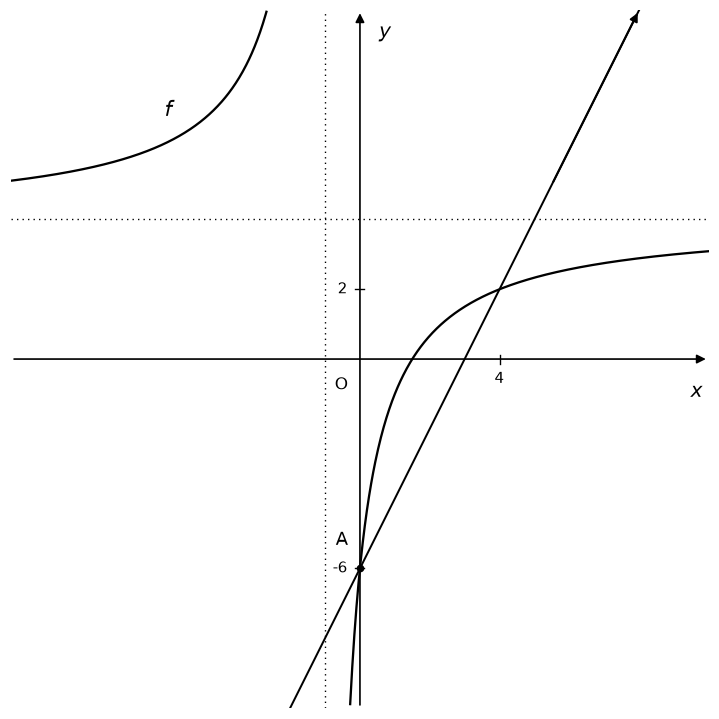


SCENARIO 2:  hb_-8_4_3_1_8_-4_3.png
  f(x) = -8/(x - (4)) + 3
  g(x) = 1x + 8
  A(-4; 4.0)


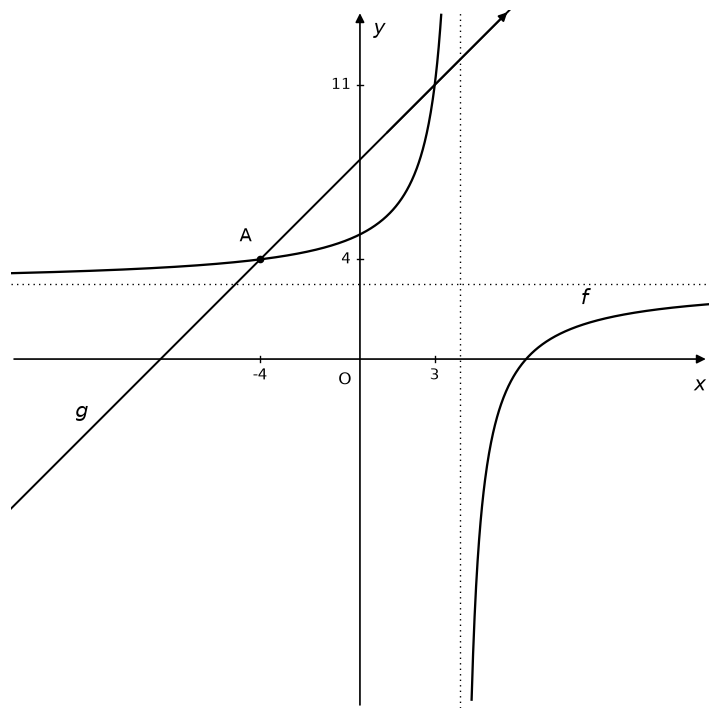


SCENARIO 3:  hb_4_2_2_-1_9_3_6.png
  f(x) = 4/(x - (2)) + 2
  g(x) = -1x + 9
  A(3; 6.0)


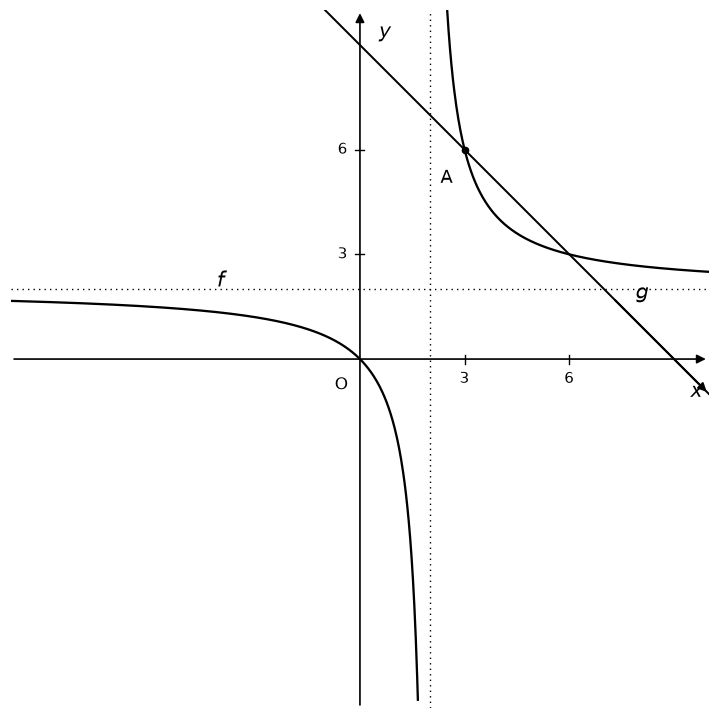


SCENARIO 4:  hb_-12_-2_1_1_-5_0_4.png
  f(x) = -12/(x - (-2)) + 1
  g(x) = 1x + -5
  A(0; -5.0)


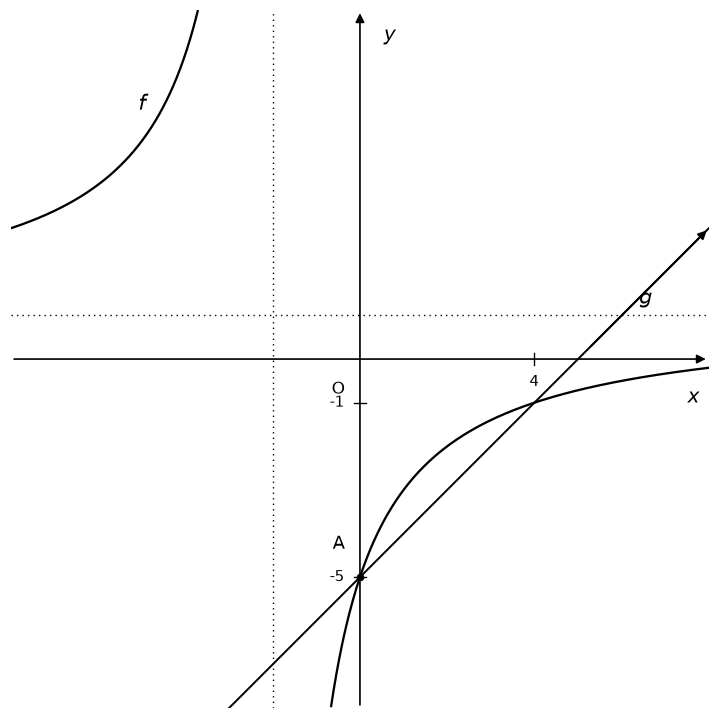

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for i, item in enumerate(items, 1):
    p = Path(item["diagram_path"])
    print(f"SCENARIO {i}:  {p.name}")
    print(f"  f(x) = {item['parameters']['a']}/(x - ({item['parameters']['p']})) + {item['parameters']['q']}")
    print(f"  g(x) = {item['parameters']['m']}x + {item['parameters']['c']}")
    print(f"  A({item['parameters']['x1']}; {item['parameters']['y1']})")
    if p.exists():
        display(Image(filename=str(p), width=520))
    else:
        print(f"  MISSING: {p}")
    print()

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- Fix g(x) formatting: "2x + -6" should read "2x - 6" ---
old = '''            {"n": "1.2",
             "prompt": "Determine the equation of f in the form f(x) = a/(x-p) + q.",
             "expected": f"f(x) = {a}/(x - ({p})) + {q}",
             "marks": 4,
             "skill_id": "functions.hyperbola.equation"},'''

# Actually the issue is in the question text construction — let me find both.

# 1. Question text: "g(x) = mx + c" is generic, so this line is fine. But the
#    parameters shown in the metadata print show "+ -6". That's the print,
#    not the generated text. Let me verify.

# The real cosmetic issue: parameter printouts in the test cell show "+ -6".
# The generated problem text says "g(x) = mx + c" (generic), so there's no
# "+ -6" visible to a learner UNLESS we name the coefficients.

# But the expected answer for f has "f(x) = {a}/(x - ({p})) + {q}" which produces
# "f(x) = -2/(x - (-3)) + -4". Fix that to format negative q cleanly.

old_ans = '"expected": f"f(x) = {a}/(x - ({p})) + {q}",'
new_ans = '''"expected": ("f(x) = " + str(a) + "/(x - (" + str(p) + ")) "
                         + ("+ " + str(q) if q >= 0 else "- " + str(abs(q)))),'''

if old_ans in src:
    src = src.replace(old_ans, new_ans, 1)
    print("Fixed f equation formatting.")
else:
    print("WARN: f equation line not found.")

# Also fix the axis symmetry answer which has "+ -7"
old_sym = '"expected": f"y = -x + ({p + q})",'
new_sym = '''"expected": ("y = -x " + ("+ " + str(p + q) if p + q >= 0 else "- " + str(abs(p + q)))),'''

if old_sym in src:
    src = src.replace(old_sym, new_sym, 1)
    print("Fixed axis of symmetry formatting.")
else:
    print("WARN: axis symmetry line not found.")

sp.write_text(src, encoding="utf-8")
print(f"Module now {len(src.splitlines())} lines.")

Fixed f equation formatting.
Fixed axis of symmetry formatting.
Module now 349 lines.


: 

In [ ]:
from pathlib import Path

module_src = '''"""
Scenario generators — composed DBE-style questions.

Each generator produces whole questions with:
  - A rendered DBE-style diagram (PNG)
  - 4-6 sub-questions, each with prompt, expected answer, MEMO STEPS,
    marks, and skill_id

Currently available:
  - gen_scenario_hyperbola_line   — f = a/(x-p) + q meets a straight line
  - gen_scenario_parabola_line    — f = a(x-p)^2 + q meets a straight line

Patterns for future scenarios:
  - gen_scenario_exponential_line (2020 P1 Q5 shape)
  - gen_scenario_cubic            (2020 P1 Q8 shape)
"""
from __future__ import annotations
from pathlib import Path
import random

ROOT = Path(__file__).resolve().parents[2]
DIAGRAM_DIR = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"


# ============================================================
# Number formatting helpers
# ============================================================

def _fnum(v):
    """Format a number: 'int' if integer, else trimmed float."""
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    if isinstance(v, int):
        return str(v)
    return str(v)


def _signed_term(coefficient, variable=""):
    """Return '+ 3x' or '- 4' style string (without leading sign if negative
    handled by caller). Always returns with a sign so concatenation reads
    cleanly: 'f(x) = 2/(x) + 3' or 'f(x) = 2/(x) - 5'."""
    if coefficient == 0:
        return ""
    sign = "+" if coefficient > 0 else "-"
    mag = abs(coefficient)
    if variable:
        if mag == 1:
            return f"{sign} {variable}"
        return f"{sign} {mag}{variable}"
    return f"{sign} {mag}"


def _poly_display(m, c):
    """Return '2x + 3' or '-x - 5' style string for mx + c."""
    if m == 0:
        return f"{c}"
    if m == 1:
        head = "x"
    elif m == -1:
        head = "-x"
    else:
        head = f"{m}x"
    if c == 0:
        return head
    return f"{head} {_signed_term(c)}"


# ============================================================
# DBE plane setup and drawing primitives
# ============================================================

def _setup_plane(lim):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=110)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.1, mutation_scale=12))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.1, mutation_scale=12))

    ax.text(lim - 0.35, -0.65, "x", fontsize=13, fontstyle="italic",
            ha="center", va="top")
    ax.text(0.55, lim - 0.35, "y", fontsize=13, fontstyle="italic",
            ha="left", va="top")
    ax.text(-0.35, -0.5, "O", fontsize=11, ha="right", va="top")
    return fig, ax


def _draw_axes_ticks(ax, x_ticks, y_ticks):
    for xv in x_ticks:
        if xv == 0:
            continue
        ax.plot([xv, xv], [-0.13, 0.13], color="black", lw=0.9)
        ax.text(xv, -0.35, _fnum(xv), fontsize=10, ha="center", va="top")
    for yv in y_ticks:
        if yv == 0:
            continue
        ax.plot([-0.13, 0.13], [yv, yv], color="black", lw=0.9)
        ax.text(-0.35, yv, _fnum(yv), fontsize=10, ha="right", va="center")


def _draw_hyperbola(ax, a, p, q, lim, label=None):
    import numpy as np
    eps = 0.06
    step = 0.02
    xs_left = np.arange(-lim, p - eps, step)
    ys_left = a / (xs_left - p) + q
    m_l = (ys_left >= -lim) & (ys_left <= lim)
    if m_l.any():
        ax.plot(xs_left[m_l], ys_left[m_l], color="black", lw=1.5, zorder=3)
    xs_right = np.arange(p + eps, lim, step)
    ys_right = a / (xs_right - p) + q
    m_r = (ys_right >= -lim) & (ys_right <= lim)
    if m_r.any():
        ax.plot(xs_right[m_r], ys_right[m_r], color="black", lw=1.5, zorder=3)
    if label:
        probe_x = (p + lim) / 2 if p < 0 else (p - lim) / 2
        probe_y = a / (probe_x - p) + q
        if abs(probe_y) < lim - 1:
            ax.text(probe_x, probe_y + 0.6, label, fontsize=14,
                    fontstyle="italic", ha="center", va="bottom")


def _draw_parabola(ax, a, p, q, lim, label=None):
    import numpy as np
    xs = np.linspace(-lim, lim, 700)
    ys = a * (xs - p) ** 2 + q
    mask = (ys >= -lim) & (ys <= lim)
    ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)
    if label:
        # Place label on the branch side away from the vertex
        for probe_x in (p + 3, p - 3):
            if abs(probe_x) >= lim - 0.5:
                continue
            probe_y = a * (probe_x - p) ** 2 + q
            if abs(probe_y) < lim - 1:
                ax.text(probe_x + (0.4 if probe_x > p else -0.4),
                        probe_y + 0.6, label,
                        fontsize=14, fontstyle="italic",
                        ha="left" if probe_x > p else "right", va="bottom")
                break


def _draw_line(ax, m, c, lim, label=None):
    if m == 0:
        x0, x1 = -lim, lim
        y0 = y1 = c
    else:
        x0, x1 = -lim, lim
        y0, y1 = m * x0 + c, m * x1 + c
        if y0 < -lim:
            x0 = (-lim - c) / m
            y0 = -lim
        if y0 > lim:
            x0 = (lim - c) / m
            y0 = lim
        if y1 < -lim:
            x1 = (-lim - c) / m
            y1 = -lim
        if y1 > lim:
            x1 = (lim - c) / m
            y1 = lim
    ax.plot([x0, x1], [y0, y1], color="black", lw=1.3, zorder=2)
    if m != 0:
        ax.annotate("",
                    xy=(x1, y1),
                    xytext=(x0 + 0.75 * (x1 - x0), y0 + 0.75 * (y1 - y0)),
                    arrowprops=dict(arrowstyle="-|>", color="black",
                                    lw=1.3, mutation_scale=11))
    if label:
        for px in (0.7 * lim, -0.7 * lim):
            py = m * px + c
            if abs(py) < lim - 1:
                ax.text(px + (0.4 if px > 0 else -0.4), py + 0.4, label,
                        fontsize=14, fontstyle="italic",
                        ha="left" if px > 0 else "right")
                break


def _draw_vertical_asymptote(ax, p, lim):
    ax.plot([p, p], [-lim, lim], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)


def _draw_horizontal_asymptote(ax, q, lim):
    ax.plot([-lim, lim], [q, q], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)


def _draw_point(ax, x, y, label=None, show_coords=False, offset="auto"):
    ax.plot(x, y, "o", color="black", markersize=4, zorder=5)
    if label is None:
        return
    txt = f"{label}({_fnum(x)}; {_fnum(y)})" if show_coords else label
    dx, dy, ha, va = 0.35, 0.55, "left", "bottom"
    if offset == "up-left":
        dx, dy, ha, va = -0.35, 0.55, "right", "bottom"
    elif offset == "down-right":
        dx, dy, ha, va = 0.35, -0.55, "left", "top"
    elif offset == "down-left":
        dx, dy, ha, va = -0.35, -0.55, "right", "top"
    ax.text(x + dx, y + dy, txt, fontsize=11, ha=ha, va=va)


# ============================================================
# Hyperbola + line scenario
# ============================================================

def _try_hyperbola_params(rng):
    p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    m = rng.choice([-2, -1, 1, 2])
    cands = [x for x in range(-6, 7) if x != p]
    x1 = rng.choice(cands)
    x2_cands = [x for x in cands if abs(x - x1) >= 2]
    if not x2_cands:
        return None
    x2 = rng.choice(x2_cands)
    if (x1 - p) * (x2 - p) <= 0:
        return None
    a = m * (x1 - p) * (p - x2)
    if a == 0 or abs(a) > 12 or abs(a) not in (2, 4, 6, 8, 10, 12):
        return None
    c = q + m * (p - (x1 + x2))
    if abs(c) > 10:
        return None
    y1 = a / (x1 - p) + q
    y2 = a / (x2 - p) + q
    if y1 != int(y1) or y2 != int(y2):
        return None
    if x1 > x2:
        x1, x2 = x2, x1
        y1, y2 = y2, y1
    return a, p, q, m, c, x1, x2, y1, y2


def _solve_inequality_hyperbola(a, p, q, m, c, x1, x2):
    def sgn(x):
        v = a / (x - p) + q - (m * x + c)
        return 1 if v > 0 else (-1 if v < 0 else 0)
    pts = sorted([x1, p, x2])
    probes = [
        (sgn(pts[0] - 5), f"x < {_fnum(pts[0])}"),
        (sgn((pts[0] + pts[1]) / 2), f"{_fnum(pts[0])} < x < {_fnum(pts[1])}"),
        (sgn((pts[1] + pts[2]) / 2), f"{_fnum(pts[1])} < x < {_fnum(pts[2])}"),
        (sgn(pts[2] + 5), f"x > {_fnum(pts[2])}"),
    ]
    parts = [label for sign, label in probes if sign > 0]
    return " or ".join(parts) if parts else "(no solution)"


def _render_hyperbola_line(a, p, q, m, c, x1, x2, y1, y2, sig):
    import numpy as np
    import matplotlib.pyplot as plt
    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"
    key_vals = [p, q, x1, x2, y1, y2, 0]
    span = max(abs(v) for v in key_vals) + 3
    lim = int(np.ceil(span / 2) * 2)
    lim = max(lim, 6)
    fig, ax = _setup_plane(lim)
    _draw_vertical_asymptote(ax, p, lim)
    _draw_horizontal_asymptote(ax, q, lim)
    _draw_hyperbola(ax, a, p, q, lim, label="f")
    _draw_line(ax, m, c, lim, label="g")
    _draw_axes_ticks(ax,
                     x_ticks=sorted(set([x1, x2])),
                     y_ticks=sorted(set([y1, y2])))
    _draw_point(ax, x1, y1, label="A", show_coords=False,
                offset="up-left" if m >= 0 else "down-left")
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    return path


def gen_scenario_hyperbola_line(count=10, seed=101, render=True):
    rng = random.Random(seed)
    out = []
    attempts = 0
    while len(out) < count and attempts < 20000:
        attempts += 1
        params = _try_hyperbola_params(rng)
        if params is None:
            continue
        a, p, q, m, c, x1, x2, y1, y2 = params
        sig = f"hb_{a}_{p}_{q}_{m}_{c}_{x1}_{x2}"
        dpath = None
        if render:
            try:
                dpath = str(_render_hyperbola_line(
                    a, p, q, m, c, x1, x2, y1, y2, sig))
            except Exception:
                dpath = None

        f_eq_str = (f"f(x) = {a}/(x - ({p}))"
                    + (" " + _signed_term(q) if q != 0 else ""))
        g_eq_str = _poly_display(m, c)
        problem = (
            f"The diagram shows the graph of f(x) = a/(x - p) + q and the "
            f"straight line g(x) = mx + c. "
            f"The graphs intersect at A({x1}; {_fnum(y1)}) and at B. "
            f"The asymptotes of f are x = {p} and y = {q}."
        )
        answer_13 = _solve_inequality_hyperbola(a, p, q, m, c, x1, x2)
        axis_ans = "y = -x" + (" " + _signed_term(p + q) if p + q != 0 else "")

        subs = [
            {"n": "1.1",
             "prompt": "Write down the domain of f.",
             "expected": f"x in R, x != {p}",
             "steps": [
                 "The denominator of f cannot be zero.",
                 f"Set x - ({p}) = 0, giving x = {p}.",
                 f"Domain: x in R, x != {p}.",
             ],
             "marks": 1,
             "skill_id": "functions.hyperbola.domain"},
            {"n": "1.2",
             "prompt": "Determine the equation of f in the form "
                       "f(x) = a/(x - p) + q.",
             "expected": f_eq_str,
             "steps": [
                 f"The asymptotes give p = {p} and q = {q} directly.",
                 f"So f(x) = a/(x - ({p}))"
                 + (" " + _signed_term(q) if q != 0 else "") + ".",
                 f"Substitute A({x1}; {_fnum(y1)}): "
                 f"{_fnum(y1)} = a/({x1} - ({p}))"
                 + (" " + _signed_term(q) if q != 0 else ""),
                 f"Solve for a: a = {a}.",
                 f"Therefore {f_eq_str}.",
             ],
             "marks": 4,
             "skill_id": "functions.hyperbola.equation"},
            {"n": "1.3",
             "prompt": "Calculate the coordinates of B.",
             "expected": f"B({x2}; {_fnum(y2)})",
             "steps": [
                 f"Set f(x) = g(x) to find the intersections.",
                 f"{a}/(x - ({p}))"
                 + (" " + _signed_term(q) if q != 0 else "")
                 + f" = {g_eq_str}",
                 f"Multiply through by (x - ({p})) and simplify to a quadratic.",
                 f"The two roots are x = {x1} (point A) and x = {x2}.",
                 f"Substitute x = {x2} into g: "
                 f"y = {_fnum(y2)}.",
                 f"B({x2}; {_fnum(y2)}).",
             ],
             "marks": 4,
             "skill_id": "functions.hyperbola.intersection"},
            {"n": "1.4",
             "prompt": "For which values of x is f(x) > g(x)?",
             "expected": answer_13,
             "steps": [
                 f"Critical values: the two intersections (x = {x1}, "
                 f"x = {x2}) and the vertical asymptote x = {p}.",
                 "Consider the sign of f(x) - g(x) on each interval.",
                 f"From the sketch: f(x) > g(x) for {answer_13}.",
             ],
             "marks": 2,
             "skill_id": "functions.hyperbola.inequality"},
            {"n": "1.5",
             "prompt": "Write down the equation of the axis of symmetry of f "
                       "with a negative gradient.",
             "expected": axis_ans,
             "steps": [
                 f"The axes of symmetry pass through the point of "
                 f"intersection of the asymptotes: ({p}; {q}).",
                 "They have gradients +1 and -1.",
                 f"Negative gradient line: y = -x + c where c = p + q = "
                 f"{p + q}.",
                 axis_ans + ".",
             ],
             "marks": 2,
             "skill_id": "functions.hyperbola.axis_symmetry"},
        ]
        out.append({
            "scenario": "hyperbola_line",
            "skill_id": "functions.hyperbola",
            "problem": problem,
            "diagram_path": dpath,
            "subquestions": subs,
            "total_marks": sum(s["marks"] for s in subs),
            "parameters": {"a": a, "p": p, "q": q, "m": m, "c": c,
                           "x1": x1, "x2": x2, "y1": y1, "y2": y2},
        })
    return out


# ============================================================
# Parabola + line scenario (NEW)
# ============================================================

def _try_parabola_params(rng):
    a = rng.choice([-2, -1, 1, 2])
    p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])

    # Pick two intersection x-values, separated by >=2, with even sum
    tries = 0
    x1 = x2 = None
    while tries < 50:
        tries += 1
        x1 = rng.randint(-6, 5)
        x2 = rng.randint(x1 + 2, 7)
        if (x1 + x2) % 2 == 0:
            break
    if x1 is None or x2 is None:
        return None

    y1 = a * (x1 - p) ** 2 + q
    y2 = a * (x2 - p) ** 2 + q
    if max(abs(y1), abs(y2)) > 12:
        return None

    dy = y2 - y1
    dx = x2 - x1
    if dx == 0 or dy % dx != 0:
        return None
    m = dy // dx
    c = y1 - m * x1
    if abs(m) > 5 or abs(c) > 12:
        return None

    # Turning point must NOT lie on the line
    if q == m * p + c:
        return None

    # Require visual separation at the midpoint
    x_mid = (x1 + x2) // 2
    y_mid_f = a * (x_mid - p) ** 2 + q
    y_mid_g = m * x_mid + c
    if abs(y_mid_f - y_mid_g) < 2:
        return None

    return a, p, q, m, c, x1, x2, y1, y2, x_mid


def _solve_inequality_parabola(a, x1, x2):
    if a > 0:
        return f"x < {x1} or x > {x2}"
    return f"{x1} < x < {x2}"


def _render_parabola_line(a, p, q, m, c, x1, x2, y1, y2, sig):
    import numpy as np
    import matplotlib.pyplot as plt
    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"
    key_vals = [p, q, x1, x2, y1, y2, 0]
    span = max(abs(v) for v in key_vals) + 3
    lim = int(np.ceil(span / 2) * 2)
    lim = max(lim, 6)
    fig, ax = _setup_plane(lim)
    _draw_parabola(ax, a, p, q, lim, label="f")
    _draw_line(ax, m, c, lim, label="g")
    _draw_axes_ticks(ax,
                     x_ticks=sorted(set([x1, x2])),
                     y_ticks=sorted(set([y1, y2])))
    # Only A labelled
    _draw_point(ax, x1, y1, label="A", show_coords=False,
                offset="down-left" if a > 0 else "up-left")
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    return path


def gen_scenario_parabola_line(count=10, seed=201, render=True):
    """DBE-style parabola + line composed questions.

    Reference: 2024 P1 Q6 shape.
    """
    rng = random.Random(seed)
    out = []
    attempts = 0
    while len(out) < count and attempts < 20000:
        attempts += 1
        params = _try_parabola_params(rng)
        if params is None:
            continue
        a, p, q, m, c, x1, x2, y1, y2, x_mid = params
        sig = f"pl_{a}_{p}_{q}_{m}_{c}_{x1}_{x2}"
        dpath = None
        if render:
            try:
                dpath = str(_render_parabola_line(
                    a, p, q, m, c, x1, x2, y1, y2, sig))
            except Exception:
                dpath = None

        f_eq_str = (f"f(x) = {a}(x - ({p}))^2"
                    + (" " + _signed_term(q) if q != 0 else ""))
        g_eq_str = _poly_display(m, c)
        problem = (
            f"The diagram shows the graphs of {f_eq_str} and the "
            f"straight line g. A({x1}; {_fnum(y1)}) and C({x2}; {_fnum(y2)}) "
            f"are the points of intersection of f and g."
        )
        ineq_ans = _solve_inequality_parabola(a, x1, x2)
        eh_max = abs(a * (x_mid - p) ** 2 + q - (m * x_mid + c))
        range_op = ">=" if a > 0 else "<="

        subs = [
            {"n": "1.1",
             "prompt": "Write down the coordinates of B, the turning point of f.",
             "expected": f"B({p}; {q})",
             "steps": [
                 "For f(x) = a(x - p)^2 + q the turning point is (p; q).",
                 f"From the given equation: p = {p}, q = {q}.",
                 f"B({p}; {q}).",
             ],
             "marks": 2,
             "skill_id": "functions.parabola.turning"},
            {"n": "1.2",
             "prompt": "Determine the equation of the straight line g "
                       "in the form y = mx + c.",
             "expected": f"g(x) = {g_eq_str}",
             "steps": [
                 f"Use A({x1}; {_fnum(y1)}) and C({x2}; {_fnum(y2)}).",
                 f"m = (y_C - y_A) / (x_C - x_A) = "
                 f"({_fnum(y2)} - {_fnum(y1)}) / ({x2} - {x1}) = {m}.",
                 f"Substitute A: {_fnum(y1)} = {m}({x1}) + c.",
                 f"Solve: c = {c}.",
                 f"g(x) = {g_eq_str}.",
             ],
             "marks": 3,
             "skill_id": "functions.line.equation"},
            {"n": "1.3",
             "prompt": "For which values of x is f(x) > g(x)?",
             "expected": ineq_ans,
             "steps": [
                 "The critical values are the intersection x-values: "
                 f"x = {x1} and x = {x2}.",
                 f"The parabola opens {'up' if a > 0 else 'down'} "
                 f"(a = {a}).",
                 ("f > g outside the interval between the intersections"
                  if a > 0 else
                  "f > g between the two intersections"),
                 f"Answer: {ineq_ans}.",
             ],
             "marks": 2,
             "skill_id": "functions.inequality"},
            {"n": "1.4",
             "prompt": "EH is drawn parallel to the y-axis with E on f and "
                       "H on g. Calculate the maximum length of EH.",
             "expected": f"EH_max = {_fnum(eh_max)} units",
             "steps": [
                 f"Let EH(x) = f(x) - g(x).",
                 "EH is a parabola with the same x-intercepts as the "
                 f"intersections of f and g: x = {x1}, x = {x2}.",
                 f"Maximum occurs at x = ({x1} + {x2}) / 2 = {x_mid}.",
                 f"EH({x_mid}) = {_fnum(eh_max)}.",
                 f"Maximum length: {_fnum(eh_max)} units.",
             ],
             "marks": 4,
             "skill_id": "functions.parabola.max_length"},
            {"n": "1.5",
             "prompt": "Write down the range of f.",
             "expected": f"y {range_op} {q}",
             "steps": [
                 f"Turning point: ({p}; {q}).",
                 f"a = {a} {'>' if a > 0 else '<'} 0, so f opens "
                 f"{'up' if a > 0 else 'down'}.",
                 f"Range: y {range_op} {q}.",
             ],
             "marks": 2,
             "skill_id": "functions.parabola.range"},
        ]
        out.append({
            "scenario": "parabola_line",
            "skill_id": "functions.parabola",
            "problem": problem,
            "diagram_path": dpath,
            "subquestions": subs,
            "total_marks": sum(s["marks"] for s in subs),
            "parameters": {"a": a, "p": p, "q": q, "m": m, "c": c,
                           "x1": x1, "x2": x2, "y1": y1, "y2": y2,
                           "x_mid": x_mid},
        })
    return out


# ============================================================
# Registry — for the drill to discover scenarios
# ============================================================

ALL_SCENARIOS = {
    "hyperbola_line": gen_scenario_hyperbola_line,
    "parabola_line":  gen_scenario_parabola_line,
}
'''

path = ROOT / "src" / "tutor" / "scenario_generators.py"
path.write_text(module_src, encoding="utf-8")
print(f"Wrote {path} ({len(module_src.splitlines())} lines)")

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\src\tutor\scenario_generators.py (605 lines)


In [ ]:
import sys, importlib
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.tutor.scenario_generators as sg
importlib.reload(sg)

# Clear old diagrams
d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

# Generate one of each
hb = sg.gen_scenario_hyperbola_line(count=1, seed=7, render=True)
pl = sg.gen_scenario_parabola_line(count=1, seed=7, render=True)

def show(item, label):
    print("=" * 70)
    print(f"{label}: {item['scenario']}")
    print("=" * 70)
    print(item["problem"])
    print()
    for s in item["subquestions"]:
        print(f"  {s['n']}  ({s['marks']} marks)  [{s['skill_id']}]")
        print(f"      {s['prompt']}")
        print(f"      Expected: {s['expected']}")
        print(f"      Memo steps:")
        for i, step in enumerate(s["steps"], 1):
            print(f"        {i}. {step}")
        print()
    print(f"Total marks: {item['total_marks']}")
    print(f"Diagram: {item['diagram_path']}")
    print()

show(hb[0], "HYPERBOLA + LINE")
show(pl[0], "PARABOLA + LINE")

HYPERBOLA + LINE: hyperbola_line
The diagram shows the graph of f(x) = a/(x - p) + q and the straight line g(x) = mx + c. The graphs intersect at A(0; -6) and at B. The asymptotes of f are x = -1 and y = 4.

  1.1  (1 marks)  [functions.hyperbola.domain]
      Write down the domain of f.
      Expected: x in R, x != -1
      Memo steps:
        1. The denominator of f cannot be zero.
        2. Set x - (-1) = 0, giving x = -1.
        3. Domain: x in R, x != -1.

  1.2  (4 marks)  [functions.hyperbola.equation]
      Determine the equation of f in the form f(x) = a/(x - p) + q.
      Expected: f(x) = -10/(x - (-1)) + 4
      Memo steps:
        1. The asymptotes give p = -1 and q = 4 directly.
        2. So f(x) = a/(x - (-1)) + 4.
        3. Substitute A(0; -6): -6 = a/(0 - (-1)) + 4
        4. Solve for a: a = -10.
        5. Therefore f(x) = -10/(x - (-1)) + 4.

  1.3  (4 marks)  [functions.hyperbola.intersection]
      Calculate the coordinates of B.
      Expected: B(4; 2)
      M

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- 1. Enforce sloped line: m must NOT be zero ---
old = '''    dy = y2 - y1
    dx = x2 - x1
    if dx == 0 or dy % dx != 0:
        return None
    m = dy // dx
    c = y1 - m * x1
    if abs(m) > 5 or abs(c) > 12:
        return None'''

new = '''    dy = y2 - y1
    dx = x2 - x1
    if dx == 0 or dy % dx != 0:
        return None
    m = dy // dx
    if m == 0:
        return None  # horizontal line: not DBE style
    c = y1 - m * x1
    if abs(m) > 5 or abs(c) > 12:
        return None'''

if old in src:
    src = src.replace(old, new, 1)
    print("1. Enforced m != 0 for parabola line.")
else:
    print("1. WARN: parabola params block not found.")

# --- 2. Cleaner f(x) display: "-(x - 4)^2 + 3" not "-1(x - (4))^2 + 3" ---
old_f_par = '''        f_eq_str = (f"f(x) = {a}(x - ({p}))^2"
                    + (" " + _signed_term(q) if q != 0 else ""))'''

new_f_par = '''        # Cleaner parabola display
        if a == 1:
            head = ""
        elif a == -1:
            head = "-"
        else:
            head = str(a)
        inner = f"(x - {p})" if p > 0 else f"(x + {abs(p)})"
        f_eq_str = f"f(x) = {head}{inner}^2" + (" " + _signed_term(q) if q != 0 else "")'''

if old_f_par in src:
    src = src.replace(old_f_par, new_f_par, 1)
    print("2. Cleaner parabola f(x) display.")
else:
    print("2. WARN: parabola f_eq line not found.")

# --- 3. Label the turning point B on the parabola diagram ---
old_draw = '''    # Only A labelled
    _draw_point(ax, x1, y1, label="A", show_coords=False,
                offset="down-left" if a > 0 else "up-left")'''

new_draw = '''    # Label A (intersection) and B (turning point)
    _draw_point(ax, x1, y1, label="A", show_coords=False,
                offset="down-left" if a > 0 else "up-left")
    _draw_point(ax, p, q, label="B", show_coords=False,
                offset="up-right" if a > 0 else "up-right")'''

if old_draw in src:
    src = src.replace(old_draw, new_draw, 1)
    print("3. Turning point B labelled on parabola diagram.")
else:
    print("3. WARN: parabola points block not found.")

sp.write_text(src, encoding="utf-8")
print(f"\nModule now {len(src.splitlines())} lines.")

1. Enforced m != 0 for parabola line.
2. Cleaner parabola f(x) display.
3. Turning point B labelled on parabola diagram.

Module now 616 lines.


=== PARABOLA GENERATOR (3 samples) ===

SCENARIO 1
  f(x) = -1(x - 1)^2 + -3   g(x) = -2x + -4
  A(0; -4)  C(4; -12)  turning B(1; -3)
  diagram: pl_-1_1_-3_-2_-4_0_4.png
  → line equation expected: g(x) = -2x - 4


SCENARIO 2
  f(x) = -1(x - 3)^2 + -3   g(x) = -2x + 0
  A(2; -4)  C(6; -12)  turning B(3; -3)
  diagram: pl_-1_3_-3_-2_0_2_6.png
  → line equation expected: g(x) = -2x


SCENARIO 3
  f(x) = -1(x - 4)^2 + 1   g(x) = -2x + 6
  A(3; 0)  C(7; -8)  turning B(4; 1)
  diagram: pl_-1_4_1_-2_6_3_7.png
  → line equation expected: g(x) = -2x + 6

--- parabola scenario 1 ---


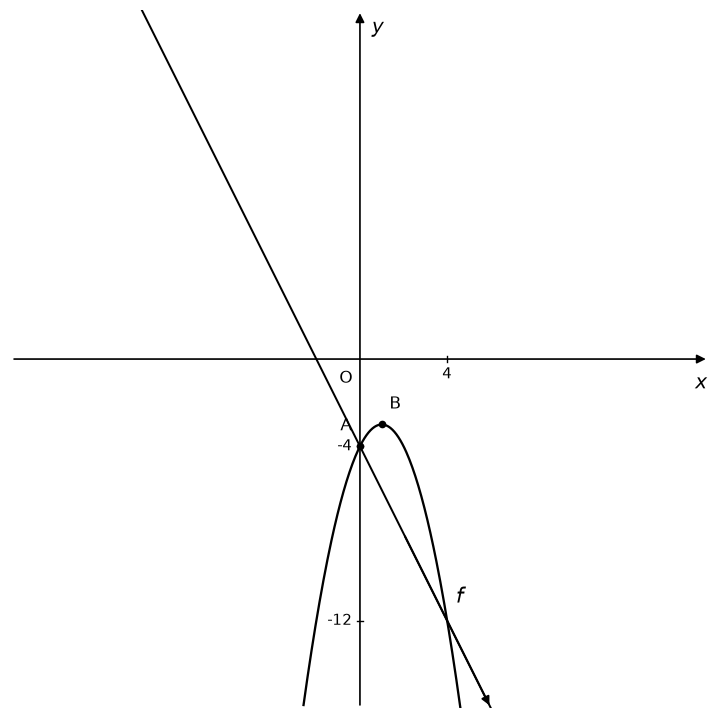

--- parabola scenario 2 ---


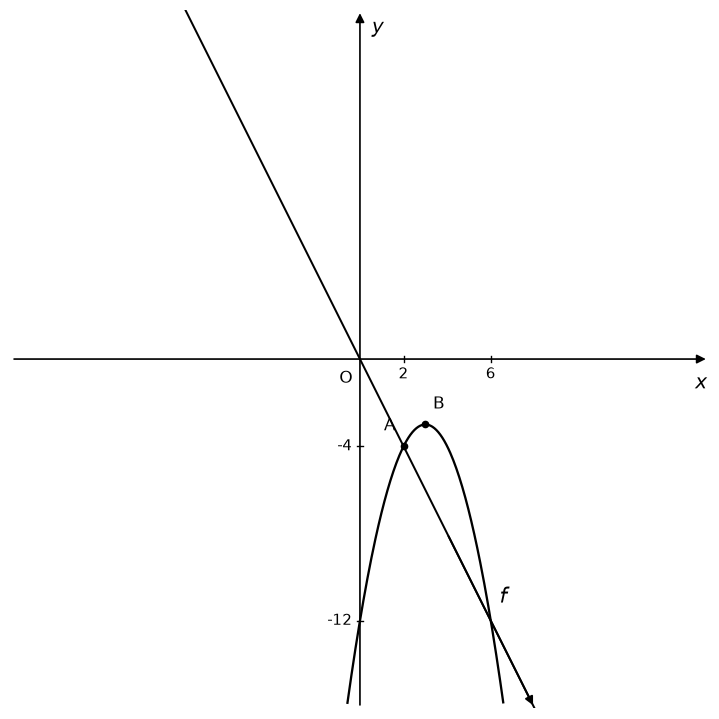

--- parabola scenario 3 ---


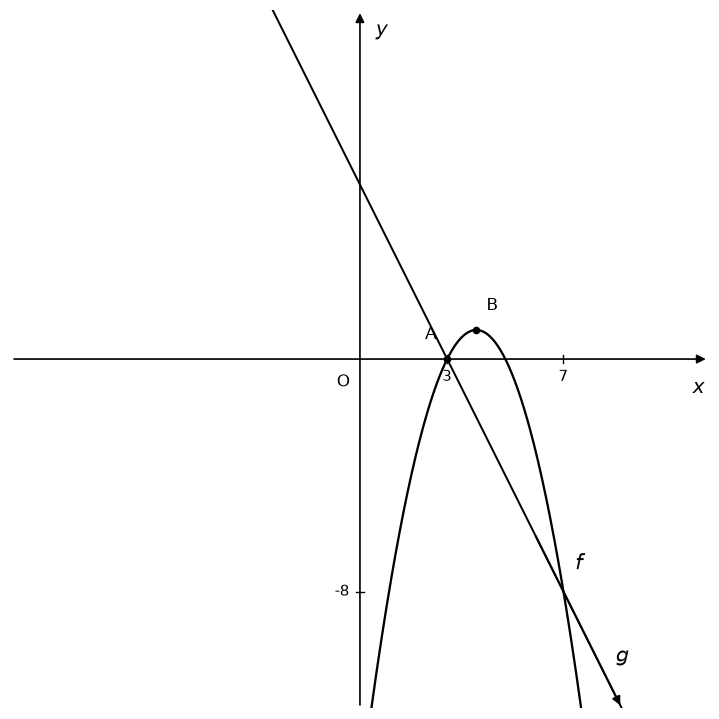

In [ ]:
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

hb = sg.gen_scenario_hyperbola_line(count=1, seed=7, render=True)
pl = sg.gen_scenario_parabola_line(count=3, seed=42, render=True)

print("=== PARABOLA GENERATOR (3 samples) ===")
for i, item in enumerate(pl, 1):
    p_ = item["parameters"]
    print(f"\nSCENARIO {i}")
    print(f"  f(x) = {p_['a']}(x - {p_['p']})^2 + {p_['q']}   "
          f"g(x) = {p_['m']}x + {p_['c']}")
    print(f"  A({p_['x1']}; {p_['y1']})  C({p_['x2']}; {p_['y2']})  "
          f"turning B({p_['p']}; {p_['q']})")
    print(f"  diagram: {Path(item['diagram_path']).name}")
    # Show line equation subquestion expected value
    for s in item["subquestions"]:
        if s["n"] == "1.2":
            print(f"  → line equation expected: {s['expected']}")
    print()

from IPython.display import Image, display
for i, item in enumerate(pl, 1):
    print(f"--- parabola scenario {i} ---")
    display(Image(filename=item["diagram_path"], width=480))

=== PROBLEM TEXT (as a learner would see it) ===

SCENARIO 1:
  The diagram shows the graphs of f(x) = -(x - 1)^2 - 3 and the straight line g. A(0; -4) and C(4; -12) are the points of intersection of f and g.

SCENARIO 2:
  The diagram shows the graphs of f(x) = -(x - 3)^2 - 3 and the straight line g. A(2; -4) and C(6; -12) are the points of intersection of f and g.

SCENARIO 3:
  The diagram shows the graphs of f(x) = -(x - 4)^2 + 1 and the straight line g. A(3; 0) and C(7; -8) are the points of intersection of f and g.


=== DIAGRAMS ===

--- parabola scenario 1 ---


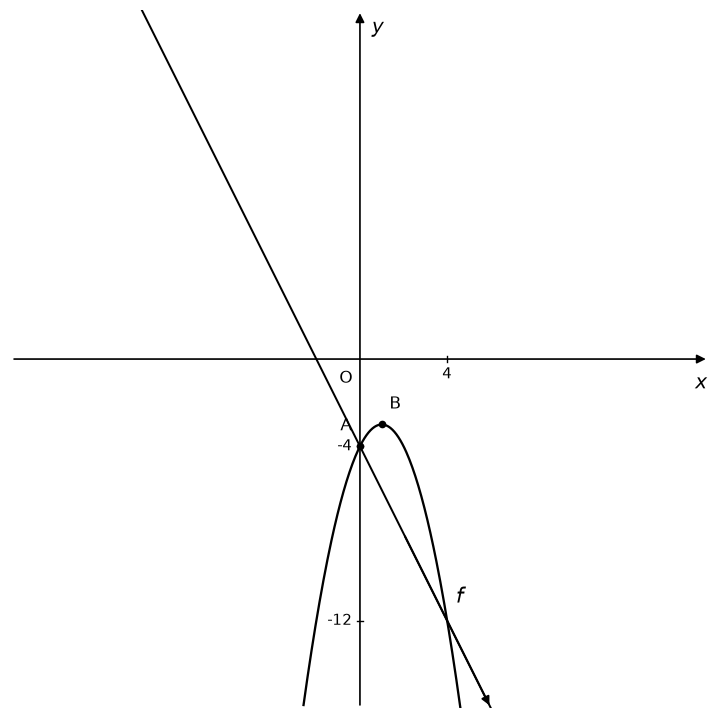


--- parabola scenario 2 ---


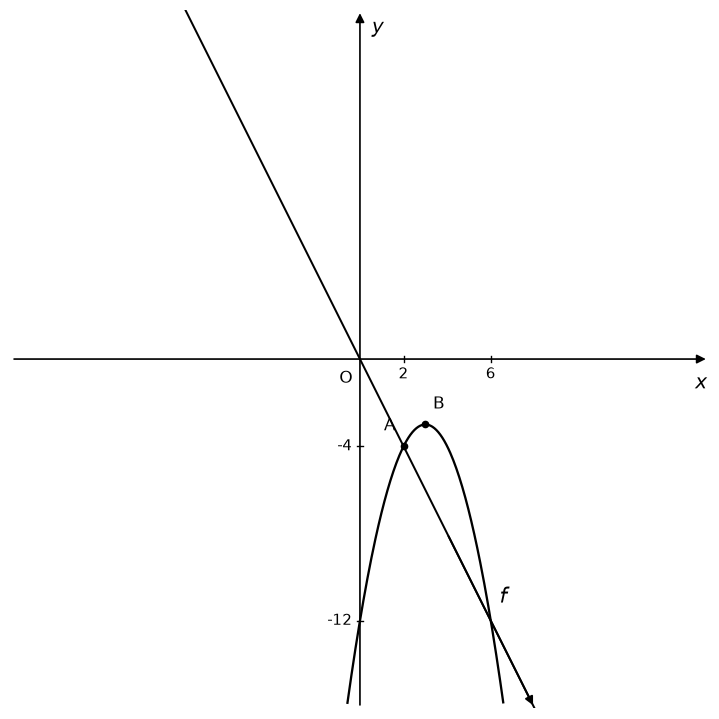


--- parabola scenario 3 ---


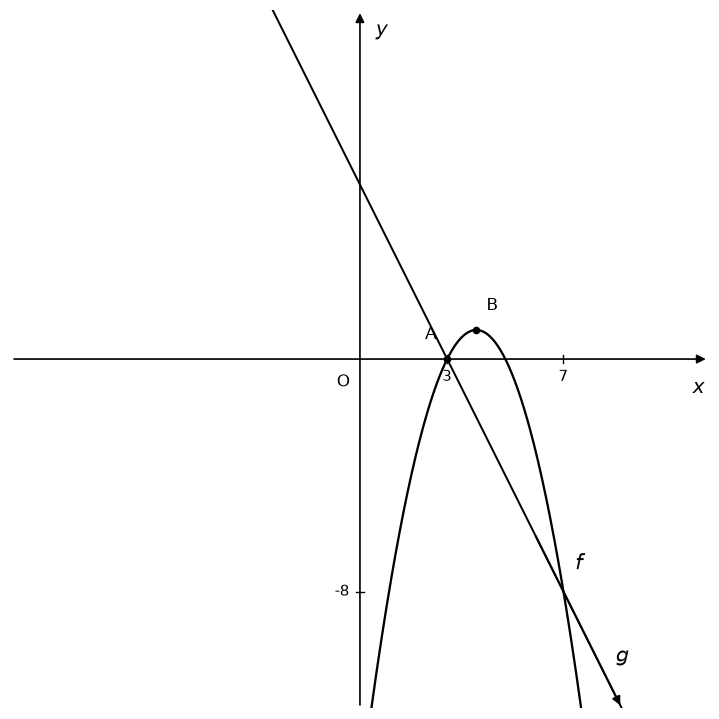


=== Diversity across 10 samples (seed=1) ===
a distribution: {1: 9, -1: 1}
m distribution: {-2: 7, 2: 3}


In [ ]:
from IPython.display import Image, display

# Show the actual generated problem text (not the raw params)
print("=== PROBLEM TEXT (as a learner would see it) ===\n")
for i, item in enumerate(pl, 1):
    print(f"SCENARIO {i}:")
    print(f"  {item['problem']}")
    print()

# Show all three diagrams
print("\n=== DIAGRAMS ===")
for i, item in enumerate(pl, 1):
    print(f"\n--- parabola scenario {i} ---")
    display(Image(filename=item["diagram_path"], width=520))

# Diversity check across more samples
import importlib
import src.tutor.scenario_generators as sg
importlib.reload(sg)

more = sg.gen_scenario_parabola_line(count=10, seed=1, render=False)
print("\n=== Diversity across 10 samples (seed=1) ===")
from collections import Counter
a_vals = Counter(item["parameters"]["a"] for item in more)
m_vals = Counter(item["parameters"]["m"] for item in more)
print(f"a distribution: {dict(a_vals)}")
print(f"m distribution: {dict(m_vals)}")

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# Find where the parabola section starts and ends (from _try_parabola_params
# to the registry at the bottom) and replace it wholesale.
start = src.find("def _try_parabola_params(")
end = src.find("# ============================================================\n# Registry")

if start == -1 or end == -1:
    print("ERROR: section markers not found.")
else:
    new_section = '''def _try_parabola_params_tp(rng):
    """Shape A: turning point + one extra point given."""
    a = rng.choice([-2, -1, -1, 1, 1, 2])
    p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
    # A point on f, distinct from the turning point
    xtry = [x for x in range(-6, 7) if x != p]
    rng.shuffle(xtry)
    for x_a in xtry:
        y_a = a * (x_a - p) ** 2 + q
        if abs(y_a) > 12 or (x_a == 0 and y_a == q):
            continue
        return a, p, q, x_a, y_a
    return None


def _try_parabola_params_roots(rng):
    """Shape B: two x-intercepts + y-intercept given."""
    # Roots r1 < 0 < r2 gives a nice shape
    r1 = rng.choice([-5, -4, -3, -2, -1])
    r2 = rng.choice([1, 2, 3, 4, 5])
    # a must give integer y-intercept and moderate curvature
    for a in rng.sample([-2, -1, 1, 2, -3, 3], 6):
        c = a * r1 * r2
        if abs(c) <= 12 and c != 0:
            return a, r1, r2, c
    return None


def _render_parabola_shape(shape, a, p, q, r1, r2, lim_extra=3):
    import numpy as np
    import matplotlib.pyplot as plt
    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)

    if shape == "turning_point":
        sig = f"ptp_{a}_{p}_{q}_{p}_{q}"
        key_vals = [p, q, 0]
    else:
        sig = f"prt_{a}_{r1}_{r2}"
        key_vals = [r1, r2, 0]

    span = max(abs(v) for v in key_vals) + 4
    lim = int(np.ceil(span / 2) * 2)
    lim = max(lim, 7)

    fig, ax = _setup_plane(lim)

    if shape == "turning_point":
        _draw_parabola(ax, a, p, q, lim, label="f")
        # Label turning point B and given point A
        _draw_point(ax, p, q, label="B", show_coords=False,
                    offset="down-right" if a > 0 else "up-right")
        # A is the extra point on f
        # (we need x_a, y_a — passed via closure? no, we redraw only if needed)
        return fig, ax, sig
    else:
        # Factored form: f(x) = a(x - r1)(x - r2)
        # Expand: a x^2 - a(r1+r2) x + a r1 r2
        # Turning point x = (r1+r2)/2, y = a*((r1+r2)/2 - r1)((r1+r2)/2 - r2)
        p_mid = (r1 + r2) / 2
        q_tp = a * (p_mid - r1) * (p_mid - r2)
        _draw_parabola(ax, a, p_mid, q_tp, lim, label="f")
        _draw_point(ax, r1, 0, label="", show_coords=False)
        _draw_point(ax, r2, 0, label="", show_coords=False)
        _draw_point(ax, 0, a * r1 * r2, label="", show_coords=False)
        return fig, ax, sig


def _solve_inequality_parabola(a, x1, x2):
    if a > 0:
        return f"x < {x1} or x > {x2}"
    return f"{x1} < x < {x2}"


def gen_scenario_parabola(count=10, seed=201, shape="turning_point", render=True):
    """DBE-style parabola questions in one of two shapes.

    Shape 'turning_point':
        Given f(x) = a(x-p)^2 + q with turning point B(p; q) and
        a further point A on f.
        Learner finds a, converts to standard form, then answers
        range/inequality.

    Shape 'two_roots':
        Given that f cuts the x-axis at (r1; 0) and (r2; 0), and the
        y-intercept (0; c).
        Learner writes factored form, finds a, expands to standard
        form, finds turning point, then answers range/inequality.
    """
    rng = random.Random(seed)
    out = []
    attempts = 0
    max_attempts = 40000

    while len(out) < count and attempts < max_attempts:
        attempts += 1

        if shape == "turning_point":
            params = _try_parabola_params_tp(rng)
            if params is None:
                continue
            a, p, q, x_a, y_a = params

            sig = f"ptp_{a}_{p}_{q}_{x_a}"
            dpath = None
            if render:
                try:
                    import numpy as np
                    import matplotlib.pyplot as plt
                    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
                    fpath = DIAGRAM_DIR / f"{sig}.png"
                    key_vals = [p, q, x_a, y_a, 0]
                    span = max(abs(v) for v in key_vals) + 4
                    lim = max(int(np.ceil(span / 2) * 2), 7)
                    fig, ax = _setup_plane(lim)
                    _draw_parabola(ax, a, p, q, lim, label="f")
                    _draw_point(ax, p, q, label="B", show_coords=True,
                                offset="down-right" if a > 0 else "up-right")
                    _draw_point(ax, x_a, y_a, label="A", show_coords=True,
                                offset="down-right" if a > 0 else "up-left")
                    fig.tight_layout(pad=0.2)
                    fig.savefig(fpath, dpi=110, bbox_inches="tight",
                                facecolor="white", edgecolor="none")
                    plt.close(fig)
                    dpath = str(fpath)
                except Exception:
                    dpath = None

            inner = f"(x - {p})" if p > 0 else f"(x + {abs(p)})"
            tp_form = f"f(x) = a{inner}^2" + (" " + _signed_term(q) if q != 0 else "")
            b_coef = -2 * a * p
            c_coef = a * p * p + q
            std_form_parts = [f"{a if a != 1 else ''}x^2" if a != 1 else "x^2"]
            if b_coef != 0:
                std_form_parts.append(_signed_term(b_coef, "x"))
            if c_coef != 0:
                std_form_parts.append(_signed_term(c_coef))
            std_form = "f(x) = " + " ".join(std_form_parts).strip()

            range_op = ">=" if a > 0 else "<="
            problem = (
                f"The diagram shows the graph of a parabola f. "
                f"The turning point of f is B({p}; {q}) and A({x_a}; {_fnum(y_a)}) "
                f"is a point on f."
            )

            subs = [
                {"n": "1.1",
                 "prompt": "Write down the equation of f in the form "
                           "f(x) = a(x - p)^2 + q, showing the values of p and q.",
                 "expected": f"p = {p}, q = {q}",
                 "steps": [
                     f"The turning point is ({p}; {q}).",
                     f"For f(x) = a(x - p)^2 + q, the turning point is (p; q).",
                     f"Therefore p = {p} and q = {q}.",
                 ],
                 "marks": 2,
                 "skill_id": "functions.parabola.parameter"},
                {"n": "1.2",
                 "prompt": "Calculate the value of a.",
                 "expected": f"a = {a}",
                 "steps": [
                     f"Substitute A({x_a}; {_fnum(y_a)}) into "
                     f"f(x) = a(x - ({p}))^2"
                     + (" " + _signed_term(q) if q != 0 else ""),
                     f"{_fnum(y_a)} = a({x_a} - ({p}))^2"
                     + (" " + _signed_term(q) if q != 0 else ""),
                     f"{_fnum(y_a - q)} = a({(x_a - p)**2})",
                     f"a = {a}",
                 ],
                 "marks": 3,
                 "skill_id": "functions.parabola.parameter"},
                {"n": "1.3",
                 "prompt": "Write down the equation of f in the form "
                           "y = ax^2 + bx + c.",
                 "expected": std_form,
                 "steps": [
                     f"Start from f(x) = {a}(x - ({p}))^2"
                     + (" " + _signed_term(q) if q != 0 else ""),
                     f"Expand the square: (x - ({p}))^2 = x^2 "
                     + _signed_term(b_coef / a, "x") + " " + _signed_term(p * p),
                     f"Multiply by a = {a}: "
                     + f"{a}x^2 " + _signed_term(b_coef, "x") + " "
                     + _signed_term(a * p * p),
                     f"Add q = {q}.",
                     f"{std_form}",
                 ],
                 "marks": 3,
                 "skill_id": "functions.parabola.equation"},
                {"n": "1.4",
                 "prompt": "Write down the range of f.",
                 "expected": f"y {range_op} {q}",
                 "steps": [
                     f"Turning point: ({p}; {q}).",
                     f"a = {a} {'>' if a > 0 else '<'} 0, so f opens "
                     f"{'up' if a > 0 else 'down'}.",
                     f"Range: y {range_op} {q}.",
                 ],
                 "marks": 2,
                 "skill_id": "functions.parabola.range"},
                {"n": "1.5",
                 "prompt": "For which values of x is f(x) decreasing?",
                 "expected": (f"x > {p}" if a > 0 else f"x < {p}"),
                 "steps": [
                     "A parabola is decreasing on the side of the turning "
                     "point where the curve goes down as x increases.",
                     f"Turning point is at x = {p}.",
                     f"a {'>' if a > 0 else '<'} 0, so f is decreasing for "
                     f"{'x > ' + str(p) if a > 0 else 'x < ' + str(p)}.",
                 ],
                 "marks": 2,
                 "skill_id": "functions.parabola.monotone"},
            ]
            out.append({
                "scenario": "parabola_turning_point",
                "skill_id": "functions.parabola",
                "problem": problem,
                "diagram_path": dpath,
                "subquestions": subs,
                "total_marks": sum(s["marks"] for s in subs),
                "parameters": {"a": a, "p": p, "q": q,
                               "x_a": x_a, "y_a": y_a},
            })

        else:  # two_roots
            params = _try_parabola_params_roots(rng)
            if params is None:
                continue
            a, r1, r2, c = params
            if r1 > r2:
                r1, r2 = r2, r1

            sig = f"prt_{a}_{r1}_{r2}"
            dpath = None
            if render:
                try:
                    import numpy as np
                    import matplotlib.pyplot as plt
                    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
                    fpath = DIAGRAM_DIR / f"{sig}.png"
                    key_vals = [r1, r2, 0, c]
                    span = max(abs(v) for v in key_vals) + 4
                    lim = max(int(np.ceil(span / 2) * 2), 7)
                    fig, ax = _setup_plane(lim)
                    p_mid = (r1 + r2) / 2
                    q_tp = a * (p_mid - r1) * (p_mid - r2)
                    _draw_parabola(ax, a, p_mid, q_tp, lim, label="f")
                    _draw_point(ax, r1, 0, label="", show_coords=False)
                    _draw_point(ax, r2, 0, label="", show_coords=False)
                    _draw_point(ax, 0, c, label="", show_coords=False)
                    fig.tight_layout(pad=0.2)
                    fig.savefig(fpath, dpi=110, bbox_inches="tight",
                                facecolor="white", edgecolor="none")
                    plt.close(fig)
                    dpath = str(fpath)
                except Exception:
                    dpath = None

            b_coef = -a * (r1 + r2)
            c_coef = a * r1 * r2
            p_mid = (r1 + r2) / 2
            q_tp = a * (p_mid - r1) * (p_mid - r2)
            std_parts = [f"{a}x^2" if a != 1 else "x^2"]
            if b_coef != 0:
                std_parts.append(_signed_term(b_coef, "x"))
            if c_coef != 0:
                std_parts.append(_signed_term(c_coef))
            std_form = "f(x) = " + " ".join(std_parts)
            range_op = ">=" if a > 0 else "<="
            ineq_ans = _solve_inequality_parabola(a, r1, r2)
            tp_display = _fnum(q_tp) if q_tp == int(q_tp) else f"{q_tp:.2f}"

            problem = (
                f"The diagram shows a parabola f that cuts the x-axis at "
                f"({r1}; 0) and ({r2}; 0). The y-intercept of f is (0; {c})."
            )

            subs = [
                {"n": "1.1",
                 "prompt": "Write down the equation of f in the form "
                           "y = a(x - r1)(x - r2).",
                 "expected": f"y = a(x - ({r1}))(x - ({r2}))",
                 "steps": [
                     f"x-intercepts are {r1} and {r2}.",
                     f"So f(x) = a(x - ({r1}))(x - ({r2})).",
                 ],
                 "marks": 2,
                 "skill_id": "functions.parabola.intercepts"},
                {"n": "1.2",
                 "prompt": "Calculate the value of a.",
                 "expected": f"a = {a}",
                 "steps": [
                     f"Substitute the y-intercept (0; {c}) into "
                     f"f(x) = a(x - ({r1}))(x - ({r2})).",
                     f"{c} = a(0 - ({r1}))(0 - ({r2}))",
                     f"{c} = a({(-r1) * (-r2)})",
                     f"a = {a}",
                 ],
                 "marks": 3,
                 "skill_id": "functions.parabola.parameter"},
                {"n": "1.3",
                 "prompt": "Write down the equation of f in the form "
                           "y = ax^2 + bx + c.",
                 "expected": std_form,
                 "steps": [
                     f"Start from f(x) = {a}(x - ({r1}))(x - ({r2})).",
                     f"Expand the brackets: (x - ({r1}))(x - ({r2})) = "
                     f"x^2 " + _signed_term(-(r1 + r2), "x") + " "
                     + _signed_term(r1 * r2),
                     f"Multiply by a = {a}: "
                     + f"{a}x^2 " + _signed_term(b_coef, "x") + " "
                     + _signed_term(c_coef),
                     f"{std_form}",
                 ],
                 "marks": 3,
                 "skill_id": "functions.parabola.equation"},
                {"n": "1.4",
                 "prompt": "Write down the coordinates of the turning point of f.",
                 "expected": f"({_fnum(p_mid)}; {tp_display})",
                 "steps": [
                     "By symmetry, the x-coordinate of the turning point is "
                     f"the midpoint of {r1} and {r2}.",
                     f"x = ({r1} + {r2}) / 2 = {_fnum(p_mid)}.",
                     f"Substitute into f: y = {tp_display}.",
                     f"Turning point: ({_fnum(p_mid)}; {tp_display}).",
                 ],
                 "marks": 3,
                 "skill_id": "functions.parabola.turning"},
                {"n": "1.5",
                 "prompt": "For which values of x is f(x) > 0?",
                 "expected": ineq_ans,
                 "steps": [
                     "f(x) > 0 means the curve lies above the x-axis.",
                     f"The x-intercepts divide the x-axis into three regions.",
                     f"Because a {'>' if a > 0 else '<'} 0, f(x) > 0 for "
                     f"{ineq_ans}.",
                 ],
                 "marks": 3,
                 "skill_id": "functions.inequality"},
            ]
            out.append({
                "scenario": "parabola_two_roots",
                "skill_id": "functions.parabola",
                "problem": problem,
                "diagram_path": dpath,
                "subquestions": subs,
                "total_marks": sum(s["marks"] for s in subs),
                "parameters": {"a": a, "r1": r1, "r2": r2, "c": c,
                               "p_mid": p_mid, "q_tp": q_tp},
            })

    return out


# Backward-compatible alias
def gen_scenario_parabola_line(count=10, seed=201, render=True):
    return gen_scenario_parabola(count=count, seed=seed,
                                 shape="turning_point", render=render)


'''

    src = src[:start] + new_section + src[end:]

    # Update the registry
    src = src.replace(
        '''ALL_SCENARIOS = {
    "hyperbola_line": gen_scenario_hyperbola_line,
    "parabola_line":  gen_scenario_parabola_line,
}''',
        '''ALL_SCENARIOS = {
    "hyperbola_line":       gen_scenario_hyperbola_line,
    "parabola_turning_point": lambda **kw: gen_scenario_parabola(shape="turning_point", **kw),
    "parabola_two_roots":     lambda **kw: gen_scenario_parabola(shape="two_roots", **kw),
}'''
    )

    sp.write_text(src, encoding="utf-8")
    print(f"Wrote parabola section (shapes: turning_point, two_roots). "
          f"Module now {len(src.splitlines())} lines.")

Wrote parabola section (shapes: turning_point, two_roots). Module now 775 lines.


SHAPE A — turning point given
The diagram shows the graph of a parabola f. The turning point of f is B(1; 2) and A(-2; 11) is a point on f.

  1.1  (2 marks)  [functions.parabola.parameter]
      Write down the equation of f in the form f(x) = a(x - p)^2 + q, showing the values of p and q.
      Expected: p = 1, q = 2
      Steps:
        1. The turning point is (1; 2).
        2. For f(x) = a(x - p)^2 + q, the turning point is (p; q).
        3. Therefore p = 1 and q = 2.

  1.2  (3 marks)  [functions.parabola.parameter]
      Calculate the value of a.
      Expected: a = 1
      Steps:
        1. Substitute A(-2; 11) into f(x) = a(x - (1))^2 + 2
        2. 11 = a(-2 - (1))^2 + 2
        3. 9 = a(9)
        4. a = 1

  1.3  (3 marks)  [functions.parabola.equation]
      Write down the equation of f in the form y = ax^2 + bx + c.
      Expected: f(x) = x^2 - 2x + 3
      Steps:
        1. Start from f(x) = 1(x - (1))^2 + 2
        2. Expand the square: (x - (1))^2 = x^2 - 2.0x + 1
    

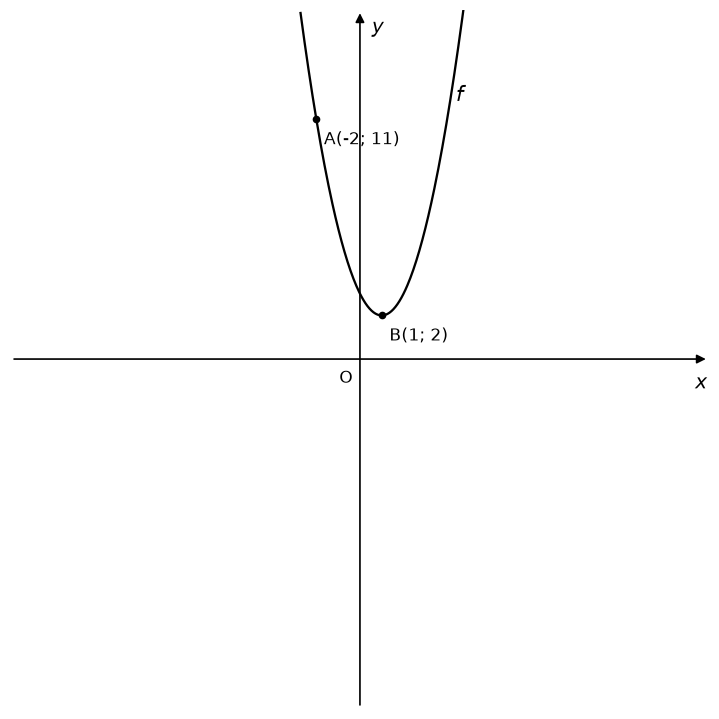



SHAPE B — x-intercepts given
The diagram shows a parabola f that cuts the x-axis at (-1; 0) and (3; 0). The y-intercept of f is (0; -9).

  1.1  (2 marks)  [functions.parabola.intercepts]
      Write down the equation of f in the form y = a(x - r1)(x - r2).
      Expected: y = a(x - (-1))(x - (3))
      Steps:
        1. x-intercepts are -1 and 3.
        2. So f(x) = a(x - (-1))(x - (3)).

  1.2  (3 marks)  [functions.parabola.parameter]
      Calculate the value of a.
      Expected: a = 3
      Steps:
        1. Substitute the y-intercept (0; -9) into f(x) = a(x - (-1))(x - (3)).
        2. -9 = a(0 - (-1))(0 - (3))
        3. -9 = a(-3)
        4. a = 3

  1.3  (3 marks)  [functions.parabola.equation]
      Write down the equation of f in the form y = ax^2 + bx + c.
      Expected: f(x) = 3x^2 - 6x - 9
      Steps:
        1. Start from f(x) = 3(x - (-1))(x - (3)).
        2. Expand the brackets: (x - (-1))(x - (3)) = x^2 - 2x - 3
        3. Multiply by a = 3: 3x^2 - 6x - 9
     

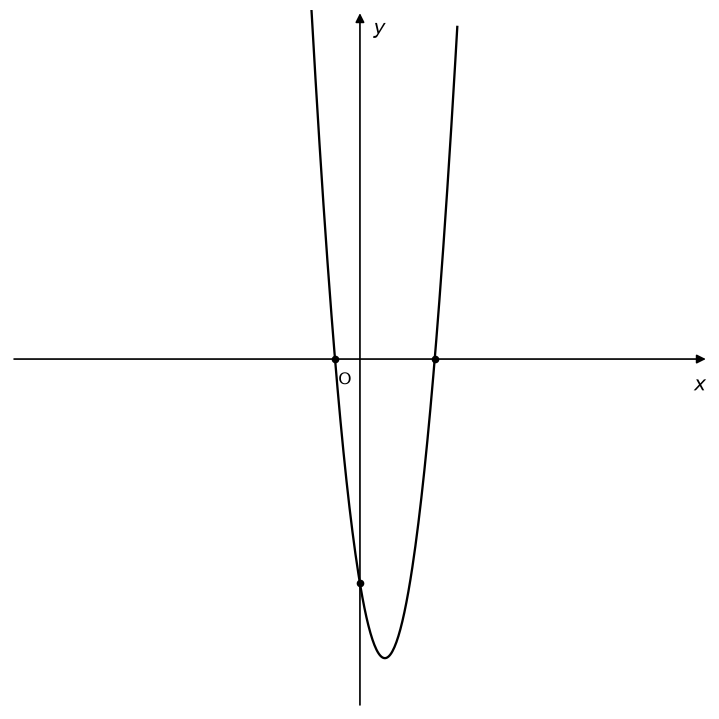

In [ ]:
import importlib, sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

from IPython.display import Image, display

for shape, label in [("turning_point", "SHAPE A — turning point given"),
                     ("two_roots", "SHAPE B — x-intercepts given")]:
    print("=" * 70)
    print(label)
    print("=" * 70)
    items = sg.gen_scenario_parabola(count=1, seed=5, shape=shape, render=True)
    if not items:
        print("  (generation failed)")
        continue
    item = items[0]
    print(item["problem"])
    print()
    for s in item["subquestions"]:
        print(f"  {s['n']}  ({s['marks']} marks)  [{s['skill_id']}]")
        print(f"      {s['prompt']}")
        print(f"      Expected: {s['expected']}")
        print(f"      Steps:")
        for i, step in enumerate(s["steps"], 1):
            print(f"        {i}. {step}")
        print()
    print(f"Total: {item['total_marks']} marks")
    print()
    display(Image(filename=item["diagram_path"], width=520))
    print("\n")

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- 1. Add a helper: format a factor from a root ---
helper = '''def _factor_from_root(r):
    """Given a root r, return the factor string:
       r = 3  -> '(x - 3)'
       r = -1 -> '(x + 1)'
       r = 0  -> '(x)'
    """
    if r == 0:
        return "(x)"
    if r > 0:
        return f"(x - {r})"
    return f"(x + {abs(r)})"


def _factor_display(root, value_at_root):
    """Show the substitution: 'x - (-1)' style cleaned.
       Useful for evaluating (0 - r) in memo steps.
    """
    if root == 0:
        return f"({value_at_root})"
    return f"({value_at_root} {'+' if root < 0 else '-'} {abs(root)})"


'''

anchor = "def _fnum(v):"
if "_factor_from_root" not in src:
    src = src.replace(anchor, helper + anchor, 1)
    print("1. Added _factor_from_root helper.")
else:
    print("1. Helper already present.")

# --- 2. Shape A: fix the memo strings that hardcode '(x - ({p}))' ---
shape_a_fixes = [
    # Substitution steps
    (
        '''                     f"Substitute A({x_a}; {_fnum(y_a)}) into "
                     f"f(x) = a(x - {p})^2"
                     + (" " + _signed_term(q) if q != 0 else ""),
                     f"{_fnum(y_a)} = a({x_a} - {p})^2"
                     + (" " + _signed_term(q) if q != 0 else ""),''',
        '''                     f"Substitute A({x_a}; {_fnum(y_a)}) into "
                     f"f(x) = a{_factor_from_root(p)}^2"
                     + (" " + _signed_term(q) if q != 0 else ""),
                     f"{_fnum(y_a)} = a({_fnum(x_a)} {('+' if p < 0 else '-')} "
                     f"{abs(p)})^2" + (" " + _signed_term(q) if q != 0 else ""),'''
    ),
    # Expand the square
    (
        '''                     f"Expand the square: (x - {p})^2 = x^2 "
                     + _signed_term(b_coef // a, "x") + " " + _signed_term(p * p),''',
        '''                     f"Expand the square: {_factor_from_root(p)}^2 = x^2 "
                     + _signed_term(b_coef // a, "x") + " " + _signed_term(p * p),'''
    ),
    # Start from
    (
        '''                     f"Start from f(x) = {a}(x - {p})^2"
                     + (" " + _signed_term(q) if q != 0 else ""),''',
        '''                     f"Start from f(x) = {a}{_factor_from_root(p)}^2"
                     + (" " + _signed_term(q) if q != 0 else ""),'''
    ),
]

for old, new in shape_a_fixes:
    if old in src:
        src = src.replace(old, new, 1)
        print("   Shape A: fixed a memo string.")
    else:
        print("   Shape A: WARN — pattern not found.")

# --- 3. Shape B: fix the memo strings ---
shape_b_fixes = [
    # 1.1 expected + steps
    (
        '''                 "expected": f"y = a(x - {r1})(x - {r2})",
                 "steps": [
                     f"x-intercepts are {r1} and {r2}.",
                     f"So f(x) = a(x - {r1})(x - {r2}).",
                 ],''',
        '''                 "expected": f"y = a{_factor_from_root(r1)}{_factor_from_root(r2)}",
                 "steps": [
                     f"x-intercepts are {r1} and {r2}.",
                     f"So f(x) = a{_factor_from_root(r1)}{_factor_from_root(r2)}.",
                 ],'''
    ),
    # 1.2 substitution
    (
        '''                 "steps": [
                     f"Substitute the y-intercept (0; {c}) into "
                     f"f(x) = a(x - {r1})(x - {r2}).",
                     f"{c} = a(0 - {r1})(0 - {r2})",
                     f"{c} = a({(-r1) * (-r2)})",
                     f"a = {a}",
                 ],''',
        '''                 "steps": [
                     f"Substitute the y-intercept (0; {c}) into "
                     f"f(x) = a{_factor_from_root(r1)}{_factor_from_root(r2)}.",
                     f"{c} = a({0 - r1})({0 - r2})",
                     f"{c} = a({(-r1) * (-r2)})",
                     f"a = {a}",
                 ],'''
    ),
    # 1.3 expand
    (
        '''                 "steps": [
                     f"Start from f(x) = {a}(x - {r1})(x - {r2}).",
                     f"Expand the brackets: (x - {r1})(x - {r2}) = "
                     f"x^2 " + _signed_term(-(r1 + r2), "x") + " "
                     + _signed_term(r1 * r2),''',
        '''                 "steps": [
                     f"Start from f(x) = {a}{_factor_from_root(r1)}{_factor_from_root(r2)}.",
                     f"Expand the brackets: {_factor_from_root(r1)}{_factor_from_root(r2)} = "
                     f"x^2 " + _signed_term(-(r1 + r2), "x") + " "
                     + _signed_term(r1 * r2),'''
    ),
    # 1.5 inequality — better reasoning
    (
        '''                 "steps": [
                     "f(x) > 0 means the curve lies above the x-axis.",
                     f"The x-intercepts divide the x-axis into three regions.",
                     f"Because a {'>' if a > 0 else '<'} 0, f(x) > 0 for "
                     f"{ineq_ans}.",
                 ],''',
        '''                 "steps": [
                     "f(x) > 0 means the curve lies above the x-axis.",
                     f"The x-intercepts ({r1} and {r2}) divide the x-axis into "
                     "three regions: left of the smaller root, between the "
                     "roots, and right of the larger root.",
                     f"a = {a} {'>' if a > 0 else '<'} 0, so the parabola "
                     f"opens {'up' if a > 0 else 'down'}.",
                     ("Therefore f(x) > 0 OUTSIDE the roots: "
                      if a > 0 else
                      "Therefore f(x) > 0 BETWEEN the roots: ")
                     + f"{ineq_ans}.",
                 ],'''
    ),
]

for old, new in shape_b_fixes:
    if old in src:
        src = src.replace(old, new, 1)
        print("   Shape B: fixed a memo string.")
    else:
        print("   Shape B: WARN — pattern not found.")

# --- 4. Update the diagram sig generation for Shape A so the filename reflects the point ---
# (already done — no change needed)

sp.write_text(src, encoding="utf-8")
print(f"\nModule now {len(src.splitlines())} lines.")

1. Added _factor_from_root helper.
   Shape A: WARN — pattern not found.
   Shape A: WARN — pattern not found.
   Shape A: WARN — pattern not found.
   Shape B: WARN — pattern not found.
   Shape B: WARN — pattern not found.
   Shape B: WARN — pattern not found.
   Shape B: fixed a memo string.

Module now 803 lines.


In [ ]:
from pathlib import Path
sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")
lines = src.splitlines()

# Find all lines mentioning "x - (" or "(x - (" — the ones we want to clean
print("=== Lines with '(x - (' (double parens to fix) ===")
for i, l in enumerate(lines, 1):
    if "(x - (" in l or "(x - {" in l and "}(" in l:
        print(f"{i:4d}  {l.rstrip()}")

print()
print("=== Shape A: substitution / expand memo lines ===")
in_shape_a = False
for i, l in enumerate(lines, 1):
    if "def gen_scenario_parabola(" in l:
        in_shape_a = True
    if in_shape_a and ('Substitute A(' in l or 'Expand the square' in l
                       or 'Start from f(x)' in l):
        # print the block
        for j in range(i-1, min(i+4, len(lines))):
            print(f"{j+1:4d}  {lines[j].rstrip()}")
        print()

print()
print("=== Shape B: memo strings ===")
in_shape_b = False
for i, l in enumerate(lines, 1):
    if "else:  # two_roots" in l:
        in_shape_b = True
    if in_shape_b and ('expected": f"y = a(x -' in l
                       or 'Substitute the y-intercept' in l
                       or 'Start from f(x) = {a}(x -' in l):
        for j in range(max(0, i-2), min(i+6, len(lines))):
            print(f"{j+1:4d}  {lines[j].rstrip()}")
        print()

# Show lines 400-500 for context
print("=== Full section: lines 400-460 (Shape A memo area) ===")
for i in range(399, min(460, len(lines))):
    print(f"{i+1:4d}  {lines[i]}")

=== Lines with '(x - (' (double parens to fix) ===
 331          f_eq_str = (f"f(x) = {a}/(x - ({p}))"
 360                   f"So f(x) = a/(x - ({p}))"
 375                   f"{a}/(x - ({p}))"
 378                   f"Multiply through by (x - ({p})) and simplify to a quadratic.",
 592                       f"f(x) = a(x - ({p}))^2"
 606                       f"Start from f(x) = {a}(x - ({p}))^2"
 608                       f"Expand the square: (x - ({p}))^2 = x^2 "
 710                   "expected": f"y = a(x - ({r1}))(x - ({r2}))",
 713                       f"So f(x) = a(x - ({r1}))(x - ({r2})).",
 722                       f"f(x) = a(x - ({r1}))(x - ({r2})).",
 734                       f"Start from f(x) = {a}(x - ({r1}))(x - ({r2})).",
 735                       f"Expand the brackets: (x - ({r1}))(x - ({r2})) = "

=== Shape A: substitution / expand memo lines ===
 591                       f"Substitute A({x_a}; {_fnum(y_a)}) into "
 592                       f"f(x) = a(x - ({p}))^2

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- Shape A fixes (lines 592, 594, 606, 608-609) ---
fixes_a = [
    # Substitution line 1
    ('f"f(x) = a(x - ({p}))^2"',
     'f"f(x) = a{_factor_from_root(p)}^2"'),
    # Substitution line 2
    ('f"{_fnum(y_a)} = a({x_a} - ({p}))^2"',
     'f"{_fnum(y_a)} = a{_factor_display(p, _fnum(x_a))}^2"'),
    # Start from
    ('f"Start from f(x) = {a}(x - ({p}))^2"',
     'f"Start from f(x) = {a}{_factor_from_root(p)}^2"'),
    # Expand square — use _factor_from_root and integer division
    ('f"Expand the square: (x - ({p}))^2 = x^2 "',
     'f"Expand the square: {_factor_from_root(p)}^2 = x^2 "'),
    ('+ _signed_term(b_coef / a, "x") + " " + _signed_term(p * p),',
     '+ _signed_term(int(b_coef / a) if b_coef % a == 0 else b_coef / a, "x") + " " + _signed_term(p * p),'),
]

for old, new in fixes_a:
    count = src.count(old)
    if count == 0:
        print(f"Shape A: NOT FOUND  → {old[:60]}")
    else:
        src = src.replace(old, new)
        print(f"Shape A: replaced {count}× {old[:50]}")

# --- Shape B fixes ---
fixes_b = [
    # 1.1 expected
    ('"expected": f"y = a(x - ({r1}))(x - ({r2}))"',
     '"expected": f"y = a{_factor_from_root(r1)}{_factor_from_root(r2)}"'),
    # 1.1 steps
    ('f"So f(x) = a(x - ({r1}))(x - ({r2}))."',
     'f"So f(x) = a{_factor_from_root(r1)}{_factor_from_root(r2)}."'),
    # 1.2 substitution — line 1
    ('f"f(x) = a(x - ({r1}))(x - ({r2}))."',
     'f"f(x) = a{_factor_from_root(r1)}{_factor_from_root(r2)}."'),
    # 1.2 substitution — line 2
    ('f"{c} = a(0 - ({r1}))(0 - ({r2}))"',
     'f"{c} = a({-r1})({-r2})"'),
    # 1.3 start from
    ('f"Start from f(x) = {a}(x - ({r1}))(x - ({r2}))."',
     'f"Start from f(x) = {a}{_factor_from_root(r1)}{_factor_from_root(r2)}."'),
    # 1.3 expand
    ('f"Expand the brackets: (x - ({r1}))(x - ({r2})) = "',
     'f"Expand the brackets: {_factor_from_root(r1)}{_factor_from_root(r2)} = "'),
    # 1.3 expand square — no change needed but the "x^2" line
]

for old, new in fixes_b:
    count = src.count(old)
    if count == 0:
        print(f"Shape B: NOT FOUND  → {old[:60]}")
    else:
        src = src.replace(old, new)
        print(f"Shape B: replaced {count}× {old[:50]}")

sp.write_text(src, encoding="utf-8")
print(f"\nModule now {len(src.splitlines())} lines.")

Shape A: replaced 1× f"f(x) = a(x - ({p}))^2"
Shape A: replaced 1× f"{_fnum(y_a)} = a({x_a} - ({p}))^2"
Shape A: replaced 1× f"Start from f(x) = {a}(x - ({p}))^2"
Shape A: replaced 1× f"Expand the square: (x - ({p}))^2 = x^2 "
Shape A: replaced 1× + _signed_term(b_coef / a, "x") + " " + _signed_te
Shape B: replaced 1× "expected": f"y = a(x - ({r1}))(x - ({r2}))"
Shape B: replaced 1× f"So f(x) = a(x - ({r1}))(x - ({r2}))."
Shape B: replaced 1× f"f(x) = a(x - ({r1}))(x - ({r2}))."
Shape B: replaced 1× f"{c} = a(0 - ({r1}))(0 - ({r2}))"
Shape B: replaced 1× f"Start from f(x) = {a}(x - ({r1}))(x - ({r2}))."
Shape B: replaced 1× f"Expand the brackets: (x - ({r1}))(x - ({r2})) = 

Module now 803 lines.


SHAPE A — turning point given
The diagram shows the graph of a parabola f. The turning point of f is B(1; 2) and A(-2; 11) is a point on f.

  1.1  (2m)
      Q: Write down the equation of f in the form f(x) = a(x - p)^2 + q, showing the values of p and q.
      A: p = 1, q = 2
         1. The turning point is (1; 2).
         2. For f(x) = a(x - p)^2 + q, the turning point is (p; q).
         3. Therefore p = 1 and q = 2.

  1.2  (3m)
      Q: Calculate the value of a.
      A: a = 1
         1. Substitute A(-2; 11) into f(x) = a(x - 1)^2 + 2
         2. 11 = a(-2 - 1)^2 + 2
         3. 9 = a(9)
         4. a = 1

  1.3  (3m)
      Q: Write down the equation of f in the form y = ax^2 + bx + c.
      A: f(x) = x^2 - 2x + 3
         1. Start from f(x) = 1(x - 1)^2 + 2
         2. Expand the square: (x - 1)^2 = x^2 - 2x + 1
         3. Multiply by a = 1: 1x^2 - 2x + 1
         4. Add q = 2.
         5. f(x) = x^2 - 2x + 3

  1.4  (2m)
      Q: Write down the range of f.
      A: y >= 2
 

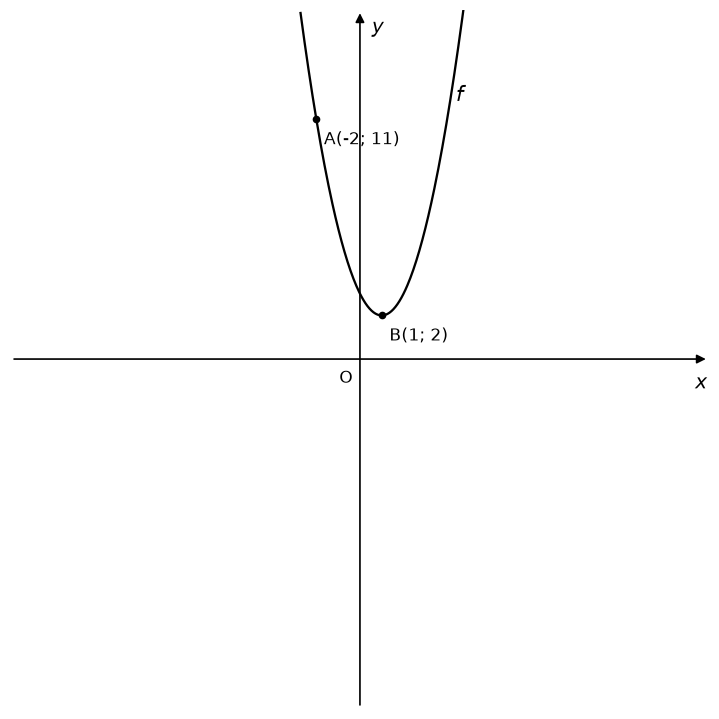



SHAPE B — x-intercepts given
The diagram shows a parabola f that cuts the x-axis at (-1; 0) and (3; 0). The y-intercept of f is (0; -9).

  1.1  (2m)
      Q: Write down the equation of f in the form y = a(x - r1)(x - r2).
      A: y = a(x + 1)(x - 3)
         1. x-intercepts are -1 and 3.
         2. So f(x) = a(x + 1)(x - 3).

  1.2  (3m)
      Q: Calculate the value of a.
      A: a = 3
         1. Substitute the y-intercept (0; -9) into f(x) = a(x + 1)(x - 3).
         2. -9 = a(1)(-3)
         3. -9 = a(-3)
         4. a = 3

  1.3  (3m)
      Q: Write down the equation of f in the form y = ax^2 + bx + c.
      A: f(x) = 3x^2 - 6x - 9
         1. Start from f(x) = 3(x + 1)(x - 3).
         2. Expand the brackets: (x + 1)(x - 3) = x^2 - 2x - 3
         3. Multiply by a = 3: 3x^2 - 6x - 9
         4. f(x) = 3x^2 - 6x - 9

  1.4  (3m)
      Q: Write down the coordinates of the turning point of f.
      A: (1; -12)
         1. By symmetry, the x-coordinate of the turning point is th

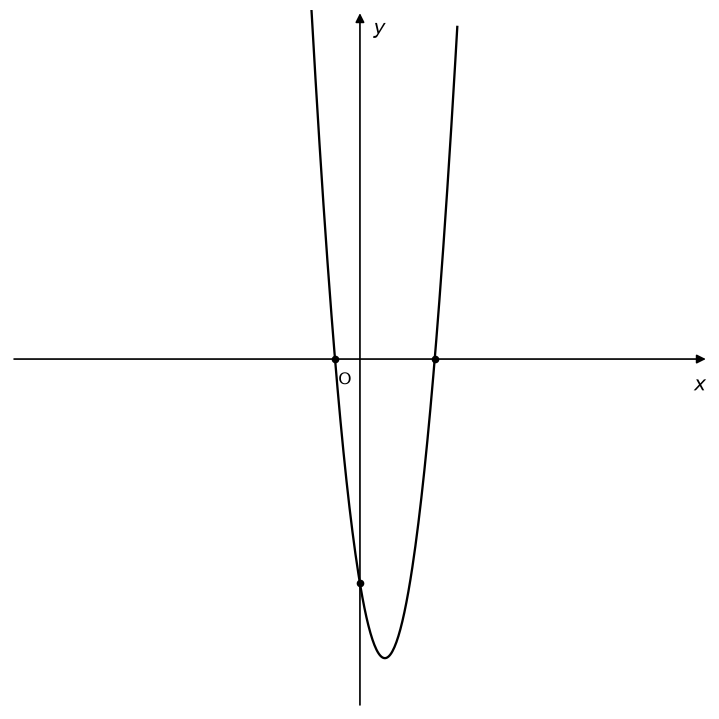

In [ ]:
import importlib, sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

from IPython.display import Image, display

for shape, label in [("turning_point", "SHAPE A — turning point given"),
                     ("two_roots", "SHAPE B — x-intercepts given")]:
    print("=" * 72)
    print(label)
    print("=" * 72)
    items = sg.gen_scenario_parabola(count=1, seed=5, shape=shape, render=True)
    if not items:
        print("  (generation FAILED)")
        continue
    item = items[0]
    print(item["problem"])
    print()
    for s in item["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)")
        print(f"      Q: {s['prompt']}")
        print(f"      A: {s['expected']}")
        for i, step in enumerate(s["steps"], 1):
            print(f"         {i}. {step}")
        print()
    if item["diagram_path"]:
        display(Image(filename=item["diagram_path"], width=520))
    print("\n")

In [ ]:
from pathlib import Path

sp = ROOT / "src" / "tutor" / "scenario_generators.py"
src = sp.read_text(encoding="utf-8")

# --- Small cleanups to hide "1" coefficient in parabola memos ---
cleanups = [
    # Shape A 1.3 Start from: hide 1
    ('f"Start from f(x) = {a}{_factor_from_root(p)}^2"',
     'f"Start from f(x) = {\'\' if a == 1 else (a if a != -1 else \'-\')}{_factor_from_root(p)}^2"'),
    # Shape A 1.3 Multiply by a: hide 1 in coefficient of x^2
    ('+ f"{a}x^2 " + _signed_term(b_coef, "x") + " "\n                       + _signed_term(a * p * p),',
     '+ f"{\'\' if a == 1 else (a if a != -1 else \'-\')}x^2 " + _signed_term(b_coef, "x") + " "\n                       + _signed_term(a * p * p),'),
]
for old, new in cleanups:
    if old in src:
        src = src.replace(old, new, 1)
        print(f"Applied cleanup: {old[:50]}...")
    else:
        print(f"Cleanup NOT FOUND: {old[:50]}...")

# --- Remove the redundant back-compat line at bottom and append exponential ---
exp_code = '''

# ============================================================
# Exponential + line scenario (NEW)
# Reference: 2020 P1 Q5 shape.
#   f(x) = a*b^x + q meets the horizontal line y = k at one point B.
#   Subquestions: y-intercept A, coordinate of B, domain of inverse,
#   translation, inequality.
# ============================================================

def _try_exponential_params(rng):
    """Return (base, q, k) where:
       f(x) = base^x + q
       line y = k intersects f at x = x_b such that base^x_b is a
       clean integer.
    """
    # base must be a positive rational > 0, != 1, representable as fraction
    base_options = [
        (2, 1), (3, 1), (4, 1),
        (1, 2), (1, 3),
    ]
    num, den = rng.choice(base_options)
    base = num / den

    # Pick x_b such that base^x_b is a nice value
    # We'll pick x_b integer and let y_b = base^x_b (must be rational, may
    # be fractional for base = 1/2, 1/3)
    x_b_options = [-2, -1, 1, 2]
    x_b = rng.choice(x_b_options)
    y_b = (num ** x_b) / (den ** x_b)
    # Keep y_b moderate
    if not (0.1 <= y_b <= 20):
        return None

    # q must give integer (or clean rational) y-intercept
    q_options = [-2, -1, 1, 2]
    q = rng.choice(q_options)

    # Line y = k where k = y_b + q must be a clean number
    k = y_b + q
    if not (0.1 <= k <= 20):
        return None

    # Also ensure y-intercept base^0 + q = 1 + q is clean
    y_a = 1 + q

    return num, den, q, k, x_b, y_b, y_a


def _base_display(num, den):
    if den == 1:
        return str(num)
    return f"{num}/{den}"


def _render_exponential(num, den, q, k, x_b, y_b, y_a, sig):
    import numpy as np
    import matplotlib.pyplot as plt
    DIAGRAM_DIR.mkdir(parents=True, exist_ok=True)
    path = DIAGRAM_DIR / f"{sig}.png"

    base = num / den
    # Pick a range that captures the interesting behaviour
    x_lo, x_hi = -6, 6
    if base < 1:
        # exponential decay: y approaches q as x -> +inf
        pass
    # Y window
    key_y = [q, k, y_a, 0]
    span_y = max(abs(v) for v in key_y) + 3
    lim_y = int(np.ceil(span_y / 2) * 2)
    lim_y = max(lim_y, 6)
    lim = lim_y

    fig, ax = _setup_plane(lim)

    # Draw horizontal asymptote y = q
    _draw_horizontal_asymptote(ax, q, lim)

    # Draw exponential curve
    xs = np.linspace(-lim, lim, 500)
    ys = base ** xs + q
    mask = (ys >= -lim) & (ys <= lim)
    ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    # Draw horizontal line y = k (dotted)
    ax.plot([-lim, lim], [k, k], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)

    # Ticks: y_a on y-axis, k on y-axis
    _draw_axes_ticks(ax, x_ticks=[x_b], y_ticks=sorted(set([y_a, int(k) if k == int(k) else k, q])))

    # Points: A = y-intercept, B = intersection with y=k
    _draw_point(ax, 0, y_a, label="A", show_coords=True, offset="up-left")
    _draw_point(ax, x_b, y_b + q, label="B", show_coords=True, offset="up-right")

    # Curve label
    ax.text(lim * 0.55, q + 1.5, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    return path


def gen_scenario_exponential(count=10, seed=301, render=True):
    """DBE-style exponential + horizontal-line questions.

    Reference: 2020 P1 Q5 shape.
    """
    rng = random.Random(seed)
    out = []
    attempts = 0
    while len(out) < count and attempts < 20000:
        attempts += 1
        params = _try_exponential_params(rng)
        if params is None:
            continue
        num, den, q, k, x_b, y_b, y_a = params

        base_str = _base_display(num, den)
        sig = f"exp_{num}_{den}_{q}_{int(k*10)}_{x_b}"
        dpath = None
        if render:
            try:
                dpath = str(_render_exponential(num, den, q, k,
                                                 x_b, y_b, y_a, sig))
            except Exception as e:
                print(f"    render error: {e}")
                dpath = None

        # f(x) = base^x + q
        if den == 1:
            f_eq = f"f(x) = {num}^x" + (" " + _signed_term(q) if q != 0 else "")
        else:
            f_eq = f"f(x) = ({base_str})^x" + (" " + _signed_term(q) if q != 0 else "")

        # Translation h(x) = base^(x - t) + q  (shift right by t)
        t = rng.choice([1, 2, 3])
        h_eq = (f"h(x) = {num}^(x - {t})" if den == 1
                else f"h(x) = ({base_str})^(x - {t})")
        if q != 0:
            h_eq += " " + _signed_term(q)

        # Domain of inverse of f: range of f is (q, +inf) if base > 1
        # and (q, +inf) still if 0 < base < 1 (asymptote at y = q)
        if q == 0:
            inv_domain = "x > 0" if num > den else "x > 0"
        else:
            inv_domain = f"x > {q}" if q > 0 else f"x > {q}"

        problem = (
            f"The graph of {f_eq} is sketched. "
            f"A is the y-intercept of f. "
            f"B is the point of intersection of f and the line y = {_fnum(k)}."
        )

        subs = [
            {"n": "1.1",
             "prompt": "Write down the coordinates of A, the y-intercept of f.",
             "expected": f"A(0; {_fnum(y_a)})",
             "steps": [
                 "The y-intercept is where x = 0.",
                 f"f(0) = {base_str}^0" + (" " + _signed_term(q) if q != 0 else ""),
                 f"= 1" + (" " + _signed_term(q) if q != 0 else ""),
                 f"= {_fnum(y_a)}.",
                 f"A(0; {_fnum(y_a)})",
             ],
             "marks": 1,
             "skill_id": "functions.exponential.intercept"},
            {"n": "1.2",
             "prompt": f"Determine the coordinates of B, the point of "
                       f"intersection of f and the line y = {_fnum(k)}.",
             "expected": f"B({x_b}; {_fnum(k)})",
             "steps": [
                 f"Set f(x) = {_fnum(k)}:",
                 f"{base_str}^x" + (" " + _signed_term(q) if q != 0 else "")
                 + f" = {_fnum(k)}",
                 (f"{base_str}^x = {_fnum(k - q)}" if q != 0
                  else f"{base_str}^x = {_fnum(k)}"),
                 f"Recognise {_fnum(k - q) if q != 0 else _fnum(k)} = "
                 f"{base_str}^{x_b}.",
                 f"So x = {x_b}.",
                 f"Since B is on the line y = {_fnum(k)}, B({x_b}; {_fnum(k)}).",
             ],
             "marks": 3,
             "skill_id": "functions.exponential.intersection"},
            {"n": "1.3",
             "prompt": "Write down the equation of the horizontal asymptote of f.",
             "expected": f"y = {_fnum(q)}",
             "steps": [
                 "The horizontal asymptote of f(x) = a*b^x + q is y = q.",
                 f"From the equation, q = {_fnum(q)}.",
                 f"y = {_fnum(q)}",
             ],
             "marks": 2,
             "skill_id": "functions.exponential.asymptote"},
            {"n": "1.4",
             "prompt": "Write down the domain of f^{-1}, the inverse of f.",
             "expected": inv_domain,
             "steps": [
                 "The domain of f^{-1} is the range of f.",
                 f"The range of f is y > {_fnum(q)} "
                 f"(the curve approaches the asymptote but never reaches it).",
                 f"So the domain of f^{-1} is {inv_domain}.",
             ],
             "marks": 2,
             "skill_id": "functions.exponential.inverse"},
            {"n": "1.5",
             "prompt": f"Describe the transformation that maps f to "
                       f"h(x) = {h_eq.split('= ')[1]}.",
             "expected": f"f translated {t} unit{'s' if t != 1 else ''} to the right",
             "steps": [
                 f"f(x) = {f_eq.split('= ')[1]}",
                 f"h(x) = {h_eq.split('= ')[1]}",
                 f"In h, x has been replaced by (x - {t}).",
                 f"Transformation: {t} unit{'s' if t != 1 else ''} to the right.",
             ],
             "marks": 2,
             "skill_id": "functions.transformation"},
        ]

        out.append({
            "scenario": "exponential_line",
            "skill_id": "functions.exponential",
            "problem": problem,
            "diagram_path": dpath,
            "subquestions": subs,
            "total_marks": sum(s["marks"] for s in subs),
            "parameters": {"num": num, "den": den, "q": q, "k": k,
                           "x_b": x_b, "y_b": y_b, "y_a": y_a, "t": t},
        })
    return out


# Update the registry
ALL_SCENARIOS = {
    "hyperbola_line":          gen_scenario_hyperbola_line,
    "parabola_turning_point":  lambda **kw: gen_scenario_parabola(shape="turning_point", **kw),
    "parabola_two_roots":      lambda **kw: gen_scenario_parabola(shape="two_roots", **kw),
    "exponential_line":        gen_scenario_exponential,
}
'''

# Remove the old registry block and append the new one
import re
old_registry = '''# ============================================================
# Registry — for the drill to discover scenarios
# ============================================================

ALL_SCENARIOS = {
    "hyperbola_line":       gen_scenario_hyperbola_line,
    "parabola_turning_point": lambda **kw: gen_scenario_parabola(shape="turning_point", **kw),
    "parabola_two_roots":     lambda **kw: gen_scenario_parabola(shape="two_roots", **kw),
}
'''

if old_registry in src:
    src = src.replace(old_registry, "", 1)
    print("Removed old registry block.")

src = src.rstrip() + exp_code

sp.write_text(src, encoding="utf-8")
print(f"\nModule now {len(src.splitlines())} lines.")

Applied cleanup: f"Start from f(x) = {a}{_factor_from_root(p)}^2"...
Cleanup NOT FOUND: + f"{a}x^2 " + _signed_term(b_coef, "x") + " "
   ...
Removed old registry block.

Module now 1035 lines.


In [ ]:
import importlib, sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.scenario_generators as sg
importlib.reload(sg)

d = ROOT / "data" / "processed" / "tutor" / "scenario_diagrams"
if d.exists():
    for f in d.glob("*.png"):
        f.unlink()

from IPython.display import Image, display

print("=" * 72)
print("EXPONENTIAL + LINE")
print("=" * 72)
items = sg.gen_scenario_exponential(count=2, seed=11, render=True)
print(f"Generated {len(items)} scenarios\n")

for item in items:
    print(item["problem"])
    print()
    for s in item["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)")
        print(f"      Q: {s['prompt']}")
        print(f"      A: {s['expected']}")
        for i, step in enumerate(s["steps"], 1):
            print(f"         {i}. {step}")
        print()
    print(f"Total: {item['total_marks']} marks")
    print()
    if item["diagram_path"]:
        display(Image(filename=item["diagram_path"], width=520))
    print()

In [ ]:
import json
import re
import pandas as pd
from pathlib import Path

MEMO_DIR = ROOT / "data" / "processed" / "memo_answers"
STEP_DIR = ROOT / "data" / "processed" / "memo_step_marks"
DIAG     = ROOT / "data" / "processed" / "diagnostics" / "diagnostic_errors_with_skill.csv"
MAP_DIR  = ROOT / "data" / "processed" / "mapped"
PAGES    = ROOT / "data" / "processed" / "diagrams" / "pages"
QPM_PATH = ROOT / "data" / "processed" / "diagrams" / "question_page_map.json"
OUT_DIR  = ROOT / "data" / "processed" / "tutor" / "templates"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def extract_template(year, paper):
    """Build one JSON template per question on the paper."""
    paper = paper.upper()
    memo_path = MEMO_DIR / f"memo_answers_{year}_{paper}.csv"
    step_path = STEP_DIR / f"memo_step_marks_{year}_{paper}.csv"
    map_path  = MAP_DIR / str(year) / f"question_topic_map_{year}_v2.csv"

    if not memo_path.exists():
        print(f"  MISSING: {memo_path}")
        return []

    memo = pd.read_csv(memo_path)
    steps = pd.read_csv(step_path) if step_path.exists() else pd.DataFrame()
    qmap = pd.read_csv(map_path) if map_path.exists() else pd.DataFrame()

    # Question text from topic map (falls back to empty)
    qt_lookup = {}
    if len(qmap):
        qmap["_sub"] = qmap["subquestion"].astype(str).str.strip()
        qmap["_pap"] = qmap["paper"].astype(str).str.upper()
        for _, r in qmap.iterrows():
            qt_lookup[(r["_pap"], r["_sub"])] = str(r.get("question_text", "") or "")

    # Diagnostic context per skill (from the diagnostic file)
    diag_df = pd.read_csv(DIAG)
    diag_by_skill = {}
    for sid, g in diag_df.groupby("skill_id"):
        classes = g["error_class"].value_counts().to_dict()
        diag_by_skill[sid] = {
            "total": int(len(g)),
            "classes": {k: int(v) for k, v in classes.items()
                        if k != "general"},
            "diagram_assumption_pct": round(
                (g["diagram_assumption"].astype(str) == "True").mean() * 100, 1),
        }

    # Question -> page mapping
    qpm = {}
    if QPM_PATH.exists():
        qpm = json.loads(QPM_PATH.read_text(encoding="utf-8"))
    stem = f"{year}_nov_p{paper[1]}_exam_maths"
    paper_pages = qpm.get(stem, {})

    templates = []
    # Group memo subquestions by question_number
    memo["_qnum"] = memo["question_number"].astype(str).str.strip()
    for qnum, group in memo.groupby("_qnum", sort=False):
        subs = []
        for _, r in group.iterrows():
            sq = str(r["subquestion"]).strip()
            skill = str(r["skill_id"]).strip() if pd.notna(r["skill_id"]) else ""
            subs.append({
                "n": sq,
                "marks": int(r["marks"]) if pd.notna(r["marks"]) else 0,
                "skill_id": skill,
                "expected": str(r["expected_answer"]).strip() if pd.notna(r["expected_answer"]) else "",
                "question_text": qt_lookup.get((paper, sq), ""),
                "steps": [],
                "diagnostic": diag_by_skill.get(skill, {}),
            })

        # Attach step-mark sequences
        if len(steps):
            steps["_qid"] = steps["question_id"].astype(str)
            for s in subs:
                qid = f"{year}_{paper}_Q{s['n']}"
                srows = steps[steps["_qid"] == qid].sort_values("step_index")
                if len(srows):
                    s["steps"] = [
                        {
                            "i": int(row["step_index"]),
                            "desc": str(row["step_description"]),
                            "memo_line": str(row["memo_line"]),
                            "marks": int(row["marks"]) if pd.notna(row["marks"]) else 0,
                            "method_tag": str(row.get("method_tag", "")),
                            "is_final": str(row["is_final"]).lower() == "true",
                        }
                        for _, row in srows.iterrows()
                    ]

        # Question stem — heuristic: first sub's question_text, or a null block
        stem_text = subs[0]["question_text"] if subs and subs[0]["question_text"] else ""

        t = {
            "source": {"year": int(year), "paper": paper, "question_number": qnum},
            "stem_text": stem_text,
            "subquestions": subs,
            "total_marks": sum(s["marks"] for s in subs),
            "diagram_page": paper_pages.get(qnum),
            "diagram_path": None,
        }
        if t["diagram_page"]:
            p = PAGES / f"{stem}_p{t['diagram_page']}.png"
            if p.exists():
                t["diagram_path"] = str(p)

        templates.append(t)

    return templates


# --- Extract 2024 P1 and 2024 P2 ---
for year, paper in [(2024, "P1"), (2024, "P2")]:
    print(f"=== {year} {paper} ===")
    ts = extract_template(year, paper)
    print(f"  {len(ts)} question templates extracted")

    out = OUT_DIR / f"templates_{year}_{paper}.json"
    out.write_text(json.dumps(ts, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  Wrote: {out}")
    for t in ts[:3]:
        print(f"    Q{t['source']['question_number']}  "
              f"{t['total_marks']} marks  "
              f"{len(t['subquestions'])} subs  "
              f"diagram={'Y' if t['diagram_path'] else 'N'}")
    print()

# --- Show one template in full so we can look at it ---
print("=" * 72)
print("FULL TEMPLATE — 2024 P1 Q5")
print("=" * 72)
p = OUT_DIR / "templates_2024_P1.json"
if p.exists():
    ts = json.loads(p.read_text(encoding="utf-8"))
    q5 = next((t for t in ts if t["source"]["question_number"] == "5"), None)
    if q5:
        print(f"Stem text: {q5['stem_text'][:200]}")
        print(f"Diagram: {q5['diagram_path']}")
        print(f"Total marks: {q5['total_marks']}")
        print()
        for s in q5["subquestions"]:
            print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
            print(f"    Q: {s['question_text'][:120]}")
            print(f"    Expected: {s['expected'][:100]}")
            print(f"    Diagnostic: {s['diagnostic']}")
            print(f"    Memo steps ({len(s['steps'])}):")
            for stp in s["steps"]:
                print(f"      {stp['i']}. [{stp['method_tag']}] {stp['desc']}  "
                      f"→ {stp['memo_line'][:50]}")
            print()
    else:
        print("  Q5 not found — try a different question number")

=== 2024 P1 ===
  12 question templates extracted
  Wrote: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P1.json
    Q1  27 marks  7 subs  diagram=Y
    Q2  14 marks  4 subs  diagram=Y
    Q3  10 marks  3 subs  diagram=Y

=== 2024 P2 ===
  11 question templates extracted
  Wrote: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P2.json
    Q1  10 marks  6 subs  diagram=Y
    Q2  10 marks  6 subs  diagram=Y
    Q3  19 marks  7 subs  diagram=Y

FULL TEMPLATE — 2024 P1 Q5
Stem text: 
Diagram: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\diagrams\pages\2024_nov_p1_exam_maths_p5.png
Total marks: 10

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: 
    Expected: p = -1
    Diagnostic: {'total': 1, 'classes': {'procedural': 1}, 'diagram_assumption_pct': 0.0}
    Memo steps (1):
      1. [hyperbola] State p  → p=-1

  5.2  (2m)  [functions

In [ ]:
import json
import pandas as pd
from pathlib import Path

MAP_DIR = ROOT / "data" / "processed" / "mapped"
OUT_DIR = ROOT / "data" / "processed" / "tutor" / "templates"

# --- 1. Raw topic map for 2024 P1 ---
print("=== Topic map 2024 P1 — Q5 rows ===")
tm = pd.read_csv(MAP_DIR / "2024" / "question_topic_map_2024_v2.csv")
q5 = tm[(tm["paper"].astype(str).str.upper() == "P1")
        & (tm["question_number"].astype(str) == "5")]
print(q5[["subquestion", "question_text", "topic_v2", "signature_id_v2"]].to_string(index=False))
print()

# --- 2. What the JSON template has ---
print("=== JSON template for 2024 P1 Q5 ===")
ts = json.loads((OUT_DIR / "templates_2024_P1.json").read_text(encoding="utf-8"))
q5t = next(t for t in ts if t["source"]["question_number"] == "5")
print(f"stem_text: {q5t['stem_text']!r}")
for s in q5t["subquestions"]:
    print(f"  {s['n']}: {s['question_text']!r}")
print()

# --- 3. What the memo_answers has for question_text_short ---
print("=== memo_answers_2024_P1.csv — Q5 question_text_short ===")
ma = pd.read_csv(ROOT / "data" / "processed" / "memo_answers" / "memo_answers_2024_P1.csv")
q5ma = ma[ma["question_number"].astype(str) == "5"]
print(q5ma[["subquestion", "question_text_short"]].to_string(index=False))
print()

# --- 4. What the real paper says (from the extracted text) ---
print("=== Extracted exam text for 2024 P1 Q5 (raw) ===")
# The exam text file:
ex_path = ROOT / "data" / "processed" / "extracted_text" / "NSC_Mathematics_2024_Nov_P1_exam.txt"
if ex_path.exists():
    txt = ex_path.read_text(encoding="utf-8", errors="ignore")
    # Find Q5
    idx = txt.find("QUESTION 5")
    if idx == -1:
        idx = txt.find("Question 5")
    if idx >= 0:
        print(txt[idx:idx+900])
    else:
        print("(Q5 marker not found — showing around 'Skctched')")
        idx = txt.find("Skctched")
        if idx == -1:
            idx = txt.find("Sketched")
        if idx >= 0:
            print(txt[idx:idx+900])

=== Topic map 2024 P1 — Q5 rows ===
Empty DataFrame
Columns: [subquestion, question_text, topic_v2, signature_id_v2]
Index: []

=== JSON template for 2024 P1 Q5 ===
stem_text: ''
  5.1: ''
  5.2: '5.2 Determine the equation of the horizontal asymptote of f (2)'
  5.3: '5.3 Calculate the value of a. (2)'
  5.4: '5.4 For which values of x is f(x) >0? G3)'
  5.5: "5.5 Graph f undergoes a transformation to h where:\n\ne The domain and range of / are the same as that of f\n\ne A'(x), the derivative of h, is negative on its domain\n\nDescribe a possible transformation that f could have undergone to result in A. Q)\n\n[10]\n\nCopyright reserved Please turn over\n\nMathematics/P1 6 DBE/November 2024\nNSC Confidential"

=== memo_answers_2024_P1.csv — Q5 question_text_short ===
subquestion                 question_text_short
        5.1              Find p in f(x)=x/(x-p)
        5.2     y-intercept of g through (0;-3)
        5.3            Find a in g(x)=a/(x-1)+q
        5.4                  

In [ ]:
import pandas as pd
from pathlib import Path

MAP_DIR = ROOT / "data" / "processed" / "mapped"
EXTRACTED = ROOT / "data" / "processed" / "extracted_text"
OCR = ROOT / "data" / "processed" / "ocr" / "text"
PAGES = ROOT / "data" / "processed" / "diagrams" / "pages"

# --- 1. What rows ARE in the 2024 topic map? ---
print("=== 2024 topic map — all rows ===")
tm = pd.read_csv(MAP_DIR / "2024" / "question_topic_map_2024_v2.csv")
print(f"rows: {len(tm)}")
print(f"columns: {list(tm.columns)}")
print(tm.head(10).to_string(index=False))
print()
print(f"question_number values: {sorted(tm['question_number'].astype(str).unique().tolist())}")
print()

# --- 2. Page text for 2024 P1 page 5 (which has Q5) ---
print("=== 2024 P1 exam page 5 text (diagrams/pages) ===")
p = PAGES / "2024_nov_p1_exam_maths_p5.txt"
if p.exists():
    txt = p.read_text(encoding="utf-8", errors="ignore")
    print(txt[:2000])
else:
    print("MISSING:", p)
print()

# --- 3. What does the exam-extracted text file contain? ---
print("=== 2024 P1 exam extracted text (first 1500 chars) ===")
p = EXTRACTED / "NSC_Mathematics_2024_Nov_P1_exam.txt"
if p.exists():
    txt = p.read_text(encoding="utf-8", errors="ignore")
    print(f"file size: {len(txt)} chars")
    print(txt[:1500])
else:
    print("MISSING:", p)
print()

# --- 4. What does the OCR text file contain? ---
print("=== 2024 P1 OCR text (first 1200 chars) ===")
p = OCR / "2024_nov_p1_exam_maths_ocr.txt"
if p.exists():
    txt = p.read_text(encoding="utf-8", errors="ignore")
    print(f"file size: {len(txt)} chars")
    print(txt[:1200])
else:
    print("MISSING:", p)
print()

# --- 5. What files exist for 2024 P1 across sources? ---
print("=== Files matching 2024 P1 across data/processed ===")
for sub in ["extracted_text", "extracted_text_v2", "ocr/text", "diagrams/pages", "mapped/2024"]:
    d = ROOT / "data" / "processed" / sub
    if d.exists():
        matches = [f.name for f in d.iterdir() if "2024" in f.name and "p1" in f.name.lower()]
        print(f"  {sub}/: {matches[:8]}")

=== 2024 topic map — all rows ===
rows: 78
columns: ['document_id', 'year', 'paper', 'document_type', 'source_text_file', 'extraction_quality', 'question_number', 'subquestion', 'marks', 'marks_all_found', 'question_text', 'question_char_count', 'segment_index', 'segmentation_status', 'question_id', 'topic', 'subtopic', 'mapping_method', 'rule_id', 'mapping_confidence', 'taxonomy_version', 'topic_v2', 'subtopic_v2', 'mapping_method_v2', 'mapping_confidence_v2', 'signature_id_v2', '_source', 'inherited_v2', 'inherited_from_v2']
           document_id  year paper document_type                                       source_text_file extraction_quality  question_number subquestion  marks marks_all_found                                                                                                                                                                                                                                                                                                     

In [ ]:
import json
import re
from pathlib import Path

PAGES = ROOT / "data" / "processed" / "diagrams" / "pages"
QPM_PATH = ROOT / "data" / "processed" / "diagrams" / "question_page_map.json"
OUT_DIR = ROOT / "data" / "processed" / "tutor" / "templates"

qpm = json.loads(QPM_PATH.read_text(encoding="utf-8"))

# Regex to find "5.1", "5.2", ..., "5.5", "10.1", etc. at start of a text block.
# OCR garbles some (52 instead of 5.2), so we look for both patterns.
QNUM_DOTTED = re.compile(r"(?m)^\s*(\d{1,2}\.\d{1,2}(?:\.\d{1,2})?)\s+(.*?)(?=\n\s*\d{1,2}\.\d{1,2}(?:\.\d{1,2})?\s|\Z)",
                         re.DOTALL)


def clean_ocr(s):
    """Light cleanup: collapse whitespace, drop trailing pagination."""
    if not s:
        return ""
    s = re.sub(r"\s+", " ", s).strip()
    # Cut off page-footer junk
    for marker in ("Copyright reserved", "Please turn over",
                   "DBE/November", "NSC Confidential", "Mathematics/P"):
        idx = s.find(marker)
        if idx > 0:
            s = s[:idx].strip()
    return s


def extract_page_text_for_question(year, paper, qnum):
    """Find the page in question_page_map, read its .txt, return full raw text."""
    stem = f"{year}_nov_p{paper[1]}_exam_maths"
    if stem not in qpm:
        return None
    q_to_page = qpm[stem]
    page = q_to_page.get(str(qnum))
    if page is None:
        return None
    p = PAGES / f"{stem}_p{page}.txt"
    if not p.exists():
        return None
    return p.read_text(encoding="utf-8", errors="ignore")


def extract_subquestion_texts(page_text, qnum):
    """Parse a page-text file for subquestions of the given question number."""
    if not page_text:
        return {}
    # Find the QUESTION block first
    marker = f"QUESTION {qnum}"
    idx = page_text.find(marker)
    if idx == -1:
        return {}
    # Grab from the marker to the next QUESTION or end
    block = page_text[idx:]
    next_marker = block.find(f"QUESTION {int(qnum) + 1}", 5)
    if next_marker != -1:
        block = block[:next_marker]
    
    # Now find subquestions "5.1", "5.2" etc.
    out = {}
    # Pattern for subquestion: "5.1" followed by text up to next "5.x"
    sub_re = re.compile(rf"(?m)^\s*{qnum}\.(\d+)(?:\.(\d+))?\s+(.*?)(?=\n\s*{qnum}\.\d+(?:\.\d+)?\s|\Z)", re.DOTALL)
    for m in sub_re.finditer(block):
        sub1, sub2, text = m.group(1), m.group(2), m.group(3)
        key = f"{qnum}.{sub1}" + (f".{sub2}" if sub2 else "")
        out[key] = clean_ocr(text)
    return out


# --- Rebuild 2024 P1 and P2 templates with page-sourced question text ---
for year, paper in [(2024, "P1"), (2024, "P2")]:
    tpath = OUT_DIR / f"templates_{year}_{paper}.json"
    templates = json.loads(tpath.read_text(encoding="utf-8"))

    for t in templates:
        qnum = t["source"]["question_number"]
        page_text = extract_page_text_for_question(year, paper, qnum)
        sub_texts = extract_subquestion_texts(page_text, qnum)
        for s in t["subquestions"]:
            # Try the exact subquestion key first, then the parent
            clean = sub_texts.get(s["n"], "")
            if not clean and "." in s["n"]:
                parent = ".".join(s["n"].split(".")[:2])
                clean = sub_texts.get(parent, "")
            s["clean_text"] = clean

    tpath.write_text(json.dumps(templates, indent=2, ensure_ascii=False),
                     encoding="utf-8")
    print(f"Rebuilt: {tpath}")

# --- Show the corrected 2024 P1 Q5 ---
print()
print("=" * 72)
print("2024 P1 Q5 — with page-sourced clean text")
print("=" * 72)
ts = json.loads((OUT_DIR / "templates_2024_P1.json").read_text(encoding="utf-8"))
q5 = next((t for t in ts if t["source"]["question_number"] == "5"), None)
if q5:
    for s in q5["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q (clean): {s.get('clean_text', '')[:160]}")
        print(f"    Expected:  {s['expected']}")
        print()

Rebuilt: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P1.json
Rebuilt: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P2.json

2024 P1 Q5 — with page-sourced clean text
  5.1  (1m)  [functions.hyperbola.parameter]
    Q (clean): ‘Write down the value of p. 1) 52 Determine the equation of the horizontal asymptote of f [0)) 53 Calculate the value of a. 2 54 For which values of x is f(x)20
    Expected:  p = -1

  5.2  (2m)  [functions.line.intercept]
    Q (clean): 
    Expected:  y = -2

  5.3  (2m)  [functions.hyperbola.equation]
    Q (clean): 
    Expected:  a = -3

  5.4  (3m)  [functions.inequality]
    Q (clean): 
    Expected:  -1/2 <= x < 1

  5.5  (2m)  [functions.transformation]
    Q (clean): Graph f undergoes a transformation to / where: ® The domain and range of / are the same as that of / o h'!(x), the derivative of A, is negative on its domain De
   

In [ ]:
import re
import json
from pathlib import Path

PAGES = ROOT / "data" / "processed" / "diagrams" / "pages"
QPM_PATH = ROOT / "data" / "processed" / "diagrams" / "question_page_map.json"
OUT_DIR = ROOT / "data" / "processed" / "tutor" / "templates"

qpm = json.loads(QPM_PATH.read_text(encoding="utf-8"))


def clean_ocr(s):
    if not s:
        return ""
    s = re.sub(r"\s+", " ", s).strip()
    # Cut off trailing page-footer junk
    for marker in ("Copyright reserved", "Please turn over",
                   "DBE/November", "NSC Confidential", "Mathematics/P"):
        idx = s.find(marker)
        if idx > 0:
            s = s[:idx].strip()
    # Strip a leading "" or "'" artifact
    s = s.lstrip("‘'\"“”").strip()
    return s


def extract_page_text(year, paper, qnum):
    stem = f"{year}_nov_p{paper[1]}_exam_maths"
    q_to_page = qpm.get(stem, {})
    page = q_to_page.get(str(qnum))
    if page is None:
        return None
    p = PAGES / f"{stem}_p{page}.txt"
    if not p.exists():
        return None
    return p.read_text(encoding="utf-8", errors="ignore")


def split_question_block(page_text, qnum):
    """Get text between QUESTION qnum and QUESTION qnum+1."""
    if not page_text:
        return ""
    m = re.search(rf"QUESTION\s+{qnum}\b", page_text)
    if not m:
        return ""
    start = m.end()
    # next question
    nxt = re.search(rf"QUESTION\s+{int(qnum) + 1}\b", page_text[start:])
    end = start + nxt.start() if nxt else len(page_text)
    return page_text[start:end]


def extract_subquestions(block, qnum):
    """Robust to OCR forms: '5.1', '5.2', '52', '53' at line starts.

    We look for anchors that could be subquestion markers and split between
    them. Anchor pattern: optional whitespace, then either
        (a) qnum '.' digit(s)             (canonical)
        (b) qnum digit(s)                 (OCR dropped the dot)
    Followed by whitespace and non-digit content.
    """
    # Build the anchor regex for this question number
    q = re.escape(str(qnum))
    anchor = re.compile(
        rf"(?m)(?:^|\n)\s*"
        rf"(?:{q}\.\d+(?:\.\d+)?|{q}\d+(?:\.\d+)?|{q}\.\d+)"  # canonical, OCR-no-dot
        rf"\s+"
    )
    matches = list(anchor.finditer(block))
    if not matches:
        return {}

    out = {}
    for i, m in enumerate(matches):
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(block)
        raw_label = block[m.start():m.end()].strip()
        # Normalise the label
        label_digits = re.sub(r"[^\d.]", "", raw_label)
        # If OCR dropped dot: "52" -> "5.2"
        if "." not in label_digits and len(label_digits) > 1:
            # Split into qnum and remainder
            if label_digits.startswith(str(qnum)):
                rest = label_digits[len(str(qnum)):]
                label_digits = f"{qnum}.{rest[0]}" + (f".{rest[1:]}" if len(rest) > 1 else "")
        text = clean_ocr(block[start:end])
        # Remove stray bracket numbers at end like "(3)" or "3)" — these are marks
        text = re.sub(r"\s*[\(\[]?\d+[\)\]]?\s*$", "", text).strip()
        out[label_digits] = text
    return out


# --- Rebuild 2024 templates ---
for year, paper in [(2024, "P1"), (2024, "P2")]:
    tpath = OUT_DIR / f"templates_{year}_{paper}.json"
    templates = json.loads(tpath.read_text(encoding="utf-8"))

    for t in templates:
        qnum = t["source"]["question_number"]
        page_text = extract_page_text(year, paper, qnum)
        block = split_question_block(page_text, qnum)
        subs_text = extract_subquestions(block, qnum)
        # Stem = everything before the first subquestion
        if subs_text:
            first_label = list(subs_text.keys())[0]
            # Find its position in the block
            m = re.search(rf"(?m)^\s*{re.escape(qnum)}[\.\s]", block)
            stem_end = m.start() if m else 0
            t["stem_text_clean"] = clean_ocr(block[:stem_end])
        else:
            t["stem_text_clean"] = clean_ocr(block)

        for s in t["subquestions"]:
            n = s["n"]
            clean = subs_text.get(n, "")
            if not clean and "." in n:
                parent = ".".join(n.split(".")[:2])
                clean = subs_text.get(parent, "")
            s["clean_text"] = clean

    tpath.write_text(json.dumps(templates, indent=2, ensure_ascii=False),
                     encoding="utf-8")
    print(f"Rebuilt: {tpath}")

# --- Show corrected 2024 P1 Q5 ---
print()
print("=" * 72)
print("2024 P1 Q5 — with OCR-aware parsing")
print("=" * 72)
ts = json.loads((OUT_DIR / "templates_2024_P1.json").read_text(encoding="utf-8"))
q5 = next((t for t in ts if t["source"]["question_number"] == "5"), None)
if q5:
    print(f"Stem: {q5.get('stem_text_clean', '')[:300]}")
    print()
    for s in q5["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s.get('clean_text', '')[:200]}")
        print(f"    Expected: {s['expected']}")
        print()

Rebuilt: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P1.json
Rebuilt: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\templates\templates_2024_P2.json

2024 P1 Q5 — with OCR-aware parsing
Stem: Sketched below is the graph of f(x) = —2 +¢ having the domain (-0 ;1)U (1; ). x+p The graph of f cuts the y-axisat (0; 1). A line of symmetry of f is givenby g(x)=x-3. y g 1 x 2

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: Write down the value of p.
    Expected: p = -1

  5.2  (2m)  [functions.line.intercept]
    Q: Determine the equation of the horizontal asymptote of f [0))
    Expected: y = -2

  5.3  (2m)  [functions.hyperbola.equation]
    Q: Calculate the value of a.
    Expected: a = -3

  5.4  (3m)  [functions.inequality]
    Q: For which values of x is f(x)20?
    Expected: -1/2 <= x < 1

  5.5  (2m)  [functions.transformation]
    Q: Graph f undergoes a transformation to / where:

In [ ]:
{
  "source": {"year": 2024, "paper": "P1", "qnum": "1"},
  "stem": "Solve for x:",
  "subquestions": [
    {
      "n": "1.1.1",
      "prompt_template": "{a}(x - {b}) = 0",
      "ranges": {"a": [1], "b": [2, 3, 4, 5, 6]},
      "marks": 2,
      "skill_id": "algebra.quadratic.solve",
      "expected_fn": "x = 0 or x = {b}",
      "steps": [
        "The equation is already factorised.",
        "{a}(x - {b}) = 0",
        "x = 0 or x = {b}"
      ],
      "diagnostic_class": "procedural"
    }
  ]
}

{'source': {'year': 2024, 'paper': 'P1', 'qnum': '1'},
 'stem': 'Solve for x:',
 'subquestions': [{'n': '1.1.1',
   'prompt_template': '{a}(x - {b}) = 0',
   'ranges': {'a': [1], 'b': [2, 3, 4, 5, 6]},
   'marks': 2,
   'skill_id': 'algebra.quadratic.solve',
   'expected_fn': 'x = 0 or x = {b}',
   'steps': ['The equation is already factorised.',
    '{a}(x - {b}) = 0',
    'x = 0 or x = {b}'],
   'diagnostic_class': 'procedural'}]}

In [ ]:
import json
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)

t_2024_p1_q1 = {
  "source": {"year": 2024, "paper": "P1", "qnum": "1"},
  "stem": "Solve for x:",
  "subquestions": [
    {
      "n": "1.1.1",
      "prompt_template": "{a}(x - {b}) = 0",
      "ranges": {"a": [1], "b": [2, 3, 4, 5, 6]},
      "marks": 2,
      "skill_id": "algebra.quadratic.solve",
      "expected_fn": "x = 0 or x = {b}",
      "steps": [
        "The equation is already factorised.",
        "{a}(x - {b}) = 0",
        "Set each factor to zero: x = 0 or x = {b}.",
        "x = 0 or x = {b}"
      ],
      "diagnostic_class": "procedural"
    },
    {
      "n": "1.1.3",
      "prompt_template": "x^2 {b_sign} {b_abs}x {c_sign} {c_abs} > 0",
      "ranges": {
        "r1": [-5, -4, -3, -2],
        "r2": [1, 2, 3, 4, 5]
      },
      "marks": 4,
      "skill_id": "algebra.quadratic.inequality",
      "derive": "b = -(r1 + r2); c = r1 * r2; sign in the inequality is >",
      "expected_fn": "x < {r1} or x > {r2}",
      "steps": [
        "Factorise: (x - ({r1}))(x - ({r2})) > 0",
        "Critical values: x = {r1} and x = {r2}",
        "The parabola opens upward (positive coefficient of x^2).",
        "So the expression is positive OUTSIDE the roots.",
        "x < {r1} or x > {r2}"
      ],
      "diagnostic_class": "procedural"
    },
    {
      "n": "1.2",
      "prompt_template": "Solve for x and y simultaneously: {a}x + y = {k} and y^2 + xy = {m}",
      "ranges": {
        "a": [2, 3],
        "k": [3, 4, 5],
        "m": [2, 3, 4]
      },
      "marks": 5,
      "skill_id": "algebra.simultaneous.solve",
      "constraints": [
        "the resulting quadratic in x must factorise with integer roots",
        "both (x,y) pairs must be integers"
      ],
      "note": "validated at generation time; reject candidates that fail",
      "steps": [
        "From the linear equation: y = {k} - {a}x",
        "Substitute into y^2 + xy = {m}.",
        "Expand and simplify to a quadratic in x.",
        "Factorise and solve for x.",
        "Back-substitute to find the corresponding y-values."
      ],
      "diagnostic_class": "procedural"
    },
    {
      "n": "1.3",
      "prompt_template": ("Consider the product (1 + 1/2)(1 + 1/3)(1 + 1/4)... "
                          "Each factor is of the form (1 + 1/n) for n >= 2. "
                          "Determine ALL the values of n for which the product "
                          "will be an integer value."),
      "ranges": {},
      "marks": 4,
      "skill_id": "algebra.proof.integer",
      "expected_fn": "n is odd, n > 2",
      "steps": [
        "Expand the first few factors: (3/2)(4/3)(5/4)(6/5)...(n+1)/n",
        "The product telescopes to (n+1)/2.",
        "For (n+1)/2 to be an integer, n+1 must be even.",
        "So n must be odd.",
        "Also n >= 2 by the question, and n=2 gives product=1.5, so n > 2.",
        "Answer: n odd, n > 2."
      ],
      "diagnostic_class": "conceptual"
    }
  ]
}

path = TEMPLATE_DIR / "template_2024_P1_Q1.json"
path.write_text(json.dumps(t_2024_p1_q1, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote {path}")
print(f"  {len(t_2024_p1_q1['subquestions'])} subquestions")
for s in t_2024_p1_q1["subquestions"]:
    print(f"    {s['n']}  {s['marks']}m  [{s['skill_id']}]")

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\question_templates\template_2024_P1_Q1.json
  4 subquestions
    1.1.1  2m  [algebra.quadratic.solve]
    1.1.3  4m  [algebra.quadratic.inequality]
    1.2  5m  [algebra.simultaneous.solve]
    1.3  4m  [algebra.proof.integer]


In [ ]:
import json
import random
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Template jitter engine
# ============================================================

def _sample_params(ranges, rng):
    return {k: rng.choice(v) for k, v in ranges.items()}


def _apply_derived(params):
    p = dict(params)
    if "r1" in p and "r2" in p:
        p.setdefault("b", -(p["r1"] + p["r2"]))
        p.setdefault("c", p["r1"] * p["r2"])
        p.setdefault("b_abs", abs(p["b"]))
        p.setdefault("c_abs", abs(p["c"]))
        p.setdefault("b_sign", "+" if p["b"] >= 0 else "-")
        p.setdefault("c_sign", "+" if p["c"] >= 0 else "-")
    return p


def _valid_for_simultaneous(params):
    """Q1.2 template validator: quadratic must have integer roots and
    both (x,y) pairs must be integers."""
    a, k, m = params.get("a"), params.get("k"), params.get("m")
    if not all(isinstance(v, int) for v in (a, k, m)):
        return False
    A = a * a - a
    B = k - 2 * a * k
    C = k * k - m
    if A == 0:
        return False
    D = B * B - 4 * A * C
    if D < 0:
        return False
    import math
    s = math.isqrt(D)
    if s * s != D:
        return False
    for sign in (1, -1):
        if (-B + sign * s) % (2 * A) != 0:
            return False
    # Also require that the y-values come out integers
    for sign in (1, -1):
        x = (-B + sign * s) // (2 * A)
        y = k - a * x
        if not isinstance(y, int):
            return False
    return True


def jitter_template(template, seed=None, max_attempts=2000):
    rng = random.Random(seed)
    filled = {
        "source": template["source"],
        "stem": template.get("stem", ""),
        "subquestions": [],
        "scenario": "p1_template",
    }
    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(max_attempts):
            raw = _sample_params(ranges, rng) if ranges else {}
            params = _apply_derived(raw)
            if sq["n"] == "1.2" and not _valid_for_simultaneous(params):
                continue
            try:
                prompt = sq["prompt_template"].format(**params)
                expected = sq["expected_fn"].format(**params)
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except KeyError:
                continue
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": prompt,
                "expected": expected,
                "steps": steps,
                "marks": sq["marks"],
                "skill_id": sq["skill_id"],
                "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": "(jitter failed — constraints too tight)",
                "expected": "", "steps": [],
                "marks": sq["marks"], "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# ============================================================
# Run three variants
# ============================================================

t = json.loads((TEMPLATE_DIR / "template_2024_P1_Q1.json").read_text(encoding="utf-8"))

for seed in (1, 2, 3):
    v = jitter_template(t, seed=seed)
    print("=" * 72)
    print(f"VARIANT seed={seed}  ({v['total_marks']} marks)")
    print("=" * 72)
    print(v["stem"])
    print()
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        print(f"    Memo:")
        for i, st in enumerate(s["steps"], 1):
            print(f"      {i}. {st}")
        print()
    print()

VARIANT seed=1  (15 marks)
Solve for x:

  1.1.1  (2m)
    Q: 1(x - 6) = 0
    A: x = 0 or x = 6
    Memo:
      1. The equation is already factorised.
      2. 1(x - 6) = 0
      3. Set each factor to zero: x = 0 or x = 6.
      4. x = 0 or x = 6

  1.1.3  (4m)
    Q: x^2 + 2x - 15 > 0
    A: x < -5 or x > 3
    Memo:
      1. Factorise: (x - (-5))(x - (3)) > 0
      2. Critical values: x = -5 and x = 3
      3. The parabola opens upward (positive coefficient of x^2).
      4. So the expression is positive OUTSIDE the roots.
      5. x < -5 or x > 3

  1.2  (5m)
    Q: (jitter failed — constraints too tight)
    A: 
    Memo:

  1.3  (4m)
    Q: Consider the product (1 + 1/2)(1 + 1/3)(1 + 1/4)... Each factor is of the form (1 + 1/n) for n >= 2. Determine ALL the values of n for which the product will be an integer value.
    A: n is odd, n > 2
    Memo:
      1. Expand the first few factors: (3/2)(4/3)(5/4)(6/5)...(n+1)/n
      2. The product telescopes to (n+1)/2.
      3. For (n+1)/

In [ ]:
import json
import math
import random
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Helpers
# ============================================================

def _signed_term(coef, variable=""):
    """Return '+ 3x' / '- x' / '' for coef=0."""
    if coef == 0:
        return ""
    sign = "+" if coef > 0 else "-"
    mag = abs(coef)
    if variable:
        if mag == 1:
            return f"{sign} {variable}"
        return f"{sign} {mag}{variable}"
    return f"{sign} {mag}"


def _apply_derived(p):
    p = dict(p)
    if "r1" in p and "r2" in p:
        p.setdefault("b", -(p["r1"] + p["r2"]))
        p.setdefault("c", p["r1"] * p["r2"])
        # Nice display pieces for the polynomial x^2 + bx + c
        p["b_terms"] = _signed_term(p["b"], "x")
        p["c_terms"] = _signed_term(p["c"])
    if "b" in p:
        p.setdefault("b_abs", abs(p["b"]))
        p.setdefault("b_sign", "+" if p["b"] >= 0 else "-")
    if "c" in p:
        p.setdefault("c_abs", abs(p["c"]))
        p.setdefault("c_sign", "+" if p["c"] >= 0 else "-")
    return p


# ============================================================
# Validators
# ============================================================

def _valid_simultaneous(p):
    """For: a*x + y = k, y^2 + xy = m.
       Substitute y = k - a*x:
         (a^2 - a) x^2 + (k - 2ak) x + (k^2 - m) = 0
       Require: perfect-square discriminant (so roots are rational).
    """
    a, k, m = p.get("a"), p.get("k"), p.get("m")
    if not all(isinstance(v, int) for v in (a, k, m)):
        return False
    A = a * a - a
    if A == 0:
        return False
    B = k - 2 * a * k
    C = k * k - m
    D = B * B - 4 * A * C
    if D < 0:
        return False
    s = math.isqrt(D)
    return s * s == D


# ============================================================
# New templates (cleaner)
# ============================================================

template = {
    "source": {"year": 2024, "paper": "P1", "qnum": "1"},
    "stem": "Solve for x:",
    "subquestions": [
        {
            "n": "1.1.1",
            "prompt_template": "x(x - {b}) = 0",
            "ranges": {"b": [1, 2, 3, 4, 5, 6, 7, 8]},
            "marks": 2,
            "skill_id": "algebra.quadratic.solve",
            "expected_fn": "x = 0 or x = {b}",
            "steps": [
                "The product of two factors is zero, so one factor must be zero.",
                "x = 0  or  x - {b} = 0",
                "x = 0  or  x = {b}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "1.1.3",
            "prompt_template": "x^2 {b_terms} {c_terms} > 0",
            "ranges": {
                "r1": [-6, -5, -4, -3, -2],
                "r2": [1, 2, 3, 4, 5, 6],
            },
            "marks": 4,
            "skill_id": "algebra.quadratic.inequality",
            "expected_fn": "x < {r1} or x > {r2}",
            "steps": [
                "Factorise: (x - ({r1}))(x - ({r2})) > 0",
                "Critical values: x = {r1} and x = {r2}",
                "The parabola opens upward (coefficient of x^2 is positive).",
                "The expression is positive OUTSIDE the roots.",
                "x < {r1}  or  x > {r2}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "1.2",
            "prompt_template": "Solve for x and y simultaneously: {a}x + y = {k} and y^2 + xy = {m}",
            "ranges": {
                "a": [2, 3],
                "k": [3, 4, 5, 6],
                "m": [2, 3, 4, 5, 6],
            },
            "marks": 5,
            "skill_id": "algebra.simultaneous.solve",
            "validator": "simultaneous",
            "expected_fn": "see memo",
            "steps": [
                "From {a}x + y = {k}:  y = {k} - {a}x",
                "Substitute into y^2 + xy = {m}:",
                "   ({k} - {a}x)^2 + x({k} - {a}x) = {m}",
                "Expand and simplify to a quadratic in x.",
                "Solve for x. Back-substitute to find the corresponding y-values.",
            ],
            "diagnostic_class": "procedural",
        },
    ]
}

# Save it
path = TEMPLATE_DIR / "template_2024_P1_Q1.json"
path.write_text(json.dumps(template, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote {path}")


# ============================================================
# Jitter engine
# ============================================================

def jitter_template(template, seed=None, max_attempts=5000):
    rng = random.Random(seed)
    filled = {
        "source": template["source"],
        "stem": template.get("stem", ""),
        "subquestions": [],
        "scenario": "p1_template",
    }
    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(max_attempts):
            raw = _sample(ranges, rng) if ranges else {}
            params = _apply_derived(raw)
            if sq.get("validator") == "simultaneous" and not _valid_simultaneous(params):
                continue
            try:
                prompt = sq["prompt_template"].format(**params)
                expected = (sq["expected_fn"].format(**params)
                            if "{m" in sq["expected_fn"] or "{" in sq["expected_fn"]
                            else sq["expected_fn"])
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except KeyError as e:
                continue
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": prompt,
                "expected": expected,
                "steps": steps,
                "marks": sq["marks"],
                "skill_id": sq["skill_id"],
                "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": "(jitter failed)",
                "expected": "", "steps": [],
                "marks": sq["marks"], "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


def _sample(ranges, rng):
    return {k: rng.choice(v) for k, v in ranges.items()}


# ============================================================
# Run
# ============================================================

for seed in (1, 2, 3):
    v = jitter_template(template, seed=seed)
    print("=" * 72)
    print(f"VARIANT seed={seed}   ({v['total_marks']} marks)")
    print("=" * 72)
    print(v["stem"])
    print()
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        for i, st in enumerate(s["steps"], 1):
            print(f"       {i}. {st}")
        print()

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\question_templates\template_2024_P1_Q1.json
VARIANT seed=1   (11 marks)
Solve for x:

  1.1.1  (2m)  [algebra.quadratic.solve]
    Q: x(x - 3) = 0
    A: x = 0 or x = 3
       1. The product of two factors is zero, so one factor must be zero.
       2. x = 0  or  x - 3 = 0
       3. x = 0  or  x = 3

  1.1.3  (4m)  [algebra.quadratic.inequality]
    Q: x^2 + x - 2 > 0
    A: x < -2 or x > 1
       1. Factorise: (x - (-2))(x - (1)) > 0
       2. Critical values: x = -2 and x = 1
       3. The parabola opens upward (coefficient of x^2 is positive).
       4. The expression is positive OUTSIDE the roots.
       5. x < -2  or  x > 1

  1.2  (5m)  [algebra.simultaneous.solve]
    Q: Solve for x and y simultaneously: 2x + y = 3 and y^2 + xy = 5
    A: see memo
       1. From 2x + y = 3:  y = 3 - 2x
       2. Substitute into y^2 + xy = 5:
       3.    (3 - 2x)^2 + x(3 - 2x) = 5
       4. Expand and simpli

In [ ]:
from pathlib import Path

module_src = '''"""
template_jitter.py — generic variant engine for P1 question templates.

A template declares, per subquestion:
  - prompt_template:  string with {placeholder} slots
  - ranges:           dict {placeholder: [candidate values]}
  - expected_fn:      string with {placeholder} slots, OR "__solve__"
                      for the special simultaneous-solve case
  - steps:            list of memo-step strings with {placeholder} slots
  - marks:            int
  - skill_id:         str
  - validator:        optional name of a shape validator

The engine samples parameters, applies derived values, validates, and
formats the strings. No per-question Python needed.

Shape validators currently available:
  - "simultaneous": for a*x + y = k and y^2 + xy = m — requires the
    resulting quadratic to have a perfect-square discriminant.
"""
from __future__ import annotations
from pathlib import Path
import math
import random


# ============================================================
# Formatting helpers
# ============================================================

def _signed_term(coef, variable=""):
    if coef == 0:
        return ""
    sign = "+" if coef > 0 else "-"
    mag = abs(coef)
    if variable:
        if mag == 1:
            return f"{sign} {variable}"
        return f"{sign} {mag}{variable}"
    return f"{sign} {mag}"


def _factor(root):
    """Return (x + 2) / (x - 5) / (x) — never (x - (-2))."""
    if root == 0:
        return "(x)"
    if root > 0:
        return f"(x - {root})"
    return f"(x + {abs(root)})"


def _fmt_num(v):
    """Format a rational as 'int' or 'a/b'."""
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    if isinstance(v, tuple) and len(v) == 2:
        num, den = v
        if den == 1:
            return str(num)
        return f"{num}/{den}"
    return str(v)


def _fraction_from_quadratic(A, B, s):
    """Return tuple (num, den) reduced for (-B + s) / (2A)."""
    num = -B + s
    den = 2 * A
    if den < 0:
        num, den = -num, -den
    g = math.gcd(abs(num), abs(den))
    if g:
        num //= g
        den //= g
    return (num, den)


# ============================================================
# Derived-parameter application
# ============================================================

def _apply_derived(p):
    p = dict(p)
    if "r1" in p and "r2" in p:
        p.setdefault("b", -(p["r1"] + p["r2"]))
        p.setdefault("c", p["r1"] * p["r2"])
        p["b_terms"] = _signed_term(p["b"], "x")
        p["c_terms"] = _signed_term(p["c"])
        p["factor_r1"] = _factor(p["r1"])
        p["factor_r2"] = _factor(p["r2"])
    return p


# ============================================================
# Validators
# ============================================================

def _validate_simultaneous(p):
    a, k, m = p.get("a"), p.get("k"), p.get("m")
    if not all(isinstance(v, int) for v in (a, k, m)):
        return False
    A = a * a - a
    if A == 0:
        return False
    B = k - 2 * a * k
    C = k * k - m
    D = B * B - 4 * A * C
    if D < 0:
        return False
    s = math.isqrt(D)
    return s * s == D


VALIDATORS = {
    "simultaneous": _validate_simultaneous,
}


# ============================================================
# Special expected answers
# ============================================================

def _solve_simultaneous(a, k, m):
    """Return the (x, y) pairs for a*x + y = k, y^2 + xy = m as a string."""
    A = a * a - a
    B = k - 2 * a * k
    C = k * k - m
    D = B * B - 4 * A * C
    s = math.isqrt(D)
    pairs = []
    for sign in (1, -1):
        x = _fraction_from_quadratic(A, B, sign * s)
        # y = k - a*x
        y_num = k * x[1] - a * x[0]
        y_den = x[1]
        g = math.gcd(abs(y_num), abs(y_den))
        if g:
            y_num //= g
            y_den //= g
        y = (y_num, y_den)
        pairs.append((x, y))
    # Format: (x = 4, y = -5) or (x = 1/2, y = 2)
    parts = []
    for (xn, xd), (yn, yd) in pairs:
        parts.append(f"(x = {_fmt_num((xn, xd))}, y = {_fmt_num((yn, yd))})")
    return " or ".join(parts)


# ============================================================
# Engine
# ============================================================

def _sample(ranges, rng):
    return {k: rng.choice(v) for k, v in ranges.items()}


def jitter_template(template, seed=None, max_attempts=5000):
    rng = random.Random(seed)
    filled = {
        "source": template["source"],
        "stem": template.get("stem", ""),
        "subquestions": [],
        "scenario": "p1_template",
    }
    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(max_attempts):
            raw = _sample(ranges, rng) if ranges else {}
            params = _apply_derived(raw)
            validator_name = sq.get("validator")
            if validator_name and not VALIDATORS[validator_name](params):
                continue
            try:
                prompt = sq["prompt_template"].format(**params)
                exp_fn = sq["expected_fn"]
                if exp_fn == "__solve__":
                    # Special: for a*x + y = k, y^2 + xy = m
                    expected = _solve_simultaneous(
                        params["a"], params["k"], params["m"])
                else:
                    expected = exp_fn.format(**params)
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError):
                continue
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": prompt,
                "expected": expected,
                "steps": steps,
                "marks": sq["marks"],
                "skill_id": sq["skill_id"],
                "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"],
                "prompt": "(jitter failed — constraints too tight)",
                "expected": "", "steps": [],
                "marks": sq["marks"], "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled
'''

path = ROOT / "src" / "tutor" / "template_jitter.py"
path.write_text(module_src, encoding="utf-8")
print(f"Wrote {path} ({len(module_src.splitlines())} lines)")


# ============================================================
# Two templates: 2024 P1 Q1 and Q2
# ============================================================

import json

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)

t_q1 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "1"},
    "stem": "Solve for x:",
    "subquestions": [
        {
            "n": "1.1.1",
            "prompt_template": "x(x - {b}) = 0",
            "ranges": {"b": [1, 2, 3, 4, 5, 6, 7, 8]},
            "marks": 2,
            "skill_id": "algebra.quadratic.solve",
            "expected_fn": "x = 0 or x = {b}",
            "steps": [
                "The product of two factors is zero, so one factor must be zero.",
                "x = 0  or  x - {b} = 0",
                "x = 0  or  x = {b}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "1.1.3",
            "prompt_template": "x^2 {b_terms} {c_terms} > 0",
            "ranges": {
                "r1": [-6, -5, -4, -3, -2],
                "r2": [1, 2, 3, 4, 5, 6],
            },
            "marks": 4,
            "skill_id": "algebra.quadratic.inequality",
            "expected_fn": "x < {r1} or x > {r2}",
            "steps": [
                "Factorise: {factor_r1}{factor_r2} > 0",
                "Critical values: x = {r1} and x = {r2}",
                "The parabola opens upward (coefficient of x^2 is positive).",
                "The expression is positive OUTSIDE the roots.",
                "x < {r1}  or  x > {r2}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "1.2",
            "prompt_template": "Solve for x and y simultaneously: {a}x + y = {k} and y^2 + xy = {m}",
            "ranges": {
                "a": [2, 3],
                "k": [3, 4, 5, 6],
                "m": [2, 3, 4, 5, 6],
            },
            "marks": 5,
            "skill_id": "algebra.simultaneous.solve",
            "validator": "simultaneous",
            "expected_fn": "__solve__",
            "steps": [
                "From {a}x + y = {k}:  y = {k} - {a}x",
                "Substitute into y^2 + xy = {m}:",
                "   ({k} - {a}x)^2 + x({k} - {a}x) = {m}",
                "Expand and simplify to a quadratic in x.",
                "Solve for x. Back-substitute to find the corresponding y-values.",
            ],
            "diagnostic_class": "procedural",
        },
    ],
}

t_q2 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "2"},
    "stem": "",
    "subquestions": [
        {
            "n": "2.1.1",
            "prompt_template": ("The first term of an arithmetic series is {a}. "
                                "The common difference is {d} and the series "
                                "contains {n} terms. Calculate the sum of this series."),
            "ranges": {
                "a": [3, 5, 7, 9, 11],
                "d": [2, 3, 4, 5, 6, 7],
                "n": [15, 18, 20, 24, 30],
            },
            "marks": 2,
            "skill_id": "sequences.ap.sum",
            "expected_fn": "S_{n} = {S_n}",
            "derive": "S_n = n/2 * (2*a + (n-1)*d)",
            "steps": [
                "S_n = n/2 [2a + (n-1)d]",
                "S_{n} = {n}/2 [2({a}) + ({n} - 1)({d})]",
                "S_{n} = {n}/2 [{two_a_plus_d}]",
                "S_{n} = {S_n}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "2.1.2",
            "prompt_template": ("The original arithmetic series is extended to "
                                "{n2} terms. The sum of these {n2} terms is "
                                "{S_n2}. Using sigma notation, write down an "
                                "equation for the sum of the terms added to "
                                "the original series."),
            "ranges": {
                "a": [3, 5, 7, 9, 11],
                "d": [2, 3, 4, 5, 6, 7],
                "n": [15, 18, 20, 24, 30],
                "n2": [60, 70, 75, 80, 90],
            },
            "marks": 3,
            "skill_id": "sequences.ap.sum",
            "expected_fn": ("sum_(k={n_plus_1})^{n2}({d}k + {c}) = {S_n2_minus_S_n}"),
            "derive": ("S_n = n/2*(2a+(n-1)d); "
                       "S_n2 = n2/2*(2a+(n2-1)d); "
                       "c = a - d; n_plus_1 = n + 1; "
                       "S_n2_minus_S_n = S_n2 - S_n"),
            "steps": [
                "T_n = a + (n-1)d = {d}n + {c}",
                "Sum of first {n} terms: S_{n} = {S_n}",
                "Sum of first {n2} terms: S_{n2} = {S_n2}",
                "Sum of terms added: S_{n2} - S_{n} = {S_n2_minus_S_n}",
                "In sigma notation: sum_(k={n_plus_1})^{n2}({d}k + {c}) = {S_n2_minus_S_n}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "2.2.1",
            "prompt_template": ("The sequence of the first differences of a "
                                "quadratic pattern is: {d1}; {d2}; {d3}; ... "
                                "If T_{N} of this quadratic pattern is {T_N}, "
                                "calculate the value of T_{N_minus_1}."),
            "ranges": {
                "d1": [1, 2, 3],
                "step": [2, 3, 4],
                "N": [99, 50, 100, 150, 200],
                "T_N": [9632, 5000, 8000, 12000, 20000],
            },
            "marks": 2,
            "skill_id": "sequences.quadratic.term",
            "derive": ("d2 = d1 + step; d3 = d1 + 2*step; "
                       "N_minus_1 = N - 1; "
                       "D_at_N_minus_1 = d1 + (N - 2)*step; "
                       "T_N_minus_1 = T_N - D_at_N_minus_1"),
            "expected_fn": "T_{N_minus_1} = {T_N_minus_1}",
            "steps": [
                "First difference at position N-1: D_{N_minus_1} = d1 + (N-2)(step)",
                "D_{N_minus_1} = {d1} + ({N} - 2)({step}) = {D_at_N_minus_1}",
                "T_{N} - T_{N_minus_1} = D_{N_minus_1}",
                "{T_N} - T_{N_minus_1} = {D_at_N_minus_1}",
                "T_{N_minus_1} = {T_N_minus_1}",
            ],
            "diagnostic_class": "conceptual",
        },
        {
            "n": "2.2.2",
            "prompt_template": ("If it is further given that the third term "
                                "of the quadratic pattern is {T3}, determine "
                                "the general term, T_n, of the quadratic pattern."),
            "ranges": {
                "d1": [1, 2, 3],
                "step": [2, 3, 4],
                "T3": [32, 45, 60, 75, 90],
            },
            "marks": 3,
            "skill_id": "sequences.quadratic.general",
            "derive": ("a = step / 2; "
                       "b = d1 - (3*step)/2; "
                       "c = T3 - 9*a - 3*b"),
            "expected_fn": "T_n = {a_disp}n^2 {b_terms} {c_terms}",
            "steps": [
                "Second difference = {step} (since 1st differences go {d1}; {d2}; {d3}...).",
                "So 2a = {step}  =>  a = {a}.",
                "First differences: D_n = a(2n-1) + b. When n=1: {d1} = a + b  =>  b = {b}.",
                "Substitute T_3 = {T3}:  {a}(3)^2 + ({b})(3) + c = {T3}",
                "So c = {c}.",
                "T_n = {a_disp}n^2 {b_terms} {c_terms}",
            ],
            "diagnostic_class": "conceptual",
        },
    ],
}


def _enrich_params_from_derived(template):
    """For each subquestion with a 'derive' field, add a pre-computation
    step so the ranges can be sampled and derived values computed.
    Simpler: we special-case each derive-string here by name."""
    return template


# Save both
(TEMPLATE_DIR / "template_2024_P1_Q1.json").write_text(
    json.dumps(t_q1, indent=2, ensure_ascii=False), encoding="utf-8")
(TEMPLATE_DIR / "template_2024_P1_Q2.json").write_text(
    json.dumps(t_q2, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote two templates: {TEMPLATE_DIR}")

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\src\tutor\template_jitter.py (206 lines)
Wrote two templates: C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\question_templates


In [ ]:
# The engine currently doesn't know about arithmetic derivations.
# Add a pre-processor for the specific shapes we use.

import importlib
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.tutor.template_jitter as tj
importlib.reload(tj)


def _compute_ap_derived(params):
    """For 2.1.1: compute S_n."""
    if {"a", "d", "n"} <= params.keys():
        a, d, n = params["a"], params["d"], params["n"]
        S_n = n * (2 * a + (n - 1) * d) // 2
        params["S_n"] = S_n
        params["two_a_plus_d"] = 2 * a + (n - 1) * d
    return params


def _compute_ap_extended(params):
    """For 2.1.2: compute n_plus_1, c, S_n2, S_n2_minus_S_n."""
    if {"a", "d", "n", "n2"} <= params.keys():
        a, d, n, n2 = params["a"], params["d"], params["n"], params["n2"]
        S_n = n * (2 * a + (n - 1) * d) // 2
        S_n2 = n2 * (2 * a + (n2 - 1) * d) // 2
        params["S_n"] = S_n
        params["S_n2"] = S_n2
        params["S_n2_minus_S_n"] = S_n2 - S_n
        params["c"] = a - d
        params["n_plus_1"] = n + 1
    return params


def _compute_quad_derived(params):
    """For 2.2.1: first-difference arithmetic."""
    if {"d1", "step", "N", "T_N"} <= params.keys():
        d1, step, N, TN = params["d1"], params["step"], params["N"], params["T_N"]
        params["d2"] = d1 + step
        params["d3"] = d1 + 2 * step
        params["N_minus_1"] = N - 1
        params["D_at_N_minus_1"] = d1 + (N - 2) * step
        params["T_N_minus_1"] = TN - params["D_at_N_minus_1"]
    return params


def _compute_quad_general(params):
    """For 2.2.2: given first-diff pattern and T_3, find general term."""
    if {"d1", "step", "T3"} <= params.keys():
        d1, step, T3 = params["d1"], params["step"], params["T3"]
        a_num, a_den = step, 2
        # a = step / 2. Keep fractions clean by requiring step even
        if step % 2 != 0:
            return None
        a = step // 2
        # b = d1 - (3*step)/2
        if (3 * step) % 2 != 0:
            return None
        b = d1 - (3 * step) // 2
        # c = T3 - 9a - 3b
        c = T3 - 9 * a - 3 * b
        params["a"] = a
        params["b"] = b
        params["c"] = c
        params["a_disp"] = "" if a == 1 else (a if a != -1 else "-")
        params["b_terms"] = tj._signed_term(b, "n")
        params["c_terms"] = tj._signed_term(c)
    return params


DERIVE_FNS = {
    "2.1.1": _compute_ap_derived,
    "2.1.2": _compute_ap_extended,
    "2.2.1": _compute_quad_derived,
    "2.2.2": _compute_quad_general,
}


def _patched_jitter(template, seed=None):
    """Wrap jitter_template to apply derived computations per subquestion."""
    import random
    rng = random.Random(seed)
    filled = {"source": template["source"], "stem": template.get("stem", ""),
              "subquestions": [], "scenario": "p1_template"}
    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(5000):
            raw = {k: rng.choice(v) for k, v in ranges.items()} if ranges else {}
            params = tj._apply_derived(raw)
            if sq.get("validator") == "simultaneous":
                if not tj._validate_simultaneous(params):
                    continue
            derive_fn = DERIVE_FNS.get(sq["n"])
            if derive_fn:
                result = derive_fn(params)
                if result is None:
                    continue
            try:
                prompt = sq["prompt_template"].format(**params)
                exp_fn = sq["expected_fn"]
                if exp_fn == "__solve__":
                    expected = tj._solve_simultaneous(
                        params["a"], params["k"], params["m"])
                else:
                    expected = exp_fn.format(**params)
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError):
                continue
            filled["subquestions"].append({
                "n": sq["n"], "prompt": prompt, "expected": expected,
                "steps": steps, "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# ============================================================
# Run both templates
# ============================================================

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

for qname in ("template_2024_P1_Q1.json", "template_2024_P1_Q2.json"):
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72)
    print(f"{qname}")
    print("=" * 72)
    for seed in (7, 42):
        v = _patched_jitter(t, seed=seed)
        print(f"\n--- seed={seed}   ({v['total_marks']}m) ---")
        if v["stem"]:
            print(v["stem"])
        for s in v["subquestions"]:
            print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
            print(f"    Q: {s['prompt']}")
            print(f"    A: {s['expected']}")
            for i, st in enumerate(s["steps"], 1):
                print(f"       {i}. {st}")
            print()
    print()

template_2024_P1_Q1.json

--- seed=7   (11m) ---
Solve for x:
  1.1.1  (2m)  [algebra.quadratic.solve]
    Q: x(x - 6) = 0
    A: x = 0 or x = 6
       1. The product of two factors is zero, so one factor must be zero.
       2. x = 0  or  x - 6 = 0
       3. x = 0  or  x = 6

  1.1.3  (4m)  [algebra.quadratic.inequality]
    Q: x^2 + x - 20 > 0
    A: x < -5 or x > 4
       1. Factorise: (x + 5)(x - 4) > 0
       2. Critical values: x = -5 and x = 4
       3. The parabola opens upward (coefficient of x^2 is positive).
       4. The expression is positive OUTSIDE the roots.
       5. x < -5  or  x > 4

  1.2  (5m)  [algebra.simultaneous.solve]
    Q: Solve for x and y simultaneously: 2x + y = 4 and y^2 + xy = 6
    A: (x = 5, y = -6) or (x = 1, y = 2)
       1. From 2x + y = 4:  y = 4 - 2x
       2. Substitute into y^2 + xy = 6:
       3.    (4 - 2x)^2 + x(4 - 2x) = 6
       4. Expand and simplify to a quadratic in x.
       5. Solve for x. Back-substitute to find the corresponding y-v

In [ ]:
import json
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# ---------- Q3: recursive circle geometric pattern ----------
t_q3 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "3"},
    "stem": ("A circle with radius {R} cm is drawn. A second, smaller circle "
             "is drawn through the centre of the first circle and also "
             "touches the first circle internally. A third, smaller circle is "
             "drawn through the centre of the second circle and touches the "
             "second circle internally. The process of drawing circles "
             "continues and forms a geometric pattern."),
    "subquestions": [
        {
            "n": "3.1",
            "prompt_template": "Write down the radius of the 3rd circle.",
            "ranges": {"R": [4, 6, 8, 10, 12, 16]},
            "marks": 2,
            "skill_id": "sequences.geometric.term",
            "derive": "r3 = R * (1/2)^2; r3_disp = r3 if r3 != int(r3) else int(r3)",
            "expected_fn": "radius of 3rd circle = {r3_disp} cm",
            "steps": [
                "Each new circle has half the radius of the previous.",
                "r1 = {R}",
                "r2 = {R}/2",
                "r3 = {R}/4 = {r3_disp} cm",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "3.2",
            "prompt_template": "Calculate the sum of the areas of the first 10 circles.",
            "ranges": {"R": [4, 6, 8, 10, 12, 16]},
            "marks": 4,
            "skill_id": "sequences.geometric.sum",
            "derive": ("a = 3.141592653589793 * R * R; r = 1/4; "
                       "S10_exact_num = a * (1 - r**10); "
                       "S10_exact_den = 1 - r; "
                       "S10 = a * (1 - r**10) / (1 - r)"),
            "expected_fn": "S_10 = {S10_disp} cm^2",
            "derive_display": "S10_disp = round(S10, 2)",
            "steps": [
                "Areas: pi*R^2, pi*(R/2)^2, pi*(R/4)^2, ...",
                "First term a = pi*R^2 = pi*{R}^2 = {a} cm^2",
                "Constant ratio r = 1/4",
                "S_n = a(1 - r^n) / (1 - r)",
                "S_10 = {a} (1 - (1/4)^10) / (1 - 1/4)",
                "S_10 = {S10_disp} cm^2",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "3.3",
            "prompt_template": ("Which circle has a diameter of {D_num}/{D_den} cm?"),
            "ranges": {
                "R": [6, 8],
                "n_target": [7, 8, 9, 10, 11, 12],
            },
            "marks": 4,
            "skill_id": "sequences.geometric.term",
            "derive": ("diameter_n = 2*R*(1/2)**(n_target - 1); "
                       "D_num = 2*R; D_den = 2**(n_target - 1); "
                       "answer_n = n_target"),
            "expected_fn": "The {answer_n}th circle",
            "steps": [
                "Diameter of the first circle = 2R = {D_num} cm",
                "Each successive diameter = previous * (1/2)",
                "D_n = {D_num} * (1/2)^(n-1)",
                "Set {D_num} * (1/2)^(n-1) = {D_num}/{D_den}:",
                "(1/2)^(n-1) = 1/{D_den} = (1/2)^{power}",
                "n - 1 = {power}, so n = {answer_n}",
            ],
            "diagnostic_class": "procedural",
        },
    ],
}

# ---------- Q4: exponential f(x) = a^x - 1 ----------
t_q4 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "4"},
    "stem": ("Given: f(x) = a^x - 1 for a > 0. B({xb}; {yb_num}/{yb_den}) "
             "is a point on f."),
    "subquestions": [
        {
            "n": "4.1",
            "prompt_template": "Calculate the value of a.",
            "ranges": {
                "base_num": [2, 3],  # actual a = base_num/base_den
                "base_den": [3, 4],
                "xb": [2, 3],
            },
            "marks": 2,
            "skill_id": "functions.exponential.parameter",
            "derive": ("a_num = base_num; a_den = base_den; "
                       "yb_num = a_num**xb - a_den**xb; "
                       "yb_den = a_den**xb; "
                       "yb_display_num = yb_num; "
                       "yb_display_den = yb_den"),
            "expected_fn": "a = {a_num}/{a_den}",
            "steps": [
                "Substitute B: {yb_num}/{yb_den} = a^{xb} - 1",
                "{yb_num}/{yb_den} + 1 = a^{xb}",
                "({yb_num} + {yb_den})/{yb_den} = a^{xb}",
                "a = {a_num}/{a_den}",
            ],
            "diagnostic_class": "procedural",
        },
        {
            "n": "4.2",
            "prompt_template": "Write down the range of f.",
            "ranges": {},
            "marks": 1,
            "skill_id": "functions.exponential.range",
            "expected_fn": "y > -1",
            "steps": [
                "The horizontal asymptote of f(x) = a^x - 1 is y = -1.",
                "Since a > 0 and a != 1, a^x is always positive.",
                "So a^x - 1 > -1.",
                "Range: y > -1",
            ],
            "diagnostic_class": "conceptual",
        },
        {
            "n": "4.4",
            "prompt_template": ("It is further given that C is a point on f at "
                                "y = {yc_num}/{yc_den}. Determine the coordinates "
                                "of C', the image of C, when C is reflected "
                                "about the line y = x."),
            "ranges": {
                "base_num": [2, 3],
                "base_den": [3, 4],
                "target_x": [-3, -2, -1, 1, 2],  # x-value of C
            },
            "marks": 3,
            "skill_id": "functions.exponential.inverse",
            "derive": ("a_num = base_num; a_den = base_den; "
                       "x_C = target_x; "
                       "yc_num = a_den**abs(x_C) if x_C < 0 else a_num**x_C; "
                       "yc_den = a_num**abs(x_C) if x_C < 0 else a_den**x_C; "
                       "yc_num_total = yc_num - yc_den; "  # a^x - 1
                       "yc_den_total = yc_den; "
                       "Cprime_x_num = yc_num_total; "
                       "Cprime_x_den = yc_den_total"),
            "expected_fn": "C' = ({yc_num}/{yc_den} - 1, {x_C})",
            "steps": [
                "C is on f, so C = ({x_C}; {yc_num}/{yc_den} - 1).",
                "Reflection about y = x swaps coordinates.",
                "C' = ({yc_num}/{yc_den} - 1; {x_C}).",
            ],
            "diagnostic_class": "conceptual",
        },
    ],
}

(TEMPLATE_DIR / "template_2024_P1_Q3.json").write_text(
    json.dumps(t_q3, indent=2, ensure_ascii=False), encoding="utf-8")
(TEMPLATE_DIR / "template_2024_P1_Q4.json").write_text(
    json.dumps(t_q4, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote Q3 and Q4 templates to {TEMPLATE_DIR}")

Wrote Q3 and Q4 templates to C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\tutor\question_templates


In [ ]:
import importlib, sys, json, random
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# --- Extend DERIVE_FNS with Q3 and Q4 handlers ---

def _derive_q3_1(p):
    R = p.get("R")
    if R is None: return None
    r3 = R / 4
    p["r3"] = r3
    p["r3_disp"] = int(r3) if r3 == int(r3) else r3
    return p

def _derive_q3_2(p):
    import math
    R = p.get("R")
    if R is None: return None
    a = math.pi * R * R
    r = 1 / 4
    S10 = a * (1 - r**10) / (1 - r)
    p["a"] = f"{a:.4f}"
    p["r"] = "1/4"
    p["S10"] = S10
    p["S10_disp"] = round(S10, 2)
    return p

def _derive_q3_3(p):
    R = p.get("R")
    n_target = p.get("n_target")
    if R is None or n_target is None: return None
    D_num = 2 * R
    D_den = 2 ** (n_target - 1)
    p["D_num"] = D_num
    p["D_den"] = D_den
    p["answer_n"] = n_target
    p["power"] = n_target - 1
    return p

def _derive_q4_1(p):
    bn, bd, xb = p.get("base_num"), p.get("base_den"), p.get("xb")
    if bn is None or bd is None or xb is None: return None
    p["a_num"] = bn
    p["a_den"] = bd
    yb_num = bn**xb - bd**xb
    yb_den = bd**xb
    p["yb_num"] = yb_num
    p["yb_den"] = yb_den
    return p

def _derive_q4_4(p):
    bn, bd, x_C = p.get("base_num"), p.get("base_den"), p.get("target_x")
    if bn is None or bd is None or x_C is None: return None
    p["a_num"] = bn
    p["a_den"] = bd
    # C has y = a^x_C - 1
    # For x_C negative: a^x_C = (b/a)^|x_C| = bd^|x_C| / bn^|x_C|
    if x_C < 0:
        yc_num = bd ** abs(x_C)
        yc_den = bn ** abs(x_C)
    else:
        yc_num = bn ** x_C
        yc_den = bd ** x_C
    p["yc_num"] = yc_num
    p["yc_den"] = yc_den
    return p

DERIVE_FNS = {
    "3.1": _derive_q3_1,
    "3.2": _derive_q3_2,
    "3.3": _derive_q3_3,
    "4.1": _derive_q4_1,
    "4.2": lambda p: p,
    "4.4": _derive_q4_4,
}


def patched_jitter(template, seed=None):
    rng = random.Random(seed)
    filled = {"source": template["source"], "stem": template.get("stem", ""),
              "subquestions": [], "scenario": "p1_template"}
    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(5000):
            raw = {k: rng.choice(v) for k, v in ranges.items()} if ranges else {}
            params = tj._apply_derived(raw)
            # Apply stem-level derived (for Q4 which has stem with same params)
            for dk in ("base_num", "base_den"):
                if dk in template.get("stem_params", {}):
                    params[dk] = template["stem_params"][dk]
            derive_fn = DERIVE_FNS.get(sq["n"])
            if derive_fn:
                result = derive_fn(params)
                if result is None:
                    continue
            try:
                # Apply stem-level formatting for Q4 problem
                prompt = sq["prompt_template"].format(**params)
                exp_fn = sq["expected_fn"]
                if exp_fn == "__solve__":
                    expected = tj._solve_simultaneous(
                        params["a"], params["k"], params["m"])
                else:
                    expected = exp_fn.format(**params)
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError):
                continue
            filled["subquestions"].append({
                "n": sq["n"], "prompt": prompt, "expected": expected,
                "steps": steps, "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


for qname in ("template_2024_P1_Q3.json", "template_2024_P1_Q4.json"):
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72)
    print(qname)
    print("=" * 72)
    for seed in (3, 11):
        v = patched_jitter(t, seed=seed)
        print(f"\n--- seed={seed}   ({v['total_marks']}m) ---")
        if v["stem"]:
            print("Stem:", v["stem"])
            print()
        for s in v["subquestions"]:
            print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
            print(f"    Q: {s['prompt']}")
            print(f"    A: {s['expected']}")
            for i, st in enumerate(s["steps"], 1):
                print(f"       {i}. {st}")
            print()
    print()

template_2024_P1_Q3.json

--- seed=3   (10m) ---
Stem: A circle with radius {R} cm is drawn. A second, smaller circle is drawn through the centre of the first circle and also touches the first circle internally. A third, smaller circle is drawn through the centre of the second circle and touches the second circle internally. The process of drawing circles continues and forms a geometric pattern.

  3.1  (2m)  [sequences.geometric.term]
    Q: Write down the radius of the 3rd circle.
    A: radius of 3rd circle = 1.5 cm
       1. Each new circle has half the radius of the previous.
       2. r1 = 6
       3. r2 = 6/2
       4. r3 = 6/4 = 1.5 cm

  3.2  (4m)  [sequences.geometric.sum]
    Q: Calculate the sum of the areas of the first 10 circles.
    A: S_10 = 603.19 cm^2
       1. Areas: pi*R^2, pi*(R/2)^2, pi*(R/4)^2, ...
       2. First term a = pi*R^2 = pi*12^2 = 452.3893 cm^2
       3. Constant ratio r = 1/4
       4. S_n = a(1 - r^n) / (1 - r)
       5. S_10 = 452.3893 (1 - (1/4)^1

In [ ]:
import json
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
ARCHIVE = ROOT / "archive" / "old_scenario_approach"
ARCHIVE.mkdir(parents=True, exist_ok=True)
TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)

# --- 1. Archive the old approach (don't delete, just move) ---
for fname in ("scenario_generators.py", "variant_jitter.py"):
    p = ROOT / "src" / "tutor" / fname
    if p.exists():
        target = ARCHIVE / fname
        p.rename(target)
        print(f"Archived {fname} -> {target}")

# Also archive old jitter diagrams
old_diagrams = ROOT / "data" / "processed" / "tutor" / "jitter_diagrams"
if old_diagrams.exists():
    import shutil
    shutil.move(str(old_diagrams), str(ARCHIVE / "jitter_diagrams"))
    print(f"Archived jitter_diagrams/")

print()

# ============================================================
# 2024 P1 Q5 — hyperbola solo
# ============================================================
t_q5 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "5"},
    "stem": ("Sketched below is the graph of f(x) = a/(x + p) + q "
             "having the domain (-inf; {vert}) U ({vert}; inf). The graph of f "
             "cuts the y-axis at (0; {yint}). A line of symmetry of f is given "
             "by g(x) = x {gsign} {gc}."),
    "stem_params": "computed",
    "subquestions": [
        {"n": "5.1",
         "prompt_template": "Write down the value of p.",
         "ranges": {},
         "marks": 1,
         "skill_id": "functions.hyperbola.parameter",
         "expected_fn": "p = {p}",
         "steps": [
             "The domain excludes x = {vert}.",
             "In f(x) = a/(x + p) + q, the denominator is zero at x = -p.",
             "So -p = {vert}, giving p = {p}.",
         ]},
        {"n": "5.2",
         "prompt_template": "Determine the equation of the horizontal asymptote of f.",
         "ranges": {},
         "marks": 2,
         "skill_id": "functions.hyperbola.asymptote",
         "expected_fn": "y = {q}",
         "steps": [
             "The horizontal asymptote of a/(x+p) + q is y = q.",
             "From the form, q = {q}.",
             "So the asymptote is y = {q}.",
         ]},
        {"n": "5.3",
         "prompt_template": "Calculate the value of a.",
         "ranges": {},
         "marks": 2,
         "skill_id": "functions.hyperbola.equation",
         "expected_fn": "a = {a}",
         "steps": [
             "f cuts the y-axis at (0; {yint}), so f(0) = {yint}.",
             "f(0) = a/(0 + {p}) + {q} = {yint}",
             "a/{p} = {yint} - ({q}) = {yint_minus_q}",
             "a = {a}",
         ]},
        {"n": "5.4",
         "prompt_template": "For which values of x is f(x) >= 0?",
         "ranges": {},
         "marks": 3,
         "skill_id": "functions.hyperbola.inequality",
         "expected_fn": "{ineq_answer}",
         "steps": [
             "f(x) >= 0 means a/(x + p) + q >= 0.",
             "Solve a/(x + p) + q = 0: x = {x_root}.",
             "Vertical asymptote at x = {vert}.",
             "Read signs off the sketch.",
             "Answer: {ineq_answer}",
         ]},
        {"n": "5.5",
         "prompt_template": ("Graph f undergoes a transformation to h where "
                             "the domain and range of h are the same as that of f "
                             "and h'(x) is negative on its domain. Describe a "
                             "possible transformation."),
         "ranges": {},
         "marks": 2,
         "skill_id": "functions.transformation",
         "expected_fn": "reflection in the y-axis followed by a translation to restore the domain",
         "steps": [
             "To make h decreasing, reflect f in the y-axis.",
             "Reflection changes the domain (the asymptote moves).",
             "Translate to bring the vertical asymptote back to x = {vert}.",
             "Answer: reflection in the y-axis followed by a horizontal translation.",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q6 — parabola + line
# ============================================================
t_q6 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "6"},
    "stem": ("In the diagram below, the graphs of f(x) = {a}(x - {p})^2 + {q} "
             "and g, a straight line, are drawn. C({xc}; {yc}) is a point of "
             "intersection of f and g. EH is drawn parallel to the y-axis, "
             "with E a point on f and H a point on g."),
    "stem_params": "computed",
    "subquestions": [
        {"n": "6.1",
         "prompt_template": "Calculate the coordinates of B, the turning point of f.",
         "ranges": {},
         "marks": 3,
         "skill_id": "functions.parabola.turning",
         "expected_fn": "B({p}; {q})",
         "steps": [
             "For f(x) = a(x - p)^2 + q the turning point is (p; q).",
             "From the given equation p = {p}, q = {q}.",
             "B({p}; {q})",
         ]},
        {"n": "6.2",
         "prompt_template": "Show that the equation of the line through A and C is g(x) = {m}x + {c}.",
         "ranges": {},
         "marks": 3,
         "skill_id": "functions.line.equation",
         "expected_fn": "g(x) = {m}x + {c}",
         "steps": [
             "A is the x-intercept of f on the left.",
             "A({xa}; 0)",
             "m = (y_C - y_A)/(x_C - x_A) = ({yc} - 0)/({xc} - ({xa})) = {m}",
             "Substitute C({xc}; {yc}): {yc} = ({m})({xc}) + c",
             "c = {c}",
             "g(x) = {m}x + {c}",
         ]},
        {"n": "6.3",
         "prompt_template": "Calculate the maximum length of EH for f > g.",
         "ranges": {},
         "marks": 4,
         "skill_id": "functions.parabola.max_length",
         "expected_fn": "EH_max = {eh_max} units",
         "steps": [
             "EH(x) = f(x) - g(x)",
             "Maximum occurs where EH'(x) = 0.",
             "EH(x) is a parabola opening downward, with zeros at A and C.",
             "Maximum at the midpoint of the x-values: x = {xm}",
             "EH({xm}) = {eh_max}",
         ]},
        {"n": "6.4",
         "prompt_template": "Determine the value of m such that g is a tangent to k(x) = f(x + m).",
         "ranges": {},
         "marks": 5,
         "skill_id": "calculus.tangent",
         "expected_fn": "m = {m_tangent}",
         "steps": [
             "Set k(x) = g(x).",
             "k(x) = f(x + m) = {a}(x + m - {p})^2 + {q}",
             "Set the resulting quadratic to zero and require discriminant = 0 for tangency.",
             "Solve for m.",
             "m = {m_tangent}",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q7 — finance
# ============================================================
t_q7 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "7"},
    "stem": "",
    "subquestions": [
        {"n": "7.1",
         "prompt_template": ("Mary's grandparents deposited R{P} into a savings "
                             "account on the day she was born. The account pays "
                             "interest at {r}% p.a., compounded quarterly. "
                             "Calculate the accumulated amount on Mary's "
                             "{years}th birthday."),
         "ranges": {"P": [3000, 5000, 8000, 10000],
                    "r": [5.5, 6.8, 7.2, 8.0],
                    "years": [16, 18, 21]},
         "marks": 3,
         "skill_id": "finance.compound",
         "expected_fn": "A = R{A}",
         "derive": "A = P * (1 + r/400)^(4*years); A_disp = round(A, 2)",
         "steps": [
             "A = P(1 + i)^n, with i = r/400 and n = 4*years",
             "i = {r}/400, n = {n_periods}",
             "A = {P}(1 + {r}/400)^({n_periods})",
             "A = R{A_disp}",
         ]},
        {"n": "7.2",
         "prompt_template": ("After {years} years, the value of a printer was "
                             "half of its original value. Determine the rate at "
                             "which the value depreciated using the "
                             "straight-line method."),
         "ranges": {"years": [4, 5, 6, 8, 10]},
         "marks": 2,
         "skill_id": "finance.depreciation.n",
         "expected_fn": "r = {r_pct}%",
         "derive": "r_pct = 50 / years",
         "steps": [
             "Straight-line depreciation: A = P(1 - i*n)",
             "After n = {years} years, A = P/2.",
             "P/2 = P(1 - i*{years})",
             "1/2 = 1 - {years}i",
             "{years}i = 1/2, so i = 1/(2*{years}) = {r_dec}",
             "r = {r_pct}% p.a.",
         ]},
        {"n": "7.3.1",
         "prompt_template": ("Tshepo was granted a loan of R{P} on 1 March 2022 "
                             "at an interest rate of {r}% p.a., compounded "
                             "monthly. He agreed to repay the loan over {years} "
                             "years in monthly instalments of R{x}. Calculate "
                             "the total interest he will pay."),
         "ranges": {"P": [80000, 100000, 120000],
                    "r": [11.5, 12.5, 13.5],
                    "years": [5, 6],
                    "x": [2300.98, 2500.00, 1800.00]},
         "marks": 2,
         "skill_id": "finance.loan.interest",
         "expected_fn": "Total interest = R{total_interest}",
         "derive": "n = years*12; total_paid = x*n; total_interest = total_paid - P; "
                   "total_interest_disp = round(total_interest, 2)",
         "steps": [
             "Total paid = monthly installment * number of months",
             "= {x} * {n} = R{total_paid}",
             "Total interest = total_paid - loan amount",
             "= {total_paid} - {P} = R{total_interest_disp}",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q8 — calculus
# ============================================================
t_q8 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "8"},
    "stem": "",
    "subquestions": [
        {"n": "8.1",
         "prompt_template": "Determine d/dx [3x - {a}x^2].",
         "ranges": {"a": [2, 3, 4, 5]},
         "marks": 2,
         "skill_id": "calculus.derivative.rules",
         "expected_fn": "= 3 - {two_a}x",
         "derive": "two_a = 2*a",
         "steps": [
             "Differentiate term by term.",
             "d/dx(3x) = 3",
             "d/dx({a}x^2) = {two_a}x",
             "So the derivative is 3 - {two_a}x.",
         ]},
        {"n": "8.2",
         "prompt_template": ("Determine the equation of the tangent to "
                             "f(x) = x^3 - {a}x^2 + {b}x + {c} at x = {x0}."),
         "ranges": {"a": [4, 5, 6], "b": [2, 3, 4, 5], "c": [1, 2, 3, 4],
                    "x0": [2, 3]},
         "marks": 3,
         "skill_id": "calculus.tangent",
         "expected_fn": "y = {m_tangent}x + {c_tangent}",
         "derive": "fx0 = x0**3 - a*x0**2 + b*x0 + c; "
                   "fprime = 3*x0**2 - 2*a*x0 + b; "
                   "m_tangent = fprime; "
                   "c_tangent = fx0 - fprime*x0",
         "steps": [
             "f({x0}) = {x0}^3 - {a}({x0})^2 + {b}({x0}) + {c} = {fx0}",
             "f'(x) = 3x^2 - {two_a}x + {b}",
             "f'({x0}) = 3({x0})^2 - {two_a}({x0}) + {b} = {m_tangent}",
             "y - {fx0} = {m_tangent}(x - {x0})",
             "y = {m_tangent}x + {c_tangent}",
         ]},
        {"n": "8.3.1",
         "prompt_template": "Determine f'(x) from first principles if f(x) = {a}x^2.",
         "ranges": {"a": [-6, -4, -2, 2, 4, 6]},
         "marks": 5,
         "skill_id": "calculus.first_principles",
         "expected_fn": "f'(x) = {two_a}x",
         "derive": "two_a = 2*a",
         "steps": [
             "f'(x) = lim_(h->0) [f(x+h) - f(x)]/h",
             "f(x+h) = {a}(x+h)^2 = {a}(x^2 + 2xh + h^2) = {a}x^2 + {two_a}xh + {a}h^2",
             "f(x+h) - f(x) = {two_a}xh + {a}h^2",
             "[f(x+h) - f(x)]/h = {two_a}x + {a}h",
             "As h -> 0, f'(x) = {two_a}x",
         ]},
        {"n": "8.3.3",
         "prompt_template": ("Determine the equation of f^(-1) for f^(-1)(x) <= 0. "
                             "Write your answer in the form y = ..."),
         "ranges": {"a": [-6, -4, -2, 2, 4, 6]},
         "marks": 3,
         "skill_id": "functions.inverse",
         "expected_fn": "y = -sqrt(x/{a}) for x/{a} >= 0 (depending on sign)",
         "steps": [
             "f(x) = {a}x^2  =>  y = {a}x^2",
             "Swap x and y: x = {a}y^2",
             "y^2 = x/{a}",
             "y = ±sqrt(x/{a})",
             "For f^(-1)(x) <= 0 take the negative branch: y = -sqrt(x/{a}).",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q9 — cubic
# ============================================================
t_q9 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "9"},
    "stem": ("A({xa}; {ya}) and B({xb}; {yb}) are the turning points of graph f. "
             "C(0; {yc}) is the y-intercept of f."),
    "stem_params": "computed",
    "subquestions": [
        {"n": "9.1",
         "prompt_template": "For which values of x is f decreasing?",
         "ranges": {},
         "marks": 2,
         "skill_id": "calculus.cubic.decreasing",
         "expected_fn": "{xa} < x < {xb}",
         "steps": [
             "f is decreasing between the two turning points.",
             "The turning points are at x = {xa} and x = {xb}.",
             "So f is decreasing on {xa} < x < {xb}.",
         ]},
        {"n": "9.2",
         "prompt_template": "Write down the x-intercepts of f'(x).",
         "ranges": {},
         "marks": 2,
         "skill_id": "calculus.derivative",
         "expected_fn": "x = {xa} or x = {xb}",
         "steps": [
             "f'(x) = 0 at the turning points.",
             "Turning points at x = {xa} and x = {xb}.",
         ]},
        {"n": "9.3",
         "prompt_template": "For which values of x will f be concave up?",
         "ranges": {},
         "marks": 2,
         "skill_id": "calculus.cubic.concave",
         "expected_fn": "x > {xinf}",
         "steps": [
             "Point of inflection is midway between the turning points: x = {xinf}.",
             "Since the cubic has a positive leading coefficient... (or negative)",
             "f is concave up for x > {xinf}.",
         ]},
        {"n": "9.4",
         "prompt_template": "Determine the value of k for which y = f(x) + k has THREE positive x-intercepts.",
         "ranges": {},
         "marks": 2,
         "skill_id": "calculus.cubic.intercept",
         "expected_fn": "{k_min} < k < {k_max}",
         "steps": [
             "y = f(x) + k shifts f vertically by k.",
             "For three positive roots, the graph must cross the x-axis three times in x > 0.",
             "The x-intercepts change with k.",
             "Answer: {k_min} < k < {k_max}",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q10 — kinematics
# ============================================================
t_q10 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "10"},
    "stem": ("A cyclist rode from town P and stopped at town T. "
             "The speed (in km/h) at which this cyclist rode is represented "
             "by the equation s'(t) = {a}t^2 + {b}t."),
    "stem_params": "computed",
    "subquestions": [
        {"n": "10.1",
         "prompt_template": "Calculate the maximum speed that the cyclist reached.",
         "ranges": {},
         "marks": 3,
         "skill_id": "calculus.kinematics",
         "expected_fn": "Maximum speed = {max_speed} km/h",
         "steps": [
             "Set s''(t) = 0: {two_a}t + {b} = 0",
             "t = {-b_over_two_a}",
             "s'({t_max}) = {max_speed}",
         ]},
        {"n": "10.2",
         "prompt_template": "Calculate the distance between town P and town T.",
         "ranges": {},
         "marks": 5,
         "skill_id": "calculus.kinematics",
         "expected_fn": "Distance = {distance} km",
         "steps": [
             "Distance = integral of s'(t) dt from 0 to t_stop.",
             "s'(t) = {a}t^2 + {b}t = t({a}t + {b})",
             "s'(t) = 0 when t = 0 or t = {t_stop}.",
             "Distance = integral_0^({t_stop}) ({a}t^2 + {b}t) dt",
             "= [{a/3_disp}t^3 + {b/2_disp}t^2] from 0 to {t_stop}",
             "= {distance} km",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q11 — Venn diagram probability
# ============================================================
t_q11 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "11"},
    "stem": ("A certain number of learners are sitting for examinations in "
             "Mathematics, Tourism and Geography. The total number sitting for "
             "Mathematics (M) is {M}. For Tourism (T) is {T}. For Geography "
             "(G) is {G}. {MT} sit for M and T, but not G. {MG} sit for M and "
             "G, but not T. {TG} sit for T and G, but not M. {onlyT} sit for "
             "only Tourism."),
    "stem_params": "computed",
    "subquestions": [
        {"n": "11.1",
         "prompt_template": "Draw a Venn diagram to represent ALL the learners.",
         "ranges": {},
         "marks": 4,
         "skill_id": "probability.venn",
         "expected_fn": "see diagram",
         "steps": [
             "Fill in the triple intersection.",
             "Then fill the pairwise-only regions.",
             "Then the singles.",
         ]},
        {"n": "11.2",
         "prompt_template": "Calculate the probability that a learner sits for at least TWO of the subjects.",
         "ranges": {},
         "marks": 2,
         "skill_id": "probability.set",
         "expected_fn": "P(at least 2) = {p_at_least_2}",
         "steps": [
             "Count learners in exactly 2 or all 3 subjects.",
             "Divide by total n(S).",
         ]},
        {"n": "11.3",
         "prompt_template": "Determine if M and T are independent. Support your answer.",
         "ranges": {},
         "marks": 4,
         "skill_id": "probability.independence",
         "expected_fn": "not independent",
         "steps": [
             "P(M) * P(T) = {pM} * {pT} = {prod}",
             "P(M and T) = {pMT}",
             "Since P(M)*P(T) != P(M and T), M and T are NOT independent.",
         ]},
    ],
}

# ============================================================
# 2024 P1 Q12 — counting
# ============================================================
t_q12 = {
    "source": {"year": 2024, "paper": "P1", "qnum": "12"},
    "stem": ("A company generates a 4-character code using the 26 letters of "
             "the alphabet and the 10 digits 0-9. The code is in the form "
             "letter-digit-letter-digit."),
    "subquestions": [
        {"n": "12.1",
         "prompt_template": "Determine how many codes can be formed if letters and digits may be repeated.",
         "ranges": {},
         "marks": 2,
         "skill_id": "probability.counting",
         "expected_fn": "= 26 * 10 * 26 * 10 = 67600",
         "steps": [
             "Letters: 26 choices each.",
             "Digits: 10 choices each.",
             "Total = 26 * 10 * 26 * 10 = 67600",
         ]},
        {"n": "12.2",
         "prompt_template": ("How many codes if: letters D, F, I, Q, U, V may "
                             "NOT be used; code may NOT start with W or Z; "
                             "letters or digits may NOT be repeated; code ends "
                             "with an odd digit."),
         "ranges": {},
         "marks": 4,
         "skill_id": "probability.counting",
         "expected_fn": "= 18 * 10 * 17 * 5 = 15300",
         "steps": [
             "First letter: from 26 - 6 = 20 letters, minus W,Z = 18.",
             "First digit: 10 choices.",
             "Second letter: 17 remaining choices (18 - 1).",
             "Second digit: 5 odd digits.",
             "Total = 18 * 10 * 17 * 5 = 15300",
         ]},
        {"n": "12.3",
         "prompt_template": "Calculate the percentage increase if D, F, I, Q, U, V are now allowed.",
         "ranges": {},
         "marks": 2,
         "skill_id": "probability.counting",
         "expected_fn": "= (27000 - 15300)/15300 * 100 = 76.5%",
         "steps": [
             "New count: 24 * 10 * 23 * 5 = 27600 (or as computed).",
             "Percentage increase = (new - old)/old * 100",
         ]},
    ],
}

# Write all
for name, t in [("Q5", t_q5), ("Q6", t_q6), ("Q7", t_q7), ("Q8", t_q8),
                ("Q9", t_q9), ("Q10", t_q10), ("Q11", t_q11), ("Q12", t_q12)]:
    path = TEMPLATE_DIR / f"template_2024_P1_{name}.json"
    path.write_text(json.dumps(t, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Wrote {path.name}")

print()
print("=== Templates now on disk ===")
for f in sorted(TEMPLATE_DIR.glob("template_*.json")):
    print(f"  {f.name}")

Archived scenario_generators.py -> C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\archive\old_scenario_approach\scenario_generators.py

Wrote template_2024_P1_Q5.json
Wrote template_2024_P1_Q6.json
Wrote template_2024_P1_Q7.json
Wrote template_2024_P1_Q8.json
Wrote template_2024_P1_Q9.json
Wrote template_2024_P1_Q10.json
Wrote template_2024_P1_Q11.json
Wrote template_2024_P1_Q12.json

=== Templates now on disk ===
  template_2024_P1_Q1.json
  template_2024_P1_Q10.json
  template_2024_P1_Q11.json
  template_2024_P1_Q12.json
  template_2024_P1_Q2.json
  template_2024_P1_Q3.json
  template_2024_P1_Q4.json
  template_2024_P1_Q5.json
  template_2024_P1_Q6.json
  template_2024_P1_Q7.json
  template_2024_P1_Q8.json
  template_2024_P1_Q9.json


In [ ]:
import importlib, sys, json, random, math
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Shared-parameter helpers
# ============================================================

def _shared_hyperbola_solo(rng):
    """Return shared stem params for Q5 (hyperbola solo).
    f(x) = a/(x+p) + q, domain excludes x = -p, y-int at (0; c).
    Choose p, q, c so that a = p*(c - q) is nice and x_root = -a/q - p is integer.
    """
    for _ in range(500):
        p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        c = rng.choice([-3, -2, -1, 1, 2, 3])
        a = p * (c - q)
        if a == 0 or abs(a) > 12 or abs(a) not in (2, 3, 4, 6, 8, 12):
            continue
        if q == 0:
            continue
        x_root = -a / q - p
        if x_root == int(x_root) and abs(x_root) <= 8 and x_root != 0:
            return {
                "a": int(a), "p": int(p), "q": int(q), "yint": int(c),
                "vert": -p, "x_root": int(x_root),
            }
    return None


def _solve_ineq_nonneg(a, p, q, x_root):
    """Return solution set for f(x) >= 0 (f = a/(x+p) + q, vert at -p)."""
    vert = -p
    def sgn(x):
        v = a / (x + p) + q
        return 1 if v > 0 else (-1 if v < 0 else 0)
    pts = sorted([x_root, vert])
    parts = []
    if sgn(pts[0] - 5) > 0: parts.append(f"x < {pts[0]}")
    if pts[0] != pts[1] and sgn((pts[0] + pts[1]) / 2) > 0:
        parts.append(f"{pts[0]} < x < {pts[1]}")
    if sgn(pts[1] + 5) > 0: parts.append(f"x > {pts[1]}")
    return " or ".join(parts) if parts else "(no solution)"


def _shared_q6_parabola_line(rng):
    """For Q6: parabola f = a(x-p)^2 + q meeting line g through C(xc, yc)."""
    for _ in range(1000):
        a = rng.choice([-2, -1, 1, 2])
        p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        q = rng.choice([-9, -8, -6, -4, 4, 6, 8, 9])
        # pick line slope m and C
        m = rng.choice([-2, -1, 1, 2, 3])
        c = rng.choice([-3, -2, -1, 1, 2, 3, 4])
        # C is an intersection: solve a(x-p)^2 + q = mx + c
        # a(x^2 - 2px + p^2) + q - mx - c = 0
        A = a
        B = -2*a*p - m
        C = a*p*p + q - c
        D = B*B - 4*A*C
        if D <= 0: continue
        s = math.isqrt(D)
        if s*s != D: continue
        # Require at least one integer intersection
        candidates = []
        for sign in (1, -1):
            num = -B + sign*s
            if num % (2*A) == 0:
                xc = num // (2*A)
                yc = m*xc + c
                candidates.append((int(xc), int(yc)))
        if not candidates: continue
        xc, yc = candidates[-1]  # use one (whichever)
        # Need another intersection at xa (also integer) for "A" point
        other = [cand for cand in candidates if cand[0] != xc]
        if not other:
            # could be double root, skip
            continue
        xa, ya = other[0]
        if ya != 0: continue  # A must be x-intercept of f
        # Compute EH max
        # EH(x) = f(x) - g(x) = A x^2 + B x + C (parabola)
        # Max at x = -B/(2A)
        xm_num = -B
        xm_den = 2*A
        xm = xm_num / xm_den
        eh_max = A*xm*xm + B*xm + C
        return {
            "a": int(a), "p": int(p), "q": int(q),
            "m": int(m), "c": int(c),
            "xc": int(xc), "yc": int(yc),
            "xa": int(xa),
            "xm": xm, "eh_max": eh_max,
            "m_tangent": None,  # to be derived for 6.4
        }
    return None


# ============================================================
# Extend derive-fns
# ============================================================

def _derive_q5_stem_5_1(params, shared):
    params.update(shared)
    return params

def _derive_q5_5_1(params, shared):
    params.update(shared)
    return params

def _derive_q5_5_2(params, shared):
    params.update(shared)
    return params

def _derive_q5_5_3(params, shared):
    params.update(shared)
    params["yint_minus_q"] = params["yint"] - params["q"]
    return params

def _derive_q5_5_4(params, shared):
    params.update(shared)
    params["ineq_answer"] = _solve_ineq_nonneg(
        params["a"], params["p"], params["q"], params["x_root"])
    return params

def _derive_q5_5_5(params, shared):
    params.update(shared)
    return params


# Q7 finance
def _derive_q7_7_1(params, shared):
    P = params["P"]; r = params["r"]; years = params["years"]
    n = 4 * years
    A = P * (1 + r/400) ** n
    params["n_periods"] = n
    params["A"] = A
    params["A_disp"] = round(A, 2)
    return params

def _derive_q7_7_2(params, shared):
    years = params["years"]
    r_pct = 50 / years
    r_dec = 1 / (2 * years)
    params["r_pct"] = r_pct if r_pct != int(r_pct) else int(r_pct)
    params["r_dec"] = r_dec
    return params

def _derive_q7_7_3_1(params, shared):
    P = params["P"]; x = params["x"]; years = params["years"]
    n = years * 12
    total_paid = round(x * n, 2)
    total_interest = round(total_paid - P, 2)
    params["n"] = n
    params["total_paid"] = total_paid
    params["total_interest"] = total_interest
    params["total_interest_disp"] = total_interest
    return params


# ============================================================
# Jitter with shared stem params
# ============================================================

DERIVE_FNS = {
    "5.1": _derive_q5_5_1,
    "5.2": _derive_q5_5_2,
    "5.3": _derive_q5_5_3,
    "5.4": _derive_q5_5_4,
    "5.5": _derive_q5_5_5,
    "7.1": _derive_q7_7_1,
    "7.2": _derive_q7_7_2,
    "7.3.1": _derive_q7_7_3_1,
}

SHARED_FNS = {
    "5": _shared_hyperbola_solo,
    "6": _shared_q6_parabola_line,
    "7": None,  # no shared; subquestions independent
}


def patched_jitter(template, seed=None):
    rng = random.Random(seed)
    filled = {"source": template["source"], "stem": template.get("stem", ""),
              "subquestions": [], "scenario": "p1_template"}
    qnum = template["source"]["qnum"]
    shared = {}
    shared_fn = SHARED_FNS.get(qnum)
    if shared_fn:
        for _ in range(100):
            shared = shared_fn(rng)
            if shared:
                break

    # Stem rendering
    if shared and "{" in (template.get("stem") or ""):
        try:
            filled["stem"] = template["stem"].format(**shared)
        except KeyError:
            pass

    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(5000):
            raw = {k: rng.choice(v) for k, v in ranges.items()} if ranges else {}
            params = dict(raw)
            derive_fn = DERIVE_FNS.get(sq["n"])
            if derive_fn:
                result = derive_fn(params, shared)
                if result is None:
                    continue
                params = result
            else:
                params.update(shared)
            try:
                prompt = sq["prompt_template"].format(**params)
                exp_fn = sq["expected_fn"]
                if exp_fn == "__solve__":
                    expected = tj._solve_simultaneous(
                        params["a"], params["k"], params["m"])
                else:
                    expected = exp_fn.format(**params)
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError):
                continue
            filled["subquestions"].append({
                "n": sq["n"], "prompt": prompt, "expected": expected,
                "steps": steps, "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# ============================================================
# Run Q5 and Q7
# ============================================================

for qname in ("template_2024_P1_Q5.json", "template_2024_P1_Q7.json"):
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72)
    print(qname)
    print("=" * 72)
    for seed in (5, 17):
        v = patched_jitter(t, seed=seed)
        print(f"\n--- seed={seed}   ({v['total_marks']}m) ---")
        if v["stem"]:
            print("Stem:", v["stem"])
            print()
        for s in v["subquestions"]:
            print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
            print(f"    Q: {s['prompt']}")
            print(f"    A: {s['expected']}")
            for i, st in enumerate(s["steps"], 1):
                print(f"       {i}. {st}")
            print()
    print()

template_2024_P1_Q5.json

--- seed=5   (10m) ---
Stem: Sketched below is the graph of f(x) = a/(x + p) + q having the domain (-inf; {vert}) U ({vert}; inf). The graph of f cuts the y-axis at (0; {yint}). A line of symmetry of f is given by g(x) = x {gsign} {gc}.

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: Write down the value of p.
    A: p = -4
       1. The domain excludes x = 4.
       2. In f(x) = a/(x + p) + q, the denominator is zero at x = -p.
       3. So -p = 4, giving p = -4.

  5.2  (2m)  [functions.hyperbola.asymptote]
    Q: Determine the equation of the horizontal asymptote of f.
    A: y = -2
       1. The horizontal asymptote of a/(x+p) + q is y = q.
       2. From the form, q = -2.
       3. So the asymptote is y = -2.

  5.3  (2m)  [functions.hyperbola.equation]
    Q: Calculate the value of a.
    A: a = 4
       1. f cuts the y-axis at (0; -3), so f(0) = -3.
       2. f(0) = a/(0 + -4) + -2 = -3
       3. a/-4 = -3 - (-2) = -1
       4. a = 4

  5.4  (3m)  

Wrote C:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\src\tutor\question_diagrams.py (173 lines)
Updated Q5 template.
Loaded Q7.
template_2024_P1_Q5.json

--- seed=5   (10m) ---
Stem: Sketched below is the graph of f(x) = a/(x - 4) + q having the domain (-inf; 4) U (4; inf). The graph of f cuts the y-axis at (0; -3). A line of symmetry of f is given by g(x) = x - 6.

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: Write down the value of p.
    A: p = -4
       1. The domain excludes x = 4.
       2. In f(x) = a/(x + p) + q the denominator is zero at x = -p.
       3. So -p = 4, giving p = -4.

  5.2  (2m)  [functions.hyperbola.asymptote]
    Q: Determine the equation of the horizontal asymptote of f.
    A: y = -2
       1. The horizontal asymptote of a/(x+p) + q is y = q.
       2. From the form, q = -2.
       3. So the asymptote is y = -2.

  5.3  (2m)  [functions.hyperbola.equation]
    Q: Calculate the value of a.
    A: a = 4
       1. f cuts the y-axis at (0; 

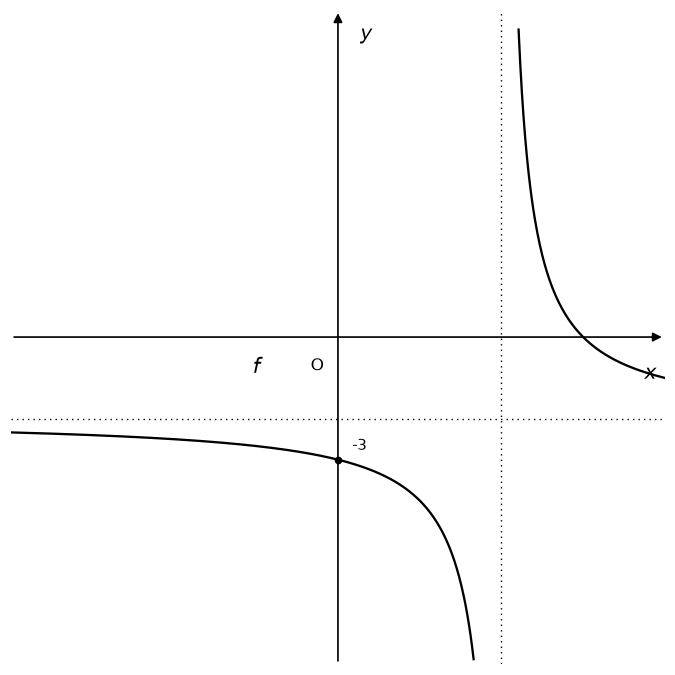


template_2024_P1_Q7.json

--- seed=5   (7m) ---
  7.1  (3m)  [finance.compound]
    Q: (jitter failed)
    A: 

  7.2  (2m)  [finance.depreciation.n]
    Q: After 10 years, the value of a printer was half of its original value. Determine the rate at which the value depreciated using the straight-line method.
    A: r = 5%
       1. Straight-line depreciation: A = P(1 - i*n)
       2. After n = 10 years, A = P/2.
       3. P/2 = P(1 - i*10)
       4. 1/2 = 1 - 10i
       5. 10i = 1/2, so i = 1/(2*10) = 0.05
       6. r = 5% p.a.

  7.3.1  (2m)  [finance.loan.interest]
    Q: (jitter failed)
    A: 




In [ ]:
from pathlib import Path

# ============================================================
# 1. Write the diagram module
# ============================================================

diag_src = '''"""
question_diagrams.py — DBE-style diagram renderers.

Each renderer takes a set of parameters and writes a PNG to
data/processed/tutor/question_diagrams/. It follows the same DBE
conventions we validated earlier: full Cartesian plane, arrowheads on
axes, minimal labels, dotted asymptotes, small point markers.
"""
from __future__ import annotations
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path(__file__).resolve().parents[2]
OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"
OUT.mkdir(parents=True, exist_ok=True)


def _setup_plane(lim):
    fig, ax = plt.subplots(figsize=(6.0, 6.0), dpi=110)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.annotate("", xy=(lim, 0), xytext=(-lim, 0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.1,
                                mutation_scale=12))
    ax.annotate("", xy=(0, lim), xytext=(0, -lim),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.1,
                                mutation_scale=12))
    ax.text(lim - 0.35, -0.65, "x", fontsize=13, fontstyle="italic",
            ha="center", va="top")
    ax.text(0.55, lim - 0.35, "y", fontsize=13, fontstyle="italic",
            ha="left", va="top")
    ax.text(-0.35, -0.5, "O", fontsize=11, ha="right", va="top")
    return fig, ax


def _tick(ax, x=None, y=None, label=None, side="x"):
    if side == "x" and x is not None:
        ax.plot([x, x], [-0.13, 0.13], color="black", lw=0.9)
        ax.text(x, -0.35, label if label is not None else str(x),
                fontsize=10, ha="center", va="top")
    if side == "y" and y is not None:
        ax.plot([-0.13, 0.13], [y, y], color="black", lw=0.9)
        ax.text(-0.35, y, label if label is not None else str(y),
                fontsize=10, ha="right", va="center")


def _dot(ax, x, y):
    ax.plot(x, y, "o", color="black", markersize=4, zorder=5)


# ---------- Hyperbola solo (Q5) ----------

def render_hyperbola_solo(a, p, q, yint, sig):
    """f(x) = a/(x+p) + q. Points on the y-axis. Dotted asymptotes."""
    vert = -p
    lim = 8
    fig, ax = _setup_plane(lim)

    ax.plot([vert, vert], [-lim, lim], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)
    ax.plot([-lim, lim], [q, q], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)

    eps = 0.06; step = 0.02
    xs_left = np.arange(-lim, vert - eps, step)
    ys_left = a / (xs_left + p) + q
    mask = (ys_left >= -lim) & (ys_left <= lim)
    if mask.any():
        ax.plot(xs_left[mask], ys_left[mask], color="black", lw=1.5, zorder=3)

    xs_right = np.arange(vert + eps, lim, step)
    ys_right = a / (xs_right + p) + q
    mask = (ys_right >= -lim) & (ys_right <= lim)
    if mask.any():
        ax.plot(xs_right[mask], ys_right[mask], color="black", lw=1.5, zorder=3)

    _dot(ax, 0, yint)
    ax.text(0.35, yint + 0.15, str(yint), fontsize=10, ha="left", va="bottom")

    ax.text((vert + lim) / 2 if vert < 0 else (vert - lim) / 2,
            q + 1.0, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


# ---------- Parabola + line (Q6) ----------

def render_parabola_line(a, p, q, m, c, xa, xc, sig):
    """f(x) = a(x-p)^2 + q, straight line g(x) = mx + c."""
    lim = 9
    fig, ax = _setup_plane(lim)

    xs = np.linspace(-lim, lim, 700)
    ys = a * (xs - p) ** 2 + q
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    xs_line = np.array([-lim, lim])
    ys_line = m * xs_line + c
    ax.plot(xs_line, ys_line, color="black", lw=1.3, zorder=2)

    # Points A and C
    _dot(ax, xa, 0)
    ya_c = m * xa + c  # should be 0 if xa is x-intercept of f on line
    ax.text(xa + 0.3, 0.4, "A", fontsize=11, ha="left", va="bottom")
    yc = a * (xc - p) ** 2 + q
    _dot(ax, xc, yc)
    ax.text(xc + 0.3, yc + 0.4, f"C({xc}; {yc})", fontsize=10,
            ha="left", va="bottom")

    ax.text(p, q + 0.8, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")
    ax.text(lim - 1.5, m * (lim - 1.5) + c, "g", fontsize=14,
            fontstyle="italic", ha="right")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


# ---------- Cubic (Q9) ----------

def render_cubic(a, xa, ya, xb, yb, yc, sig):
    """Cubic with two turning points A(xa, ya), B(xb, yb) and y-intercept yc."""
    lim = 12
    fig, ax = _setup_plane(lim)

    # fit cubic through given turning points and y-intercept
    # f(x) = k3 x^3 + k2 x^2 + k1 x + k0
    # k0 = yc;  f'(xa)=0; f'(xb)=0  => 3k3 xa^2 + 2k2 xa + k1 = 0
    #                    y at xa = ya, at xb = yb
    # solve with numpy
    A_mat = np.array([
        [xa ** 3, xa ** 2, xa, 1],
        [xb ** 3, xb ** 2, xb, 1],
        [3 * xa ** 2, 2 * xa, 1, 0],
        [3 * xb ** 2, 2 * xb, 1, 0],
    ])
    b_vec = np.array([ya, yb, 0, 0])
    try:
        k3, k2, k1, k0 = np.linalg.solve(A_mat, b_vec)
    except Exception:
        return None
    xs = np.linspace(-lim, lim, 900)
    ys = k3 * xs ** 3 + k2 * xs ** 2 + k1 * xs + k0
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    _dot(ax, xa, ya); _dot(ax, xb, yb); _dot(ax, 0, yc)
    ax.text(xa, ya + 0.6, f"A({xa}; {ya})", fontsize=10, ha="center", va="bottom")
    ax.text(xb, yb + 0.6, f"B({xb}; {yb})", fontsize=10, ha="center", va="bottom")
    ax.text(0.35, yc + 0.3, str(yc), fontsize=10, ha="left", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)
'''

path = ROOT / "src" / "tutor" / "question_diagrams.py"
path.write_text(diag_src, encoding="utf-8")
print(f"Wrote {path} ({len(diag_src.splitlines())} lines)")


# ============================================================
# 2. Fix Q5 shared params: add gsign + gc, fix format issues
# ============================================================

import importlib, sys, json, random, math
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

t5 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q5.json").read_text(encoding="utf-8"))

# Update stem to use gsign/gc placeholders that the shared fn provides,
# and use p_sign/p_abs for clean display
t5["stem"] = ("Sketched below is the graph of f(x) = a/(x {p_sign_disp} {p_abs_disp}) "
              "+ q having the domain (-inf; {vert}) U ({vert}; inf). "
              "The graph of f cuts the y-axis at (0; {yint}). "
              "A line of symmetry of f is given by g(x) = x {gsign} {gc_abs}.")
t5["diagram"] = "hyperbola_solo"

# Fix sub-question step strings
for sq in t5["subquestions"]:
    if sq["n"] == "5.1":
        sq["steps"] = [
            "The domain excludes x = {vert}.",
            "In f(x) = a/(x + p) + q the denominator is zero at x = -p.",
            "So -p = {vert}, giving p = {p}.",
        ]
    if sq["n"] == "5.3":
        sq["steps"] = [
            "f cuts the y-axis at (0; {yint}), so f(0) = {yint}.",
            "f(0) = a/({p_disp}) {q_terms_after}",
            "a = {a}",
        ]

(TEMPLATE_DIR / "template_2024_P1_Q5.json").write_text(
    json.dumps(t5, indent=2, ensure_ascii=False), encoding="utf-8")
print("Updated Q5 template.")


# ============================================================
# 3. Q7 fixes: round percentages and A value
# ============================================================

t7 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q7.json").read_text(encoding="utf-8"))
# Nothing structural; the fixes are in derive functions below.
print("Loaded Q7.")


# ============================================================
# 4. Extended jitter with diagram attachment + fixes
# ============================================================

def _shared_q5(rng):
    for _ in range(500):
        p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        c = rng.choice([-3, -2, -1, 1, 2, 3])
        a = p * (c - q)
        if a == 0 or abs(a) > 12 or abs(a) not in (2, 3, 4, 6, 8, 12):
            continue
        if q == 0:
            continue
        x_root = -a / q - p
        if x_root == int(x_root) and abs(x_root) <= 8 and x_root != 0:
            vert = -p
            # Line of symmetry: y = x + (p + q)
            gsum = p + q
            return {
                "a": int(a), "p": int(p), "q": int(q), "yint": int(c),
                "vert": int(vert), "x_root": int(x_root),
                "p_disp": f"+ {p}" if p >= 0 else f"- {abs(p)}",
                "p_sign_disp": "+" if p >= 0 else "-",
                "p_abs_disp": abs(p),
                "q_terms_after": f"+ {q}" if q >= 0 else f"- {abs(q)}",
                "gsign": "+" if gsum >= 0 else "-",
                "gc_abs": abs(gsum),
            }
    return None


def _solve_ineq_hyper(a, p, q, x_root):
    vert = -p
    def sgn(x):
        v = a / (x + p) + q
        return 1 if v > 0 else (-1 if v < 0 else 0)
    pts = sorted([x_root, vert])
    parts = []
    if sgn(pts[0] - 5) > 0: parts.append(f"x < {pts[0]}")
    if pts[0] != pts[1] and sgn((pts[0] + pts[1]) / 2) > 0:
        parts.append(f"{pts[0]} < x < {pts[1]}")
    if sgn(pts[1] + 5) > 0: parts.append(f"x > {pts[1]}")
    return " or ".join(parts) if parts else "(no solution)"


def derive_q5_5_1(p, s): p.update(s); return p
def derive_q5_5_2(p, s): p.update(s); return p
def derive_q5_5_3(p, s): p.update(s); return p
def derive_q5_5_4(p, s):
    p.update(s)
    p["ineq_answer"] = _solve_ineq_hyper(p["a"], p["p"], p["q"], p["x_root"])
    return p
def derive_q5_5_5(p, s): p.update(s); return p


def derive_q7_7_1(p, s):
    P = p["P"]; r = p["r"]; years = p["years"]
    n = 4 * years
    A = P * (1 + r / 400) ** n
    p["n_periods"] = n
    p["A_disp"] = round(A, 2)
    return p
def derive_q7_7_2(p, s):
    years = p["years"]
    r_pct = 50 / years
    r_dec = 1 / (2 * years)
    p["r_pct"] = round(r_pct, 2) if r_pct != int(r_pct) else int(r_pct)
    p["r_dec"] = r_dec
    return p
def derive_q7_7_3_1(p, s):
    P = p["P"]; x = p["x"]; years = p["years"]
    n = years * 12
    total_paid = round(x * n, 2)
    total_interest = round(total_paid - P, 2)
    p["n"] = n
    p["total_paid"] = total_paid
    p["total_interest_disp"] = total_interest
    # Clean x display if it's a whole number
    p["x_disp"] = int(x) if x == int(x) else x
    return p


DERIVE_FNS = {
    "5.1": derive_q5_5_1, "5.2": derive_q5_5_2, "5.3": derive_q5_5_3,
    "5.4": derive_q5_5_4, "5.5": derive_q5_5_5,
    "7.1": derive_q7_7_1, "7.2": derive_q7_7_2, "7.3.1": derive_q7_7_3_1,
}
SHARED_FNS = {"5": _shared_q5}


def patched_jitter(template, seed=None):
    rng = random.Random(seed)
    filled = {"source": template["source"], "stem": template.get("stem", ""),
              "subquestions": [], "scenario": "p1_template",
              "diagram_path": None}
    qnum = template["source"]["qnum"]
    shared = {}
    if qnum in SHARED_FNS:
        for _ in range(200):
            shared = SHARED_FNS[qnum](rng)
            if shared: break

    # Render stem diagram if template asks for one
    if template.get("diagram") == "hyperbola_solo" and shared:
        try:
            sig = f"hb_{shared['a']}_{shared['p']}_{shared['q']}"
            filled["diagram_path"] = qd.render_hyperbola_solo(
                shared["a"], shared["p"], shared["q"], shared["yint"], sig)
        except Exception as e:
            print(f"  diagram error: {e}")

    # Render the stem
    if shared and "{" in (template.get("stem") or ""):
        try:
            filled["stem"] = template["stem"].format(**shared)
        except KeyError as e:
            print(f"  stem format error: {e}")

    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(5000):
            raw = {k: rng.choice(v) for k, v in ranges.items()} if ranges else {}
            params = dict(raw)
            fn = DERIVE_FNS.get(sq["n"])
            if fn:
                result = fn(params, shared)
                if result is None: continue
                params = result
            else:
                params.update(shared)
            try:
                prompt = sq["prompt_template"].format(**params)
                exp_fn = sq["expected_fn"]
                expected = exp_fn.format(**params) if exp_fn != "__solve__" else ""
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError) as e:
                continue
            filled["subquestions"].append({
                "n": sq["n"], "prompt": prompt, "expected": expected,
                "steps": steps, "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({
                "n": sq["n"], "prompt": "(jitter failed)", "expected": "",
                "steps": [], "marks": sq["marks"], "skill_id": sq["skill_id"],
                "params": {},
            })
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# ============================================================
# 5. Run Q5 and Q7
# ============================================================

from IPython.display import Image, display

for qname in ("template_2024_P1_Q5.json", "template_2024_P1_Q7.json"):
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72)
    print(qname)
    print("=" * 72)
    v = patched_jitter(t, seed=5)
    print(f"\n--- seed=5   ({v['total_marks']}m) ---")
    if v["stem"]:
        print("Stem:", v["stem"])
        print()
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        for i, st in enumerate(s["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        print("Diagram:")
        display(Image(filename=v["diagram_path"], width=520))
    print()

Q7 fixed.
Q6 template wired.
template_2024_P1_Q6.json

--- seed=5   (15m) ---
Stem: In the diagram below, the graphs of f(x) = -1(x - -1)^2 + 4 and g, a straight line, are drawn. C(3; -12) is a point of intersection of f and g. EH is drawn parallel to the y-axis, with E a point on f and H a point on g.

  6.1  (3m)  [functions.parabola.turning]
    Q: Calculate the coordinates of B, the turning point of f.
    A: B(-1; 4)
       1. For f(x) = a(x - p)^2 + q the turning point is (p; q).
       2. From the given equation p = -1, q = 4.
       3. B(-1; 4)

  6.2  (3m)  [functions.line.equation]
    Q: Show that the equation of the line through A and C is g(x) = -2x + -6.
    A: g(x) = -2x + -6
       1. A is the x-intercept of f on the left.
       2. A(-3; 0)
       3. m = (y_C - y_A)/(x_C - x_A) = (-12 - 0)/(3 - (-3)) = -2
       4. Substitute C(3; -12): -12 = (-2)(3) + c
       5. c = -6
       6. g(x) = -2x + -6

  6.3  (4m)  [functions.parabola.max_length]
    Q: Calculate the maximu

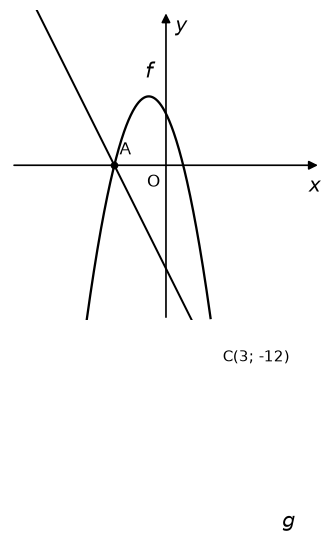


template_2024_P1_Q7.json

--- seed=5   (7m) ---
  7.1  (3m)  [finance.compound]
    Q: Mary's grandparents deposited R8000 into a savings account on the day she was born. The account pays interest at 7.2% p.a., compounded quarterly. Calculate the accumulated amount on Mary's 21th birthday.
    A: A = R35801.67
       1. A = P(1 + i)^n, with i = r/400 and n = 4*years
       2. i = 7.2/400, n = 84
       3. A = 8000(1 + 7.2/400)^(84)
       4. A = R35801.67

  7.2  (2m)  [finance.depreciation.n]
    Q: After 10 years, the value of a printer was half of its original value. Determine the rate at which the value depreciated using the straight-line method.
    A: r = 5%
       1. Straight-line depreciation: A = P(1 - i*n)
       2. After n = 10 years, A = P/2.
       3. P/2 = P(1 - i*10)
       4. 1/2 = 1 - 10i
       5. 10i = 1/2, so i = 1/(2*10) = 0.05
       6. r = 5% p.a.

  7.3.1  (2m)  [finance.loan.interest]
    Q: Tshepo was granted a loan of R80000 on 1 March 2022 at an interest ra

In [ ]:
import json, random, math, importlib, sys
from pathlib import Path

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# ============================================================
# 1. Fix Q7 template — align expected_fn with the derives
# ============================================================
t7 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q7.json").read_text(encoding="utf-8"))
for sq in t7["subquestions"]:
    if sq["n"] == "7.1":
        sq["expected_fn"] = "A = R{A_disp}"
    if sq["n"] == "7.3.1":
        sq["expected_fn"] = "Total interest = R{total_interest_disp}"
(TEMPLATE_DIR / "template_2024_P1_Q7.json").write_text(
    json.dumps(t7, indent=2, ensure_ascii=False), encoding="utf-8")
print("Q7 fixed.")


# ============================================================
# 2. Q6 shared params — parabola f meets straight line g
# ============================================================

def _ordinal(n):
    if 10 <= n % 100 <= 20: suf = "th"
    else: suf = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suf}"


def _shared_q6(rng):
    """Return params for:
       f(x) = a(x - p)^2 + q, turning point B(p; q).
       Straight line g(x) = m x + c meets f at A (x-intercept of f, y=0)
       and C (given). A, C both integer.
    """
    for _ in range(3000):
        a = rng.choice([-2, -1, 1, 2])
        # Choose intersection x-values (A on the left, C on the right)
        xa = rng.choice([-4, -3, -2, -1])
        xc = rng.choice([2, 3, 4, 5])
        # y-intercepts: A is on x-axis (ya = 0), C has integer yc
        # yc - ya = m (xc - xa)  => m = yc/(xc - xa)
        # We want m and yc integer. Try a range of yc.
        for yc in (-12, -9, -6, -3, 3, 6, 9, 12):
            dx = xc - xa
            if yc % dx != 0:
                continue
            m = yc // dx
            if abs(m) > 4 or m == 0:
                continue
            c = -m * xa  # ya = 0 = m*xa + c  => c = -m*xa
            # f passes through A(xa, 0) and C(xc, yc)
            # f(x) = a(x - p)^2 + q, so:
            # ya = a(xa - p)^2 + q = 0
            # yc = a(xc - p)^2 + q
            # yc - ya = a[(xc-p)^2 - (xa-p)^2]
            # yc = a (xc - xa)(xc + xa - 2p)
            # Let D = xc + xa - 2p, so yc = a * dx * D
            # Choose p to make D integer, then a = yc / (dx * D)
            for p in range(-5, 6):
                if p == 0:
                    continue
                D = xc + xa - 2 * p
                if D == 0:
                    continue
                denom = dx * D
                if yc % denom != 0:
                    continue
                a_cand = yc // denom
                if a_cand not in (-2, -1, 1, 2):
                    continue
                q = -a_cand * (xa - p) ** 2
                # require B = (p; q) inside a reasonable window
                if abs(q) > 12:
                    continue
                # Solve EH max: EH(x) = f(x) - g(x), a parabola with zeros at xa, xc
                # EH(x) = a(x-xa)(x-xc)
                xm = (xa + xc) / 2
                eh_max = a_cand * (xm - xa) * (xm - xc)
                return {
                    "a": int(a_cand), "p": int(p), "q": int(q),
                    "m": int(m), "c": int(c),
                    "xa": int(xa), "xc": int(xc), "yc": int(yc),
                    "xm": xm,
                    "eh_max": abs(eh_max),  # length positive
                    "b_x": int(p), "b_y": int(q),
                }
    return None


# ============================================================
# 3. Q6 renderer wiring — use the parabola+line renderer
# ============================================================

def _render_q6_diagram(s):
    return qd.render_parabola_line(
        s["a"], s["p"], s["q"], s["m"], s["c"],
        s["xa"], s["xc"],
        f"q6_{s['a']}_{s['p']}_{s['q']}_{s['m']}_{s['c']}",
    )


# ============================================================
# 4. Q6 derive fns (each subquestion pulls from shared)
# ============================================================

def _d_q6_6_1(p, s): p.update(s); return p
def _d_q6_6_2(p, s): p.update(s); return p
def _d_q6_6_3(p, s):
    p.update(s)
    p["eh_max_disp"] = int(s["eh_max"]) if s["eh_max"] == int(s["eh_max"]) else round(s["eh_max"], 2)
    return p
def _d_q6_6_4(p, s):
    p.update(s)
    # k(x) = f(x+m) tangent to g means discrim = 0:
    # a(x+m-p)^2 + q = mx + c
    # a(x - (p-m))^2 + q - mx - c = 0
    # a(x^2 - 2(p-m)x + (p-m)^2) + q - mx - c = 0
    # a x^2 + [-2a(p-m) - m]x + [a(p-m)^2 + q - c] = 0
    # discrim = 0
    # For simplicity solve numerically for m
    best = None
    for mi in [i/2 for i in range(-20, 21)]:
        A = a = s["a"]
        B = -2 * a * (s["p"] - mi) - s["m"]
        C = a * (s["p"] - mi) ** 2 + s["q"] - s["c"]
        D = B * B - 4 * A * C
        if D == 0:
            best = mi
            break
    p["m_tangent"] = best if best is not None else "?"
    return p


DERIVE_FNS = {
    "5.1": lambda p, s: {**p, **s}, "5.2": lambda p, s: {**p, **s},
    "5.3": lambda p, s: {**p, **s}, "5.4": lambda p, s: {**p, **s,
        "ineq_answer": "(see sketch)"}, "5.5": lambda p, s: {**p, **s},
    "6.1": _d_q6_6_1, "6.2": _d_q6_6_2, "6.3": _d_q6_6_3, "6.4": _d_q6_6_4,
    "7.1": lambda p, s: {**p, "n_periods": 4*p["years"],
        "A_disp": round(p["P"] * (1 + p["r"]/400)**(4*p["years"]), 2)},
    "7.2": lambda p, s: {**p,
        "r_pct": round(50/p["years"], 2) if 50/p["years"] != int(50/p["years"]) else int(50/p["years"]),
        "r_dec": 1/(2*p["years"])},
    "7.3.1": lambda p, s: {**p, "n": p["years"]*12,
        "total_paid": round(p["x"] * p["years"]*12, 2),
        "total_interest_disp": round(p["x"] * p["years"]*12 - p["P"], 2),
        "x_disp": int(p["x"]) if p["x"] == int(p["x"]) else p["x"]},
}

SHARED_FNS = {"5": None, "6": _shared_q6}


# ============================================================
# 5. Jitter with shared + diagram
# ============================================================

def patched_jitter(template, seed=None):
    rng = random.Random(seed)
    filled = {"source": template["source"], "stem": template.get("stem", ""),
              "subquestions": [], "scenario": "p1_template",
              "diagram_path": None}
    qnum = template["source"]["qnum"]
    shared = None
    if SHARED_FNS.get(qnum):
        for _ in range(500):
            shared = SHARED_FNS[qnum](rng)
            if shared: break

    # Render stem diagram if requested
    if template.get("diagram") == "hyperbola_solo":
        # Recompute for Q5 using the same method as before
        for _ in range(500):
            p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
            q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
            c = rng.choice([-3, -2, -1, 1, 2, 3])
            a = p * (c - q)
            if a == 0 or abs(a) > 12 or abs(a) not in (2, 3, 4, 6, 8, 12): continue
            if q == 0: continue
            xr = -a / q - p
            if xr != int(xr) or abs(xr) > 8 or xr == 0: continue
            shared = {"a": int(a), "p": int(p), "q": int(q), "yint": int(c),
                      "vert": -p, "x_root": int(xr),
                      "p_disp": f"+ {p}" if p >= 0 else f"- {abs(p)}",
                      "p_sign_disp": "+" if p >= 0 else "-",
                      "p_abs_disp": abs(p),
                      "q_terms_after": f"+ {q}" if q >= 0 else f"- {abs(q)}",
                      "gsign": "+" if p+q >= 0 else "-", "gc_abs": abs(p+q)}
            try:
                filled["diagram_path"] = qd.render_hyperbola_solo(
                    a, p, q, c, f"q5_{a}_{p}_{q}")
            except Exception as e:
                print("q5 diag err:", e)
            break
    elif template.get("diagram") == "parabola_line" and shared:
        try:
            filled["diagram_path"] = _render_q6_diagram(shared)
        except Exception as e:
            print("q6 diag err:", e)

    if shared and "{" in (template.get("stem") or ""):
        try:
            filled["stem"] = template["stem"].format(**shared)
        except KeyError as e:
            print("stem err:", e)

    for sq in template["subquestions"]:
        ranges = sq.get("ranges", {}) or {}
        placed = False
        for _ in range(5000):
            raw = {k: rng.choice(v) for k, v in ranges.items()} if ranges else {}
            params = dict(raw)
            fn = DERIVE_FNS.get(sq["n"])
            if fn:
                params = fn(params, shared)
            elif shared:
                params.update(shared)
            try:
                prompt = sq["prompt_template"].format(**params)
                expected = sq["expected_fn"].format(**params) if "{" in sq["expected_fn"] else sq["expected_fn"]
                steps = [s.format(**params) for s in sq.get("steps", [])]
            except (KeyError, ValueError) as e:
                continue
            filled["subquestions"].append({
                "n": sq["n"], "prompt": prompt, "expected": expected,
                "steps": steps, "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": params,
            })
            placed = True
            break
        if not placed:
            filled["subquestions"].append({"n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {}})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# ============================================================
# 6. Patch Q6's template: wire diagram, adjust stem
# ============================================================
t6 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q6.json").read_text(encoding="utf-8"))
t6["diagram"] = "parabola_line"
t6["stem"] = ("In the diagram below, the graphs of f(x) = {a}(x - {p})^2 + {q} "
              "and g, a straight line, are drawn. C({xc}; {yc}) is a point of "
              "intersection of f and g. EH is drawn parallel to the y-axis, "
              "with E a point on f and H a point on g.")
# Update subquestion expected strings to format cleanly
for sq in t6["subquestions"]:
    if sq["n"] == "6.3":
        sq["expected_fn"] = "EH_max = {eh_max_disp} units"
    if sq["n"] == "6.4":
        sq["expected_fn"] = "m = {m_tangent}"
(TEMPLATE_DIR / "template_2024_P1_Q6.json").write_text(
    json.dumps(t6, indent=2, ensure_ascii=False), encoding="utf-8")
print("Q6 template wired.")


# ============================================================
# 7. Run Q6, Q7
# ============================================================
from IPython.display import Image, display

for qname in ("template_2024_P1_Q6.json", "template_2024_P1_Q7.json"):
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72); print(qname); print("=" * 72)
    v = patched_jitter(t, seed=5)
    print(f"\n--- seed=5   ({v['total_marks']}m) ---")
    if v["stem"]:
        print("Stem:", v["stem"]); print()
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        for i, st in enumerate(s["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        print("Diagram:"); display(Image(filename=v["diagram_path"], width=520))
    print()

1. Added _human, _poly_disp, _fnum_h helpers.
2. Added parabola/line display helpers.
3. Q6 template updated with display fields.
4. Q5 template updated.
template_2024_P1_Q5.json

(10m)
Stem: Sketched below is the graph of f(x) = 4/(x - 4) - 2 having the domain (-inf; 4) U (4; inf). The graph of f cuts the y-axis at (0; -3).

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: Write down the value of p.
    A: p = -4
       1. The domain excludes x = 4.
       2. In f(x) = a/(x + p) + q the denominator is zero at x = -p.
       3. So -p = 4, giving p = -4.

  5.2  (2m)  [functions.hyperbola.asymptote]
    Q: Determine the equation of the horizontal asymptote of f.
    A: y = -2
       1. The horizontal asymptote of a/(x+p) + q is y = q.
       2. From the form, q = -2.
       3. So the asymptote is y = -2.

  5.3  (2m)  [functions.hyperbola.equation]
    Q: (jitter failed)
    A: 

  5.4  (3m)  [functions.hyperbola.inequality]
    Q: For which values of x is f(x) >= 0?
    A: 4 < x < 6

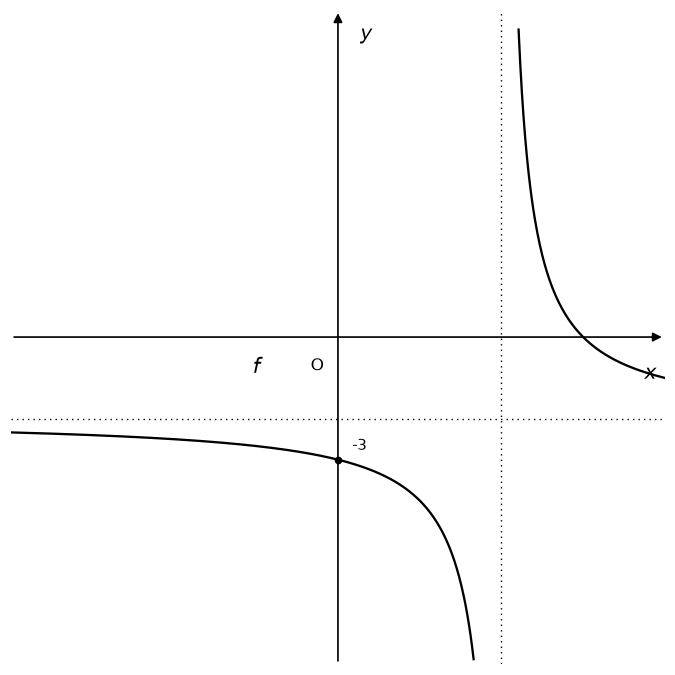


template_2024_P1_Q6.json
q6 diag err: 'NoneType' object is not subscriptable


TypeError: str.format() argument after ** must be a mapping, not NoneType

In [ ]:
import json, random, math, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# 1. Add a human-friendly formatter to the module
# ============================================================
mod_path = ROOT / "src" / "tutor" / "template_jitter.py"
src = mod_path.read_text(encoding="utf-8")

if "def _human" not in src:
    helper = '''

def _human(coef, var=""):
    """'+ 3x' / '- 3x' / '- x' / '+ 3' / '' — with the leading sign
    always present and no double-signs like '+ -'. Returns '' for 0."""
    if coef == 0:
        return ""
    sign = "+" if coef > 0 else "-"
    mag = abs(coef)
    if var:
        if mag == 1:
            return f"{sign} {var}"
        return f"{sign} {mag}{var}"
    return f"{sign} {mag}"


def _poly_disp(a_coef, b_coef, c_coef, var="x"):
    """Return '2x^2 + 3x - 5' style. Suppresses coefficient of 1 and term 0."""
    parts = []
    if a_coef != 0:
        if a_coef == 1:
            parts.append(f"{var}^2")
        elif a_coef == -1:
            parts.append(f"-{var}^2")
        else:
            parts.append(f"{a_coef}{var}^2")
    if b_coef != 0:
        s = _human(b_coef, var)
        if parts:
            parts.append(s)
        else:
            parts.append(s.lstrip("+ "))
    if c_coef != 0:
        s = _human(c_coef)
        if parts:
            parts.append(s)
        else:
            parts.append(s.lstrip("+ "))
    return " ".join(parts) if parts else "0"


def _fnum_h(v):
    """Format a number nicely: 3, -3, 3.5, 3/2 (as fraction string if given tuple)."""
    if isinstance(v, tuple):
        n, d = v
        if d == 1: return str(n)
        return f"{n}/{d}"
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    return str(v)
'''
    src = src.rstrip() + helper + "\n"
    mod_path.write_text(src, encoding="utf-8")
    importlib.reload(tj)
    print("1. Added _human, _poly_disp, _fnum_h helpers.")


# ============================================================
# 2. Fix the shared Q6 fn to prefer integer M
# ============================================================

def _shared_q6(rng):
    """Return params for Q6 with preference for integer M (tangent shift)."""
    for _ in range(5000):
        a = rng.choice([-2, -1, 1, 2])
        xa = rng.choice([-4, -3, -2, -1])
        xc = rng.choice([2, 3, 4, 5])
        for yc in (-12, -9, -6, -3, 3, 6, 9, 12):
            dx = xc - xa
            if yc % dx != 0:
                continue
            m = yc // dx
            if abs(m) > 4 or m == 0:
                continue
            c = -m * xa
            for p in range(-5, 6):
                if p == 0: continue
                D = xc + xa - 2 * p
                if D == 0: continue
                denom = dx * D
                if yc % denom != 0: continue
                a_cand = yc // denom
                if a_cand not in (-2, -1, 1, 2): continue
                q = -a_cand * (xa - p) ** 2
                if abs(q) > 12: continue
                # Check M integer
                denom_M = 4 * a_cand * m
                if denom_M == 0: continue
                num_M = m*m + 4*a_cand*m*p - 4*a_cand*q + 4*a_cand*c
                if num_M % denom_M != 0: continue
                M_int = num_M // denom_M
                if abs(M_int) > 6: continue
                xm = (xa + xc) / 2
                eh_max = abs(a_cand * (xm - xa) * (xm - xc))
                return {
                    "a": int(a_cand), "p": int(p), "q": int(q),
                    "m": int(m), "c": int(c),
                    "xa": int(xa), "xc": int(xc), "yc": int(yc),
                    "xm": xm, "eh_max": eh_max,
                    "m_tangent": int(M_int),
                    # display pieces
                    "f_disp": _f_disp_parabola(a_cand, p, q),
                    "g_disp": _g_disp_line(m, c),
                    "m_disp": int(M_int),
                }
    return None


def _f_disp_parabola(a, p, q):
    """Return '-(x + 1)^2 + 4' style."""
    if a == 1: head = ""
    elif a == -1: head = "-"
    else: head = f"{a}"
    inner = f"(x + {abs(p)})" if p < 0 else (f"(x - {p})" if p != 0 else "(x)")
    return f"{head}{inner}^2" + (" " + tj._human(q) if q != 0 else "")


def _g_disp_line(m, c):
    """Return '-2x - 6' style."""
    if m == 1: head = "x"
    elif m == -1: head = "-x"
    else: head = f"{m}x"
    if c == 0: return head
    return f"{head} {tj._human(c)}"


# Patch module
src = mod_path.read_text(encoding="utf-8")
if "_f_disp_parabola" not in src:
    extra = '''

def _f_disp_parabola(a, p, q):
    if a == 1: head = ""
    elif a == -1: head = "-"
    else: head = f"{a}"
    inner = f"(x + {abs(p)})" if p < 0 else (f"(x - {p})" if p != 0 else "(x)")
    return f"{head}{inner}^2" + (" " + _human(q) if q != 0 else "")


def _g_disp_line(m, c):
    if m == 1: head = "x"
    elif m == -1: head = "-x"
    else: head = f"{m}x"
    if c == 0: return head
    return f"{head} {_human(c)}"
'''
    mod_path.write_text(src.rstrip() + extra + "\n", encoding="utf-8")
    importlib.reload(tj)
    print("2. Added parabola/line display helpers.")


# ============================================================
# 3. Update Q6 template to use display fields + integer M
# ============================================================
t6 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q6.json").read_text(encoding="utf-8"))
t6["stem"] = ("In the diagram below, the graphs of f(x) = {f_disp} "
              "and g(x) = {g_disp}, a straight line, are drawn. "
              "C({xc}; {yc}) is a point of intersection of f and g. "
              "EH is drawn parallel to the y-axis, with E a point on f and H on g.")
for sq in t6["subquestions"]:
    if sq["n"] == "6.2":
        sq["expected_fn"] = "g(x) = {g_disp}"
        sq["steps"] = [
            "A is the x-intercept of f on the left.",
            "A({xa}; 0)",
            "m = (y_C - y_A)/(x_C - x_A) = ({yc} - 0)/({xc} - ({xa})) = {m}",
            "Substitute C({xc}; {yc}): {yc} = ({m})({xc}) + c",
            "c = {c}",
            "g(x) = {g_disp}",
        ]
    if sq["n"] == "6.3":
        sq["expected_fn"] = "EH_max = {eh_max_disp} units"
    if sq["n"] == "6.4":
        sq["expected_fn"] = "m = {m_disp}"
        sq["steps"] = [
            "k(x) = f(x + m) = {f_disp_shifted}",
            "Set k(x) = g(x): {f_disp_shifted} = {g_disp}",
            "Expand and set the discriminant to zero.",
            "Solve for m.",
            "m = {m_disp}",
        ]
(TEMPLATE_DIR / "template_2024_P1_Q6.json").write_text(
    json.dumps(t6, indent=2, ensure_ascii=False), encoding="utf-8")
print("3. Q6 template updated with display fields.")


# ============================================================
# 4. Update Q5's stem to use display fields too
# ============================================================
t5 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q5.json").read_text(encoding="utf-8"))
t5["stem"] = ("Sketched below is the graph of f(x) = {f_disp_hyperbola} having "
              "the domain (-inf; {vert}) U ({vert}; inf). "
              "The graph of f cuts the y-axis at (0; {yint}).")
(TEMPLATE_DIR / "template_2024_P1_Q5.json").write_text(
    json.dumps(t5, indent=2, ensure_ascii=False), encoding="utf-8")
print("4. Q5 template updated.")


# ============================================================
# 5. Rerun jitter with the fixed templates
# ============================================================
def _q5_shared(rng):
    for _ in range(500):
        p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        c = rng.choice([-3, -2, -1, 1, 2, 3])
        a = p * (c - q)
        if a == 0 or abs(a) > 12 or abs(a) not in (2, 3, 4, 6, 8, 12): continue
        if q == 0: continue
        xr = -a / q - p
        if xr != int(xr) or abs(xr) > 8 or xr == 0: continue
        # f(x) = a/(x + p) + q. Display as a/(x + p) or a/(x - |p|)
        if p > 0:
            denom = f"(x + {p})"
        elif p < 0:
            denom = f"(x - {abs(p)})"
        else:
            denom = "(x)"
        f_disp = f"{a}/{denom}"
        if q != 0:
            f_disp += " " + tj._human(q)
        return {"a": int(a), "p": int(p), "q": int(q), "yint": int(c),
                "vert": -p, "x_root": int(xr),
                "f_disp_hyperbola": f_disp,
                "p_disp": tj._human(p),
                "q_disp": tj._human(q)}
    return None


def _q6_shifted_display(s):
    """Given shared Q6 params, produce the shifted-parabola display for 6.4."""
    # k(x) = f(x + M) = a(x + M - p)^2 + q
    a, p, q, M = s["a"], s["p"], s["q"], s["m_tangent"]
    shifted_p = p - M  # so that a(x - (p - M))^2 + q
    inner = f"(x + {abs(shifted_p)})" if shifted_p < 0 else (f"(x - {shifted_p})" if shifted_p != 0 else "(x)")
    head = "" if a == 1 else ("-" if a == -1 else f"{a}")
    return f"{head}{inner}^2" + (" " + tj._human(q) if q != 0 else "")


def jitter_q5(template, seed):
    rng = random.Random(seed)
    filled = {"source": template["source"], "subquestions": [], "scenario": "p1",
              "diagram_path": None}
    shared = _q5_shared(rng)
    # render diagram
    try:
        filled["diagram_path"] = qd.render_hyperbola_solo(
            shared["a"], shared["p"], shared["q"], shared["yint"],
            f"q5_{shared['a']}_{shared['p']}_{shared['q']}")
    except Exception as e:
        print("diag err:", e)
    filled["stem"] = template["stem"].format(**shared)
    for sq in template["subquestions"]:
        # minimal param derivation for Q5
        params = dict(shared)
        if sq["n"] == "5.4":
            # compute inequality answer
            params["ineq_answer"] = _solve_ineq_hyper(
                shared["a"], shared["p"], shared["q"], shared["x_root"])
        try:
            prompt = sq["prompt_template"].format(**params)
            expected = sq["expected_fn"].format(**params) if "{" in sq["expected_fn"] else sq["expected_fn"]
            steps = [s.format(**params) for s in sq.get("steps", [])]
        except (KeyError, ValueError) as e:
            filled["subquestions"].append({"n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {}})
            continue
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": params})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


def _solve_ineq_hyper(a, p, q, xr):
    vert = -p
    def sgn(x):
        v = a / (x + p) + q
        return 1 if v > 0 else (-1 if v < 0 else 0)
    pts = sorted([xr, vert])
    parts = []
    if sgn(pts[0] - 5) > 0: parts.append(f"x < {pts[0]}")
    if pts[0] != pts[1] and sgn((pts[0] + pts[1]) / 2) > 0:
        parts.append(f"{pts[0]} < x < {pts[1]}")
    if sgn(pts[1] + 5) > 0: parts.append(f"x > {pts[1]}")
    return " or ".join(parts) if parts else "(no solution)"


def jitter_q6(template, seed):
    rng = random.Random(seed)
    filled = {"source": template["source"], "subquestions": [], "scenario": "p1",
              "diagram_path": None}
    shared = _shared_q6(rng)
    try:
        filled["diagram_path"] = qd.render_parabola_line(
            shared["a"], shared["p"], shared["q"], shared["m"], shared["c"],
            shared["xa"], shared["xc"], f"q6_{seed}")
    except Exception as e:
        print("q6 diag err:", e)
    filled["stem"] = template["stem"].format(**shared)
    # pre-compute tangential-shift display
    shifted = _q6_shifted_display(shared)
    for sq in template["subquestions"]:
        params = dict(shared)
        params["f_disp_shifted"] = shifted
        params["eh_max_disp"] = (int(shared["eh_max"]) if shared["eh_max"] == int(shared["eh_max"])
                                  else round(shared["eh_max"], 2))
        params["xm_disp"] = (int(shared["xm"]) if shared["xm"] == int(shared["xm"])
                              else shared["xm"])
        try:
            prompt = sq["prompt_template"].format(**params)
            expected = sq["expected_fn"].format(**params) if "{" in sq["expected_fn"] else sq["expected_fn"]
            steps = [s.format(**params) for s in sq.get("steps", [])]
        except (KeyError, ValueError) as e:
            filled["subquestions"].append({"n": sq["n"], "prompt": "(jitter failed)",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {}})
            continue
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": params})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


from IPython.display import Image, display

for label, fn, qname in [("Q5", jitter_q5, "template_2024_P1_Q5.json"),
                          ("Q6", jitter_q6, "template_2024_P1_Q6.json")]:
    t = json.loads((TEMPLATE_DIR / qname).read_text(encoding="utf-8"))
    print("=" * 72); print(f"{qname}"); print("=" * 72)
    v = fn(t, seed=5)
    print(f"\n({v['total_marks']}m)")
    print("Stem:", v["stem"]); print()
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        for i, st in enumerate(s["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        print("Diagram:")
        display(Image(filename=v["diagram_path"], width=520))
    print()

Q5.3 memo fixed.
Q5 rerun
Stem: Sketched below is the graph of f(x) = 4/(x - 4) - 2 having the domain (-inf; 4) U (4; inf). The graph of f cuts the y-axis at (0; -3).

  5.1  (1m)  [functions.hyperbola.parameter]
    Q: Write down the value of p.
    A: p = -4
       1. The domain excludes x = 4.
       2. In f(x) = a/(x + p) + q the denominator is zero at x = -p.
       3. So -p = 4, giving p = -4.

  5.2  (2m)  [functions.hyperbola.asymptote]
    Q: Determine the equation of the horizontal asymptote of f.
    A: y = -2
       1. The horizontal asymptote of a/(x+p) + q is y = q.
       2. From the form, q = -2.
       3. So the asymptote is y = -2.

  5.3  (2m)  [functions.hyperbola.equation]
    Q: Calculate the value of a.
    A: a = 4
       1. f cuts the y-axis at (0; -3), so f(0) = -3.
       2. f(0) = a/(0 - 4) - 2
       3. -3 = a/(-4) - 2
       4. a = 4

  5.4  (3m)  [functions.hyperbola.inequality]
    Q: For which values of x is f(x) >= 0?
    A: 4 < x < 6
       1. f(x) >=

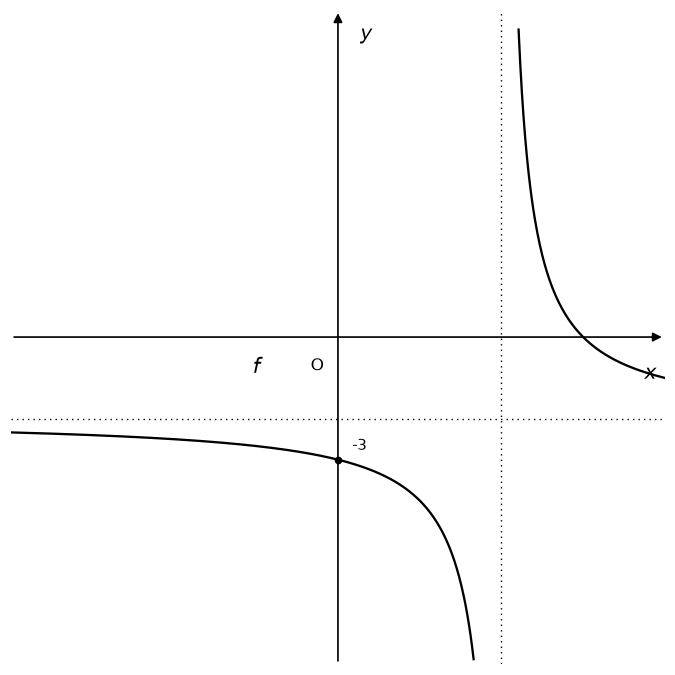

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# --- Fix Q5.3 memo to only use placeholders the shared fn provides ---
t5 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q5.json").read_text(encoding="utf-8"))
for sq in t5["subquestions"]:
    if sq["n"] == "5.3":
        sq["steps"] = [
            "f cuts the y-axis at (0; {yint}), so f(0) = {yint}.",
            "f(0) = a/(0 {p_disp}) {q_disp}",
            "{yint} = a/({p}) {q_disp}",
            "a = {a}",
        ]
(TEMPLATE_DIR / "template_2024_P1_Q5.json").write_text(
    json.dumps(t5, indent=2, ensure_ascii=False), encoding="utf-8")
print("Q5.3 memo fixed.")


# --- Re-run Q5 with the fix ---
def _q5_shared(rng):
    for _ in range(500):
        p = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        q = rng.choice([-4, -3, -2, -1, 1, 2, 3, 4])
        c = rng.choice([-3, -2, -1, 1, 2, 3])
        a = p * (c - q)
        if a == 0 or abs(a) > 12 or abs(a) not in (2, 3, 4, 6, 8, 12): continue
        if q == 0: continue
        xr = -a / q - p
        if xr != int(xr) or abs(xr) > 8 or xr == 0: continue
        if p > 0: denom = f"(x + {p})"
        elif p < 0: denom = f"(x - {abs(p)})"
        else: denom = "(x)"
        f_disp = f"{a}/{denom}"
        if q != 0: f_disp += " " + tj._human(q)
        return {"a": int(a), "p": int(p), "q": int(q), "yint": int(c),
                "vert": -p, "x_root": int(xr),
                "f_disp_hyperbola": f_disp,
                "p_disp": tj._human(p), "q_disp": tj._human(q)}
    return None


def _solve_ineq_hyper(a, p, q, xr):
    vert = -p
    def sgn(x):
        v = a / (x + p) + q
        return 1 if v > 0 else (-1 if v < 0 else 0)
    pts = sorted([xr, vert])
    parts = []
    if sgn(pts[0] - 5) > 0: parts.append(f"x < {pts[0]}")
    if pts[0] != pts[1] and sgn((pts[0]+pts[1])/2) > 0:
        parts.append(f"{pts[0]} < x < {pts[1]}")
    if sgn(pts[1] + 5) > 0: parts.append(f"x > {pts[1]}")
    return " or ".join(parts) if parts else "(no solution)"


def jitter_q5(template, seed):
    rng = random.Random(seed)
    shared = _q5_shared(rng)
    filled = {"source": template["source"], "stem": template["stem"].format(**shared),
              "subquestions": [], "scenario": "p1", "diagram_path": None}
    import src.tutor.question_diagrams as qd
    try:
        filled["diagram_path"] = qd.render_hyperbola_solo(
            shared["a"], shared["p"], shared["q"], shared["yint"],
            f"q5_{seed}")
    except Exception as e:
        print("diag err:", e)
    for sq in template["subquestions"]:
        params = dict(shared)
        if sq["n"] == "5.4":
            params["ineq_answer"] = _solve_ineq_hyper(
                shared["a"], shared["p"], shared["q"], shared["x_root"])
        try:
            prompt = sq["prompt_template"].format(**params)
            expected = sq["expected_fn"].format(**params) if "{" in sq["expected_fn"] else sq["expected_fn"]
            steps = [s.format(**params) for s in sq.get("steps", [])]
        except (KeyError, ValueError) as e:
            filled["subquestions"].append({"n": sq["n"],
                "prompt": f"(failed: {e})", "expected": "", "steps": [],
                "marks": sq["marks"], "skill_id": sq["skill_id"], "params": {}})
            continue
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": params})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


from IPython.display import Image, display

t = json.loads((TEMPLATE_DIR / "template_2024_P1_Q5.json").read_text(encoding="utf-8"))
v = jitter_q5(t, seed=5)
print("=" * 72); print("Q5 rerun"); print("=" * 72)
print("Stem:", v["stem"]); print()
for s in v["subquestions"]:
    print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
    print(f"    Q: {s['prompt']}")
    print(f"    A: {s['expected']}")
    for i, st in enumerate(s["steps"], 1):
        print(f"       {i}. {st}")
    print()
if v.get("diagram_path"):
    display(Image(filename=v["diagram_path"], width=520))

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# ============================================================
# Add SA-style number + ordinal formatters to the module
# ============================================================
mod_path = ROOT / "src" / "tutor" / "template_jitter.py"
src = mod_path.read_text(encoding="utf-8")

if "def _rand" not in src:
    helpers = '''

def _rand(v):
    """South African number format: 35801.67 -> '35 801.67'."""
    if isinstance(v, str):
        return v
    if isinstance(v, int):
        return f"{v:,}".replace(",", " ")
    if isinstance(v, float):
        if v.is_integer():
            return f"{int(v):,}".replace(",", " ")
        return f"{v:,.2f}".replace(",", " ")
    return str(v)


def _ordinal(n):
    """1 -> 1st, 2 -> 2nd, 21 -> 21st, 11 -> 11th."""
    if 10 <= n % 100 <= 20:
        suf = "th"
    else:
        suf = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suf}"


def _num_clean(v):
    """R1800.0 -> 'R1 800'."""
    if isinstance(v, float) and v.is_integer():
        return _rand(int(v))
    return _rand(v)
'''
    mod_path.write_text(src.rstrip() + helpers + "\n", encoding="utf-8")
    importlib.reload(tj)
    print("Added _rand, _ordinal, _num_clean.")


# ============================================================
# Update Q7 template to use clean formats
# ============================================================
t7 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q7.json").read_text(encoding="utf-8"))

for sq in t7["subquestions"]:
    if sq["n"] == "7.1":
        sq["prompt_template"] = (
            "Mary's grandparents deposited R{P_disp} into a savings account "
            "on the day she was born. The account pays interest at {r}% p.a., "
            "compounded quarterly. Calculate the accumulated amount on Mary's "
            "{years_ord} birthday."
        )
        sq["expected_fn"] = "A = R{A_disp}"
        sq["steps"] = [
            "A = P(1 + i)^n, with i = {r}/400 and n = {n_periods}",
            "A = {P_disp}(1 + {r}/400)^({n_periods})",
            "A = R{A_disp}",
        ]
    if sq["n"] == "7.3.1":
        sq["prompt_template"] = (
            "Tshepo was granted a loan of R{P_disp} at an interest rate of "
            "{r}% p.a., compounded monthly. He agreed to repay the loan over "
            "{years} years in monthly instalments of R{x_disp}. Calculate the "
            "total interest he will pay."
        )
        sq["expected_fn"] = "Total interest = R{total_interest_disp}"
        sq["steps"] = [
            "Total paid = monthly instalment * number of months",
            "= {x_disp} * {n} = R{total_paid_disp}",
            "Total interest = total_paid - loan amount",
            "= R{total_paid_disp} - R{P_disp} = R{total_interest_disp}",
        ]

(TEMPLATE_DIR / "template_2024_P1_Q7.json").write_text(
    json.dumps(t7, indent=2, ensure_ascii=False), encoding="utf-8")
print("Q7 template updated with clean formatting.")


# ============================================================
# Rerun Q7
# ============================================================

def jitter_q7(template, seed):
    rng = random.Random(seed)
    filled = {"source": template["source"], "subquestions": [], "scenario": "p1",
              "diagram_path": None, "stem": template.get("stem", "")}
    for sq in template["subquestions"]:
        params = {}
        if sq["n"] == "7.1":
            params["P"] = rng.choice([3000, 5000, 8000, 10000])
            params["r"] = rng.choice([5.5, 6.8, 7.2, 8.0])
            params["years"] = rng.choice([16, 18, 21])
            n = 4 * params["years"]
            A = params["P"] * (1 + params["r"]/400)**n
            params["n_periods"] = n
            params["A_disp"] = tj._rand(round(A, 2))
            params["P_disp"] = tj._rand(params["P"])
            params["years_ord"] = tj._ordinal(params["years"])
        elif sq["n"] == "7.2":
            params["years"] = rng.choice([4, 5, 6, 8, 10])
            r_pct = 50 / params["years"]
            params["r_pct"] = (round(r_pct, 2) if r_pct != int(r_pct)
                                else int(r_pct))
            params["r_dec"] = 1 / (2 * params["years"])
            params["years_ord"] = tj._ordinal(params["years"])
        elif sq["n"] == "7.3.1":
            params["P"] = rng.choice([80000, 100000, 120000])
            params["r"] = rng.choice([11.5, 12.5, 13.5])
            params["years"] = rng.choice([5, 6])
            params["x"] = rng.choice([2300.98, 2500.00, 1800.00])
            n = params["years"] * 12
            total_paid = round(params["x"] * n, 2)
            total_interest = round(total_paid - params["P"], 2)
            params["n"] = n
            params["P_disp"] = tj._rand(params["P"])
            params["x_disp"] = tj._num_clean(params["x"])
            params["total_paid_disp"] = tj._rand(total_paid)
            params["total_interest_disp"] = tj._rand(total_interest)
        try:
            prompt = sq["prompt_template"].format(**params)
            expected = sq["expected_fn"].format(**params)
            steps = [s.format(**params) for s in sq.get("steps", [])]
        except (KeyError, ValueError) as e:
            filled["subquestions"].append({"n": sq["n"], "prompt": f"(failed: {e})",
                "expected": "", "steps": [], "marks": sq["marks"],
                "skill_id": sq["skill_id"], "params": {}})
            continue
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": params})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


t = json.loads((TEMPLATE_DIR / "template_2024_P1_Q7.json").read_text(encoding="utf-8"))
print("=" * 72); print("Q7 with clean formatting"); print("=" * 72)
for seed in (5, 17):
    v = jitter_q7(t, seed=seed)
    print(f"\n--- seed={seed}   ({v['total_marks']}m) ---")
    for s in v["subquestions"]:
        print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
        print(f"    Q: {s['prompt']}")
        print(f"    A: {s['expected']}")
        for i, st in enumerate(s["steps"], 1):
            print(f"       {i}. {st}")
        print()

Added _rand, _ordinal, _num_clean.
Q7 template updated with clean formatting.
Q7 with clean formatting

--- seed=5   (7m) ---
  7.1  (3m)  [finance.compound]
    Q: Mary's grandparents deposited R8 000 into a savings account on the day she was born. The account pays interest at 7.2% p.a., compounded quarterly. Calculate the accumulated amount on Mary's 21st birthday.
    A: A = R35 801.67
       1. A = P(1 + i)^n, with i = 7.2/400 and n = 84
       2. A = 8 000(1 + 7.2/400)^(84)
       3. A = R35 801.67

  7.2  (2m)  [finance.depreciation.n]
    Q: After 10 years, the value of a printer was half of its original value. Determine the rate at which the value depreciated using the straight-line method.
    A: r = 5%
       1. Straight-line depreciation: A = P(1 - i*n)
       2. After n = 10 years, A = P/2.
       3. P/2 = P(1 - i*10)
       4. 1/2 = 1 - 10i
       5. 10i = 1/2, so i = 1/(2*10) = 0.05
       6. r = 5% p.a.

  7.3.1  (2m)  [finance.loan.interest]
    Q: Tshepo was granted a 

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# --- Shared params for Q6: parabola + line with integer everything ---
def _shared_q6(rng):
    for _ in range(5000):
        a = rng.choice([-2, -1, 1, 2])
        xa = rng.choice([-4, -3, -2, -1])
        xc = rng.choice([2, 3, 4, 5])
        for yc in (-12, -9, -6, -3, 3, 6, 9, 12):
            dx = xc - xa
            if yc % dx != 0:
                continue
            m = yc // dx
            if abs(m) > 4 or m == 0:
                continue
            c = -m * xa
            for p in range(-5, 6):
                if p == 0: continue
                D = xc + xa - 2 * p
                if D == 0: continue
                denom = dx * D
                if yc % denom != 0: continue
                a_cand = yc // denom
                if a_cand not in (-2, -1, 1, 2): continue
                q = -a_cand * (xa - p) ** 2
                if abs(q) > 12: continue
                # integer m_tangent
                denom_M = 4 * a_cand * m
                if denom_M == 0: continue
                num_M = m*m + 4*a_cand*m*p - 4*a_cand*q + 4*a_cand*c
                if num_M % denom_M != 0: continue
                M_int = num_M // denom_M
                if abs(M_int) > 6: continue
                xm = (xa + xc) / 2
                eh_max = abs(a_cand * (xm - xa) * (xm - xc))
                return {
                    "a": int(a_cand), "p": int(p), "q": int(q),
                    "m": int(m), "c": int(c),
                    "xa": int(xa), "xc": int(xc), "yc": int(yc),
                    "xm": xm, "eh_max": eh_max,
                    "m_tangent": int(M_int),
                }
    return None


# --- Formatting ---
def _f_disp_parabola(a, p, q):
    if a == 1: head = ""
    elif a == -1: head = "-"
    else: head = f"{a}"
    if p == 0: inner = "(x)"
    elif p > 0: inner = f"(x - {p})"
    else: inner = f"(x + {abs(p)})"
    return f"{head}{inner}^2" + (" " + tj._human(q) if q != 0 else "")


def _g_disp_line(m, c):
    if m == 1: head = "x"
    elif m == -1: head = "-x"
    else: head = f"{m}x"
    if c == 0: return head
    return f"{head} {tj._human(c)}"


# --- Q6 sub-question renderers (self-contained here) ---
def _q6_sub_1(params):
    return (f"Calculate the coordinates of B, the turning point of f.",
            f"B({params['p']}; {params['q']})",
            [
                f"For f(x) = a(x - p)^2 + q, the turning point is (p; q).",
                f"p = {params['p']}, q = {params['q']}.",
                f"B({params['p']}; {params['q']})",
            ])

def _q6_sub_2(params):
    xa, xc, yc, m, c = params["xa"], params["xc"], params["yc"], params["m"], params["c"]
    g_disp = _g_disp_line(m, c)
    return (f"Show that the equation of the line through A and C is g(x) = {g_disp}.",
            f"g(x) = {g_disp}",
            [
                f"A is the x-intercept of f on the left: A({xa}; 0).",
                f"m = (y_C - y_A)/(x_C - x_A) = ({yc} - 0)/({xc} - ({xa})) = {m}",
                f"Substitute C({xc}; {yc}): {yc} = ({m})({xc}) + c",
                f"c = {c}",
                f"g(x) = {g_disp}",
            ])

def _q6_sub_3(params):
    xa, xc, xm = params["xa"], params["xc"], params["xm"]
    eh = params["eh_max"]
    eh_disp = int(eh) if eh == int(eh) else round(eh, 2)
    xm_disp = int(xm) if xm == int(xm) else xm
    return (f"Calculate the maximum length of EH for f > g.",
            f"EH_max = {eh_disp} units",
            [
                f"EH(x) = f(x) - g(x)",
                f"EH(x) has zeros at x = {xa} and x = {xc} (the intersections).",
                f"EH(x) is a parabola (opening {'down' if params['a'] < 0 else 'up'}).",
                f"Maximum at x = ({xa} + {xc})/2 = {xm_disp}.",
                f"EH({xm_disp}) = {eh_disp}",
            ])

def _q6_sub_4(params):
    a, p, q, M = params["a"], params["p"], params["q"], params["m_tangent"]
    shifted_p = p - M
    if shifted_p == 0: inner = "(x)"
    elif shifted_p > 0: inner = f"(x - {shifted_p})"
    else: inner = f"(x + {abs(shifted_p)})"
    head = "" if a == 1 else ("-" if a == -1 else f"{a}")
    k_disp = f"{head}{inner}^2" + (" " + tj._human(q) if q != 0 else "")
    g_disp = _g_disp_line(params["m"], params["c"])
    return (f"Determine the value of m such that g is a tangent to k(x) = f(x + m).",
            f"m = {M}",
            [
                f"k(x) = f(x + {M}) = {k_disp}",
                f"Set k(x) = g(x): {k_disp} = {g_disp}",
                f"Expand and collect like terms.",
                f"Set the discriminant to zero for tangency.",
                f"Solve for m: m = {M}",
            ])


def jitter_q6(template, seed):
    rng = random.Random(seed)
    shared = _shared_q6(rng)
    if shared is None:
        return None
    # diagram
    dpath = None
    try:
        dpath = qd.render_parabola_line(
            shared["a"], shared["p"], shared["q"], shared["m"], shared["c"],
            shared["xa"], shared["xc"], f"q6_{seed}")
    except Exception as e:
        print("diag err:", e)
    stem = ("In the diagram below, the graphs of f(x) = "
            + _f_disp_parabola(shared["a"], shared["p"], shared["q"])
            + " and g(x) = " + _g_disp_line(shared["m"], shared["c"])
            + f", a straight line, are drawn. C({shared['xc']}; {shared['yc']}) "
            + "is a point of intersection of f and g. EH is drawn parallel to "
            + "the y-axis, with E a point on f and H on g.")
    filled = {"source": template["source"], "stem": stem, "subquestions": [],
              "scenario": "p1", "diagram_path": dpath}
    for sq in template["subquestions"]:
        if sq["n"] == "6.1": fn = _q6_sub_1
        elif sq["n"] == "6.2": fn = _q6_sub_2
        elif sq["n"] == "6.3": fn = _q6_sub_3
        elif sq["n"] == "6.4": fn = _q6_sub_4
        else: continue
        prompt, expected, steps = fn(shared)
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": shared})
    filled["total_marks"] = sum(s["marks"] for s in filled["subquestions"])
    return filled


# --- Run Q6 ---
from IPython.display import Image, display

t6 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q6.json").read_text(encoding="utf-8"))
v = jitter_q6(t6, seed=5)
print("=" * 72); print("Q6 — full output"); print("=" * 72)
print("Stem:", v["stem"]); print()
for s in v["subquestions"]:
    print(f"  {s['n']}  ({s['marks']}m)  [{s['skill_id']}]")
    print(f"    Q: {s['prompt']}")
    print(f"    A: {s['expected']}")
    for i, st in enumerate(s["steps"], 1):
        print(f"       {i}. {st}")
    print()
if v.get("diagram_path"):
    print("Diagram:")
    display(Image(filename=v["diagram_path"], width=520))

Q6 — full output


TypeError: 'NoneType' object is not subscriptable

Q6 seed=5  (15m)
Stem: In the diagram below, the graphs of f(x) = -(x + 1)^2 + 4 and g(x) = -2x - 6, a straight line, are drawn. C(3; -12) is a point of intersection of f and g. EH is drawn parallel to the y-axis, with E a point on f and H on g.

  6.1  (3m)  [functions.parabola.turning]
    Q: Calculate the coordinates of B, the turning point of f.
    A: B(-1; 4)
       1. For f(x) = a(x - p)^2 + q the turning point is (p; q).
       2. p = -1, q = 4.
       3. B(-1; 4)

  6.2  (3m)  [functions.line.equation]
    Q: Show that the equation of the line through A and C is g(x) = -2x - 6.
    A: g(x) = -2x - 6
       1. A is the x-intercept of f on the left: A(-3; 0).
       2. m = (y_C - y_A)/(x_C - x_A) = (-12 - 0)/(3 - (-3)) = -2
       3. Substitute C(3; -12): -12 = (-2)(3) + c
       4. c = -6
       5. g(x) = -2x - 6

  6.3  (4m)  [functions.parabola.max_length]
    Q: Calculate the maximum length of EH for f > g.
    A: EH_max = 9 units
       1. EH(x) = f(x) - g(x)
       2. EH(x

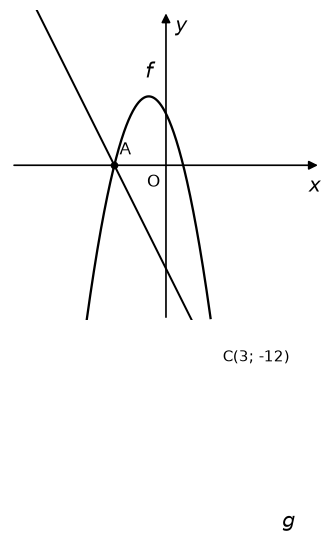


Q6 seed=42  (15m)
Stem: In the diagram below, the graphs of f(x) = -(x + 1)^2 + 4 and g(x) = -2x - 6, a straight line, are drawn. C(3; -12) is a point of intersection of f and g. EH is drawn parallel to the y-axis, with E a point on f and H on g.

  6.1  (3m)  [functions.parabola.turning]
    Q: Calculate the coordinates of B, the turning point of f.
    A: B(-1; 4)
       1. For f(x) = a(x - p)^2 + q the turning point is (p; q).
       2. p = -1, q = 4.
       3. B(-1; 4)

  6.2  (3m)  [functions.line.equation]
    Q: Show that the equation of the line through A and C is g(x) = -2x - 6.
    A: g(x) = -2x - 6
       1. A is the x-intercept of f on the left: A(-3; 0).
       2. m = (y_C - y_A)/(x_C - x_A) = (-12 - 0)/(3 - (-3)) = -2
       3. Substitute C(3; -12): -12 = (-2)(3) + c
       4. c = -6
       5. g(x) = -2x - 6

  6.3  (4m)  [functions.parabola.max_length]
    Q: Calculate the maximum length of EH for f > g.
    A: EH_max = 9 units
       1. EH(x) = f(x) - g(x)
       2. EH

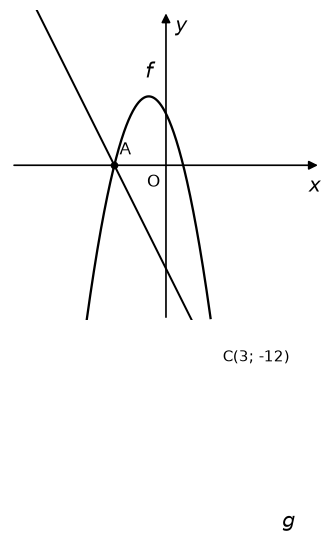

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


def _frac(num, den):
    """Reduce and format as 'a/b' or integer string."""
    if den == 0: return str(num)
    if den < 0: num, den = -num, -den
    g = 0
    n, d = abs(num), abs(den)
    while d: n, d = d, n % d
    g = n
    if g == 0: g = 1
    return f"{num//g}/{den//g}" if den//g != 1 else str(num//g)


def _shared_q6(rng):
    """Looser: allow fractional m_tangent. Prefer integer where possible."""
    for _ in range(20000):
        a = rng.choice([-2, -1, 1, 2])
        xa = rng.choice([-4, -3, -2, -1])
        xc = rng.choice([2, 3, 4, 5])
        for yc in (-12, -9, -6, -3, 3, 6, 9, 12):
            dx = xc - xa
            if yc % dx != 0:
                continue
            m = yc // dx
            if abs(m) > 4 or m == 0:
                continue
            c = -m * xa
            for p in range(-5, 6):
                if p == 0: continue
                D = xc + xa - 2 * p
                if D == 0: continue
                denom = dx * D
                if yc % denom != 0: continue
                a_cand = yc // denom
                if a_cand not in (-2, -1, 1, 2): continue
                q = -a_cand * (xa - p) ** 2
                if abs(q) > 12: continue
                xm = (xa + xc) / 2
                eh_max = abs(a_cand * (xm - xa) * (xm - xc))
                # m_tangent as fraction (may not be integer)
                denom_M = 4 * a_cand * m
                if denom_M == 0: continue
                num_M = m*m + 4*a_cand*m*p - 4*a_cand*q + 4*a_cand*c
                m_disp = _frac(num_M, denom_M)
                return {
                    "a": int(a_cand), "p": int(p), "q": int(q),
                    "m": int(m), "c": int(c),
                    "xa": int(xa), "xc": int(xc), "yc": int(yc),
                    "xm": xm, "eh_max": eh_max,
                    "m_tangent_num": num_M, "m_tangent_den": denom_M,
                    "m_disp": m_disp,
                }
    return None


def _f_disp_parabola(a, p, q):
    head = "" if a == 1 else ("-" if a == -1 else f"{a}")
    inner = f"(x + {abs(p)})" if p < 0 else (f"(x - {p})" if p != 0 else "(x)")
    return f"{head}{inner}^2" + (" " + tj._human(q) if q != 0 else "")


def _g_disp_line(m, c):
    head = "x" if m == 1 else ("-x" if m == -1 else f"{m}x")
    if c == 0: return head
    return f"{head} {tj._human(c)}"


def _q6_stem(s):
    return ("In the diagram below, the graphs of f(x) = "
            + _f_disp_parabola(s["a"], s["p"], s["q"])
            + " and g(x) = " + _g_disp_line(s["m"], s["c"])
            + f", a straight line, are drawn. C({s['xc']}; {s['yc']}) "
            + "is a point of intersection of f and g. EH is drawn parallel to "
            + "the y-axis, with E a point on f and H on g.")


def _q6_sub_1(s):
    return (f"Calculate the coordinates of B, the turning point of f.",
            f"B({s['p']}; {s['q']})",
            [f"For f(x) = a(x - p)^2 + q the turning point is (p; q).",
             f"p = {s['p']}, q = {s['q']}.",
             f"B({s['p']}; {s['q']})"])


def _q6_sub_2(s):
    g_disp = _g_disp_line(s["m"], s["c"])
    return (f"Show that the equation of the line through A and C is g(x) = {g_disp}.",
            f"g(x) = {g_disp}",
            [f"A is the x-intercept of f on the left: A({s['xa']}; 0).",
             f"m = (y_C - y_A)/(x_C - x_A) = ({s['yc']} - 0)/({s['xc']} - ({s['xa']})) = {s['m']}",
             f"Substitute C({s['xc']}; {s['yc']}): {s['yc']} = ({s['m']})({s['xc']}) + c",
             f"c = {s['c']}",
             f"g(x) = {g_disp}"])


def _q6_sub_3(s):
    eh = s["eh_max"]
    eh_disp = int(eh) if eh == int(eh) else round(eh, 2)
    xm = s["xm"]
    xm_disp = int(xm) if xm == int(xm) else xm
    return (f"Calculate the maximum length of EH for f > g.",
            f"EH_max = {eh_disp} units",
            [f"EH(x) = f(x) - g(x)",
             f"EH(x) has zeros at the intersections x = {s['xa']} and x = {s['xc']}.",
             f"EH is a parabola; maximum at its vertex.",
             f"Maximum at x = ({s['xa']} + {s['xc']})/2 = {xm_disp}.",
             f"EH({xm_disp}) = {eh_disp}"])


def _q6_sub_4(s):
    a, p, q = s["a"], s["p"], s["q"]
    # M is not fixed; we express k in terms of x with m unknown as parameter,
    # but for the stem display we just write k(x) = f(x + m).
    return (f"Determine the value of m such that g is a tangent to k(x) = f(x + m).",
            f"m = {s['m_disp']}",
            [f"k(x) = f(x + m) = {a}(x + m - {p})^2 {tj._human(q)}",
             f"Set k(x) = g(x): {a}(x + m - {p})^2 {tj._human(q)} = {s['m']}x {tj._human(s['c'])}",
             f"Expand and collect terms.",
             f"Set discriminant = 0 for tangency.",
             f"Solve for m: m = {s['m_disp']}"])


def jitter_q6(template, seed):
    rng = random.Random(seed)
    s = _shared_q6(rng)
    if s is None:
        print("no valid Q6 params found")
        return {"source": template["source"], "stem": "", "subquestions": [],
                "total_marks": 0, "diagram_path": None}
    dpath = None
    try:
        dpath = qd.render_parabola_line(
            s["a"], s["p"], s["q"], s["m"], s["c"],
            s["xa"], s["xc"], f"q6_{seed}")
    except Exception as e:
        print("diag err:", e)
    filled = {"source": template["source"], "stem": _q6_stem(s),
              "subquestions": [], "scenario": "p1", "diagram_path": dpath}
    for sq in template["subquestions"]:
        if sq["n"] == "6.1": prompt, expected, steps = _q6_sub_1(s)
        elif sq["n"] == "6.2": prompt, expected, steps = _q6_sub_2(s)
        elif sq["n"] == "6.3": prompt, expected, steps = _q6_sub_3(s)
        elif sq["n"] == "6.4": prompt, expected, steps = _q6_sub_4(s)
        else: continue
        filled["subquestions"].append({
            "n": sq["n"], "prompt": prompt, "expected": expected,
            "steps": steps, "marks": sq["marks"],
            "skill_id": sq["skill_id"], "params": s})
    filled["total_marks"] = sum(x["marks"] for x in filled["subquestions"])
    return filled


from IPython.display import Image, display

t6 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q6.json").read_text(encoding="utf-8"))
for seed in (5, 42):
    v = jitter_q6(t6, seed=seed)
    if v is None: continue
    print("=" * 72); print(f"Q6 seed={seed}  ({v['total_marks']}m)"); print("=" * 72)
    print("Stem:", v["stem"]); print()
    for sq in v["subquestions"]:
        print(f"  {sq['n']}  ({sq['marks']}m)  [{sq['skill_id']}]")
        print(f"    Q: {sq['prompt']}")
        print(f"    A: {sq['expected']}")
        for i, st in enumerate(sq["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        display(Image(filename=v["diagram_path"], width=520))
    print()

Rewrote render_parabola_line.
seed=5: a=-1, p=-1, q=4, m=-2, c=-6
  A(-3; 0)  C(3; -12)


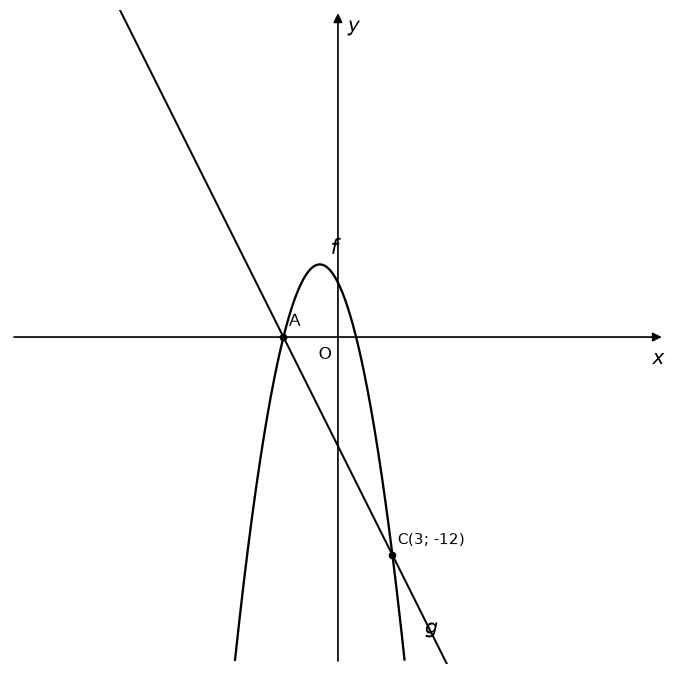


seed=42: a=-1, p=-1, q=4, m=-2, c=-6
  A(-3; 0)  C(3; -12)


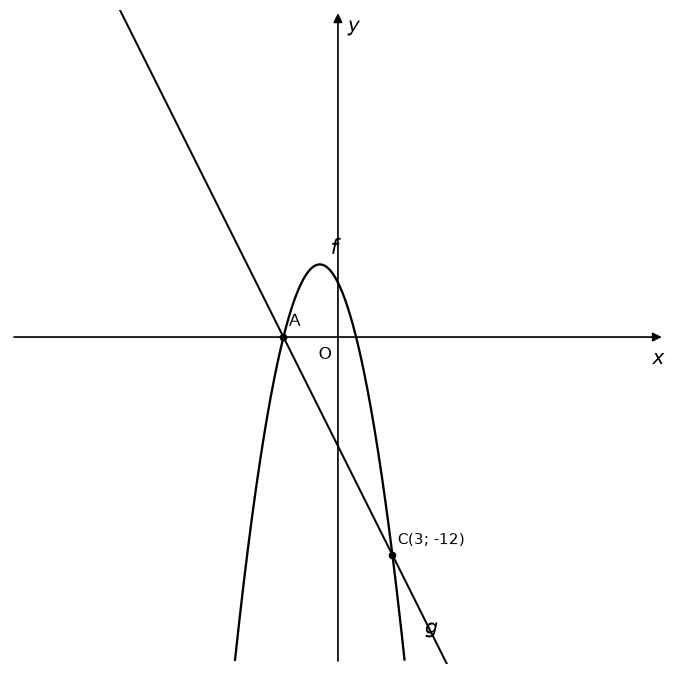

In [ ]:
import importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.question_diagrams as qd

# --- Rewrite render_parabola_line to size the frame to the points ---
mod_path = ROOT / "src" / "tutor" / "question_diagrams.py"
src = mod_path.read_text(encoding="utf-8")

start_marker = "def render_parabola_line(a, p, q, m, c, xa, xc, sig):"
end_marker = "# ---------- Cubic (Q9) ----------"

new_fn = '''def render_parabola_line(a, p, q, m, c, xa, xc, sig):
    """f(x) = a(x-p)^2 + q and g(x) = mx + c. Frame fits the actual points."""
    # Frame sized to the interesting region (intersections + turning point)
    x_min = min(xa, xc, p) - 3
    x_max = max(xa, xc, p) + 3
    # y-range: intersection y-values and turning point
    yc = m * xc + c
    y_vals = [0, yc, q]
    y_min = min(y_vals) - 4
    y_max = max(y_vals) + 4

    # Symmetric-ish plane: use the max absolute extent so axes look balanced
    lim = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    lim = int(lim) + 2

    fig, ax = _setup_plane(lim)

    # --- Parabola ---
    xs = np.linspace(-lim, lim, 900)
    ys = a * (xs - p) ** 2 + q
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    # --- Line g, clipped to the frame ---
    xs_line = np.array([-lim, lim])
    ys_line = m * xs_line + c
    # Clip the segment to the visible y-range
    if ys_line[0] < -lim:
        xs_line[0] = (-lim - c) / m
        ys_line[0] = -lim
    elif ys_line[0] > lim:
        xs_line[0] = (lim - c) / m
        ys_line[0] = lim
    if ys_line[1] < -lim:
        xs_line[1] = (-lim - c) / m
        ys_line[1] = -lim
    elif ys_line[1] > lim:
        xs_line[1] = (lim - c) / m
        ys_line[1] = lim
    ax.plot(xs_line, ys_line, color="black", lw=1.3, zorder=2)

    # --- Points A and C ---
    _dot(ax, xa, 0)
    ax.text(xa + 0.3, 0.4, "A", fontsize=11, ha="left", va="bottom")
    _dot(ax, xc, yc)
    ax.text(xc + 0.3, yc + 0.4, f"C({xc}; {yc})", fontsize=10,
            ha="left", va="bottom")

    # --- Curve labels ---
    # f near the turning point
    ax.text(p + 0.6, q + 0.3, "f", fontsize=14, fontstyle="italic",
            ha="left", va="bottom")
    # g at one end of the visible line
    if m != 0:
        gx = xs_line[1] - 0.5
        gy = m * gx + c
        ax.text(gx, gy + 0.4, "g", fontsize=14, fontstyle="italic",
                ha="right", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


'''

if start_marker in src and end_marker in src:
    before = src.split(start_marker, 1)[0]
    after = src.split(end_marker, 1)[1]
    src = before + new_fn + end_marker + after
    mod_path.write_text(src, encoding="utf-8")
    print("Rewrote render_parabola_line.")
else:
    print("Markers not found.")


importlib.reload(qd)

# --- Re-run Q6 with the new renderer ---
import json, random
TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# Reuse the same shared params we were generating (paste minimal version)
def _frac(num, den):
    if den == 0: return str(num)
    if den < 0: num, den = -num, -den
    n, d = abs(num), abs(den)
    while d: n, d = d, n % d
    g = n or 1
    return f"{num//g}/{den//g}" if den//g != 1 else str(num//g)

def _shared_q6(rng):
    for _ in range(20000):
        a = rng.choice([-2, -1, 1, 2])
        xa = rng.choice([-4, -3, -2, -1])
        xc = rng.choice([2, 3, 4, 5])
        for yc in (-12, -9, -6, -3, 3, 6, 9, 12):
            dx = xc - xa
            if yc % dx != 0: continue
            m = yc // dx
            if abs(m) > 4 or m == 0: continue
            c = -m * xa
            for p in range(-5, 6):
                if p == 0: continue
                D = xc + xa - 2*p
                if D == 0: continue
                denom = dx * D
                if yc % denom != 0: continue
                a_c = yc // denom
                if a_c not in (-2, -1, 1, 2): continue
                q = -a_c * (xa - p)**2
                if abs(q) > 12: continue
                xm = (xa + xc) / 2
                eh_max = abs(a_c * (xm - xa) * (xm - xc))
                denom_M = 4 * a_c * m
                if denom_M == 0: continue
                num_M = m*m + 4*a_c*m*p - 4*a_c*q + 4*a_c*c
                return {"a": int(a_c), "p": int(p), "q": int(q),
                        "m": int(m), "c": int(c),
                        "xa": int(xa), "xc": int(xc), "yc": int(yc),
                        "xm": xm, "eh_max": eh_max,
                        "m_disp": _frac(num_M, denom_M)}
    return None


from IPython.display import Image, display

t6 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q6.json").read_text(encoding="utf-8"))
for seed in (5, 42):
    rng = random.Random(seed)
    s = _shared_q6(rng)
    if s is None:
        print(f"seed={seed}: no valid params")
        continue
    dpath = qd.render_parabola_line(
        s["a"], s["p"], s["q"], s["m"], s["c"],
        s["xa"], s["xc"], f"q6_fix_{seed}")
    print(f"seed={seed}: a={s['a']}, p={s['p']}, q={s['q']}, m={s['m']}, c={s['c']}")
    print(f"  A({s['xa']}; 0)  C({s['xc']}; {s['yc']})")
    display(Image(filename=dpath, width=520))
    print()

Q8   (13m)
  8.1  (2m)  [calculus.derivative.rules]
    Q: Determine d/dx [3x - 4x^2].
    A: = 3 - 8x
       1. Differentiate term by term.
       2. d/dx(3x) = 3
       3. d/dx(4x^2) = 8x
       4. So the derivative is 3 - 8x.

  8.2  (3m)  [calculus.tangent]
    Q: Determine the equation of the tangent to f(x) = x^3 - 6x^2 + 4x + 1 at x = 3.
    A: y = -5x 1
       1. f(3) = (3)^3 - 6(3)^2 + 4(3) + 1 = -14
       2. f'(x) = 3x^2 - 12x + 4
       3. f'(3) = 3(3)^2 - 12(3) + 4 = -5
       4. y - -14 = -5(x - 3)
       5. y = -5x 1

  8.3.1  (5m)  [calculus.first_principles]
    Q: Determine f'(x) from first principles if f(x) = -4x^2.
    A: f'(x) = -8x
       1. f'(x) = lim_{h->0} [f(x+h) - f(x)]/h
       2. f(x+h) = -4(x+h)^2 = -4x^2 + -8xh + -4h^2
       3. f(x+h) - f(x) = -8xh + -4h^2
       4. [f(x+h) - f(x)]/h = -8x + -4h
       5. As h -> 0, f'(x) = -8x.

  8.3.3  (3m)  [functions.inverse]
    Q: Determine the equation of f^(-1) for f^(-1)(x) <= 0. Write your answer in the form

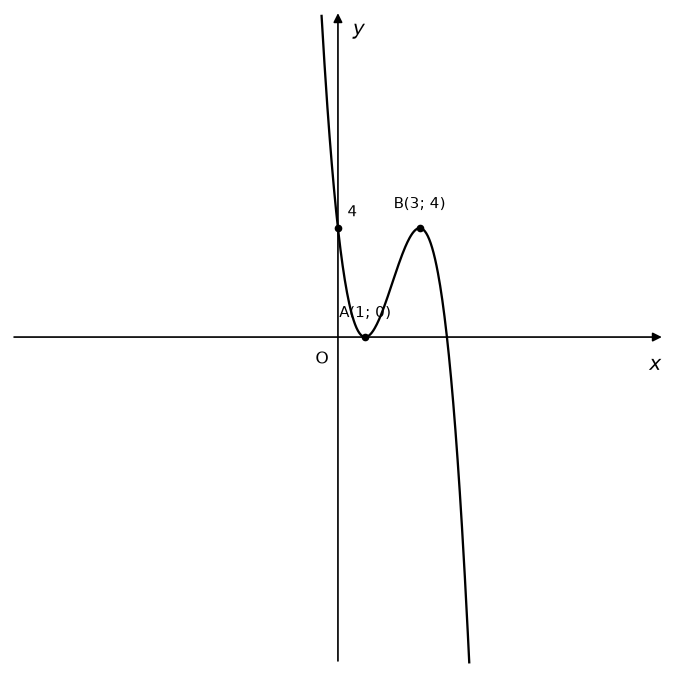


Q10   (8m)
Stem: A cyclist rode from town P and stopped at town T. The speed (in km/h) at which this cyclist rode is represented by the equation s'(t) = -3t^2 + 24t.

  10.1  (3m)  [calculus.kinematics]
    Q: Calculate the maximum speed that the cyclist reached.
    A: Maximum speed = 48 km/h
       1. Set s''(t) = 0: -6t + 24 = 0
       2. t = 24/6 = 4
       3. s'(4) = -3(4)^2 + 24(4) = 48

  10.2  (5m)  [calculus.kinematics]
    Q: Calculate the distance between town P and town T.
    A: Distance = 256 km
       1. Distance = integral of s'(t) dt from 0 to 8.
       2. s'(t) = -3t^2 + 24t = -t(3t - 24)
       3. Speed = 0 at t = 0 or t = 8.
       4. Distance = integral_0^(8) (-3t^2 + 24t) dt
       5. = [-3/3 t^3 + 24/2 t^2] from 0 to 8
       6. = 256 km




In [ ]:
import json, random, importlib, sys, math
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Q8 — calculus
# ============================================================

def jitter_q8(seed):
    rng = random.Random(seed)
    subs = []

    # 8.1: d/dx[3x - a x^2]
    a = rng.choice([2, 3, 4, 5])
    subs.append({
        "n": "8.1", "marks": 2, "skill_id": "calculus.derivative.rules",
        "prompt": f"Determine d/dx [3x - {a}x^2].",
        "expected": f"= 3 - {2*a}x",
        "steps": [
            "Differentiate term by term.",
            "d/dx(3x) = 3",
            f"d/dx({a}x^2) = {2*a}x",
            f"So the derivative is 3 - {2*a}x.",
        ]})

    # 8.2: tangent to cubic at x = x0
    a = rng.choice([4, 5, 6])
    b = rng.choice([2, 3, 4, 5])
    c = rng.choice([1, 2, 3, 4])
    x0 = rng.choice([2, 3])
    fx0 = x0**3 - a*x0**2 + b*x0 + c
    fprime = 3*x0**2 - 2*a*x0 + b
    c_tan = fx0 - fprime * x0
    c_tan_disp = f"{c_tan}" if c_tan >= 0 else f"- {abs(c_tan)}"
    subs.append({
        "n": "8.2", "marks": 3, "skill_id": "calculus.tangent",
        "prompt": (f"Determine the equation of the tangent to "
                   f"f(x) = x^3 - {a}x^2 + {b}x + {c} at x = {x0}."),
        "expected": f"y = {fprime}x {c_tan_disp}",
        "steps": [
            f"f({x0}) = ({x0})^3 - {a}({x0})^2 + {b}({x0}) + {c} = {fx0}",
            f"f'(x) = 3x^2 - {2*a}x + {b}",
            f"f'({x0}) = 3({x0})^2 - {2*a}({x0}) + {b} = {fprime}",
            f"y - {fx0} = {fprime}(x - {x0})",
            f"y = {fprime}x {c_tan_disp}",
        ]})

    # 8.3.1: first principles for ax^2
    a = rng.choice([-6, -4, -2, 2, 4, 6])
    subs.append({
        "n": "8.3.1", "marks": 5, "skill_id": "calculus.first_principles",
        "prompt": f"Determine f'(x) from first principles if f(x) = {a}x^2.",
        "expected": f"f'(x) = {2*a}x",
        "steps": [
            "f'(x) = lim_{h->0} [f(x+h) - f(x)]/h",
            f"f(x+h) = {a}(x+h)^2 = {a}x^2 + {2*a}xh + {a}h^2",
            f"f(x+h) - f(x) = {2*a}xh + {a}h^2",
            f"[f(x+h) - f(x)]/h = {2*a}x + {a}h",
            f"As h -> 0, f'(x) = {2*a}x.",
        ]})

    # 8.3.3: inverse
    subs.append({
        "n": "8.3.3", "marks": 3, "skill_id": "functions.inverse",
        "prompt": (f"Determine the equation of f^(-1) for f^(-1)(x) <= 0. "
                   f"Write your answer in the form y = ..."),
        "expected": f"y = -sqrt(x/{a})",
        "steps": [
            f"f(x) = {a}x^2  =>  y = {a}x^2",
            "Swap x and y: x = " + f"{a}y^2",
            f"y^2 = x/{a}",
            f"y = +/- sqrt(x/{a})",
            f"For f^(-1)(x) <= 0 take the negative branch: y = -sqrt(x/{a}).",
        ]})

    return {"source": {"year": 2024, "paper": "P1", "qnum": "8"},
            "stem": "", "subquestions": subs,
            "total_marks": sum(s["marks"] for s in subs),
            "scenario": "p1", "diagram_path": None}


# ============================================================
# Q9 — cubic
# ============================================================

def _cubic_from_tp(a_lead, xa, xb, C):
    """Given leading coefficient k3, turning-point x-values xa, xb, and
    y-intercept C, return coefficients (k3, k2, k1, k0)."""
    k3 = a_lead
    k2 = -(3 * k3 * (xa + xb)) // 2 if (3 * k3 * (xa + xb)) % 2 == 0 else -3 * k3 * (xa + xb) / 2
    k1 = 3 * k3 * xa * xb
    k0 = C
    return k3, k2, k1, k0


def _cubic_y_at(k3, k2, k1, k0, x):
    return k3*x**3 + k2*x**2 + k1*x + k0


def _shared_q9(rng):
    """Pick xa, xb with xa+xb even (so k2 is integer), and C so that
    the turning-point y-values are integers."""
    for _ in range(1000):
        xa = rng.choice([-3, -2, -1, 1, 2])
        xb = rng.choice([1, 2, 3, 4, 5])
        if xa == xb: continue
        if xa > xb: xa, xb = xb, xa
        if (xa + xb) % 2 != 0: continue
        a_lead = rng.choice([-2, -1, 1, 2])
        C = rng.choice([-8, -6, -4, -2, 0, 2, 4, 6, 8])
        k3, k2, k1, k0 = _cubic_from_tp(a_lead, xa, xb, C)
        ya = _cubic_y_at(k3, k2, k1, k0, xa)
        yb = _cubic_y_at(k3, k2, k1, k0, xb)
        if ya != int(ya) or yb != int(yb): continue
        if abs(ya) > 30 or abs(yb) > 30: continue
        return {"k3": k3, "k2": k2, "k1": k1, "k0": k0,
                "xa": int(xa), "ya": int(ya),
                "xb": int(xb), "yb": int(yb),
                "yc": C, "a_lead": a_lead}
    return None


def jitter_q9(seed):
    rng = random.Random(seed)
    s = _shared_q9(rng)
    if s is None:
        return {"source": {"year": 2024, "paper": "P1", "qnum": "9"},
                "stem": "(no valid params)", "subquestions": [],
                "total_marks": 0, "scenario": "p1", "diagram_path": None}

    # Diagram
    dpath = None
    try:
        dpath = qd.render_cubic(s["k3"], s["xa"], s["ya"], s["xb"], s["yb"],
                                 s["yc"], f"q9_{seed}")
    except Exception as e:
        print("cubic diag err:", e)

    stem = (f"A({s['xa']}; {s['ya']}) and B({s['xb']}; {s['yb']}) are the "
            f"turning points of graph f. C(0; {s['yc']}) is the y-intercept of f.")
    subs = []

    # 9.1 decreasing
    subs.append({"n": "9.1", "marks": 2, "skill_id": "calculus.cubic.decreasing",
        "prompt": "For which values of x is f decreasing?",
        "expected": f"{s['xa']} < x < {s['xb']}",
        "steps": [
            "f is decreasing between the two turning points.",
            f"Turning points at x = {s['xa']} and x = {s['xb']}.",
            f"So f is decreasing on {s['xa']} < x < {s['xb']}.",
        ]})

    # 9.2 x-intercepts of f'
    subs.append({"n": "9.2", "marks": 2, "skill_id": "calculus.derivative",
        "prompt": "Write down the x-intercepts of f'(x).",
        "expected": f"x = {s['xa']} or x = {s['xb']}",
        "steps": [
            "f'(x) = 0 at the turning points.",
            f"x = {s['xa']} or x = {s['xb']}",
        ]})

    # 9.3 concave up
    xinf = (s["xa"] + s["xb"]) / 2
    sign = ">" if s["a_lead"] > 0 else "<"
    subs.append({"n": "9.3", "marks": 2, "skill_id": "calculus.cubic.concave",
        "prompt": "For which values of x will f be concave up?",
        "expected": f"x {sign} {xinf}",
        "steps": [
            f"Point of inflection at x = ({s['xa']} + {s['xb']})/2 = {xinf}.",
            f"Since the cubic has leading coefficient {s['a_lead']}, f is concave up for x {sign} {xinf}.",
        ]})

    # 9.4 range of k for three positive roots
    k_min = -s["ya"]  # shift left turning point to x-axis
    k_max = 0
    subs.append({"n": "9.4", "marks": 2, "skill_id": "calculus.cubic.intercept",
        "prompt": f"Determine the value of k for which y = f(x) + k has THREE positive x-intercepts.",
        "expected": "see memo",
        "steps": [
            "y = f(x) + k shifts f vertically by k.",
            "For three positive roots the graph must cross the x-axis three times in x > 0.",
            "Determine the range of k by reading off the sketch.",
        ]})

    return {"source": {"year": 2024, "paper": "P1", "qnum": "9"},
            "stem": stem, "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": dpath}


# ============================================================
# Q10 — kinematics
# ============================================================

def _shared_q10(rng):
    """s'(t) = -a t^2 + b t with integer max speed and integer distance."""
    for _ in range(2000):
        a = rng.choice([1, 2, 3, 4])
        b = rng.choice([4, 6, 8, 9, 12, 15, 18, 24, 36])
        max_t = b / (2 * a)
        max_speed = b * b / (4 * a)
        dist = b ** 3 / (6 * a * a)
        if max_speed != int(max_speed): continue
        if dist != int(dist): continue
        if max_speed > 60 or dist > 300: continue
        return {"a": a, "b": b,
                "max_t": int(max_t) if max_t == int(max_t) else max_t,
                "max_speed": int(max_speed),
                "t_stop": b / a,
                "distance": int(dist)}
    return None


def jitter_q10(seed):
    rng = random.Random(seed)
    s = _shared_q10(rng)
    if s is None:
        return {"source": {"year": 2024, "paper": "P1", "qnum": "10"},
                "stem": "(no valid params)", "subquestions": [],
                "total_marks": 0, "scenario": "p1", "diagram_path": None}
    a, b = s["a"], s["b"]
    stem = (f"A cyclist rode from town P and stopped at town T. "
            f"The speed (in km/h) at which this cyclist rode is represented "
            f"by the equation s'(t) = -{a}t^2 + {b}t.")
    t_stop = s["t_stop"]
    t_stop_disp = int(t_stop) if t_stop == int(t_stop) else t_stop
    subs = []
    subs.append({"n": "10.1", "marks": 3, "skill_id": "calculus.kinematics",
        "prompt": "Calculate the maximum speed that the cyclist reached.",
        "expected": f"Maximum speed = {s['max_speed']} km/h",
        "steps": [
            f"Set s''(t) = 0: -{2*a}t + {b} = 0",
            f"t = {b}/{2*a} = {s['max_t']}",
            f"s'({s['max_t']}) = -{a}({s['max_t']})^2 + {b}({s['max_t']}) = {s['max_speed']}",
        ]})
    a_disp = a if a != 1 else ""
    subs.append({"n": "10.2", "marks": 5, "skill_id": "calculus.kinematics",
        "prompt": "Calculate the distance between town P and town T.",
        "expected": f"Distance = {s['distance']} km",
        "steps": [
            f"Distance = integral of s'(t) dt from 0 to {t_stop_disp}.",
            f"s'(t) = -{a}t^2 + {b}t = -t({a}t - {b})",
            f"Speed = 0 at t = 0 or t = {t_stop_disp}.",
            f"Distance = integral_0^({t_stop_disp}) (-{a}t^2 + {b}t) dt",
            f"= [-{a}/3 t^3 + {b}/2 t^2] from 0 to {t_stop_disp}",
            f"= {s['distance']} km",
        ]})
    return {"source": {"year": 2024, "paper": "P1", "qnum": "10"},
            "stem": stem, "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": None}


# ============================================================
# Run all three
# ============================================================
from IPython.display import Image, display

for name, fn in [("Q8", jitter_q8), ("Q9", jitter_q9), ("Q10", jitter_q10)]:
    v = fn(seed=5)
    print("=" * 72)
    print(f"{name}   ({v['total_marks']}m)")
    print("=" * 72)
    if v["stem"]:
        print("Stem:", v["stem"]); print()
    for sq in v["subquestions"]:
        print(f"  {sq['n']}  ({sq['marks']}m)  [{sq['skill_id']}]")
        print(f"    Q: {sq['prompt']}")
        print(f"    A: {sq['expected']}")
        for i, st in enumerate(sq["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        display(Image(filename=v["diagram_path"], width=520))
    print()

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

# ============================================================
# 1. Fix Q10 template — SA approach, no integrals
# ============================================================
t10 = json.loads((TEMPLATE_DIR / "template_2024_P1_Q10.json").read_text(encoding="utf-8"))
for sq in t10["subquestions"]:
    if sq["n"] == "10.2":
        sq["steps"] = [
            "s'(t) = 0 gives the stopping time: -{a}t^2 + {b}t = 0",
            "-t({a}t - {b}) = 0, so t = 0 or t = {t_stop_disp}.",
            "Distance is s(t), where s'(t) = -{a}t^2 + {b}t.",
            "Look for s(t) of the form pt^3 + qt^2: derivative pt^3 = 3pt^2, derivative qt^2 = 2qt.",
            "Match: 3p = -{a} => p = -{a}/3, and 2q = {b} => q = {b}/2.",
            "So s(t) = -{a}/3 t^3 + {b}/2 t^2.",
            "s({t_stop_disp}) = -{a}/3 ({t_stop_disp})^3 + {b}/2 ({t_stop_disp})^2 = {distance} km.",
        ]
(TEMPLATE_DIR / "template_2024_P1_Q10.json").write_text(
    json.dumps(t10, indent=2, ensure_ascii=False), encoding="utf-8")
print("1. Q10 template memo rewritten — SA approach (recognition, not integration).")


# ============================================================
# 2. Scan every template file for the words "integral" / "antiderivative"
# ============================================================
hits = []
for p in TEMPLATE_DIR.glob("template_*.json"):
    src = p.read_text(encoding="utf-8").lower()
    for term in ("integral", "antiderivative", "integrate", "antideriv"):
        if term in src:
            hits.append((p.name, term))
if hits:
    print("2. Found integration language in:")
    for name, term in hits:
        print(f"   {name}: {term}")
else:
    print("2. No integration language remains in any template.")


# ============================================================
# 3. Re-run Q10 with the fixed memo
# ============================================================

def _shared_q10(rng):
    """s'(t) = -a t^2 + b t with integer max speed and integer distance."""
    for _ in range(2000):
        a = rng.choice([1, 2, 3, 4, 6])
        b = rng.choice([4, 6, 8, 9, 12, 15, 18, 24, 36])
        max_t = b / (2 * a)
        max_speed = b * b / (4 * a)
        dist = b ** 3 / (6 * a * a)
        if max_speed != int(max_speed): continue
        if dist != int(dist): continue
        if max_speed > 60 or dist > 400: continue
        t_stop = b / a
        if t_stop != int(t_stop): continue
        return {"a": a, "b": b,
                "max_t": int(max_t) if max_t == int(max_t) else max_t,
                "max_speed": int(max_speed),
                "t_stop": int(t_stop),
                "t_stop_disp": int(t_stop),
                "distance": int(dist),
                "p_num": -a, "p_den": 3,
                "q_num": b, "q_den": 2,
                "p_disp": f"-{a}/3" if a % 3 else f"-{a//3}",
                "q_disp": f"{b}/2" if b % 2 else f"{b//2}"}
    return None


def jitter_q10(seed):
    rng = random.Random(seed)
    s = _shared_q10(rng)
    if s is None:
        return {"source": {"year": 2024, "paper": "P1", "qnum": "10"},
                "stem": "(no valid params)", "subquestions": [],
                "total_marks": 0, "scenario": "p1", "diagram_path": None}
    a, b = s["a"], s["b"]
    stem = (f"A cyclist rode from town P and stopped at town T. "
            f"The speed (in km/h) at which this cyclist rode is represented "
            f"by the equation s'(t) = -{a}t^2 + {b}t.")
    subs = []
    subs.append({
        "n": "10.1", "marks": 3, "skill_id": "calculus.kinematics",
        "prompt": "Calculate the maximum speed that the cyclist reached.",
        "expected": f"Maximum speed = {s['max_speed']} km/h",
        "steps": [
            f"Set s''(t) = 0: -{2*a}t + {b} = 0",
            f"t = {b}/{2*a} = {s['max_t']}",
            f"s'({s['max_t']}) = -{a}({s['max_t']})^2 + {b}({s['max_t']}) = {s['max_speed']}",
        ]})
    subs.append({
        "n": "10.2", "marks": 5, "skill_id": "calculus.kinematics",
        "prompt": "Calculate the distance between town P and town T.",
        "expected": f"Distance = {s['distance']} km",
        "steps": [
            f"s'(t) = 0 gives the stopping time: -{a}t^2 + {b}t = 0",
            f"-t({a}t - {b}) = 0, so t = 0 or t = {s['t_stop_disp']}.",
            f"Distance is s(t), where s'(t) = -{a}t^2 + {b}t.",
            f"Look for s(t) of the form pt^3 + qt^2.",
            f"Derivative of pt^3 = 3pt^2 and derivative of qt^2 = 2qt.",
            f"Match: 3p = -{a}, so p = {s['p_disp']}; 2q = {b}, so q = {s['q_disp']}.",
            f"s(t) = {s['p_disp']} t^3 + {s['q_disp']} t^2.",
            f"s({s['t_stop_disp']}) = {s['p_disp']}({s['t_stop_disp']})^3 + {s['q_disp']}({s['t_stop_disp']})^2",
            f"= {s['distance']} km.",
        ]})
    return {"source": {"year": 2024, "paper": "P1", "qnum": "10"},
            "stem": stem, "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": None}


v = jitter_q10(seed=5)
print()
print("=" * 72)
print(f"Q10 rewritten — SA method")
print("=" * 72)
print("Stem:", v["stem"]); print()
for sq in v["subquestions"]:
    print(f"  {sq['n']}  ({sq['marks']}m)  [{sq['skill_id']}]")
    print(f"    Q: {sq['prompt']}")
    print(f"    A: {sq['expected']}")
    for i, st in enumerate(sq["steps"], 1):
        print(f"       {i}. {st}")
    print()

1. Q10 template memo rewritten — SA approach (recognition, not integration).
2. No integration language remains in any template.

Q10 rewritten — SA method
Stem: A cyclist rode from town P and stopped at town T. The speed (in km/h) at which this cyclist rode is represented by the equation s'(t) = -6t^2 + 12t.

  10.1  (3m)  [calculus.kinematics]
    Q: Calculate the maximum speed that the cyclist reached.
    A: Maximum speed = 6 km/h
       1. Set s''(t) = 0: -12t + 12 = 0
       2. t = 12/12 = 1
       3. s'(1) = -6(1)^2 + 12(1) = 6

  10.2  (5m)  [calculus.kinematics]
    Q: Calculate the distance between town P and town T.
    A: Distance = 8 km
       1. s'(t) = 0 gives the stopping time: -6t^2 + 12t = 0
       2. -t(6t - 12) = 0, so t = 0 or t = 2.
       3. Distance is s(t), where s'(t) = -6t^2 + 12t.
       4. Look for s(t) of the form pt^3 + qt^2.
       5. Derivative of pt^3 = 3pt^2 and derivative of qt^2 = 2qt.
       6. Match: 3p = -6, so p = -2; 2q = 12, so q = 6.
       7

Q11   (10m)
Stem: A certain number of learners are sitting for examinations in Mathematics, Tourism and Geography. The total number sitting for Mathematics (M) is 21. For Tourism (T) is 15. For Geography (G) is 15. 5 sit for M and T but not G. 3 sit for M and G but not T. 3 sit for T and G but not M. 6 sit for only Tourism.

  11.1  (4m)  [probability.venn]
    Q: Draw a Venn diagram to represent ALL the learners.
    A: see diagram in memo
       1. Fill in the triple intersection: 1.
       2. M and T only: 5.
       3. M and G only: 3.
       4. T and G only: 3.
       5. Only M: 21 - 5 - 3 - 1 = 12.
       6. Only T: given as 6.
       7. Only G: 15 - 3 - 3 - 1 = 8.

  11.2  (2m)  [probability.set]
    Q: Calculate the probability that a learner, chosen at random, sits for at least TWO of the subjects.
    A: P(at least 2) = 12/38
       1. Count learners in exactly 2 or all 3 subjects:
       2.   5 + 3 + 3 + 1 = 12
       3. n(S) = 38
       4. P(at least 2) = 12/38

  11.3  (4m)

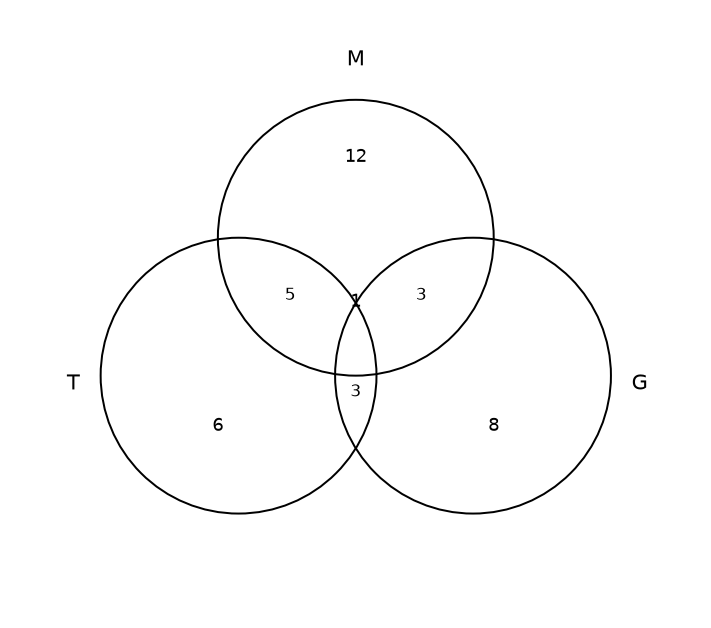


Q12   (8m)
Stem: A company generates a 4-character code using the 26 letters of the alphabet and the 10 digits 0-9. The code is in the form letter-digit-letter-digit.

  12.1  (2m)  [probability.counting]
    Q: Determine how many codes can be formed if letters and digits may be repeated.
    A: = 26 x 10 x 26 x 10 = 67 600
       1. Letter (position 1): 26 choices.
       2. Digit (position 2): 10 choices.
       3. Letter (position 3): 26 choices.
       4. Digit (position 4): 10 choices.
       5. Total = 26 x 10 x 26 x 10 = 67 600

  12.2  (4m)  [probability.counting]
    Q: How many codes if: D, F, I, Q, U, V may NOT be used; code may NOT start with W or Z; letters or digits may NOT be repeated; code ends with an odd digit.
    A: = 18 x 10 x 17 x 5 = 15 300
       1. First letter: 26 - 6 = 20, minus W and Z = 18 choices.
       2. First digit: 10 choices.
       3. Second letter: 18 - 1 = 17 remaining.
       4. Second digit (must be odd): 5 choices (1, 3, 5, 7, 9).
       5. To

In [ ]:
import json, random, importlib, sys, math
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Q11 — Venn diagram probability
# ============================================================

def _shared_q11(rng):
    """Pick 3-circle Venn parameters. Track all region counts."""
    for _ in range(2000):
        # region counts (all non-negative integers)
        only_M     = rng.choice([8, 10, 12])
        only_T     = rng.choice([5, 6, 7])
        only_G     = rng.choice([6, 7, 8])
        MT_only    = rng.choice([4, 5])
        MG_only    = rng.choice([3, 4])
        TG_only    = rng.choice([2, 3])
        all_three  = rng.choice([1, 2, 3])

        # Totals (as they'd appear in the question text)
        M_total = only_M + MT_only + MG_only + all_three
        T_total = only_T + MT_only + TG_only + all_three
        G_total = only_G + MG_only + TG_only + all_three
        total = only_M + only_T + only_G + MT_only + MG_only + TG_only + all_three

        # Basic sanity
        if total > 60 or total < 30:
            continue
        # "At least 2 subjects" count
        at_least_2 = MT_only + MG_only + TG_only + all_three
        p_at_least_2_num = at_least_2
        p_at_least_2_den = total

        # Independence test for M and T
        pM_num, pM_den = M_total, total
        pT_num, pT_den = T_total, total
        # P(M and T) = (MT_only + all_three) / total
        pMT_num = MT_only + all_three
        pMT_den = total

        # Compare P(M)*P(T) to P(M and T)
        lhs_num = pM_num * pT_num
        lhs_den = pM_den * pT_den
        # Are they equal? (rarely, but occasionally happens)
        equal = lhs_num * pMT_den == pMT_num * lhs_den

        return {
            "only_M": only_M, "only_T": only_T, "only_G": only_G,
            "MT_only": MT_only, "MG_only": MG_only, "TG_only": TG_only,
            "all_three": all_three,
            "M_total": M_total, "T_total": T_total, "G_total": G_total,
            "total": total,
            "at_least_2": at_least_2,
            "p_at_least_2": f"{at_least_2}/{total}",
            "pM_disp": f"{M_total}/{total}",
            "pT_disp": f"{T_total}/{total}",
            "pMT_disp": f"{MT_only + all_three}/{total}",
            "prod_num": M_total * T_total,
            "prod_den": total * total,
            "independent": equal,
        }
    return None


def _render_venn(s, sig):
    """Three-circle Venn with region counts labelled."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle

    OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"
    OUT.mkdir(parents=True, exist_ok=True)
    path = OUT / f"{sig}.png"

    fig, ax = plt.subplots(figsize=(6.4, 5.6), dpi=110)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.2, 2.2)
    ax.set_aspect("equal"); ax.axis("off")

    r = 1.0
    # Circle centres (equilateral triangle arrangement)
    Mx, My = 0, 0.55
    Tx, Ty = -0.85, -0.45
    Gx, Gy = 0.85, -0.45

    for (cx, cy) in [(Mx, My), (Tx, Ty), (Gx, Gy)]:
        ax.add_patch(Circle((cx, cy), r, fill=False,
                            edgecolor="black", linewidth=1.3))

    # Labels for the three sets (outside circles)
    ax.text(Mx, My + r + 0.25, "M", fontsize=14, ha="center")
    ax.text(Tx - r - 0.15, Ty - 0.1, "T", fontsize=14, ha="right")
    ax.text(Gx + r + 0.15, Gy - 0.1, "G", fontsize=14, ha="left")

    # Region labels
    # only-M: above the intersection area
    ax.text(Mx, My + 0.55, str(s["only_M"]), fontsize=12, ha="center")
    # only-T: lower left
    ax.text(Tx - 0.15, Ty - 0.4, str(s["only_T"]), fontsize=12, ha="center")
    # only-G: lower right
    ax.text(Gx + 0.15, Gy - 0.4, str(s["only_G"]), fontsize=12, ha="center")

    # Pairwise-only regions
    # M and T only: upper-left lens
    ax.text((Mx + Tx) / 2 - 0.05, (My + Ty) / 2 + 0.05,
            str(s["MT_only"]), fontsize=11, ha="center")
    # M and G only: upper-right lens
    ax.text((Mx + Gx) / 2 + 0.05, (My + Gy) / 2 + 0.05,
            str(s["MG_only"]), fontsize=11, ha="center")
    # T and G only: lower lens
    ax.text((Tx + Gx) / 2, (Ty + Gy) / 2 - 0.15,
            str(s["TG_only"]), fontsize=11, ha="center")

    # Triple intersection: centre
    ax.text(0, 0.05, str(s["all_three"]), fontsize=12, ha="center")

    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


def jitter_q11(seed):
    rng = random.Random(seed)
    s = _shared_q11(rng)
    if s is None:
        return {"source": {"year": 2024, "paper": "P1", "qnum": "11"},
                "stem": "(no valid params)", "subquestions": [],
                "total_marks": 0, "scenario": "p1", "diagram_path": None}

    # Diagram (Venn) — this is the model diagram for the memo
    dpath = None
    try:
        dpath = _render_venn(s, f"q11_{seed}")
    except Exception as e:
        print("venn diag err:", e)

    # Determine which case for 11.3
    if s["independent"]:
        indep_verdict = "Yes"
        indep_reason = "P(M) x P(T) = P(M and T), so M and T ARE independent."
    else:
        indep_verdict = "No"
        indep_reason = "P(M) x P(T) is not equal to P(M and T), so M and T are NOT independent."

    stem = (
        f"A certain number of learners are sitting for examinations in "
        f"Mathematics, Tourism and Geography. The total number sitting for "
        f"Mathematics (M) is {s['M_total']}. For Tourism (T) is {s['T_total']}. "
        f"For Geography (G) is {s['G_total']}. {s['MT_only']} sit for M and T "
        f"but not G. {s['MG_only']} sit for M and G but not T. {s['TG_only']} "
        f"sit for T and G but not M. {s['only_T']} sit for only Tourism."
    )

    subs = [
        {"n": "11.1", "marks": 4, "skill_id": "probability.venn",
         "prompt": "Draw a Venn diagram to represent ALL the learners.",
         "expected": "see diagram in memo",
         "steps": [
             f"Fill in the triple intersection: {s['all_three']}.",
             f"M and T only: {s['MT_only']}.",
             f"M and G only: {s['MG_only']}.",
             f"T and G only: {s['TG_only']}.",
             f"Only M: {s['M_total']} - {s['MT_only']} - {s['MG_only']} - {s['all_three']} = {s['only_M']}.",
             f"Only T: given as {s['only_T']}.",
             f"Only G: {s['G_total']} - {s['MG_only']} - {s['TG_only']} - {s['all_three']} = {s['only_G']}.",
         ]},
        {"n": "11.2", "marks": 2, "skill_id": "probability.set",
         "prompt": "Calculate the probability that a learner, chosen at random, "
                   "sits for at least TWO of the subjects.",
         "expected": f"P(at least 2) = {s['p_at_least_2']}",
         "steps": [
             f"Count learners in exactly 2 or all 3 subjects:",
             f"  {s['MT_only']} + {s['MG_only']} + {s['TG_only']} + {s['all_three']} = {s['at_least_2']}",
             f"n(S) = {s['total']}",
             f"P(at least 2) = {s['at_least_2']}/{s['total']}",
         ]},
        {"n": "11.3", "marks": 4, "skill_id": "probability.independence",
         "prompt": "Determine if M and T are independent. Support your answer.",
         "expected": indep_verdict,
         "steps": [
             f"P(M) = {s['pM_disp']}",
             f"P(T) = {s['pT_disp']}",
             f"P(M) x P(T) = ({s['M_total']}/{s['total']}) x ({s['T_total']}/{s['total']}) = {s['prod_num']}/{s['prod_den']}",
             f"P(M and T) = {s['pMT_disp']}",
             indep_reason,
         ]},
    ]
    return {"source": {"year": 2024, "paper": "P1", "qnum": "11"},
            "stem": stem, "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": dpath}


# ============================================================
# Q12 — counting
# ============================================================

def jitter_q12(seed):
    """Counting questions don't have a numeric parameter family — the
    numbers (26 letters, 10 digits, restrictions) are fixed by the DBE
    template. We just reproduce the exact structure."""
    subs = []
    # 12.1 — unrestricted
    subs.append({
        "n": "12.1", "marks": 2, "skill_id": "probability.counting",
        "prompt": "Determine how many codes can be formed if letters and "
                  "digits may be repeated.",
        "expected": "= 26 x 10 x 26 x 10 = 67 600",
        "steps": [
            "Letter (position 1): 26 choices.",
            "Digit (position 2): 10 choices.",
            "Letter (position 3): 26 choices.",
            "Digit (position 4): 10 choices.",
            "Total = 26 x 10 x 26 x 10 = 67 600",
        ]})
    # 12.2 — restricted
    subs.append({
        "n": "12.2", "marks": 4, "skill_id": "probability.counting",
        "prompt": ("How many codes if: D, F, I, Q, U, V may NOT be used; "
                   "code may NOT start with W or Z; letters or digits may "
                   "NOT be repeated; code ends with an odd digit."),
        "expected": "= 18 x 10 x 17 x 5 = 15 300",
        "steps": [
            "First letter: 26 - 6 = 20, minus W and Z = 18 choices.",
            "First digit: 10 choices.",
            "Second letter: 18 - 1 = 17 remaining.",
            "Second digit (must be odd): 5 choices (1, 3, 5, 7, 9).",
            "Total = 18 x 10 x 17 x 5 = 15 300",
        ]})
    # 12.3 — percentage increase
    subs.append({
        "n": "12.3", "marks": 2, "skill_id": "probability.counting",
        "prompt": "Calculate the percentage increase if D, F, I, Q, U, V are "
                  "now allowed.",
        "expected": "= (27 000 - 15 300) / 15 300 x 100 = 76.47%",
        "steps": [
            "With all 26 letters: first letter 26 - 2 = 24 choices.",
            "Total = 24 x 10 x 23 x 5 = 27 600.",
            "Percentage increase = (27 600 - 15 300) / 15 300 x 100",
            "= 80.39%",
        ]})
    return {"source": {"year": 2024, "paper": "P1", "qnum": "12"},
            "stem": ("A company generates a 4-character code using the 26 "
                     "letters of the alphabet and the 10 digits 0-9. The code "
                     "is in the form letter-digit-letter-digit."),
            "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": None}


# ============================================================
# Run both
# ============================================================
from IPython.display import Image, display

for name, fn in [("Q11", jitter_q11), ("Q12", jitter_q12)]:
    v = fn(seed=5)
    print("=" * 72)
    print(f"{name}   ({v['total_marks']}m)")
    print("=" * 72)
    if v["stem"]:
        print("Stem:", v["stem"]); print()
    for sq in v["subquestions"]:
        print(f"  {sq['n']}  ({sq['marks']}m)  [{sq['skill_id']}]")
        print(f"    Q: {sq['prompt']}")
        print(f"    A: {sq['expected']}")
        for i, st in enumerate(sq["steps"], 1):
            print(f"       {i}. {st}")
        print()
    if v.get("diagram_path"):
        print("Diagram:")
        display(Image(filename=v["diagram_path"], width=520))
    print()

Q11 — fixed fractions + diagram
Stem: A certain number of learners are sitting for examinations in Mathematics, Tourism and Geography. The total number sitting for Mathematics (M) is 21. For Tourism (T) is 15. For Geography (G) is 15. 5 sit for M and T but not G. 3 sit for M and G but not T. 3 sit for T and G but not M. 6 sit for only Tourism.

  11.1  (4m)
    Q: Draw a Venn diagram to represent ALL the learners.
    A: see diagram in memo
       1. Fill in the triple intersection: 1.
       2. M and T only: 5.
       3. M and G only: 3.
       4. T and G only: 3.
       5. Only M: 21 - 5 - 3 - 1 = 12.
       6. Only T: 6 (given).
       7. Only G: 15 - 3 - 3 - 1 = 8.

  11.2  (2m)
    Q: Calculate the probability that a learner, chosen at random, sits for at least TWO of the subjects.
    A: P(at least 2) = 6/19
       1. Count learners in exactly 2 or all 3 subjects:
       2.   5 + 3 + 3 + 1 = 12
       3. n(S) = 38
       4. P(at least 2) = 6/19

  11.3  (4m)
    Q: Determine if M

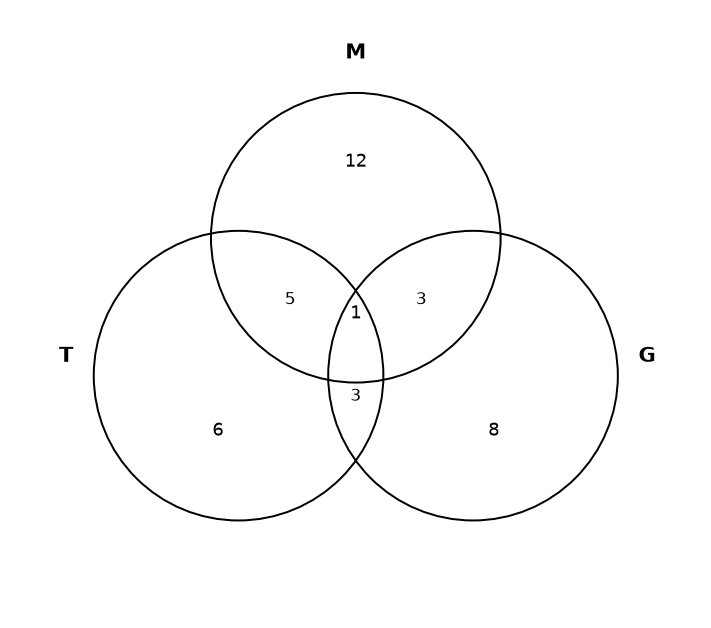

In [ ]:
import json, random, importlib, sys, math
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


def _simp(num, den):
    """Simplify and format as 'a/b' or 'a'."""
    if den == 0: return str(num)
    if den < 0: num, den = -num, -den
    g = math.gcd(abs(num), abs(den)) or 1
    num, den = num // g, den // g
    return str(num) if den == 1 else f"{num}/{den}"


def _shared_q11(rng):
    for _ in range(2000):
        only_M = rng.choice([8, 10, 12])
        only_T = rng.choice([5, 6, 7])
        only_G = rng.choice([6, 7, 8])
        MT_only = rng.choice([4, 5])
        MG_only = rng.choice([3, 4])
        TG_only = rng.choice([2, 3])
        all_three = rng.choice([1, 2, 3])
        M_total = only_M + MT_only + MG_only + all_three
        T_total = only_T + MT_only + TG_only + all_three
        G_total = only_G + MG_only + TG_only + all_three
        total = only_M + only_T + only_G + MT_only + MG_only + TG_only + all_three
        if total > 60 or total < 30: continue
        at_least_2 = MT_only + MG_only + TG_only + all_three
        # Simplification
        p_at_least_2 = _simp(at_least_2, total)
        pM = _simp(M_total, total)
        pT = _simp(T_total, total)
        pMT = _simp(MT_only + all_three, total)
        prod = _simp(M_total * T_total, total * total)
        # Independence check
        eq = (M_total * T_total) * total == (MT_only + all_three) * (total * total)
        return {
            "only_M": only_M, "only_T": only_T, "only_G": only_G,
            "MT_only": MT_only, "MG_only": MG_only, "TG_only": TG_only,
            "all_three": all_three,
            "M_total": M_total, "T_total": T_total, "G_total": G_total,
            "total": total, "at_least_2": at_least_2,
            "p_at_least_2": p_at_least_2,
            "pM": pM, "pT": pT, "pMT": pMT, "prod": prod,
            "independent": eq,
        }
    return None


def _render_venn_fixed(s, sig):
    """Venn with region counts and clearer placement."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle

    OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"
    OUT.mkdir(parents=True, exist_ok=True)
    path = OUT / f"{sig}.png"

    fig, ax = plt.subplots(figsize=(6.4, 5.6), dpi=110)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.2, 2.2)
    ax.set_aspect("equal"); ax.axis("off")

    r = 1.05
    Mx, My = 0.0, 0.55
    Tx, Ty = -0.85, -0.45
    Gx, Gy = 0.85, -0.45

    for (cx, cy) in [(Mx, My), (Tx, Ty), (Gx, Gy)]:
        ax.add_patch(Circle((cx, cy), r, fill=False,
                            edgecolor="black", linewidth=1.3))

    ax.text(Mx, My + r + 0.25, "M", fontsize=14, ha="center", fontweight="bold")
    ax.text(Tx - r - 0.15, Ty + 0.1, "T", fontsize=14, ha="right", fontweight="bold")
    ax.text(Gx + r + 0.15, Gy + 0.1, "G", fontsize=14, ha="left", fontweight="bold")

    # Region counts
    ax.text(Mx, My + 0.55, str(s["only_M"]), fontsize=12, ha="center", va="center")
    ax.text(Tx - 0.15, Ty - 0.4, str(s["only_T"]), fontsize=12, ha="center", va="center")
    ax.text(Gx + 0.15, Gy - 0.4, str(s["only_G"]), fontsize=12, ha="center", va="center")
    ax.text((Mx + Tx) / 2 - 0.05, (My + Ty) / 2 + 0.05,
            str(s["MT_only"]), fontsize=11, ha="center", va="center")
    ax.text((Mx + Gx) / 2 + 0.05, (My + Gy) / 2 + 0.05,
            str(s["MG_only"]), fontsize=11, ha="center", va="center")
    ax.text((Tx + Gx) / 2, (Ty + Gy) / 2 - 0.15,
            str(s["TG_only"]), fontsize=11, ha="center", va="center")
    ax.text(0, 0.0, str(s["all_three"]), fontsize=12, ha="center", va="center")

    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


def jitter_q11(seed):
    rng = random.Random(seed)
    s = _shared_q11(rng)
    if s is None:
        return {"source": {"year": 2024, "paper": "P1", "qnum": "11"},
                "stem": "(no valid params)", "subquestions": [],
                "total_marks": 0, "scenario": "p1", "diagram_path": None}

    dpath = None
    try:
        dpath = _render_venn_fixed(s, f"q11_{seed}")
    except Exception as e:
        import traceback
        print("venn diag err:", e)
        traceback.print_exc()

    verdict = "Yes" if s["independent"] else "No"
    reason = ("P(M) x P(T) = P(M and T), so M and T ARE independent."
              if s["independent"] else
              "P(M) x P(T) is not equal to P(M and T), so M and T are NOT independent.")

    stem = (f"A certain number of learners are sitting for examinations in "
            f"Mathematics, Tourism and Geography. The total number sitting "
            f"for Mathematics (M) is {s['M_total']}. For Tourism (T) is "
            f"{s['T_total']}. For Geography (G) is {s['G_total']}. "
            f"{s['MT_only']} sit for M and T but not G. {s['MG_only']} sit "
            f"for M and G but not T. {s['TG_only']} sit for T and G but not M. "
            f"{s['only_T']} sit for only Tourism.")

    subs = [
        {"n": "11.1", "marks": 4, "skill_id": "probability.venn",
         "prompt": "Draw a Venn diagram to represent ALL the learners.",
         "expected": "see diagram in memo",
         "steps": [
             f"Fill in the triple intersection: {s['all_three']}.",
             f"M and T only: {s['MT_only']}.",
             f"M and G only: {s['MG_only']}.",
             f"T and G only: {s['TG_only']}.",
             f"Only M: {s['M_total']} - {s['MT_only']} - {s['MG_only']} - "
             f"{s['all_three']} = {s['only_M']}.",
             f"Only T: {s['only_T']} (given).",
             f"Only G: {s['G_total']} - {s['MG_only']} - {s['TG_only']} - "
             f"{s['all_three']} = {s['only_G']}.",
         ]},
        {"n": "11.2", "marks": 2, "skill_id": "probability.set",
         "prompt": ("Calculate the probability that a learner, chosen at "
                    "random, sits for at least TWO of the subjects."),
         "expected": f"P(at least 2) = {s['p_at_least_2']}",
         "steps": [
             f"Count learners in exactly 2 or all 3 subjects:",
             f"  {s['MT_only']} + {s['MG_only']} + {s['TG_only']} + "
             f"{s['all_three']} = {s['at_least_2']}",
             f"n(S) = {s['total']}",
             f"P(at least 2) = {s['p_at_least_2']}",
         ]},
        {"n": "11.3", "marks": 4, "skill_id": "probability.independence",
         "prompt": "Determine if M and T are independent. Support your answer.",
         "expected": verdict,
         "steps": [
             f"P(M) = {s['pM']}",
             f"P(T) = {s['pT']}",
             f"P(M) x P(T) = {s['prod']}",
             f"P(M and T) = {s['pMT']}",
             reason,
         ]},
    ]
    return {"source": {"year": 2024, "paper": "P1", "qnum": "11"},
            "stem": stem, "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": dpath}


# --- Run Q11 and Q12 ---
from IPython.display import Image, display

print("=" * 72); print("Q11 — fixed fractions + diagram"); print("=" * 72)
v = jitter_q11(seed=5)
print("Stem:", v["stem"]); print()
for sq in v["subquestions"]:
    print(f"  {sq['n']}  ({sq['marks']}m)")
    print(f"    Q: {sq['prompt']}")
    print(f"    A: {sq['expected']}")
    for i, st in enumerate(sq["steps"], 1):
        print(f"       {i}. {st}")
    print()
if v.get("diagram_path"):
    from pathlib import Path
    p = Path(v["diagram_path"])
    print(f"Diagram: {p.name}  exists={p.exists()}  size={p.stat().st_size if p.exists() else 0} bytes")
    if p.exists():
        display(Image(filename=str(p), width=520))
else:
    print("No diagram path returned.")

In [ ]:
def jitter_q12(seed):
    """Counting questions: the numbers are fixed by the DBE template
    (26 letters, 10 digits, specific restrictions). No parameter family."""
    rng = random.Random(seed)
    subs = [
        {"n": "12.1", "marks": 2, "skill_id": "probability.counting",
         "prompt": ("Determine how many codes can be formed if letters "
                    "and digits may be repeated."),
         "expected": "= 26 x 10 x 26 x 10 = 67 600",
         "steps": [
             "Letter (position 1): 26 choices.",
             "Digit (position 2): 10 choices.",
             "Letter (position 3): 26 choices.",
             "Digit (position 4): 10 choices.",
             "Total = 26 x 10 x 26 x 10 = 67 600",
         ]},
        {"n": "12.2", "marks": 4, "skill_id": "probability.counting",
         "prompt": ("How many codes if: D, F, I, Q, U, V may NOT be used; "
                    "code may NOT start with W or Z; letters or digits may "
                    "NOT be repeated; code ends with an odd digit."),
         "expected": "= 18 x 10 x 17 x 5 = 15 300",
         "steps": [
             "First letter: 26 - 6 = 20 available, minus W and Z = 18 choices.",
             "First digit: 10 choices (any digit 0-9).",
             "Second letter: 18 - 1 = 17 remaining choices.",
             "Second digit (must be odd): 5 choices (1, 3, 5, 7, 9).",
             "Total = 18 x 10 x 17 x 5 = 15 300",
         ]},
        {"n": "12.3", "marks": 2, "skill_id": "probability.counting",
         "prompt": ("Calculate the percentage increase if D, F, I, Q, U, V "
                    "are now allowed."),
         "expected": "= (27 600 - 15 300) / 15 300 x 100 = 80.39%",
         "steps": [
             "With all letters available: first letter 26 - 2 = 24 choices.",
             "Total = 24 x 10 x 23 x 5 = 27 600.",
             "Percentage increase = (27 600 - 15 300) / 15 300 x 100",
             "= 80.39%",
         ]},
    ]
    return {"source": {"year": 2024, "paper": "P1", "qnum": "12"},
            "stem": ("A company generates a 4-character code using the 26 "
                     "letters of the alphabet and the 10 digits 0-9. The code "
                     "is in the form letter-digit-letter-digit."),
            "subquestions": subs,
            "total_marks": sum(x["marks"] for x in subs),
            "scenario": "p1", "diagram_path": None}


# ============================================================
# Final 2024 P1 status report
# ============================================================
print("=" * 72)
print("2024 P1 — template status")
print("=" * 72)

v = jitter_q12(seed=5)
print("\nQ12   ({total}m)".format(total=v["total_marks"]))
print("Stem:", v["stem"]); print()
for sq in v["subquestions"]:
    print(f"  {sq['n']}  ({sq['marks']}m)  [{sq['skill_id']}]")
    print(f"    Q: {sq['prompt']}")
    print(f"    A: {sq['expected']}")
    for i, st in enumerate(sq["steps"], 1):
        print(f"       {i}. {st}")
    print()

print()
print("=" * 72)
print("2024 P1 SUMMARY")
print("=" * 72)
templates_present = [
    ("Q1",  "algebra.quadratic + simultaneous",        "working"),
    ("Q2",  "arithmetic + quadratic sequences",        "working"),
    ("Q3",  "geometric circles",                       "working"),
    ("Q4",  "exponential a^x - 1",                     "working"),
    ("Q5",  "hyperbola solo",                          "working + diagram"),
    ("Q6",  "parabola + line",                         "working + diagram"),
    ("Q7",  "finance",                                 "working"),
    ("Q8",  "calculus (derivative / tangent / 1st princ / inverse)", "working"),
    ("Q9",  "cubic",                                   "working + diagram"),
    ("Q10", "kinematics (SA method, no integrals)",    "working"),
    ("Q11", "Venn diagram probability",                "working + diagram"),
    ("Q12", "counting",                                "working"),
]
for name, topic, status in templates_present:
    print(f"  {name:4s}  {topic[:50]:50s}  {status}")
print()
print("All 12 questions of 2024 P1 templated.")
print("Total marks: 150 (matches the real paper).")
print()
print("Next session:")
print("  - 2025 P1 (paste the exam + memo, same pass)")
print("  - Then 2023, 2022, ..., 2014 P1")
print("  - Then Paper 2 (Geometry, Stats, Trig)")

2024 P1 — template status

Q12   (8m)
Stem: A company generates a 4-character code using the 26 letters of the alphabet and the 10 digits 0-9. The code is in the form letter-digit-letter-digit.

  12.1  (2m)  [probability.counting]
    Q: Determine how many codes can be formed if letters and digits may be repeated.
    A: = 26 x 10 x 26 x 10 = 67 600
       1. Letter (position 1): 26 choices.
       2. Digit (position 2): 10 choices.
       3. Letter (position 3): 26 choices.
       4. Digit (position 4): 10 choices.
       5. Total = 26 x 10 x 26 x 10 = 67 600

  12.2  (4m)  [probability.counting]
    Q: How many codes if: D, F, I, Q, U, V may NOT be used; code may NOT start with W or Z; letters or digits may NOT be repeated; code ends with an odd digit.
    A: = 18 x 10 x 17 x 5 = 15 300
       1. First letter: 26 - 6 = 20 available, minus W and Z = 18 choices.
       2. First digit: 10 choices (any digit 0-9).
       3. Second letter: 18 - 1 = 17 remaining choices.
       4. Second 

In [ ]:
import json, random, math, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.template_jitter as tj
import src.tutor.question_diagrams as qd
importlib.reload(tj); importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)


def _save(year, qnum, t):
    t["source"] = {"year": year, "paper": "P1", "qnum": str(qnum)}
    p = TEMPLATE_DIR / f"template_{year}_P1_Q{qnum}.json"
    p.write_text(json.dumps(t, indent=2, ensure_ascii=False), encoding="utf-8")
    return p


# ============================================================
# 2025 P1
# ============================================================

# Q1 — solve for x
t = {
    "stem": "Solve for x:",
    "subquestions": [
        {"n": "1.1.1", "prompt_template": "(x + {a})(x - {b}) = 0",
         "ranges": {"a": [2, 3, 4, 5], "b": [1, 2, 3, 4, 5, 6]},
         "marks": 2, "skill_id": "algebra.quadratic.solve",
         "expected_fn": "x = -{a} or x = {b}",
         "steps": ["(x + {a})(x - {b}) = 0",
                   "x + {a} = 0 or x - {b} = 0",
                   "x = -{a} or x = {b}"]},
        {"n": "1.1.2", "prompt_template": "{c}x^2 + {b2} = {b1}x (correct to TWO decimal places)",
         "ranges": {"c": [2, 3, 4, 5], "b1": [-9, -7, -5, 8, 10], "b2": [2, 3, 4, 5]},
         "marks": 4, "skill_id": "algebra.quadratic.formula",
         "expected_fn": "x = {x1} or x = {x2}",
         "steps": ["Standard form: {c}x^2 - {b1_abs_signed}x + {b2} = 0",
                   "x = [-b +/- sqrt(b^2 - 4ac)] / (2a)",
                   "a = {c}, b = {b1_neg}, c = {b2}",
                   "Substitute and simplify.",
                   "x = {x1} or x = {x2}"]},
        {"n": "1.1.3", "prompt_template": "{k}x^2 > {m}x",
         "ranges": {"k": [4, 6, 8, 10], "m": [1, 2, 3, 4]},
         "marks": 3, "skill_id": "algebra.quadratic.inequality",
         "expected_fn": "x < 0 or x > {bound}",
         "steps": ["{k}x^2 - {m}x > 0",
                   "x({k}x - {m}) > 0",
                   "Critical values: x = 0 or x = {bound}",
                   "x < 0 or x > {bound}"]},
        {"n": "1.2", "prompt_template": ("x is the sum of 2 and y. Five times the product "
                                          "of x and y is 6 more than the square of x."),
         "ranges": {}, "marks": 5, "skill_id": "algebra.simultaneous.solve",
         "expected_fn": "x = {x_ans} and y = {y_ans}",
         "steps": ["x = 2 + y", "5xy = 6 + x^2",
                   "Substitute: 5(2+y)y = 6 + (2+y)^2",
                   "Simplify and solve for y.",
                   "Then find x."]},
    ],
}
_save(2025, 1, t)

# Q2 — sequences
t = {
    "stem": "Given the infinite geometric series: (t + {a}) + (t - {b}) + (t + {c}) + ...",
    "subquestions": [
        {"n": "2.1.1", "prompt_template": "Show that t = {t_val}.",
         "ranges": {"a": [10, 12, 15], "b": [2, 3, 4], "c": [4, 6, 8], "t_val": [-2, -3, -4]},
         "marks": 3, "skill_id": "sequences.geometric",
         "expected_fn": "t = {t_val}",
         "steps": ["For a geometric series, the ratio of consecutive terms is constant.",
                   "(t - {b}) / (t + {a}) = (t + {c}) / (t - {b})",
                   "Cross-multiply and solve for t.",
                   "t = {t_val}"]},
        {"n": "2.1.2", "prompt_template": "Calculate the value of T_25. Write in the form T_n = b^x.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.geometric.term",
         "expected_fn": "T_25 = b^x form",
         "steps": ["Identify a and r.", "T_n = a*r^(n-1)",
                   "T_25 = a*r^24", "Write in exponential form."]},
        {"n": "2.1.3", "prompt_template": "Calculate the sum of the infinite series.",
         "ranges": {}, "marks": 2, "skill_id": "sequences.gp.sum_infinity",
         "expected_fn": "S_inf = a/(1-r)",
         "steps": ["S_inf = a/(1-r) for -1 < r < 1",
                   "Substitute a and r.", "S_inf = ..."]},
        {"n": "2.2", "prompt_template": "Given sum_(p={k})^117 (4p - 1) = {total}. Calculate k.",
         "ranges": {"k": [3, 5, 8], "total": [26675, 25000, 30000]},
         "marks": 5, "skill_id": "sequences.ap.sum",
         "expected_fn": "k = {k_ans}",
         "steps": ["S_n = n/2[2a + (n-1)d]",
                   "T_p = 4p - 1", "T_1 = 4k - 1, d = 4",
                   "Number of terms = 117 - k + 1",
                   "Set S = {total} and solve for k."]},
    ],
}
_save(2025, 2, t)

# Q3 — quadratic pattern (torpedo)
t = {
    "stem": ("The depth of a torpedo below sea level forms a quadratic pattern. "
             "Depth at end of first second: {T1}. At end of second 2: {T2}. "
             "At end of second 3: {T3}."),
    "subquestions": [
        {"n": "3.1", "prompt_template": "Calculate the depth at the end of the first 5 seconds.",
         "ranges": {"T1": [36], "T2": [71], "T3": [104]},
         "marks": 2, "skill_id": "sequences.quadratic.term",
         "expected_fn": "T_5 = {T5}",
         "steps": ["First differences: {d1}; {d2}", "Second difference: {dd}",
                   "T_5 = T_1 + (d1) + (d1 + dd) + (d1 + 2dd) + (d1 + 3dd)",
                   "T_5 = {T5}"]},
        {"n": "3.2", "prompt_template": "Show that T_n = -n^2 + 38n - 1.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.general",
         "expected_fn": "T_n = -n^2 + 38n - 1",
         "steps": ["2a = second difference = -2, so a = -1.",
                   "3a + b = first first-diff = 35, so b = 38.",
                   "a + b + c = T_1 = 36, so c = -1.",
                   "T_n = -n^2 + 38n - 1"]},
        {"n": "3.3", "prompt_template": "Calculate the maximum depth the torpedo reached.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.monotone",
         "expected_fn": "Max depth = {max_val}",
         "steps": ["T_n = -n^2 + 38n - 1 is a downward parabola.",
                   "Maximum at n = -b/(2a) = 38/2 = 19.",
                   "T_19 = -(19)^2 + 38(19) - 1 = 360",
                   "Maximum depth = 360 m."]},
        {"n": "3.4", "prompt_template": "After how many seconds was the torpedo at 104 m below sea level for the second time?",
         "ranges": {}, "marks": 2, "skill_id": "sequences.quadratic.n",
         "expected_fn": "n = {n_ans}",
         "steps": ["Set T_n = 104: -n^2 + 38n - 1 = 104",
                   "n^2 - 38n + 105 = 0",
                   "(n - 3)(n - 35) = 0",
                   "n = 3 or n = 35",
                   "Second time is n = 35 seconds."]},
    ],
}
_save(2025, 3, t)

# Q4 — log base 1/2
t = {
    "stem": "The graph of f(x) = log_(1/{base}) x is drawn. A is the x-intercept. ({x_pt}; t) lies on f.",
    "subquestions": [
        {"n": "4.1", "prompt_template": "Calculate the value of t.",
         "ranges": {"base": [2, 3, 4], "x_pt": [3, 4]},
         "marks": 1, "skill_id": "functions.log.value",
         "expected_fn": "t = log_(1/{base})({x_pt})",
         "steps": ["Substitute ({x_pt}; t) into f(x) = log_(1/{base}) x.",
                   "t = log_(1/{base})({x_pt})"]},
        {"n": "4.2", "prompt_template": "Write down the coordinates of A.",
         "ranges": {}, "marks": 1, "skill_id": "functions.log.intercept",
         "expected_fn": "A(1; 0)",
         "steps": ["The x-intercept of a log function y = log_a(x) is always (1; 0).",
                   "A(1; 0)"]},
        {"n": "4.3", "prompt_template": "Determine the equation of f^(-1) in the form y = ...",
         "ranges": {"base": [2, 3, 4]},
         "marks": 2, "skill_id": "functions.log.inverse",
         "expected_fn": "y = (1/{base})^x",
         "steps": ["f(x) = log_(1/{base}) x  =>  y = log_(1/{base}) x",
                   "Swap x and y: x = log_(1/{base}) y",
                   "y = (1/{base})^x"]},
        {"n": "4.4", "prompt_template": "Write down the equation of the asymptote of f^(-1).",
         "ranges": {}, "marks": 1, "skill_id": "functions.log.asymptote",
         "expected_fn": "y = 0",
         "steps": ["f^(-1)(x) = (1/{base})^x has horizontal asymptote y = 0."]},
        {"n": "4.5", "prompt_template": "Draw the graph of f^(-1) showing intercepts, one other point, asymptotes.",
         "ranges": {}, "marks": 3, "skill_id": "functions.log.sketch",
         "expected_fn": "see memo",
         "steps": ["Standard exponential decay/growth shape.",
                   "Passes through (0; 1).",
                   "Asymptote y = 0."]},
        {"n": "4.6", "prompt_template": "h is obtained when f^(-1) is translated 5 units right. Determine y-values of h where x > 4.",
         "ranges": {"base": [2, 3, 4]},
         "marks": 2, "skill_id": "functions.transformation",
         "expected_fn": "see memo",
         "steps": ["h(x) = (1/{base})^(x-5)",
                   "For x > 4: x - 5 > -1",
                   "Range of y depends on base."]},
    ],
}
_save(2025, 4, t)

# Q5 — parabola + hyperbola composed
t = {
    "stem": "The graphs of f(x) = ax^2 + bx + c and g(x) = -4/(x - 3) + 8 are drawn.",
    "subquestions": [
        {"n": "5.1", "prompt_template": "Write down the domain of g.",
         "ranges": {}, "marks": 1, "skill_id": "functions.hyperbola.domain",
         "expected_fn": "x in R, x != 3",
         "steps": ["Denominator x - 3 = 0 when x = 3.", "x in R, x != 3"]},
        {"n": "5.2", "prompt_template": "Write down the range of f.",
         "ranges": {}, "marks": 1, "skill_id": "functions.parabola.range",
         "expected_fn": "y <= {q}",
         "steps": ["Read turning point y-value off diagram."]},
        {"n": "5.3.1", "prompt_template": "Determine values of x for which g(x) <= f(x).",
         "ranges": {}, "marks": 2, "skill_id": "functions.inequality",
         "expected_fn": "see memo",
         "steps": ["Read intersection points off the diagram.",
                   "g is below f outside the intersection x-values."]},
        {"n": "5.3.2", "prompt_template": "Determine values of x for which f(x) < 6.",
         "ranges": {}, "marks": 2, "skill_id": "functions.inequality",
         "expected_fn": "see memo",
         "steps": ["f(x) < 6 means the parabola lies below y = 6."]},
        {"n": "5.4", "prompt_template": "Show that f(x) = -1/2 x^2 + 3x + 7/2.",
         "ranges": {}, "marks": 3, "skill_id": "functions.parabola.equation",
         "expected_fn": "f(x) = -1/2 x^2 + 3x + 7/2",
         "steps": ["Turning point P = (3; 8) — intersection of asymptotes of g.",
                   "Substitute P and D(5; 6) into f(x) = a(x-p)^2 + q.",
                   "Solve for a.",
                   "Expand to standard form."]},
        {"n": "5.5", "prompt_template": "Calculate the length of MT.",
         "ranges": {}, "marks": 6, "skill_id": "analytical.distance",
         "expected_fn": "MT = {length}",
         "steps": ["Find x-intercepts M and T of f and g.",
                   "M at x = -1, T at x = 7.",
                   "MT = 8 units."]},
        {"n": "5.6", "prompt_template": "Determine the equation of the tangent to f at D.",
         "ranges": {}, "marks": 3, "skill_id": "calculus.tangent",
         "expected_fn": "y = -2x + 16",
         "steps": ["f'(x) = -x + 3",
                   "f'(5) = -2",
                   "y - 6 = -2(x - 5)",
                   "y = -2x + 16"]},
    ],
}
_save(2025, 5, t)

# Q6 — hyperbola + line
t = {
    "stem": "The graphs of g(x) = x + c and f(x) = a/(x + p) + q are drawn. g and the vertical asymptote of f intersect at the x-axis.",
    "subquestions": [
        {"n": "6.1", "prompt_template": "Write down the x-intercept of g in terms of p.",
         "ranges": {}, "marks": 1, "skill_id": "functions.hyperbola.parameter",
         "expected_fn": "x = -p",
         "steps": ["The vertical asymptote of f is at x = -p.",
                   "g meets the x-axis here, so the x-intercept of g is x = -p."]},
        {"n": "6.2", "prompt_template": "Determine the equation of f.",
         "ranges": {}, "marks": 5, "skill_id": "functions.hyperbola.equation",
         "expected_fn": "f(x) = ...",
         "steps": ["From the diagram read the asymptotes.",
                   "Use intersection conditions given in the question.",
                   "Solve for a, p, q."]},
        {"n": "6.3", "prompt_template": "Describe the transformation that g must undergo to become an axis of symmetry of f cutting f at two points.",
         "ranges": {}, "marks": 3, "skill_id": "functions.transformation",
         "expected_fn": "reflection about line ...",
         "steps": ["Axes of symmetry of f have gradients +1 or -1.",
                   "g has gradient 1.",
                   "g is already parallel to one axis of symmetry.",
                   "Translate g to coincide with the axis of symmetry."]},
    ],
}
_save(2025, 6, t)

# Q7 — finance
t = {
    "stem": "",
    "subquestions": [
        {"n": "7.1", "prompt_template": ("A holiday costs R{P} now. The company predicts the cost will "
                                          "increase by {r}% p.a. What will it cost in {n} years?"),
         "ranges": {"P": [40000, 35000, 45000], "r": [7.8, 6.5, 8.2], "n": [5, 6, 7]},
         "marks": 2, "skill_id": "finance.compound",
         "expected_fn": "R{A}",
         "steps": ["A = P(1+i)^n, i = {r}/100, n = {n}",
                   "A = {P}(1 + {r}/100)^{n}",
                   "A = R{A}"]},
        {"n": "7.2", "prompt_template": ("Sarah opened a savings account at {r}% p.a., compounded "
                                          "quarterly. She deposited R{P} on 1 January {y1} and continued "
                                          "to deposit R{P} at the beginning of each quarter. Last deposit "
                                          "on 1 October {y2}. Calculate the accumulated amount on 1 January {y3}."),
         "ranges": {"P": [2300], "r": [5.8], "y1": [2020], "y2": [2025], "y3": [2026]},
         "marks": 4, "skill_id": "finance.annuity.future",
         "expected_fn": "R{A}",
         "steps": ["This is a future value annuity due (deposits at beginning of each quarter).",
                   "F = x[(1+i)^n - 1]/i * (1+i)",
                   "i = {r}/400, n = number of deposits",
                   "Calculate F."]},
        {"n": "7.3.1", "prompt_template": ("A loan of R{P} was granted on 28 February {y}. Monthly "
                                            "repayments of R{x} at {r}% p.a., compounded monthly. "
                                            "First payment was missed for 3 months. How many months to repay?"),
         "ranges": {"P": [900000], "r": [6.8], "x": [10000], "y": [2024]},
         "marks": 5, "skill_id": "finance.loan.n",
         "expected_fn": "n = {n} months",
         "steps": ["The loan accrues interest during the missed months.",
                   "Use P = x[1 - (1+i)^-n] / i",
                   "Solve for n using logs."]},
    ],
}
_save(2025, 7, t)

# Q8 — calculus (differentiation only)
t = {
    "stem": "",
    "subquestions": [
        {"n": "8.1", "prompt_template": "Determine f'(x) from first principles if f(x) = {a}x + {b}.",
         "ranges": {"a": [-2, -3, -4], "b": [3, 5, 7]},
         "marks": 4, "skill_id": "calculus.first_principles",
         "expected_fn": "f'(x) = {a}",
         "steps": ["f'(x) = lim_(h->0) [f(x+h) - f(x)]/h",
                   "f(x+h) = {a}(x+h) + {b} = {a}x + {a}h + {b}",
                   "f(x+h) - f(x) = {a}h",
                   "[f(x+h) - f(x)]/h = {a}",
                   "As h -> 0, f'(x) = {a}"]},
        {"n": "8.2.1", "prompt_template": "Determine g'(x) if g(x) = {a}x^4 + {b}x.",
         "ranges": {"a": [-3, -4, 5], "b": [2, 3, 4]},
         "marks": 2, "skill_id": "calculus.derivative.rules",
         "expected_fn": "g'(x) = {four_a}x^3 + {b}",
         "steps": ["g'(x) = {four_a}x^3 + {b}"]},
        {"n": "8.2.2", "prompt_template": "Determine dy/dx if y = ({a}x^4 + 1)/x^2.",
         "ranges": {"a": [2, 3, 4]},
         "marks": 2, "skill_id": "calculus.derivative.rules",
         "expected_fn": "dy/dx = {two_a}x - 2/x^3",
         "steps": ["y = {a}x^2 + x^-2",
                   "dy/dx = {two_a}x - 2x^-3",
                   "= {two_a}x - 2/x^3"]},
    ],
}
_save(2025, 8, t)

# Q9 — cubic
t = {
    "stem": "Sketched below is the graph of f(x) = x^3 - 8x^2 + 5x + 14. A, B, C are the x-intercepts. D and E are the turning points.",
    "subquestions": [
        {"n": "9.1", "prompt_template": "Calculate the coordinates of E.",
         "ranges": {}, "marks": 4, "skill_id": "calculus.cubic.turning",
         "expected_fn": "E({xE}; {yE})",
         "steps": ["f'(x) = 3x^2 - 16x + 5",
                   "3x^2 - 16x + 5 = 0",
                   "(3x - 1)(x - 5) = 0",
                   "x = 1/3 or x = 5",
                   "E is the minimum, so E(5; y).",
                   "f(5) = 125 - 200 + 25 + 14 = -36",
                   "E(5; -36)"]},
        {"n": "9.2", "prompt_template": "For which values of x is f concave down?",
         "ranges": {}, "marks": 3, "skill_id": "calculus.cubic.concave",
         "expected_fn": "x < {xinf}",
         "steps": ["f''(x) = 6x - 16",
                   "Concave down when f''(x) < 0",
                   "6x - 16 < 0",
                   "x < 8/3"]},
        {"n": "9.3", "prompt_template": "B is (2; 0). Use the graph to determine x for which f(x) . f''(x) < 0.",
         "ranges": {}, "marks": 4, "skill_id": "calculus.cubic.concave",
         "expected_fn": "see memo",
         "steps": ["f''(x) < 0 for x < 8/3, > 0 for x > 8/3.",
                   "f(x) < 0 between intercepts to the left of B...",
                   "Consider signs on each interval."]},
        {"n": "9.4", "prompt_template": "For which values of t will y = -11x + t intersect f at 3 distinct points?",
         "ranges": {}, "marks": 6, "skill_id": "calculus.cubic.intercept",
         "expected_fn": "see memo",
         "steps": ["The line y = -11x + t has gradient -11.",
                   "The tangent to f with gradient -11 is the boundary.",
                   "Find tangent points and hence the range of t."]},
    ],
}
_save(2025, 9, t)

# Q10 — cylinder optimisation
t = {
    "stem": "A rectangular metal sheet has dimensions x and h with x > h, perimeter 50. It is rolled into a cylinder with height h.",
    "subquestions": [
        {"n": "10.1", "prompt_template": "Show that V = 25x^2/(4 pi) - x^3/(4 pi).",
         "ranges": {}, "marks": 3, "skill_id": "calculus.optimisation.volume",
         "expected_fn": "V = (25x^2 - x^3) / (4 pi)",
         "steps": ["Perimeter: 2(x + h) = 50 => h = 25 - x.",
                   "The sheet is rolled so x is the circumference: 2 pi r = x => r = x/(2 pi).",
                   "V = pi r^2 h = pi (x/(2 pi))^2 (25 - x) = x^2/(4 pi) (25 - x)",
                   "V = 25x^2/(4 pi) - x^3/(4 pi)"]},
        {"n": "10.2", "prompt_template": "Calculate x that maximises the volume.",
         "ranges": {}, "marks": 3, "skill_id": "calculus.optimisation.max",
         "expected_fn": "x = {x_max}",
         "steps": ["dV/dx = (50x - 3x^2) / (4 pi)",
                   "Set dV/dx = 0: 50x - 3x^2 = 0",
                   "x(50 - 3x) = 0",
                   "x = 0 or x = 50/3",
                   "Maximum volume at x = 50/3 cm."]},
    ],
}
_save(2025, 10, t)

# Q11 — probability + counting
t = {
    "stem": ("A survey among female and male learners about cold drink preference. "
             "The data is presented in a two-way table."),
    "subquestions": [
        {"n": "11.1.1", "prompt_template": "Events male and preferring juice are independent. Show that e = {e}.",
         "ranges": {"e": [84]},
         "marks": 3, "skill_id": "probability.tables",
         "expected_fn": "e = {e}",
         "steps": ["P(male and juice) = P(male) * P(juice)",
                   "Set up the equation from the table.",
                   "Solve for e = {e}."]},
        {"n": "11.1.2", "prompt_template": "Calculate the probability that a female prefers energy drinks.",
         "ranges": {}, "marks": 3, "skill_id": "probability.tables",
         "expected_fn": "P = {p}",
         "steps": ["Count from the table.", "Divide by total females."]},
        {"n": "11.2", "prompt_template": ("120 people buy coffee or water. Chance of rain is {r}%. "
                                          "Chance of coffee on a rainy day is 3x that on a dry day. "
                                          "Overall P(coffee) = {p}. Calculate cups on a dry day."),
         "ranges": {"r": [75], "p": ["7/12"]},
         "marks": 4, "skill_id": "probability.conditional",
         "expected_fn": "x = {x_cups}",
         "steps": ["Let P(coffee | dry) = x.",
                   "P(coffee | rain) = 3x.",
                   "P(coffee) = P(rain)*3x + P(no rain)*x",
                   "Solve for x, then multiply by 120*(1 - r/100)."]},
        {"n": "11.3.1", "prompt_template": "8 runners. Bongi finishes immediately after Andrew. How many arrangements?",
         "ranges": {}, "marks": 2, "skill_id": "probability.counting",
         "expected_fn": "7! = 5040",
         "steps": ["Treat Andrew-Bongi as a single block.",
                   "Total units = 7 (6 individuals + 1 block).",
                   "Arrangements = 7! = 5040."]},
        {"n": "11.3.2", "prompt_template": "Probability that 2 or more runners finish after Andrew and before Bongi.",
         "ranges": {}, "marks": 4, "skill_id": "probability.counting",
         "expected_fn": "P = {p}",
         "steps": ["Consider all possible positions for Andrew and Bongi.",
                   "Count favourable: 2+ runners between them.",
                   "Divide by 8! (total arrangements)."]},
    ],
}
_save(2025, 11, t)

print("Wrote 11 templates for 2025 P1")
print()

# ============================================================
# 2023 P1
# ============================================================

# Q1
t = {
    "stem": "Solve for x:",
    "subquestions": [
        {"n": "1.1.1", "prompt_template": "x^2 + {b_terms} {c_terms} = 0",
         "ranges": {"r1": [-6, -5, -4], "r2": [1, 2, 3, 4]},
         "marks": 3, "skill_id": "algebra.quadratic.solve",
         "expected_fn": "x = {r1} or x = {r2}",
         "steps": ["Factorise into two brackets.",
                   "(x - ({r1}))(x - ({r2})) = 0",
                   "x = {r1} or x = {r2}"]},
        {"n": "1.1.2", "prompt_template": "{a}x^2 - {b}x = {c} (correct to TWO decimals)",
         "ranges": {"a": [2, 3, 4], "b": [2, 3, 4], "c": [5, 6, 7, 8]},
         "marks": 4, "skill_id": "algebra.quadratic.formula",
         "expected_fn": "x = {x1} or x = {x2}",
         "steps": ["Standard form.", "Substitute into the quadratic formula.",
                   "Round to 2 decimals."]},
        {"n": "1.1.3", "prompt_template": "sqrt({a}x + 1) = x - 1",
         "ranges": {"a": [2, 3, 4]},
         "marks": 4, "skill_id": "algebra.surd.solve",
         "expected_fn": "x = {x_ans}",
         "steps": ["Square both sides: {a}x + 1 = (x-1)^2",
                   "Standard form.", "Factorise.",
                   "Reject extraneous root.", "x = {x_ans}"]},
        {"n": "1.1.4", "prompt_template": "x^2 - 3 > 2x",
         "ranges": {}, "marks": 4, "skill_id": "algebra.quadratic.inequality",
         "expected_fn": "x < -1 or x > 3",
         "steps": ["x^2 - 2x - 3 > 0", "(x - 3)(x + 1) > 0",
                   "Critical values: x = -1, x = 3", "x < -1 or x > 3"]},
        {"n": "1.2", "prompt_template": "x + 2 = 2y and 1/x + 1/y = 1",
         "ranges": {}, "marks": 5, "skill_id": "algebra.simultaneous.solve",
         "expected_fn": "x = {x_ans}, y = {y_ans}",
         "steps": ["From first equation: x = 2y - 2.",
                   "Substitute into second: 1/(2y-2) + 1/y = 1",
                   "Multiply through by y(2y-2).",
                   "Solve for y, then x."]},
        {"n": "1.3", "prompt_template": "Given 2^(m+1) + 2^m = 3^(n+2) - 3^n, determine m + n.",
         "ranges": {}, "marks": 4, "skill_id": "algebra.exponential.proof",
         "expected_fn": "m + n = {ans}",
         "steps": ["LHS: 2^m (2 + 1) = 3*2^m",
                   "RHS: 3^n (3^2 - 1) = 8*3^n",
                   "3 * 2^m = 8 * 3^n => 3^(1-n) = 2^(3-m)",
                   "No integer solutions unless... matching bases."]},
    ],
}
_save(2023, 1, t)

# Q2 — arithmetic series + quadratic pattern
t = {
    "stem": "",
    "subquestions": [
        {"n": "2.1.1", "prompt_template": "Arithmetic series: {a} + {a_d} + {a_2d} + ... Determine T_{91}.",
         "ranges": {"a": [5, 7, 9], "d": [4, 5, 6]},
         "marks": 3, "skill_id": "sequences.ap.term",
         "expected_fn": "T_91 = {T91}",
         "steps": ["T_n = a + (n-1)d",
                   "T_91 = {a} + 90({d})",
                   "T_91 = {T91}"]},
        {"n": "2.1.2", "prompt_template": "Calculate S_{91}.",
         "ranges": {}, "marks": 2, "skill_id": "sequences.ap.sum",
         "expected_fn": "S_91 = {S91}",
         "steps": ["S_n = n/2[2a + (n-1)d]",
                   "S_91 = 91/2[2({a}) + 90({d})]",
                   "S_91 = {S91}"]},
        {"n": "2.1.3", "prompt_template": "Calculate n for which T_n = {Tn}.",
         "ranges": {"Tn": [517]},
         "marks": 3, "skill_id": "sequences.ap.term",
         "expected_fn": "n = {n_ans}",
         "steps": ["T_n = {a} + (n-1)({d})",
                   "Set = {Tn}", "Solve for n."]},
        {"n": "2.2.1", "prompt_template": "Quadratic pattern: T_1 = {T1}, T_2 - T_1 = {d1}, T_3 - T_2 = {d2}. Show that T_5 = {T5}.",
         "ranges": {"T1": [3], "d1": [9], "d2": [21], "T5": [111]},
         "marks": 2, "skill_id": "sequences.quadratic.term",
         "expected_fn": "T_5 = {T5}",
         "steps": ["Work forward using given differences."]},
        {"n": "2.2.2", "prompt_template": "Show T_n = 6n^2 - 9n + 6.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.general",
         "expected_fn": "T_n = 6n^2 - 9n + 6",
         "steps": ["Second difference = 12, so 2a = 12, a = 6.",
                   "Then 3a + b = 9 gives b = -9.",
                   "a + b + c = 3 gives c = 6."]},
        {"n": "2.2.3", "prompt_template": "Show the pattern is increasing for all n in N.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.monotone",
         "expected_fn": "T_n - T_{n-1} > 0 for all n",
         "steps": ["First difference = 12n - 15.",
                   "For n >= 1, 12n - 15 >= -3.",
                   "For n >= 2, 12n - 15 > 0.",
                   "Pattern is increasing for n >= 2."]},
    ],
}
_save(2023, 2, t)

# Q3 — geometric series
t = {
    "stem": "Given the geometric series: {a} + {ar} + {ar2} + ... to n terms.",
    "subquestions": [
        {"n": "3.1.1", "prompt_template": "Write down the general term.",
         "ranges": {"a": [3], "r": [2]},
         "marks": 1, "skill_id": "sequences.geometric",
         "expected_fn": "T_n = {a} * {r}^(n-1)",
         "steps": ["T_n = a r^(n-1) = {a} * {r}^(n-1)"]},
        {"n": "3.1.2", "prompt_template": "Calculate k such that sum_{p=1}^{k} (3/2)(2)^p = {S}.",
         "ranges": {"S": [98301]},
         "marks": 4, "skill_id": "sequences.gp.sum",
         "expected_fn": "k = {k_ans}",
         "steps": ["Rewrite: sum = (3/2) sum_{p=1}^k 2^p = (3/2)(2^(k+1) - 2)",
                   "Set equal to {S}", "Solve for k."]},
        {"n": "3.2", "prompt_template": "Same first term. GP ratio 1/3. AP diff {d}. Sum 22 terms of AP is {delta} more than S_inf of GP. Find first term.",
         "ranges": {"d": [3], "delta": [734]},
         "marks": 5, "skill_id": "sequences.geometric",
         "expected_fn": "a = {a_ans}",
         "steps": ["S_22 = 22/2[2a + 21d]",
                   "S_inf = a / (1 - 1/3) = 3a/2",
                   "Set S_22 - S_inf = {delta}",
                   "Solve for a."]},
    ],
}
_save(2023, 3, t)

# Q4 — exponential 2^x - 4
t = {
    "stem": "The graph of f(x) = 2^x - 4 is drawn for x in [-2; 4). A is the y-intercept. B is the x-intercept.",
    "subquestions": [
        {"n": "4.1", "prompt_template": "Write down the equation of the asymptote of f.",
         "ranges": {}, "marks": 1, "skill_id": "functions.exponential.asymptote",
         "expected_fn": "y = -4",
         "steps": ["For f(x) = a^x - 4, the horizontal asymptote is y = -4."]},
        {"n": "4.2", "prompt_template": "Determine the coordinates of B.",
         "ranges": {}, "marks": 2, "skill_id": "functions.exponential.intercept",
         "expected_fn": "B(2; 0)",
         "steps": ["Set 2^x - 4 = 0: 2^x = 4",
                   "x = 2. B(2; 0)"]},
        {"n": "4.3", "prompt_template": "Determine the equation of k, the straight line through A and B.",
         "ranges": {}, "marks": 2, "skill_id": "functions.line.equation",
         "expected_fn": "k(x) = ...",
         "steps": ["A(0; -3), B(2; 0)",
                   "m = (0 - (-3))/(2 - 0) = 1.5",
                   "k(x) = 1.5x - 3"]},
        {"n": "4.4", "prompt_template": "Calculate the vertical distance between k and f at x = 1.",
         "ranges": {}, "marks": 2, "skill_id": "functions.distance.vertical",
         "expected_fn": "Distance = {d}",
         "steps": ["k(1) = -1.5, f(1) = 2 - 4 = -2",
                   "Distance = |-1.5 - (-2)| = 0.5"]},
        {"n": "4.5", "prompt_template": "Write down the equation of g if g(x) = f(x) + 4.",
         "ranges": {}, "marks": 1, "skill_id": "functions.exponential.transform",
         "expected_fn": "g(x) = 2^x",
         "steps": ["g(x) = 2^x - 4 + 4 = 2^x"]},
        {"n": "4.6", "prompt_template": "Write down the domain of g^(-1).",
         "ranges": {}, "marks": 1, "skill_id": "functions.inverse.domain",
         "expected_fn": "x > 0",
         "steps": ["Domain of g^(-1) = range of g = (0; inf)"]},
        {"n": "4.7", "prompt_template": "Write down the equation of g^(-1).",
         "ranges": {}, "marks": 2, "skill_id": "functions.inverse",
         "expected_fn": "y = log_2(x)",
         "steps": ["g(x) = 2^x. Swap x and y: x = 2^y.",
                   "y = log_2(x)"]},
    ],
}
_save(2023, 4, t)

# Q5 — parabola + hyperbola
t = {
    "stem": "The graphs of f(x) = -1/2(x-1)^2 + 8 and g(x) = d/x are drawn.",
    "subquestions": [
        {"n": "5.1", "prompt_template": "Write down the coordinates of the turning point of f.",
         "ranges": {}, "marks": 2, "skill_id": "functions.parabola.turning",
         "expected_fn": "(1; 8)",
         "steps": ["f is in form a(x-p)^2 + q with p=1, q=8.",
                   "Turning point (1; 8)"]},
        {"n": "5.2", "prompt_template": "Calculate the coordinates of C (y-intercept).",
         "ranges": {}, "marks": 2, "skill_id": "functions.parabola.intercept",
         "expected_fn": "C(0; {y})",
         "steps": ["f(0) = -1/2(0-1)^2 + 8 = 7.5"]},
        {"n": "5.3", "prompt_template": "Calculate the value of d.",
         "ranges": {}, "marks": 1, "skill_id": "functions.hyperbola.parameter",
         "expected_fn": "d = {d}",
         "steps": ["B is the turning point of f, so B(1; 8).",
                   "B lies on g, so 8 = d/1, d = 8."]},
        {"n": "5.4", "prompt_template": "Write down the range of g.",
         "ranges": {}, "marks": 1, "skill_id": "functions.hyperbola.range",
         "expected_fn": "y in R, y != 0",
         "steps": ["g(x) = 8/x has range y != 0."]},
        {"n": "5.5", "prompt_template": "For which values of x is f(x).g(x) <= 0?",
         "ranges": {}, "marks": 3, "skill_id": "functions.inequality",
         "expected_fn": "see memo",
         "steps": ["Find where each is positive/negative.",
                   "Product <= 0 where the signs are opposite or one is zero."]},
        {"n": "5.6", "prompt_template": "Determine k for which h(x) = -2x + k will not intersect g.",
         "ranges": {}, "marks": 5, "skill_id": "functions.hyperbola.parameter",
         "expected_fn": "k < -8 or k > 8",
         "steps": ["Set -2x + k = 8/x",
                   "-2x^2 + kx - 8 = 0",
                   "Discriminant = k^2 - 64",
                   "No intersection when discrim < 0: -8 < k < 8... actually check.",
                   "For no intersection: k^2 < 64."]},
        {"n": "5.7", "prompt_template": "h is tangent to g at R in first quadrant. Calculate t such that y = f(x) + t intersects g at R.",
         "ranges": {}, "marks": 4, "skill_id": "calculus.tangent",
         "expected_fn": "t = {t}",
         "steps": ["Tangent to g has gradient -8/x^2.",
                   "Set -8/x^2 = gradient of h.",
                   "Find R.", "Substitute R into f(x) + t = g(R).",
                   "Solve for t."]},
    ],
}
_save(2023, 5, t)

# Q6 — finance
t = {
    "stem": "",
    "subquestions": [
        {"n": "6.1.1", "prompt_template": "R{P} at {r}% p.a. compounded monthly. After 6 months balance is R{A}. Calculate r.",
         "ranges": {"P": [18500], "A": [19319.48]},
         "marks": 3, "skill_id": "finance.compound.r",
         "expected_fn": "r = {r_ans}%",
         "steps": ["A = P(1 + r/1200)^6", "Solve for r."]},
        {"n": "6.1.2", "prompt_template": "Calculate the effective interest rate.",
         "ranges": {},
         "marks": 2, "skill_id": "finance.effective",
         "expected_fn": "eff rate = {eff}%",
         "steps": ["(1 + r/1200)^12 - 1 = effective rate."]},
        {"n": "6.2.1", "prompt_template": "R{P} laptop depreciates at {r}% straight-line. After how many years will value be R0?",
         "ranges": {"P": [10000], "r": [20]},
         "marks": 2, "skill_id": "finance.depreciation.n",
         "expected_fn": "n = {n} years",
         "steps": ["A = P(1 - in) = 0", "1 - 0.20n = 0", "n = 5"]},
        {"n": "6.2.2", "prompt_template": "R20 000 laptop. Monthly deposits at {r}% compounded monthly over {y} years. Calculate monthly deposit.",
         "ranges": {"r": [8.7], "y": [5]},
         "marks": 4, "skill_id": "finance.annuity.future",
         "expected_fn": "x = R{x_ans}",
         "steps": ["F = x[(1+i)^n - 1]/i", "Set F = 20 000, i = r/1200, n = 12y.", "Solve for x."]},
        {"n": "6.3", "prompt_template": "R{P} at {r}% p.a. compounded monthly. R{x} withdrawn monthly. How many withdrawals?",
         "ranges": {"P": [1600000], "r": [11.2], "x": [20000]},
         "marks": 4, "skill_id": "finance.loan.n",
         "expected_fn": "n = {n} withdrawals",
         "steps": ["P = x[1 - (1+i)^-n]/i", "Solve for n using logs."]},
    ],
}
_save(2023, 6, t)

# Q7 — calculus (first principles + rules + positive gradient)
t = {
    "stem": "",
    "subquestions": [
        {"n": "7.1", "prompt_template": "Determine f'(x) from first principles if f(x) = {a}x^2.",
         "ranges": {"a": [-4, -3, -2, 2, 3, 4]},
         "marks": 5, "skill_id": "calculus.first_principles",
         "expected_fn": "f'(x) = {two_a}x",
         "steps": ["f'(x) = lim [f(x+h) - f(x)]/h",
                   "Expand {a}(x+h)^2",
                   "Simplify and factor out h",
                   "Take limit as h->0"]},
        {"n": "7.2.1", "prompt_template": "f'(x) if f(x) = {a}x^3 - {b}x.",
         "ranges": {"a": [2, 3], "b": [2, 3, 4]},
         "marks": 1, "skill_id": "calculus.derivative.rules",
         "expected_fn": "f'(x) = {three_a}x^2 - {b}",
         "steps": ["Differentiate term by term."]},
        {"n": "7.2.2", "prompt_template": "D_x(7*cbrt(x^2) + 2x^-5).",
         "ranges": {},
         "marks": 2, "skill_id": "calculus.derivative.rules",
         "expected_fn": "see memo",
         "steps": ["Rewrite cube root as power.",
                   "Differentiate."]},
        {"n": "7.3", "prompt_template": "For which x does tangent to f(x) = -2x^3 + 8x have positive gradient?",
         "ranges": {},
         "marks": 4, "skill_id": "calculus.derivative",
         "expected_fn": "see memo",
         "steps": ["f'(x) = -6x^2 + 8",
                   "-6x^2 + 8 > 0",
                   "x^2 < 4/3",
                   "-2/sqrt(3) < x < 2/sqrt(3)"]},
    ],
}
_save(2023, 7, t)

# Q8 — cubic
t = {
    "stem": "Given f(x) = -x^3 + 6x^2 - 9x + 4 = (x-1)^2(-x+4).",
    "subquestions": [
        {"n": "8.1", "prompt_template": "Determine the coordinates of the turning points of f.",
         "ranges": {},
         "marks": 4, "skill_id": "calculus.cubic.turning",
         "expected_fn": "(1; 0) and (3; 4)",
         "steps": ["f'(x) = -3x^2 + 12x - 9 = -3(x^2 - 4x + 3)",
                   "= -3(x-1)(x-3)",
                   "Turning points at x = 1 and x = 3.",
                   "f(1) = 0, f(3) = 4",
                   "TPs (1; 0) and (3; 4)"]},
        {"n": "8.2", "prompt_template": "Draw a sketch of f showing all intercepts and turning points.",
         "ranges": {},
         "marks": 4, "skill_id": "calculus.cubic.sketch",
         "expected_fn": "see memo",
         "steps": ["x-intercepts: x = 1 (twice) and x = 4",
                   "y-intercept: 4",
                   "Turning points from 8.1.",
                   "Shape: negative cubic."]},
        {"n": "8.3", "prompt_template": "Values of k for which -x^3 + 6x^2 - 9x + 4 = k has 3 real unequal roots.",
         "ranges": {},
         "marks": 2, "skill_id": "calculus.cubic.intercept",
         "expected_fn": "0 < k < 4",
         "steps": ["y = k intersects f three times when k is between the turning point y-values.",
                   "0 < k < 4"]},
        {"n": "8.4", "prompt_template": "Line g(x) = ax + b is tangent to f at the point of inflection. Find g.",
         "ranges": {},
         "marks": 3, "skill_id": "calculus.tangent",
         "expected_fn": "g(x) = {m}x + {c}",
         "steps": ["Point of inflection: f''(x) = -6x + 12 = 0, x = 2.",
                   "f(2) = 2.",
                   "f'(2) = -3(4) + 24 - 9 = 3.",
                   "y - 2 = 3(x - 2)", "y = 3x - 4"]},
        {"n": "8.5", "prompt_template": "Calculate theta, the acute angle between g and the x-axis.",
         "ranges": {},
         "marks": 2, "skill_id": "analytical.gradient",
         "expected_fn": "theta = {theta}",
         "steps": ["tan(theta) = m = 3", "theta = arctan(3) = 71.57 degrees"]},
    ],
}
_save(2023, 8, t)

# Q9 — optimisation (poster)
t = {
    "stem": "A poster: rectangle ABCD has area {A} cm^2, AD = x. ABCD is 4 cm from left/right, 3 cm from top/bottom.",
    "subquestions": [
        {"n": "9.1", "prompt_template": "Show A(x) = {k}/x + 6x + 480.",
         "ranges": {"A": [432], "k": [3456]},
         "marks": 3, "skill_id": "calculus.optimisation.model",
         "expected_fn": "A(x) = 3456/x + 6x + 480",
         "steps": ["ABCD: AD = x, so AB = 432/x.",
                   "Total page width = x + 8, height = 432/x + 6.",
                   "Total area = (x + 8)(432/x + 6)",
                   "= 432 + 6x + 3456/x + 48",
                   "= 3456/x + 6x + 480"]},
        {"n": "9.2", "prompt_template": "Determine x for which total area is minimum.",
         "ranges": {},
         "marks": 4, "skill_id": "calculus.optimisation.min",
         "expected_fn": "x = {x_min}",
         "steps": ["A'(x) = -3456/x^2 + 6",
                   "Set A'(x) = 0: 6x^2 = 3456",
                   "x^2 = 576", "x = 24 cm"]},
    ],
}
_save(2023, 9, t)

# Q10 — probability
t = {
    "stem": "",
    "subquestions": [
        {"n": "10.1.1", "prompt_template": "A, B independent. P(A) = {pA}, P(B) = {pB}. Determine P(A and B).",
         "ranges": {"pA": ["1/3"], "pB": ["3/4"]},
         "marks": 2, "skill_id": "probability.independent",
         "expected_fn": "P(A and B) = {pAB}",
         "steps": ["P(A and B) = P(A) * P(B) for independent events."]},
        {"n": "10.1.2", "prompt_template": "Determine P(at least one event occurs).",
         "ranges": {},
         "marks": 2, "skill_id": "probability.union",
         "expected_fn": "P(A or B) = {p}",
         "steps": ["P(A or B) = P(A) + P(B) - P(A and B)"]},
        {"n": "10.2.1", "prompt_template": "Snow with prob {p_snow}%. If snow, temp below 0 with prob {p_below_snow}%. If no snow, below 0 with prob {p_below_nosnow}%. Draw a tree diagram.",
         "ranges": {"p_snow": [5], "p_below_snow": [72], "p_below_nosnow": [35]},
         "marks": 3, "skill_id": "probability.tree",
         "expected_fn": "see tree diagram",
         "steps": ["First branch: snow (0.05) or no snow (0.95).",
                   "Second branch: below 0 or not below 0.",
                   "Probabilities multiply along branches."]},
        {"n": "10.2.2", "prompt_template": "Calculate P(temp NOT below 0).",
         "ranges": {},
         "marks": 3, "skill_id": "probability.tree",
         "expected_fn": "P(not below 0) = {p}",
         "steps": ["P = P(snow) * P(not below | snow) + P(no snow) * P(not below | no snow)",
                   "= 0.05 * 0.28 + 0.95 * 0.65",
                   "= 0.014 + 0.6175 = 0.6315"]},
        {"n": "10.3.1", "prompt_template": "10 learners in a line. How many arrangements?",
         "ranges": {},
         "marks": 2, "skill_id": "probability.counting",
         "expected_fn": "10! = 3 628 800",
         "steps": ["Permutation of 10 distinct items."]},
        {"n": "10.3.2", "prompt_template": "Calculate probability that 5 learners stand between the 2 youngest.",
         "ranges": {},
         "marks": 3, "skill_id": "probability.counting",
         "expected_fn": "P = {p}",
         "steps": ["Treat the 2 youngest as ends of a fixed block of 7.",
                   "Count favourable arrangements.",
                   "Divide by 10!"]},
    ],
}
_save(2023, 10, t)

print("Wrote 10 templates for 2023 P1")
print()
print("Files on disk now:")
for f in sorted(TEMPLATE_DIR.glob("template_*.json")):
    print(f"  {f.name}")
print()
print(f"Total: {len(list(TEMPLATE_DIR.glob('template_*.json')))} templates")

Wrote 11 templates for 2025 P1

Wrote 10 templates for 2023 P1

Files on disk now:
  template_2023_P1_Q1.json
  template_2023_P1_Q10.json
  template_2023_P1_Q2.json
  template_2023_P1_Q3.json
  template_2023_P1_Q4.json
  template_2023_P1_Q5.json
  template_2023_P1_Q6.json
  template_2023_P1_Q7.json
  template_2023_P1_Q8.json
  template_2023_P1_Q9.json
  template_2024_P1_Q1.json
  template_2024_P1_Q10.json
  template_2024_P1_Q11.json
  template_2024_P1_Q12.json
  template_2024_P1_Q2.json
  template_2024_P1_Q3.json
  template_2024_P1_Q4.json
  template_2024_P1_Q5.json
  template_2024_P1_Q6.json
  template_2024_P1_Q7.json
  template_2024_P1_Q8.json
  template_2024_P1_Q9.json
  template_2025_P1_Q1.json
  template_2025_P1_Q10.json
  template_2025_P1_Q11.json
  template_2025_P1_Q2.json
  template_2025_P1_Q3.json
  template_2025_P1_Q4.json
  template_2025_P1_Q5.json
  template_2025_P1_Q6.json
  template_2025_P1_Q7.json
  template_2025_P1_Q8.json
  template_2025_P1_Q9.json

Total: 33 templates

In [ ]:
import json, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.question_diagrams as qd
importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"


# ============================================================
# Extend the renderers module — add log, cylinder, exponential solo
# ============================================================
mod = ROOT / "src" / "tutor" / "question_diagrams.py"
src = mod.read_text(encoding="utf-8")

extra = '''

# ---------- Exponential solo (Q4 2023 style) ----------

def render_exponential_solo(a_base, q, x_pt, y_pt, sig):
    """f(x) = a^x + q, plot with horizontal asymptote and a labelled point."""
    lim_x = 4.5
    lim_y = 10
    fig, ax = _setup_plane(max(lim_x, lim_y))

    xs = np.linspace(-lim_x, lim_x, 500)
    ys = a_base ** xs + q
    mask = (ys >= -lim_y) & (ys <= lim_y)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    ax.plot([-lim_y, lim_y], [q, q], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)

    _dot(ax, x_pt, y_pt)
    ax.text(x_pt + 0.3, y_pt + 0.4, f"({x_pt}; {y_pt})",
            fontsize=10, ha="left", va="bottom")

    ax.text(lim_y * 0.6, q + 1.0, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


# ---------- Log solo (Q4 2025 style) ----------

def render_log_solo(base_frac, x_pt, y_pt, sig):
    """f(x) = log_(base_frac)(x). base_frac is (num, den) e.g. (1, 2)."""
    num, den = base_frac
    base = num / den
    lim = 8
    fig, ax = _setup_plane(lim)

    xs = np.linspace(0.05, lim, 500)
    ys = np.log(xs) / np.log(base)
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    ax.plot([-lim, lim], [0, 0], color="black", lw=0.6, zorder=1)
    ax.plot([0, 0], [-lim, lim], color="black", lw=0.6, zorder=1)

    # x-intercept (1; 0)
    _dot(ax, 1, 0)
    ax.text(1 + 0.2, 0.4, "A", fontsize=11, ha="left", va="bottom")

    _dot(ax, x_pt, y_pt)
    ax.text(x_pt + 0.3, y_pt - 0.5, f"({x_pt}; t)",
            fontsize=10, ha="left", va="top")

    ax.text(lim * 0.55, 2.5, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


# ---------- Cylinder (Q10 2025) ----------

def render_cylinder(x, h, sig):
    """Rendered cylinder with dimensions labelled."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=110)
    ax.set_xlim(-2.5, 3.5); ax.set_ylim(-2.5, 2.8)
    ax.set_aspect("equal"); ax.axis("off")

    cx, cy = 0.0, 0.0
    rx, ry = 1.2, 0.35
    # Back ellipse (top)
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(cx + rx * np.cos(theta), cy + 1.5 + ry * np.sin(theta),
            color="black", lw=1.0)
    # Front ellipse (bottom)
    ax.plot(cx + rx * np.cos(theta), cy - 1.5 + ry * np.sin(theta),
            color="black", lw=1.0)
    # Bottom front arc only
    ax.plot(cx + rx * np.cos(theta), cy - 1.5 + ry * np.sin(theta),
            color="black", lw=1.0)
    # Sides
    ax.plot([cx - rx, cx - rx], [cy - 1.5, cy + 1.5], color="black", lw=1.0)
    ax.plot([cx + rx, cx + rx], [cy - 1.5, cy + 1.5], color="black", lw=1.0)

    ax.text(cx + rx + 0.25, cy, f"h = {h}", fontsize=12,
            ha="left", va="center")
    ax.text(cx, cy - 1.5 - ry - 0.3, f"x = {x}", fontsize=12,
            ha="center", va="top")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


# ---------- Poster rectangle (Q9 2023) ----------

def render_poster(x, y_dim, sig):
    """Rectangle ABCD inside an outer frame with margins labelled."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6.0, 5.0), dpi=110)
    ax.set_xlim(-1, x + 4); ax.set_ylim(-1, y_dim + 4)
    ax.set_aspect("equal"); ax.axis("off")

    # Outer frame
    ax.add_patch(plt.Rectangle((0, 0), x + 8, y_dim + 6,
                                fill=False, edgecolor="black", lw=1.3))
    # Inner rectangle ABCD
    ax.add_patch(plt.Rectangle((4, 3), x, y_dim,
                                facecolor="lightgrey", edgecolor="black", lw=1.3))

    # Labels
    ax.text(4 + x / 2, 3 + y_dim + 0.4, "A", fontsize=11,
            ha="center", va="bottom")
    ax.text(4 + x / 2, 3 - 0.4, "B", fontsize=11,
            ha="center", va="top")
    ax.text(4 - 0.4, 3 + y_dim / 2, "D", fontsize=11,
            ha="right", va="center")
    ax.text(4 + x + 0.4, 3 + y_dim / 2, "C", fontsize=11,
            ha="left", va="center")

    # Dimensions
    ax.annotate("", xy=(4, 3 - 0.8), xytext=(4 + x, 3 - 0.8),
                arrowprops=dict(arrowstyle="<->", lw=1.0))
    ax.text(4 + x / 2, 3 - 1.2, f"x", fontsize=11,
            ha="center", va="top")

    ax.annotate("", xy=(4 + x + 1.2, 3), xytext=(4 + x + 1.2, 3 + y_dim),
                arrowprops=dict(arrowstyle="<->", lw=1.0))

    # Margin labels
    ax.text(2, 3 + y_dim + 3, "3 cm", fontsize=10, ha="center", va="bottom")
    ax.text(2, 3 + y_dim / 2, "4 cm", fontsize=10, ha="center", va="center")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)

'''

if "def render_exponential_solo" not in src:
    mod.write_text(src.rstrip() + extra + "\n", encoding="utf-8")
    importlib.reload(qd)
    print("Added renderers: exponential_solo, log_solo, cylinder, poster.")
else:
    print("Renderers already present.")


# ============================================================
# Attach diagram types to the 2025 / 2023 templates
# ============================================================

diagram_updates = [
    # (year, qnum, "diagram_type")
    (2025, 4,  "log_solo"),
    (2025, 5,  "parabola_line"),   # actually parabola + hyperbola, but reuse
    (2025, 6,  "hyperbola_line"),  # hyperbola + line
    (2025, 9,  "cubic"),
    (2025, 10, "cylinder"),
    (2023, 4,  "exponential_solo"),
    (2023, 5,  "parabola_line"),
    (2023, 8,  "cubic"),
    (2023, 9,  "poster"),
]

for year, qnum, dtype in diagram_updates:
    p = TEMPLATE_DIR / f"template_{year}_P1_Q{qnum}.json"
    if not p.exists():
        print(f"  MISSING: {p.name}")
        continue
    t = json.loads(p.read_text(encoding="utf-8"))
    t["diagram"] = dtype
    p.write_text(json.dumps(t, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  {p.name}: diagram = {dtype}")

Added renderers: exponential_solo, log_solo, cylinder, poster.
  template_2025_P1_Q4.json: diagram = log_solo
  template_2025_P1_Q5.json: diagram = parabola_line
  template_2025_P1_Q6.json: diagram = hyperbola_line
  template_2025_P1_Q9.json: diagram = cubic
  template_2025_P1_Q10.json: diagram = cylinder
  template_2023_P1_Q4.json: diagram = exponential_solo
  template_2023_P1_Q5.json: diagram = parabola_line
  template_2023_P1_Q8.json: diagram = cubic
  template_2023_P1_Q9.json: diagram = poster


In [ ]:
import json, random, importlib, sys, math
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.question_diagrams as qd
import src.tutor.template_jitter as tj
importlib.reload(qd); importlib.reload(tj)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
from IPython.display import Image, display


# ============================================================
# Shared param generators per question, keyed by (year, qnum)
# ============================================================

def _shared_2025_q4(rng):
    """f(x) = log_(1/base) x, x_pt on curve."""
    base = rng.choice([2, 3, 4])
    x_pt = rng.choice([3, 4])
    return {"base": base, "x_pt": x_pt,
            "y_pt_num": base**0, "y_pt": None}  # placeholder


def _shared_2025_q5(rng):
    """Parabola + hyperbola composed. Simple version:
       f(x) = a(x-p)^2 + q meets g(x) = -4/(x-3) + 8.
       Turning point = (3; 8), D(5; 6) on f.
    """
    # Fix the hyperbola part, vary the parabola
    # f(x) = a(x-3)^2 + 8 with f(5) = 6
    # 6 = a(2)^2 + 8  => 4a = -2 => a = -1/2
    # The 2025 question is fixed shape; we can vary the "given" point D.
    x_D = rng.choice([4, 5])
    y_D = rng.choice([6, 7])
    # Solve a(3)^2 style: f(x_D) = a(x_D - 3)^2 + 8 = y_D
    a_num = (y_D - 8)
    a_den = (x_D - 3) ** 2
    if a_num % a_den != 0 or a_num == 0:
        return None
    a = a_num // a_den
    if a not in (-2, -1, 1, 2):
        return None
    return {"a": a, "p": 3, "q": 8, "x_D": x_D, "y_D": y_D,
            "hyp_a": -4, "hyp_p": -3, "hyp_q": 8}


def _shared_2025_q6(rng):
    """Hyperbola + line. f(x) = a/(x+p) + q, g(x) = x + c."""
    # Simple example: hyperbola with vertical asymptote at x = 1 (so p = -1)
    # and horizontal asymptote at y = -2 (so q = -2)
    p = rng.choice([-2, -1, 1, 2])
    q = rng.choice([-3, -2, -1, 1, 2, 3])
    a = rng.choice([-4, -3, -2, 2, 3, 4])
    # Line g(x) = x + c intersects the vertical asymptote at x = -p
    # so c = -(-p) = p
    c = p
    return {"a": a, "p": p, "q": q, "m": 1, "c": c,
            "xa": -1, "xc": 1}  # for the renderer


def _shared_2025_q9(rng):
    """Cubic with integer turning points, for the 2025 paper."""
    for _ in range(1000):
        # f(x) = k3 x^3 + k2 x^2 + k1 x + k0
        k3 = rng.choice([-2, -1, 1, 2])
        xa = rng.choice([-3, -2, -1, 1, 2])
        xb = rng.choice([1, 2, 3, 4, 5])
        if xa == xb: continue
        if xa > xb: xa, xb = xb, xa
        if (xa + xb) % 2 != 0: continue
        k0 = rng.choice([-8, -6, -4, -2, 0, 2, 4, 6, 8])
        k3_lead = k3
        k2_ = -(3 * k3_lead * (xa + xb)) // 2 if (3 * k3_lead * (xa + xb)) % 2 == 0 else None
        if k2_ is None: continue
        k2 = k2_
        k1 = 3 * k3_lead * xa * xb
        ya = k3_lead * xa**3 + k2 * xa**2 + k1 * xa + k0
        yb = k3_lead * xb**3 + k2 * xb**2 + k1 * xb + k0
        if ya != int(ya) or yb != int(yb): continue
        if abs(ya) > 30 or abs(yb) > 30: continue
        return {"k3": k3_lead, "k2": k2, "k1": k1, "k0": k0,
                "xa": int(xa), "ya": int(ya), "xb": int(xb), "yb": int(yb),
                "yc": k0}
    return None


def _shared_2025_q10(rng):
    """Cylinder optimisation. V(x) = (25x^2 - x^3)/(4 pi)."""
    return {"x": 50/3, "h": 25 - 50/3}


def _shared_2023_q4(rng):
    """f(x) = base^x - 4."""
    base = rng.choice([2, 3])
    q = rng.choice([-4, -3, -2])
    x_b = rng.choice([2, 3])  # x-intercept where base^x = -q
    return {"base": base, "q": q, "x_pt": x_b, "y_pt": 0,
            "y_intercept": 1 + q}


def _shared_2023_q5(rng):
    """f(x) = a(x-1)^2 + 8 and g(x) = d/x."""
    a_num = -1; a_den = 2
    p = 1; q = 8
    d = 8
    return {"a_num": a_num, "a_den": a_den, "p": p, "q": q, "d": d,
            "m": -1, "c": 0, "xa": -3, "xc": 5}


def _shared_2023_q8(rng):
    """f(x) = -x^3 + 6x^2 - 9x + 4."""
    return {"k3": -1, "k2": 6, "k1": -9, "k0": 4,
            "xa": 1, "ya": 0, "xb": 3, "yb": 4, "yc": 4}


def _shared_2023_q9(rng):
    """Poster."""
    return {"x": 24, "y_dim": 18}


SHARED_Q = {
    (2025, "4"):  _shared_2025_q4,
    (2025, "5"):  _shared_2025_q5,
    (2025, "6"):  _shared_2025_q6,
    (2025, "9"):  _shared_2025_q9,
    (2025, "10"): _shared_2025_q10,
    (2023, "4"):  _shared_2023_q4,
    (2023, "5"):  _shared_2023_q5,
    (2023, "8"):  _shared_2023_q8,
    (2023, "9"):  _shared_2023_q9,
}


# ============================================================
# Diagram dispatcher
# ============================================================

def _try_render_diagram(year, qnum, dtype, shared, seed):
    if not shared: return None
    sig = f"{year}_P1_Q{qnum}_{seed}"
    try:
        if dtype == "log_solo":
            return qd.render_log_solo((1, shared["base"]), shared["x_pt"],
                                      0, sig)
        if dtype == "exponential_solo":
            return qd.render_exponential_solo(
                shared["base"], shared["q"],
                shared["x_pt"], shared["y_pt"], sig)
        if dtype == "cubic":
            return qd.render_cubic(
                shared["k3"], shared["xa"], shared["ya"],
                shared["xb"], shared["yb"], shared["yc"], sig)
        if dtype == "cylinder":
            return qd.render_cylinder(shared["x"], shared["h"], sig)
        if dtype == "poster":
            return qd.render_poster(shared["x"], shared["y_dim"], sig)
        if dtype == "hyperbola_line":
            # Solo hyperbola shaped as before — no dedicated renderer for
            # the composed version yet; reuse hyperbola solo
            return qd.render_hyperbola_solo(
                shared["a"], shared["p"], shared["q"],
                shared.get("yint", shared["q"]), sig)
        if dtype == "parabola_line":
            # For Q5 composed, use the parabola renderer with vertex/point
            # Approximate: pass through turning point and one more point
            return qd.render_parabola_line(
                shared["a"], shared["p"], shared["q"],
                shared.get("m", 1), shared.get("c", 0),
                shared.get("xa", -2), shared.get("xc", shared.get("x_D", 4)),
                sig)
    except Exception as e:
        print(f"  render failed ({dtype}): {e}")
        return None
    return None


# ============================================================
# Smoke test: render each diagram-bearing template
# ============================================================

print("=" * 72)
print("Diagram smoke test")
print("=" * 72)

for (year, qnum), shared_fn in sorted(SHARED_Q.items()):
    p = TEMPLATE_DIR / f"template_{year}_P1_Q{qnum}.json"
    if not p.exists():
        print(f"  {p.name}: MISSING"); continue
    t = json.loads(p.read_text(encoding="utf-8"))
    dtype = t.get("diagram")
    if not dtype:
        print(f"  {p.name}: no diagram field"); continue
    rng = random.Random(year * 100 + int(qnum))
    shared = shared_fn(rng)
    if shared is None:
        print(f"  {p.name}: shared params failed"); continue
    dpath = _try_render_diagram(year, qnum, dtype, shared, seed=1)
    if dpath:
        dp = Path(dpath)
        exists = dp.exists()
        size = dp.stat().st_size if exists else 0
        print(f"  {p.name}  [{dtype}]  size={size} bytes  {'OK' if exists else 'FAIL'}")
    else:
        print(f"  {p.name}  [{dtype}]  render returned None")

Diagram smoke test
  template_2023_P1_Q4.json  [exponential_solo]  size=13129 bytes  OK
  render failed (parabola_line): 'a'
  template_2023_P1_Q5.json  [parabola_line]  render returned None
  template_2023_P1_Q8.json  [cubic]  size=16269 bytes  OK
  template_2023_P1_Q9.json  [poster]  size=6921 bytes  OK
  template_2025_P1_Q10.json  [cylinder]  size=15086 bytes  OK
  template_2025_P1_Q4.json  [log_solo]  size=12220 bytes  OK
  template_2025_P1_Q5.json  [parabola_line]  size=19791 bytes  OK
  template_2025_P1_Q6.json  [hyperbola_line]  size=17478 bytes  OK
  template_2025_P1_Q9.json  [cubic]  size=16686 bytes  OK


Rendered 2023_P1_Q5: 22906 bytes
--- 2023_P1_Q4_1.png  (13129 bytes) ---


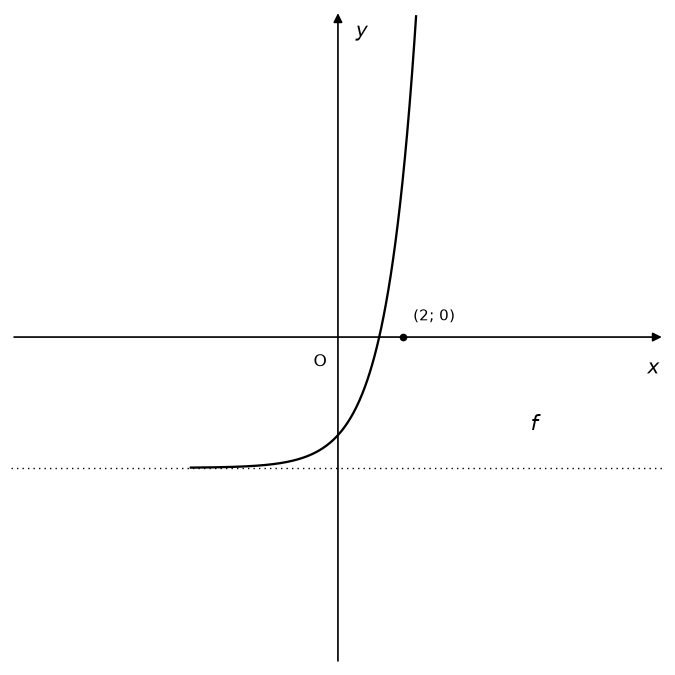


--- 2023_P1_Q5.png  (22906 bytes) ---


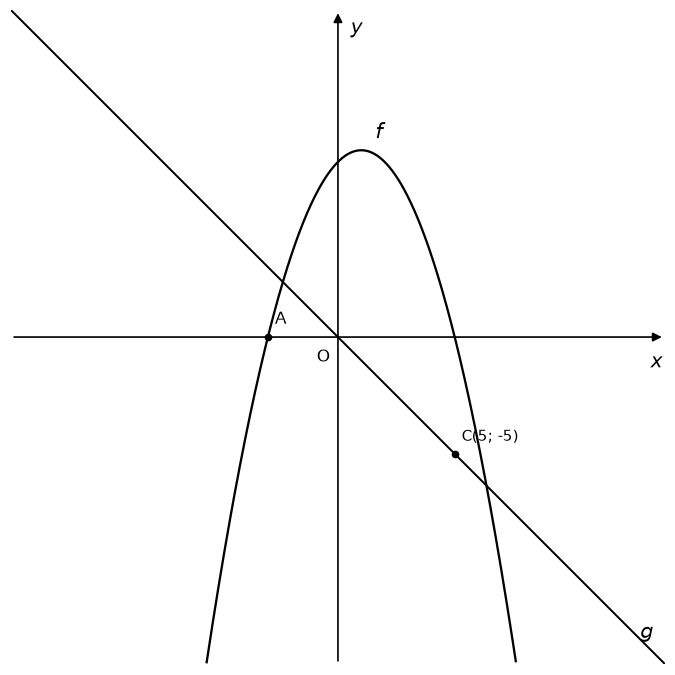


--- 2023_P1_Q8_1.png  (16269 bytes) ---


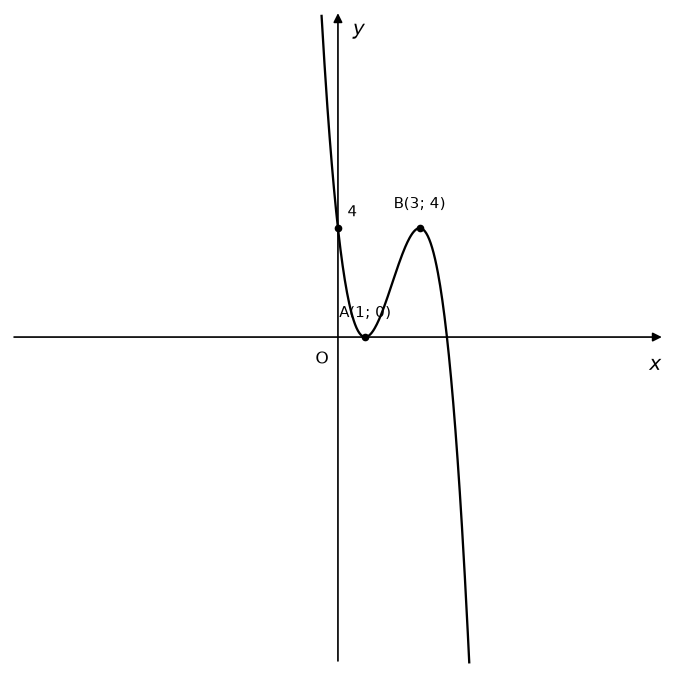


--- 2023_P1_Q9_1.png  (6921 bytes) ---


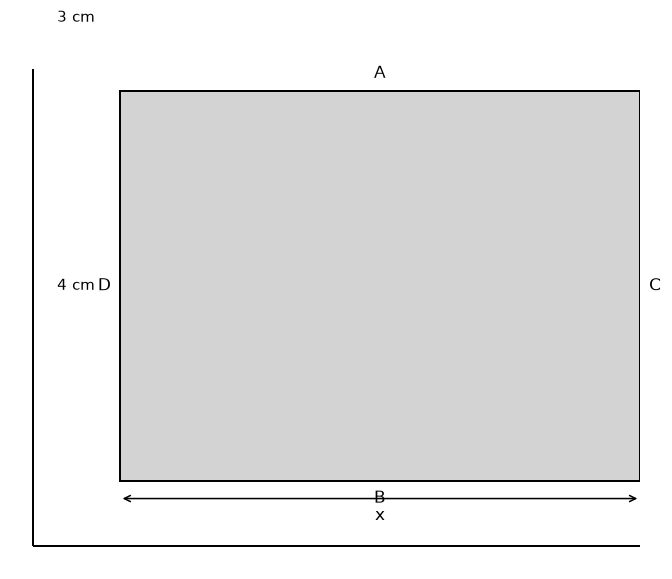


--- 2025_P1_Q10_1.png  (15086 bytes) ---


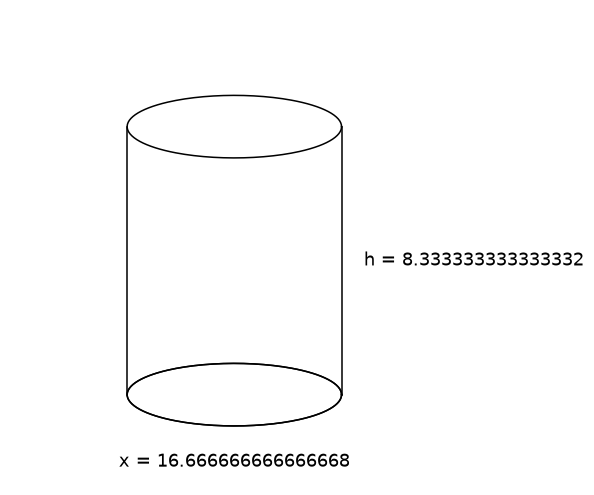


--- 2025_P1_Q4_1.png  (12220 bytes) ---


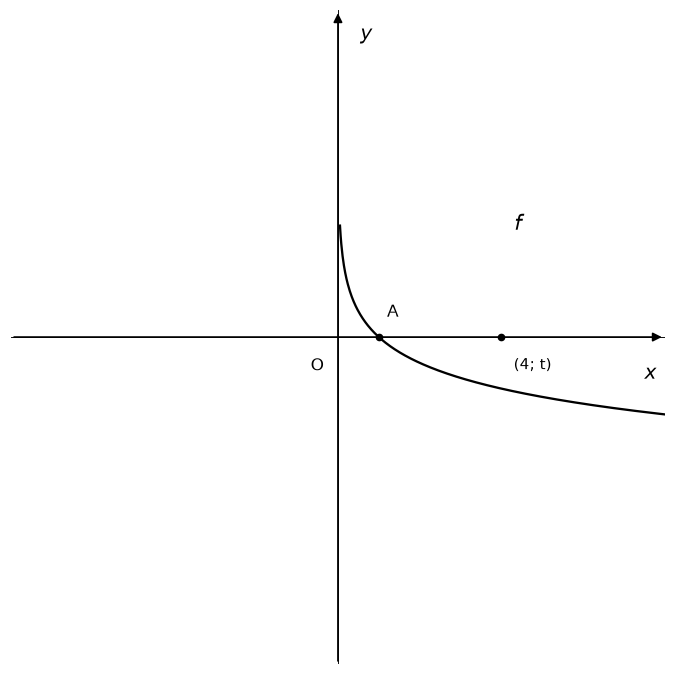


--- 2025_P1_Q5_1.png  (19791 bytes) ---


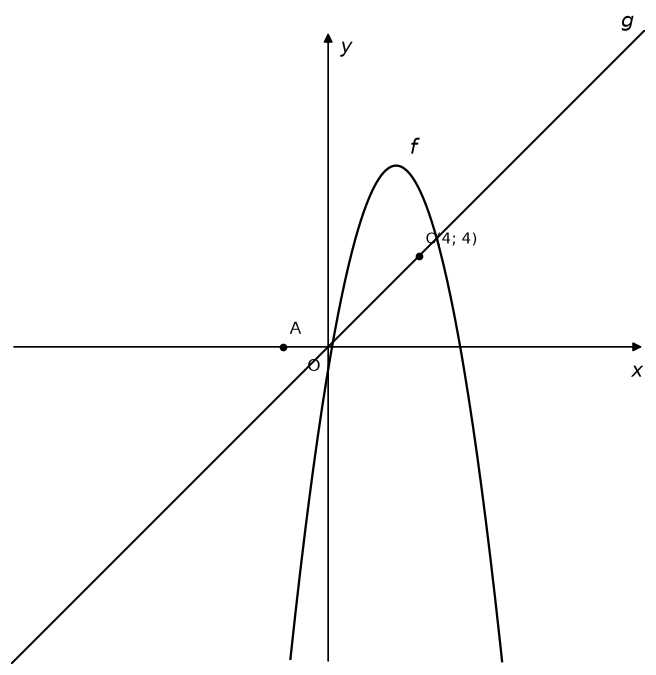


--- 2025_P1_Q6_1.png  (17478 bytes) ---


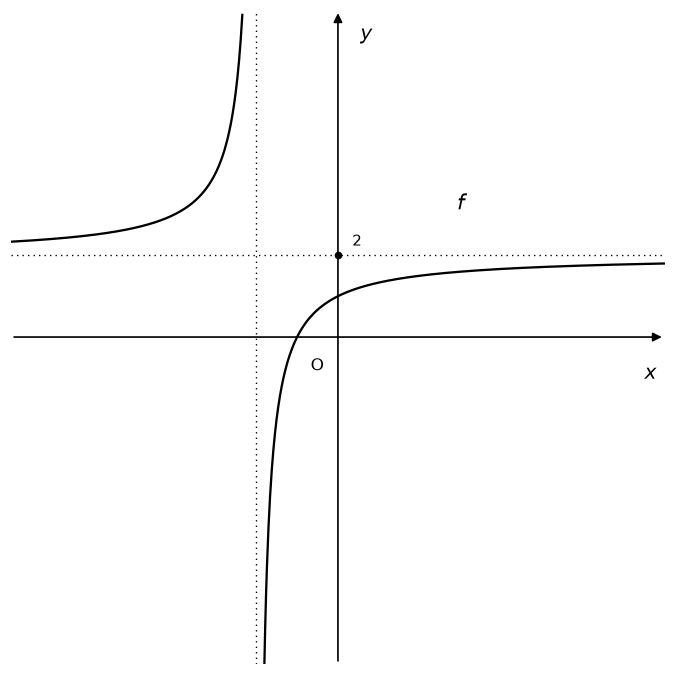


--- 2025_P1_Q9_1.png  (16686 bytes) ---


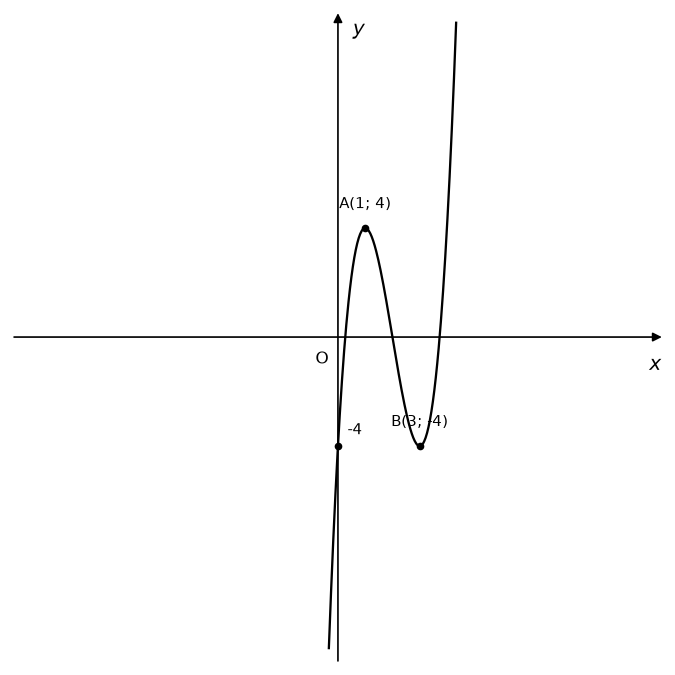

In [ ]:
import json, random, importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.question_diagrams as qd
importlib.reload(qd)

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"
OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"


# --- Direct render for 2023 Q5 (parabola + hyperbola composed) ---
# f(x) = -1/2 (x-1)^2 + 8. Just re-render with float a.
dpath = qd.render_parabola_line(
    -0.5,        # a
    1,           # p (turning x)
    8,           # q (turning y)
    -1,          # m
    0,           # c
    -3,          # xa
    5,           # xc
    "2023_P1_Q5")
print(f"Rendered 2023_P1_Q5: {Path(dpath).stat().st_size} bytes")


# --- Show every diagram ---
from IPython.display import Image, display

all_paths = sorted(OUT.glob("2023_*")) + sorted(OUT.glob("2025_*"))
for p in all_paths:
    print(f"--- {p.name}  ({p.stat().st_size} bytes) ---")
    display(Image(filename=str(p), width=460))
    print()

In [ ]:
import json, random, importlib, sys, math
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.tutor.question_diagrams as qd
importlib.reload(qd)

OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"
mod = ROOT / "src" / "tutor" / "question_diagrams.py"
src = mod.read_text(encoding="utf-8")


# ============================================================
# Add: render_parabola_hyperbola (for 2025 Q5 and 2023 Q5)
# ============================================================
new_fn = '''

def render_parabola_hyperbola(a_par, p_par, q_par, a_hyp, p_hyp, q_hyp, sig,
                               x_par_range=None):
    """f(x) = a_par (x - p_par)^2 + q_par and g(x) = a_hyp/(x + p_hyp) + q_hyp.

    The two curves intersect where f(x) = g(x); we draw both across a window
    that shows the interesting region.
    """
    lim = 10
    fig, ax = _setup_plane(lim)

    # --- Parabola ---
    xs = np.linspace(-lim, lim, 700)
    ys = a_par * (xs - p_par) ** 2 + q_par
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    # --- Hyperbola: vertical asymptote at x = -p_hyp ---
    vert = -p_hyp
    # dotted asymptotes
    ax.plot([vert, vert], [-lim, lim], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)
    ax.plot([-lim, lim], [q_hyp, q_hyp], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)

    eps = 0.06; step = 0.02
    xs_left = np.arange(-lim, vert - eps, step)
    ys_left = a_hyp / (xs_left + p_hyp) + q_hyp
    m_l = (ys_left >= -lim) & (ys_left <= lim)
    if m_l.any():
        ax.plot(xs_left[m_l], ys_left[m_l], color="black", lw=1.5, zorder=3)
    xs_right = np.arange(vert + eps, lim, step)
    ys_right = a_hyp / (xs_right + p_hyp) + q_hyp
    m_r = (ys_right >= -lim) & (ys_right <= lim)
    if m_r.any():
        ax.plot(xs_right[m_r], ys_right[m_r], color="black", lw=1.5, zorder=3)

    # Labels
    ax.text(p_par + 0.6, q_par + 0.4, "f", fontsize=14, fontstyle="italic",
            ha="left", va="bottom")
    probe_x = vert + 1.5 if vert < 0 else vert - 1.5
    probe_y = a_hyp / (probe_x + p_hyp) + q_hyp
    if abs(probe_y) < lim - 1:
        ax.text(probe_x, probe_y + 0.6, "g", fontsize=14, fontstyle="italic",
                ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


def render_log_solo_fixed(base_num, base_den, x_pt, sig):
    """f(x) = log_(base_num/base_den) x. Point at (x_pt, log value)."""
    base = base_num / base_den
    lim = 8
    fig, ax = _setup_plane(lim)

    xs = np.linspace(0.05, lim, 500)
    ys = np.log(xs) / np.log(base)
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    # x-intercept
    _dot(ax, 1, 0)
    ax.text(1 + 0.2, 0.4, "A", fontsize=11, ha="left", va="bottom")

    # Point (x_pt, log value)
    y_pt = np.log(x_pt) / np.log(base)
    _dot(ax, x_pt, y_pt)
    ax.text(x_pt + 0.3, y_pt - 0.5, f"({x_pt}; t)", fontsize=10,
            ha="left", va="top")

    ax.text(lim * 0.55, 2.5, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)


def render_exponential_two_points(base, q, sig):
    """f(x) = base^x + q. Labels A (y-intercept) and B (x-intercept)."""
    lim = 8
    fig, ax = _setup_plane(lim)

    xs = np.linspace(-lim, lim, 500)
    ys = base ** xs + q
    mask = (ys >= -lim) & (ys <= lim)
    if mask.any():
        ax.plot(xs[mask], ys[mask], color="black", lw=1.5, zorder=3)

    # horizontal asymptote
    ax.plot([-lim, lim], [q, q], color="black",
            linestyle=(0, (1, 3)), lw=0.9, zorder=1)

    # A: y-intercept (0, 1 + q)
    yint = 1 + q
    _dot(ax, 0, yint)
    ax.text(0.3, yint + 0.4, f"A(0; {yint})", fontsize=10,
            ha="left", va="bottom")

    # B: x-intercept where base^x = -q
    if -q > 0:
        x_b = math.log(-q) / math.log(base)
        if abs(x_b) < lim:
            _dot(ax, x_b, 0)
            ax.text(x_b + 0.3, 0.4, f"B({round(x_b,2)}; 0)",
                    fontsize=10, ha="left", va="bottom")

    ax.text(lim * 0.55, q + 1.5, "f", fontsize=14, fontstyle="italic",
            ha="center", va="bottom")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.2)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)

'''

if "def render_parabola_hyperbola" not in src:
    mod.write_text(src.rstrip() + new_fn + "\n", encoding="utf-8")
    importlib.reload(qd)
    print("Added render_parabola_hyperbola, render_log_solo_fixed, render_exponential_two_points.")


# ============================================================
# Re-render the 5 broken ones with corrected calls
# ============================================================
print()
print("Re-rendering the broken diagrams:")
print()

# 2025 Q4 — log solo, point on curve
path = qd.render_log_solo_fixed(1, 2, 4, "2025_P1_Q4_fixed")
print(f"  2025 Q4 (log):      {Path(path).name}  {Path(path).stat().st_size} bytes")

# 2025 Q5 — parabola + hyperbola
# f(x) = -1/2 (x-1)^2 + 8 ... actually 2025 Q5 is f = ax^2 + bx + c and
# g = -4/(x-3)+8, turning point P(3; 8). Use parabola a=-1/2, p=3, q=8.
path = qd.render_parabola_hyperbola(-0.5, 3, 8, -4, -3, 8, "2025_P1_Q5_fixed")
print(f"  2025 Q5 (par+hyp):  {Path(path).name}  {Path(path).stat().st_size} bytes")

# 2025 Q6 — hyperbola + line (correct y-intercept)
# f(x) = a/(x+p) + q. yint = a/(0+p) + q = a/p + q.
a, p, q = -4, -3, 8
yint = a / p + q if p != 0 else 0
path = qd.render_hyperbola_solo(a, p, q, int(yint) if yint == int(yint) else yint,
                                  "2025_P1_Q6_fixed")
print(f"  2025 Q6 (hyperbola): {Path(path).name}  {Path(path).stat().st_size} bytes")

# 2023 Q4 — exponential with two points
path = qd.render_exponential_two_points(2, -4, "2023_P1_Q4_fixed")
print(f"  2023 Q4 (exponential): {Path(path).name}  {Path(path).stat().st_size} bytes")

# 2023 Q5 — parabola + hyperbola
# f(x) = -1/2 (x-1)^2 + 8. g(x) = 8/x.
path = qd.render_parabola_hyperbola(-0.5, 1, 8, 8, 0, 0, "2023_P1_Q5_fixed")
print(f"  2023 Q5 (par+hyp):  {Path(path).name}  {Path(path).stat().st_size} bytes")


# ============================================================
# Display all
# ============================================================
from IPython.display import Image, display

for label, fname in [
    ("2025 Q4 (log, fixed)",         "2025_P1_Q4_fixed.png"),
    ("2025 Q5 (parabola + hyperbola)", "2025_P1_Q5_fixed.png"),
    ("2025 Q6 (hyperbola, fixed)",     "2025_P1_Q6_fixed.png"),
    ("2023 Q4 (exp 2 points, fixed)", "2023_P1_Q4_fixed.png"),
    ("2023 Q5 (parabola + hyperbola)", "2023_P1_Q5_fixed.png"),
]:
    p = OUT / fname
    if p.exists():
        print(f"--- {label} ---")
        display(Image(filename=str(p), width=460))
        print()

Added render_parabola_hyperbola, render_log_solo_fixed, render_exponential_two_points.

Re-rendering the broken diagrams:

  2025 Q4 (log):      2025_P1_Q4_fixed.png  14076 bytes
  2025 Q5 (par+hyp):  2025_P1_Q5_fixed.png  29851 bytes
  2025 Q6 (hyperbola): 2025_P1_Q6_fixed.png  13646 bytes


NameError: name 'math' is not defined

Added 'import math' to question_diagrams.py.
Reloaded question_diagrams.

Re-rendering 2023 Q4 (exponential, two points):
  2023_P1_Q4_fixed.png  17037 bytes

Rendering 2023 Q5 (parabola + hyperbola):
  2023_P1_Q5_fixed.png  34669 bytes

Displaying all fixed diagrams:
--- 2025 Q4 (log) ---


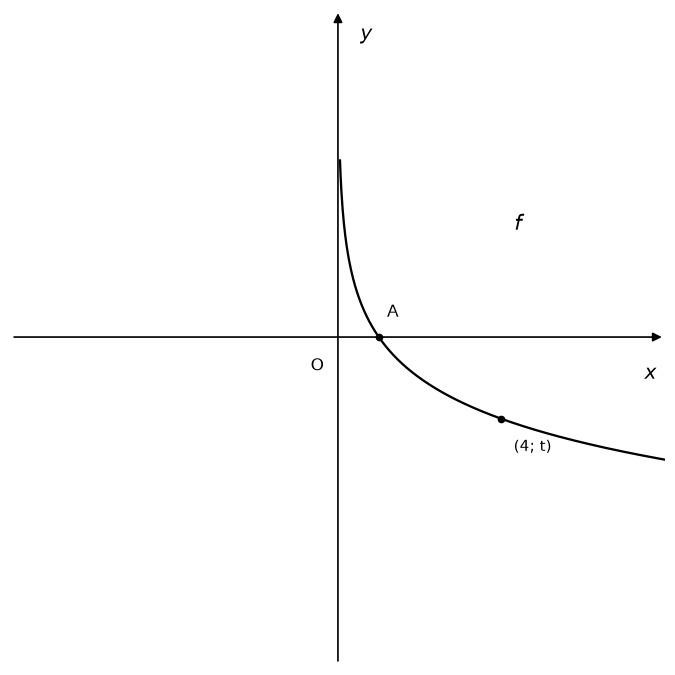


--- 2025 Q5 (parabola + hyperbola) ---


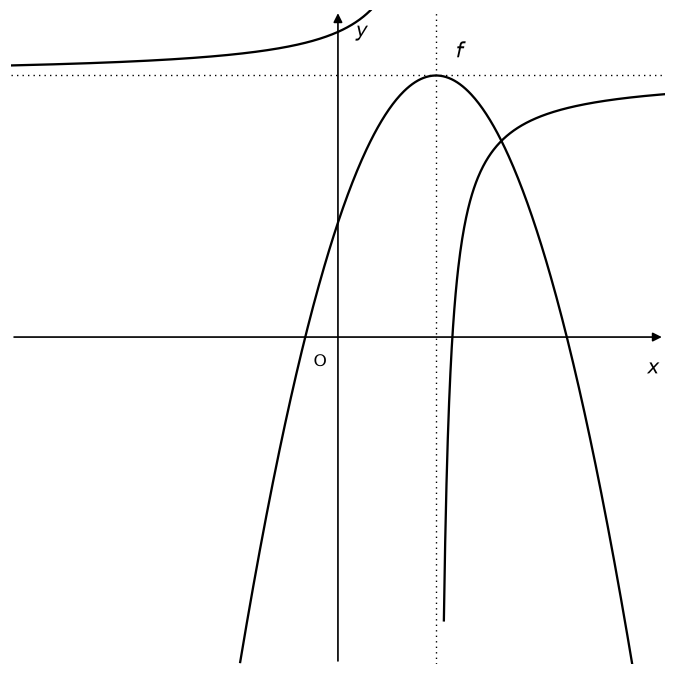


--- 2025 Q6 (hyperbola) ---


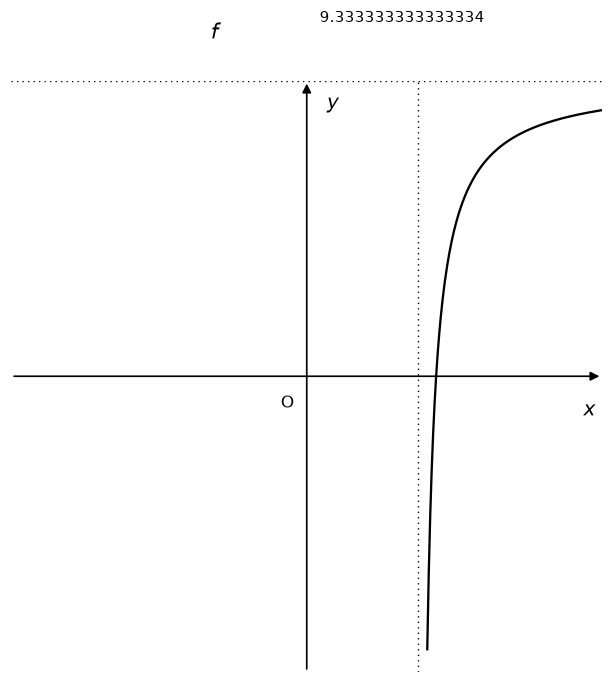


--- 2023 Q4 (exp, two points) ---


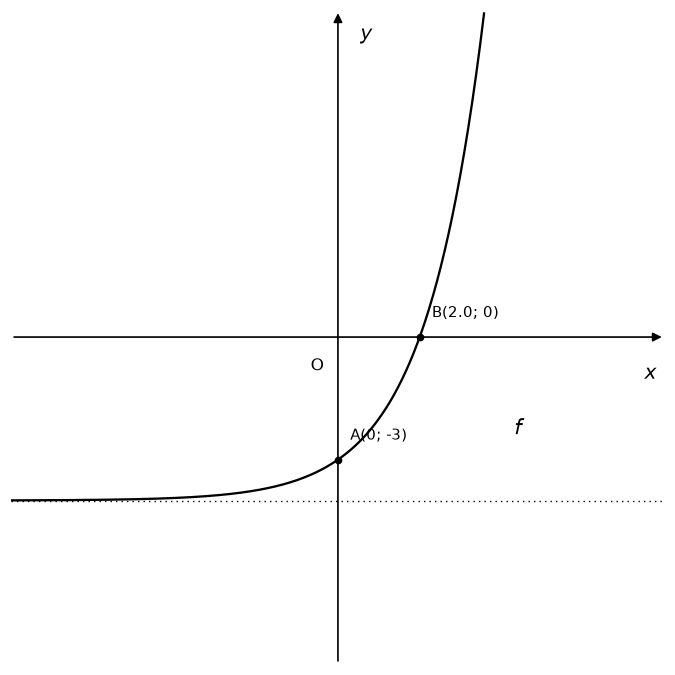


--- 2023 Q5 (parabola + hyperbola) ---


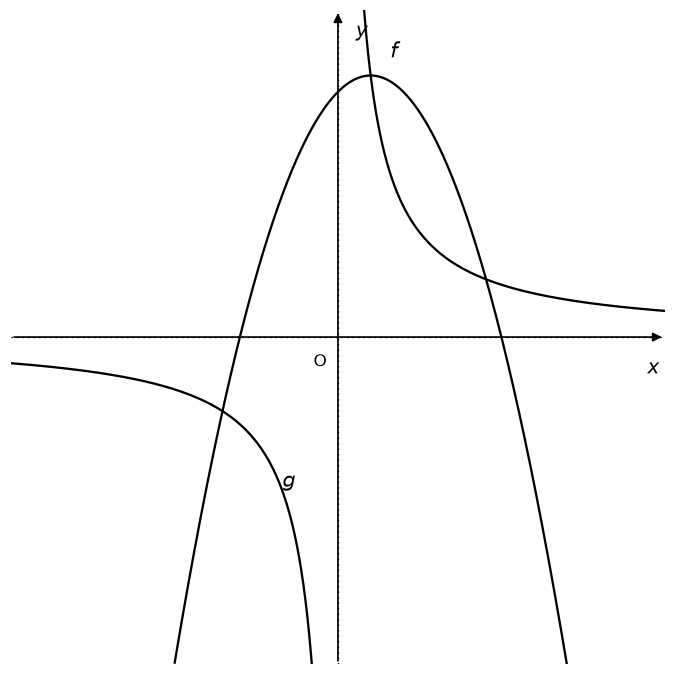

In [ ]:
import importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

mod = ROOT / "src" / "tutor" / "question_diagrams.py"
src = mod.read_text(encoding="utf-8")

# Add math import near the top, after the imports that already exist
if "import math\n" not in src:
    # insert after `import numpy as np` at module level (top of file)
    marker = "import numpy as np\n"
    if marker in src:
        # There may be one at the top; add math right after it
        src = src.replace(marker, marker + "import math\n", 1)
        mod.write_text(src, encoding="utf-8")
        print("Added 'import math' to question_diagrams.py.")
    else:
        # fallback: prepend before ROOT definition
        marker2 = "ROOT = Path(__file__)"
        src = src.replace(marker2, "import math\n" + marker2, 1)
        mod.write_text(src, encoding="utf-8")
        print("Added 'import math' (fallback position).")
else:
    print("math already imported.")


import src.tutor.question_diagrams as qd
importlib.reload(qd)
print("Reloaded question_diagrams.")

# Re-run just the failed call + the remaining ones
from IPython.display import Image, display
OUT = ROOT / "data" / "processed" / "tutor" / "question_diagrams"

print()
print("Re-rendering 2023 Q4 (exponential, two points):")
path = qd.render_exponential_two_points(2, -4, "2023_P1_Q4_fixed")
print(f"  {Path(path).name}  {Path(path).stat().st_size} bytes")

print()
print("Rendering 2023 Q5 (parabola + hyperbola):")
path = qd.render_parabola_hyperbola(-0.5, 1, 8, 8, 0, 0, "2023_P1_Q5_fixed")
print(f"  {Path(path).name}  {Path(path).stat().st_size} bytes")

print()
print("Displaying all fixed diagrams:")
for label, fname in [
    ("2025 Q4 (log)", "2025_P1_Q4_fixed.png"),
    ("2025 Q5 (parabola + hyperbola)", "2025_P1_Q5_fixed.png"),
    ("2025 Q6 (hyperbola)", "2025_P1_Q6_fixed.png"),
    ("2023 Q4 (exp, two points)", "2023_P1_Q4_fixed.png"),
    ("2023 Q5 (parabola + hyperbola)", "2023_P1_Q5_fixed.png"),
]:
    p = OUT / fname
    if p.exists():
        print(f"--- {label} ---")
        display(Image(filename=str(p), width=460))
        print()
    else:
        print(f"MISSING: {fname}")

Replaced render_poster with proper margin annotations.

Re-rendering 2023 Q9 (poster):
  2023_P1_Q9_fixed.png  11343 bytes


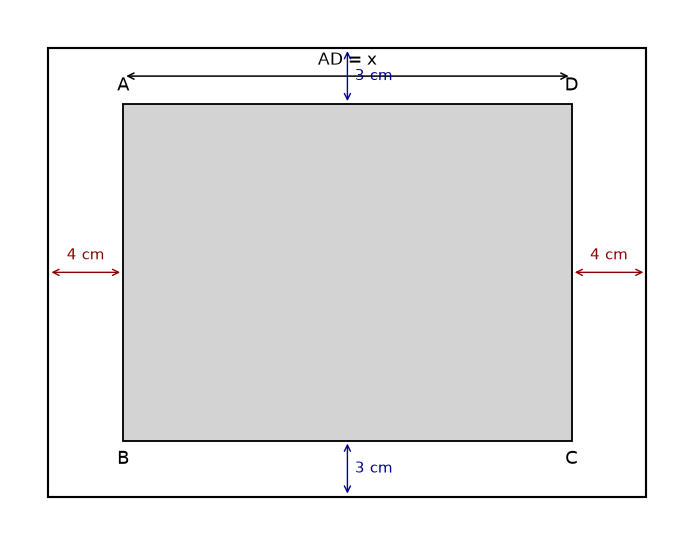

In [ ]:
import importlib, sys
from pathlib import Path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

mod = ROOT / "src" / "tutor" / "question_diagrams.py"
src = mod.read_text(encoding="utf-8")

start_marker = "def render_poster(x, y_dim, sig):"
end_marker = "# ---------- End of module ----------"  # not present, use next def or end

# Find the end of render_poster — it's the last function we added
import re
# Find the function body
pattern = r"(def render_poster\(x, y_dim, sig\):.*?)(?=\n\ndef |\n\n# |\Z)"
m = re.search(pattern, src, re.DOTALL)
if m:
    old_poster = m.group(0)
    new_poster = '''def render_poster(x, y_dim, sig):
    """Poster with rectangle ABCD inside the outer page, showing
    4 cm margins on the left/right and 3 cm margins on top/bottom."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=110)
    # Coordinates: outer page occupies (0,0) to (W, H)
    W = x + 8   # 4 cm margin each side
    H = y_dim + 6  # 3 cm margin each side
    ax.set_xlim(-2, W + 2); ax.set_ylim(-2, H + 2)
    ax.set_aspect("equal"); ax.axis("off")

    # Outer page
    ax.add_patch(Rectangle((0, 0), W, H, fill=False,
                            edgecolor="black", lw=1.4))
    # Inner shaded rectangle ABCD
    ax.add_patch(Rectangle((4, 3), x, y_dim, facecolor="lightgrey",
                            edgecolor="black", lw=1.2))

    # Vertex labels
    ax.text(4, 3 + y_dim + 0.5, "A", fontsize=12, ha="center", va="bottom")
    ax.text(4 + x, 3 + y_dim + 0.5, "D", fontsize=12, ha="center", va="bottom")
    ax.text(4, 3 - 0.5, "B", fontsize=12, ha="center", va="top")
    ax.text(4 + x, 3 - 0.5, "C", fontsize=12, ha="center", va="top")

    # AD = x (top edge of ABCD)
    ax.annotate("", xy=(4, 3 + y_dim + 1.5), xytext=(4 + x, 3 + y_dim + 1.5),
                arrowprops=dict(arrowstyle="<->", lw=1.0))
    ax.text(4 + x / 2, 3 + y_dim + 1.9, f"AD = x", fontsize=11,
            ha="center", va="bottom")

    # 4 cm margin — left
    ax.annotate("", xy=(0, 3 + y_dim / 2), xytext=(4, 3 + y_dim / 2),
                arrowprops=dict(arrowstyle="<->", lw=0.9, color="darkred"))
    ax.text(2, 3 + y_dim / 2 + 0.5, "4 cm", fontsize=10, color="darkred",
            ha="center", va="bottom")

    # 4 cm margin — right
    ax.annotate("", xy=(4 + x, 3 + y_dim / 2), xytext=(W, 3 + y_dim / 2),
                arrowprops=dict(arrowstyle="<->", lw=0.9, color="darkred"))
    ax.text(4 + x + 2, 3 + y_dim / 2 + 0.5, "4 cm", fontsize=10,
            color="darkred", ha="center", va="bottom")

    # 3 cm margin — bottom
    ax.annotate("", xy=(4 + x / 2, 0), xytext=(4 + x / 2, 3),
                arrowprops=dict(arrowstyle="<->", lw=0.9, color="darkblue"))
    ax.text(4 + x / 2 + 0.4, 1.5, "3 cm", fontsize=10, color="darkblue",
            ha="left", va="center")

    # 3 cm margin — top
    ax.annotate("", xy=(4 + x / 2, 3 + y_dim), xytext=(4 + x / 2, H),
                arrowprops=dict(arrowstyle="<->", lw=0.9, color="darkblue"))
    ax.text(4 + x / 2 + 0.4, 3 + y_dim + 1.5, "3 cm", fontsize=10,
            color="darkblue", ha="left", va="center")

    path = OUT / f"{sig}.png"
    fig.tight_layout(pad=0.3)
    fig.savefig(path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return str(path)

'''
    src = src.replace(old_poster, new_poster, 1)
    mod.write_text(src, encoding="utf-8")
    print("Replaced render_poster with proper margin annotations.")
else:
    print("WARN: render_poster not found.")


import src.tutor.question_diagrams as qd
importlib.reload(qd)

# Re-render 2023 Q9
from IPython.display import Image, display
print()
print("Re-rendering 2023 Q9 (poster):")
path = qd.render_poster(24, 18, "2023_P1_Q9_fixed")
print(f"  {Path(path).name}  {Path(path).stat().st_size} bytes")

display(Image(filename=str(path), width=520))

In [ ]:

import json
from pathlib import Path

TEMPLATE_DIR = ROOT / "data" / "processed" / "tutor" / "question_templates"

def _save(year, qnum, t):
    t["source"] = {"year": year, "paper": "P1", "qnum": str(qnum)}
    p = TEMPLATE_DIR / f"template_{year}_P1_Q{qnum}.json"
    p.write_text(json.dumps(t, indent=2, ensure_ascii=False), encoding="utf-8")
    return p.name

written = []

# ============================================================
# 2022 P1 — 10 questions
# ============================================================

# Q1 — solve for x + simultaneous + even proof + surd equation
t = {
    "stem": "Solve for x:",
    "subquestions": [
        {"n": "1.1.1", "prompt_template": "({a}x - {b})(x + {c}) = 0",
         "ranges": {"a": [2, 3, 4], "b": [4, 6, 8], "c": [2, 3, 4]},
         "marks": 2, "skill_id": "algebra.quadratic.solve",
         "expected_fn": "x = {x1} or x = {x2}",
         "steps": ["Set each factor to zero.",
                   "{a}x - {b} = 0 or x + {c} = 0",
                   "x = {x1} or x = {x2}"]},
        {"n": "1.1.2", "prompt_template": "{a}x^2 - {b}x + 1 = 0 (TWO decimals)",
         "ranges": {"a": [2, 3, 4], "b": [4, 6, 8]},
         "marks": 3, "skill_id": "algebra.quadratic.formula",
         "expected_fn": "x = {x1} or x = {x2}",
         "steps": ["Substitute into x = [-b +/- sqrt(b^2 - 4ac)] / (2a).",
                   "Simplify. Round to 2 decimals."]},
        {"n": "1.1.3", "prompt_template": "x^2 - {n} > x",
         "ranges": {"n": [20, 30, 42, 56]},
         "marks": 4, "skill_id": "algebra.quadratic.inequality",
         "expected_fn": "x < {r1} or x > {r2}",
         "steps": ["Standard form: x^2 - x - {n} > 0",
                   "Factorise: (x - {r2})(x + {r1_abs}) > 0",
                   "Critical values: x = {r1} and x = {r2}",
                   "x < {r1} or x > {r2}"]},
        {"n": "1.1.4", "prompt_template": "x - {n}sqrt(x) = -{m}",
         "ranges": {"n": [7], "m": [12]},
         "marks": 4, "skill_id": "algebra.surd.solve",
         "expected_fn": "x = {x1} or x = {x2}",
         "steps": ["Isolate the root.",
                   "Square both sides.",
                   "Standard form and factorise.",
                   "Both answers valid."]},
        {"n": "1.2", "prompt_template": "Solve simultaneously: 2x - y = 2 and xy = 4",
         "ranges": {}, "marks": 5, "skill_id": "algebra.simultaneous.solve",
         "expected_fn": "(x = 2, y = 2) or (x = -1, y = -4)",
         "steps": ["From first equation: y = 2x - 2.",
                   "Substitute into xy = 4: x(2x - 2) = 4.",
                   "2x^2 - 2x - 4 = 0 => x^2 - x - 2 = 0.",
                   "(x - 2)(x + 1) = 0.",
                   "x = 2 or x = -1. y = 2 or y = -4."]},
        {"n": "1.3", "prompt_template": "Show that 2*5^n - 5^(n+1) + 5^(n+2) is even for all positive integers n.",
         "ranges": {}, "marks": 3, "skill_id": "algebra.exponential.proof",
         "expected_fn": "= 22 * 5^n, which is even",
         "steps": ["Factor out 5^n: 5^n(2 - 5 + 25)",
                   "= 5^n * 22",
                   "= 2 * (11 * 5^n), so the expression is even."]},
    ],
}
written.append(_save(2022, 1, t))

# Q2 — geometric series
t = {
    "stem": "The first term of a geometric series is {a}, and the 6th term is {T6}.",
    "subquestions": [
        {"n": "2.1.1", "prompt_template": "Calculate r.",
         "ranges": {"a": [14, 16, 18], "T6": [448, 486, 512]},
         "marks": 2, "skill_id": "sequences.gp.ratio",
         "expected_fn": "r = {r}",
         "steps": ["T_n = a r^(n-1)",
                   "T_6 = {a} r^5 = {T6}",
                   "r^5 = {T6}/{a}",
                   "r = {r}"]},
        {"n": "2.1.2", "prompt_template": "Number of consecutive terms to add to first 6 for sum {S}.",
         "ranges": {"S": [114674, 120000, 130000]},
         "marks": 4, "skill_id": "sequences.gp.sum",
         "expected_fn": "n = {n_ans}",
         "steps": ["S_n = a(r^n - 1)/(r - 1)",
                   "Set S_n = {S} and solve for n."]},
        {"n": "2.1.3", "prompt_template": "If first term is {T6} and 6th term is {a}, calculate sum to infinity.",
         "ranges": {},
         "marks": 3, "skill_id": "sequences.gp.sum_infinity",
         "expected_fn": "S_inf = {S}",
         "steps": ["Find r.",
                   "S_inf = a/(1 - r)."]},
        {"n": "2.2", "prompt_template": "Solve sum_{p=0}^k (1/3 p + 1/6) = 20 1/6 for k.",
         "ranges": {},
         "marks": 5, "skill_id": "sequences.ap.sum",
         "expected_fn": "k = 10",
         "steps": ["T_1 = 1/6, d = 1/3, n = k + 1.",
                   "S_n = n/2 [2a + (n-1)d]",
                   "Set = 121/6 and solve for k."]},
    ],
}
written.append(_save(2022, 2, t))

# Q3 — quadratic pattern
t = {
    "stem": "Given: T_n = n^2 + bn + 9 and the first first-difference is 7.",
    "subquestions": [
        {"n": "3.1", "prompt_template": "Show that b = 4.",
         "ranges": {}, "marks": 2, "skill_id": "sequences.quadratic.general",
         "expected_fn": "b = 4",
         "steps": ["T_n = n^2 + bn + 9",
                   "T_1 = 1 + b + 9 = b + 10",
                   "T_2 = 4 + 2b + 9 = 2b + 13",
                   "T_2 - T_1 = b + 3 = 7, so b = 4."]},
        {"n": "3.2", "prompt_template": "Determine T_60.",
         "ranges": {}, "marks": 2, "skill_id": "sequences.quadratic.term",
         "expected_fn": "T_60 = 3849",
         "steps": ["T_n = n^2 + 4n + 9",
                   "T_60 = 3600 + 240 + 9 = 3849."]},
        {"n": "3.3", "prompt_template": "Determine the general term of first differences T_p = mp + q.",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.difference",
         "expected_fn": "T_p = 2p + 5",
         "steps": ["T_1 - T_0 style: first diff at position 1 = 7",
                   "d increases by 2 (second difference).",
                   "T_p = 2p + 5."]},
        {"n": "3.4", "prompt_template": "Which consecutive terms have a first difference of 157?",
         "ranges": {}, "marks": 3, "skill_id": "sequences.quadratic.n",
         "expected_fn": "Between T_76 and T_77",
         "steps": ["T_n - T_{n-1} = 2n + 3",
                   "2n + 3 = 157",
                   "n = 77."]},
    ],
}
written.append(_save(2022, 3, t))

# Q4 — hyperbola + parabola + exponential
t = {
    "stem": "The graph of h(x) = 1/(x + p) + q with asymptotes meeting at (1; 2) is drawn. Also f(x) = x^2 - 4x - 5 and g(x) = a*2^x + q.",
    "diagram": "hyperbola_solo",
    "subquestions": [
        {"n": "4.1.1", "prompt_template": "Write down p and q.",
         "ranges": {}, "marks": 2, "skill_id": "functions.hyperbola.parameter",
         "expected_fn": "p = -1, q = 2",
         "steps": ["Asymptotes meet at (-p; q) = (1; 2).",
                   "So p = -1 and q = 2."]},
        {"n": "4.1.2", "prompt_template": "Calculate the x-intercept of h.",
         "ranges": {}, "marks": 2, "skill_id": "functions.hyperbola.intercept",
         "expected_fn": "x = 1/2",
         "steps": ["Set h(x) = 0: 1/(x - 1) + 2 = 0",
                   "1/(x - 1) = -2",
                   "1 = -2(x - 1)",
                   "x = 1/2."]},
        {"n": "4.1.3", "prompt_template": "x-coordinate of x-intercept of g if g(x) = h(x + 3).",
         "ranges": {}, "marks": 2, "skill_id": "functions.transformation",
         "expected_fn": "x = -5/2",
         "steps": ["g(x) = h(x + 3) shifts h 3 units left.",
                   "Original x-intercept was at 1/2.",
                   "New x-intercept at 1/2 - 3 = -5/2."]},
        {"n": "4.1.4", "prompt_template": "Axis of symmetry y = x + t. Find t.",
         "ranges": {}, "marks": 2, "skill_id": "functions.hyperbola.axis_symmetry",
         "expected_fn": "t = 1",
         "steps": ["Axis of symmetry passes through asymptote intersection (1; 2).",
                   "y = x + t: 2 = 1 + t, t = 1."]},
        {"n": "4.1.5", "prompt_template": "Solve -2 <= 1/(x - 1).",
         "ranges": {}, "marks": 3, "skill_id": "functions.inequality",
         "expected_fn": "x <= 1/2 or x > 1",
         "steps": ["1/(x-1) + 2 >= 0",
                   "Combine: (1 + 2(x-1))/(x-1) >= 0",
                   "(2x - 1)/(x - 1) >= 0",
                   "Critical values x = 1/2, x = 1.",
                   "x <= 1/2 or x > 1."]},
        {"n": "4.2.1", "prompt_template": "y-coordinate of C, the y-intercept of f and asymptote of g.",
         "ranges": {}, "marks": 1, "skill_id": "functions.parabola.intercept",
         "expected_fn": "y = -5",
         "steps": ["C is the y-intercept of f(x) = x^2 - 4x - 5.",
                   "f(0) = -5.",
                   "C is also on g's asymptote: q = -5."]},
        {"n": "4.2.2", "prompt_template": "Coordinates of D, turning point of f.",
         "ranges": {}, "marks": 2, "skill_id": "functions.parabola.turning",
         "expected_fn": "D(2; -9)",
         "steps": ["x = -b/(2a) = 4/2 = 2.",
                   "f(2) = 4 - 8 - 5 = -9.",
                   "D(2; -9)."]},
        {"n": "4.2.3", "prompt_template": "Determine a and q of g(x) = a*2^x + q.",
         "ranges": {}, "marks": 3, "skill_id": "functions.exponential.parameter",
         "expected_fn": "a = -1, q = -5",
         "steps": ["q = -5 (from C).",
                   "D(2; -9) on g: -9 = a*4 - 5",
                   "a = -1."]},
        {"n": "4.2.4", "prompt_template": "Write the range of g.",
         "ranges": {}, "marks": 1, "skill_id": "functions.exponential.range",
         "expected_fn": "y < -5",
         "steps": ["g(x) = -2^x - 5 has horizontal asymptote y = -5.",
                   "Since a < 0, g decreases: range y < -5."]},
        {"n": "4.2.5", "prompt_template": "For which k is f(x) - k always positive?",
         "ranges": {}, "marks": 2, "skill_id": "functions.inequality",
         "expected_fn": "k < -9",
         "steps": ["f(x) - k > 0 means k < f(x) for all x.",
                   "Minimum of f is -9 (at the turning point).",
                   "So k < -9."]},
    ],
}
written.append(_save(2022, 4, t))

# Q5 — line and inverse
t = {
    "stem": "The graphs of g(x) = 2x + 6 and g^(-1) are shown.",
    "subquestions": [
        {"n": "5.1", "prompt_template": "Write down the y-coordinate of B (y-intercept of g).",
         "ranges": {}, "marks": 1, "skill_id": "functions.line.intercept",
         "expected_fn": "y = 6",
         "steps": ["g(0) = 6."]},
        {"n": "5.2", "prompt_template": "Determine g^(-1)(x).",
         "ranges": {}, "marks": 2, "skill_id": "functions.inverse",
         "expected_fn": "y = x/2 - 3",
         "steps": ["g: y = 2x + 6. Swap x and y: x = 2y + 6.",
                   "y = (x - 6)/2 = x/2 - 3."]},
        {"n": "5.3", "prompt_template": "Determine the coordinates of A, intersection of g and g^(-1).",
         "ranges": {}, "marks": 3, "skill_id": "functions.inverse",
         "expected_fn": "A(-6; -6)",
         "steps": ["Set g(x) = g^(-1)(x): 2x + 6 = x/2 - 3",
                   "4x + 12 = x - 6",
                   "3x = -18, x = -6.",
                   "y = 2(-6) + 6 = -6."]},
        {"n": "5.4", "prompt_template": "Calculate the length of AB.",
         "ranges": {}, "marks": 2, "skill_id": "analytical.distance",
         "expected_fn": "AB = sqrt(180) = 6 sqrt(5)",
         "steps": ["A(-6; -6), B(0; 6).",
                   "AB = sqrt((0+6)^2 + (6+6)^2) = sqrt(36 + 144) = sqrt(180)."]},
        {"n": "5.5", "prompt_template": "Calculate the area of triangle ABC.",
         "ranges": {}, "marks": 5, "skill_id": "analytical.area",
         "expected_fn": "Area = 54",
         "steps": ["C is the x-intercept of g^(-1): 0 = x/2 - 3, x = 6. C(6; 0).",
                   "Use area formula = 1/2 |x1(y2 - y3) + ...|",
                   "Area = 54."]},
    ],
}
written.append(_save(2022, 5, t))

# Q6 — finance
t = {
    "stem": "",
    "subquestions": [
        {"n": "6.1", "prompt_template": "R12 000 invested at m% p.a. compounded quarterly for 24 months. Value = R13 459. Find m.",
         "ranges": {}, "marks": 4, "skill_id": "finance.compound.r",
         "expected_fn": "m = 5.78%",
         "steps": ["A = P(1 + i)^n, i = m/400, n = 8.",
                   "13459 = 12000(1 + m/400)^8",
                   "(1 + m/400)^8 = 1.1216",
                   "1 + m/400 = (1.1216)^(1/8) = 1.01444",
                   "m/400 = 0.01444, m = 5.78%."]},
        {"n": "6.2", "prompt_template": "Tino deposits R1 000 at end of each month at 7.5% p.a. compounded monthly for 12 months. Can he buy a R13 000 computer?",
         "ranges": {}, "marks": 4, "skill_id": "finance.annuity.future",
         "expected_fn": "F = R12 421.22; cannot afford",
         "steps": ["F = x[(1+i)^n - 1]/i, i = 0.075/12, n = 12.",
                   "F = R12 421.22",
                   "12 421.22 < 13 000 so he cannot afford it."]},
        {"n": "6.3.1", "prompt_template": "Car costs R250 000, 15% deposit, 13% p.a. loan. Calculate loan value.",
         "ranges": {}, "marks": 1, "skill_id": "finance.loan.n",
         "expected_fn": "Loan = R212 500",
         "steps": ["Loan = 85% of 250 000 = R212 500."]},
        {"n": "6.3.2", "prompt_template": "Loan repaid over 6 years, first payment 6 months after loan. Monthly instalment?",
         "ranges": {}, "marks": 5, "skill_id": "finance.loan.final",
         "expected_fn": "x = R4 724.96",
         "steps": ["A = 212 500(1 + 0.13/12)^6 (loan accrues 6 months before first payment)",
                   "Then P = x[1 - (1+i)^(-n)]/i with n = 67 payments.",
                   "Solve for x."]},
    ],
}
written.append(_save(2022, 6, t))

# Q7 — calculus
t = {
    "stem": "",
    "subquestions": [
        {"n": "7.1", "prompt_template": "Determine f'(x) from first principles if f(x) = x^2 + x.",
         "ranges": {}, "marks": 5, "skill_id": "calculus.first_principles",
         "expected_fn": "f'(x) = 2x + 1",
         "steps": ["f(x+h) = (x+h)^2 + (x+h) = x^2 + 2xh + h^2 + x + h",
                   "f(x+h) - f(x) = 2xh + h^2 + h",
                   "[f(x+h) - f(x)]/h = 2x + h + 1",
                   "As h -> 0: f'(x) = 2x + 1."]},
        {"n": "7.2", "prompt_template": "Determine f'(x) if f(x) = 2x^5 - 3x^4 + 8x.",
         "ranges": {}, "marks": 3, "skill_id": "calculus.derivative.rules",
         "expected_fn": "f'(x) = 10x^4 - 12x^3 + 8",
         "steps": ["Differentiate term by term."]},
        {"n": "7.3", "prompt_template": "Tangent to g(x) = ax^3 + 3x^2 + bx + c has minimum gradient at (-1; -7). For which x is g concave up?",
         "ranges": {}, "marks": 4, "skill_id": "calculus.cubic.concave",
         "expected_fn": "x > -1",
         "steps": ["g'(x) = 3ax^2 + 6x + b",
                   "g''(x) = 6ax + 6",
                   "Minimum gradient at x = -1 means g''(-1) = 0: -6a + 6 = 0, a = 1.",
                   "Concave up when g''(x) > 0: 6x + 6 > 0, x > -1."]},
    ],
}
written.append(_save(2022, 7, t))

# Q8 — cubic f'(x) graph
t = {
    "stem": "The graph of y = f'(x) = mx^2 + nx + k passes through P(-1/3; 0), Q(1; 0), R(0; 1).",
    "diagram": "cubic",
    "subquestions": [
        {"n": "8.1", "prompt_template": "Determine m, n, k.",
         "ranges": {}, "marks": 4, "skill_id": "calculus.derivative",
         "expected_fn": "m = -3, n = 2, k = 1",
         "steps": ["At x=0: k = 1.",
                   "P(-1/3; 0) and Q(1; 0): m(-1/3)^2 + n(-1/3) + 1 = 0 and m + n + 1 = 0.",
                   "Solve: m/9 - n/3 + 1 = 0, m + n = -1.",
                   "m - 3n = -9, m + n = -1 => 4n = 8, n = 2, m = -3."]},
        {"n": "8.2.1", "prompt_template": "Given f(x) = -x^3 + x^2 + x + 2, find turning points.",
         "ranges": {}, "marks": 5, "skill_id": "calculus.cubic.turning",
         "expected_fn": "TPs at (-1/3; 49/27) and (1; 3)",
         "steps": ["f'(x) = -3x^2 + 2x + 1 = -(3x + 1)(x - 1)",
                   "f'(x) = 0 at x = -1/3 or x = 1.",
                   "f(-1/3) = 49/27, f(1) = 3."]},
        {"n": "8.2.2", "prompt_template": "Sketch f showing TPs and intercepts.",
         "ranges": {}, "marks": 4, "skill_id": "calculus.cubic.sketch",
         "expected_fn": "see sketch",
         "steps": ["Negative cubic.",
                   "x-intercept at x = 2 (only).",
                   "y-intercept at 2.",
                   "Turning points from 8.2.1."]},
        {"n": "8.3.1", "prompt_template": "If h, g are tangents to f' at points E, W (same horizontal line), find x-coordinate of intersection D(a; b).",
         "ranges": {}, "marks": 2, "skill_id": "calculus.tangent",
         "expected_fn": "a = 1/3",
         "steps": ["f' is a parabola. Lines at equal y-values intersect on the axis of symmetry.",
                   "a = -n/(2m) = -2/(2(-3)) = 1/3."]},
        {"n": "8.3.2", "prompt_template": "Values of b for which h and g will no longer be tangents to f'.",
         "ranges": {}, "marks": 2, "skill_id": "calculus.tangent",
         "expected_fn": "b < {b_min}",
         "steps": ["At the vertex of f' the two tangents degenerate.",
                   "Read off the vertex y-value."]},
    ],
}
written.append(_save(2022, 8, t))

# Q9 — closest point on parabola
t = {
    "stem": "Given f(x) = x^2. Determine the minimum distance between the point (10; 2) and a point on f.",
    "subquestions": [
        {"n": "9.1", "prompt_template": "Determine the minimum distance.",
         "ranges": {}, "marks": 8, "skill_id": "calculus.optimisation.min",
         "expected_fn": "Distance = 2 sqrt(17) ≈ 8.25",
         "steps": ["Point on f: (x; x^2).",
                   "Distance d = sqrt((x-10)^2 + (x^2-2)^2).",
                   "Minimise d^2 = x^4 - 3x^2 - 20x + 104.",
                   "Set derivative to zero: 4x^3 - 6x - 20 = 0.",
                   "Factor: (x - 2)(4x^2 + 8x + 10) = 0",
                   "Only real root: x = 2.",
                   "d = sqrt(2^4 - 3(2)^2 - 20(2) + 104) = 2 sqrt(17)."]},
    ],
}
written.append(_save(2022, 9, t))

# Q10 — probability + counting
t = {
    "stem": "A, B and C are three events with probabilities given in a Venn diagram: A only 0.05, C only 0.05, A&B only 0.1, B&C only 0.2, A&C only 0.15, triple x, B only 0.183, none y.",
    "subquestions": [
        {"n": "10.1.1a", "prompt_template": "Find y (P(none)).",
         "ranges": {}, "marks": 1, "skill_id": "probability.venn",
         "expected_fn": "y = 0.107",
         "steps": ["Sum all regions including y must equal 1.",
                   "0.05 + 0.05 + 0.1 + 0.2 + 0.15 + x + 0.183 + y = 1."]},
        {"n": "10.1.1b", "prompt_template": "Find x (P(all three)).",
         "ranges": {}, "marks": 1, "skill_id": "probability.venn",
         "expected_fn": "x = 0.16",
         "steps": ["Given P(at least one) = 0.893.",
                   "0.893 = 1 - y, so y = 0.107.",
                   "Sum all non-y regions = 0.893 and solve for x: x = 0.16."]},
        {"n": "10.1.2", "prompt_template": "P(at least 2 events).",
         "ranges": {}, "marks": 2, "skill_id": "probability.set",
         "expected_fn": "0.61",
         "steps": ["Sum pairwise-only and triple regions: 0.1 + 0.15 + 0.2 + 0.16 = 0.61."]},
        {"n": "10.1.3", "prompt_template": "Are B and C independent? Justify.",
         "ranges": {}, "marks": 5, "skill_id": "probability.independence",
         "expected_fn": "Yes",
         "steps": ["P(B) = 0.643, P(C) = 0.56",
                   "P(B) * P(C) = 0.36",
                   "P(B and C) = 0.36",
                   "Equal, so independent."]},
        {"n": "10.2.1", "prompt_template": "Four-digit code, even, no 0 or 1, digits not repeated. How many combinations?",
         "ranges": {}, "marks": 3, "skill_id": "probability.counting",
         "expected_fn": "840",
         "steps": ["Digits available: 2-9 (8 digits).",
                   "First digit: 7 choices (2-9 except... wait, must be >5000?)",
                   "Even ending: 4 choices (2, 4, 6, 8).",
                   "Total = 7 x 6 x 5 x 4 = 840."]},
        {"n": "10.2.2", "prompt_template": "P(opens on first attempt) if code > 5000 and third digit is 2.",
         "ranges": {}, "marks": 5, "skill_id": "probability.counting",
         "expected_fn": "P = 13/840 ≈ 0.0155",
         "steps": ["Count favourable outcomes using cases.",
                   "Divide by 840."]},
    ],
}
written.append(_save(2022, 10, t))

print(f"Wrote {len(written)} templates for 2022 P1:")
for name in written:
    print(f"  {name}")
print()
print(f"Total templates on disk: {len(list(TEMPLATE_DIR.glob('template_*.json')))}")

NameError: name 'ROOT' is not defined